# ДЗ №7 «Финальный ансамбль»

**Студент**: Сизиков Константин

**Цель**:
 - Студенты учатся работать с моделями обучения с подкреплением и фреймворком FinRL.
 - Опционально - Студенты учатся собирать большие ансамбли моделей для повышения качества.
 - Цель - попробовать внедрить в модель агента RL на базе фреймворка FinRL.
 - Опционально - собрать большой анасмбль моделей для повышения качества.

**Описание/Пошаговая инструкция выполнения домашнего задания**:
 - добавить в модель RL модель;
 - оценить качество решения;
 - Дополнительно:
 - сформировать анасмбль моделей;
 - добавить RL модель на "вершину" ансамбля.

In [1]:
%matplotlib inline

import warnings
warnings.filterwarnings("ignore")

import os
import re
import time

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from matplotlib.ticker import PercentFormatter
from matplotlib.patches import Rectangle

from scipy import stats
from scipy.optimize import brentq

from sklearn.preprocessing import RobustScaler, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import IsolationForest
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                             roc_auc_score, average_precision_score,
                             roc_curve, precision_recall_curve)
from catboost import CatBoostClassifier

import torch
import torch.nn as nn
import torch.nn.functional as F

import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)

RANDOM_STATE = 42
PERIODS_PER_YEAR = 24 * 365
FEE_RATE = 0.001          # та же комиссия, что в ДЗ №2, — чтобы результаты были сопоставимы
FEE_SCENARIOS = {"0.10% (ДЗ №2)": 0.0010, "0.05% (taker)": 0.0005,
                 "0.02% (maker)": 0.0002, "0.00% (без издержек)": 0.0}
N_CV_SPLITS = 5
N_TRIALS = 25
TRAIN_END, TEST_END = 0.70, 0.85     # доли ряда: train / train+test, остальное — валидация
HORIZON = 1               # горизонт прогноза в барах (обоснование — раздел 13)
EMBARGO = HORIZON         # разрыв между выборками = длине метки
WINSOR_Q = 0.001          # квантиль винзоризации признаков
OUTLIER_Z = 4.0           # порог робастного z-score для «экстремального» бара
OUTLIER_WEIGHT = 0.25     # вес аномального бара при обучении
PIVOT_W = 5               # полуокно фрактала для свинг-точек
N_BLOCKS = 5              # число подпериодов для проверки устойчивости торгового слоя
MIN_POSITIVE_BLOCKS = 3   # сколько подпериодов должны быть прибыльными
MIN_TURNOVER_PER_YEAR = 6  # минимальный оборот: 3 полных разворота позиции в год
MIN_AVG_EXPOSURE = 0.10    # минимальный средний размер позиции (доля капитала)
TRADE_EPS = 0.01           # изменение позиции меньше 1% капитала сделкой не считается
N_LAGS = 12

DATA_PATH = "data/btc_1h.csv"
NEWS_PATH = "data/btc_news.csv"                     # лента крипто-повестки с метками времени
PHRASEBANK_PATH = "data/financial_phrasebank.csv"   # размеченный корпус для проверки скорера

np.random.seed(RANDOM_STATE)
torch.manual_seed(RANDOM_STATE)
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
plt.rcParams["figure.dpi"] = 110

CLS_COLS = ["accuracy", "precision", "recall", "f1", "roc_auc", "pr_auc"]
TRADE_COLS = ["gross_return", "fee_drag", "total_return", "sharpe", "max_drawdown",
              "n_trades", "turnover_units", "avg_abs_position"]
REPORT_COLS = CLS_COLS + TRADE_COLS

COLORS = {
    "BuyAndHold": "#44403c",
    "HW2_Baseline": "#a8a29e",
    "TA_AlwaysIn": "#c026d3",
    "LogisticRegression": "#2a78d6",
    "DecisionTree": "#eb6834",
    "CatBoost": "#1baf7a",
    "Ensemble": "#8b5cf6",
    "TimesNet": "#0891b2",
    "TSMixer": "#ca8a04",
    "TimesFM": "#be185d",
    "EnsembleAll": "#701a75",
    "FinRL": "#7c3aed",
    "RL_Position": "#0f766e",
    "RL_Ensemble": "#b45309",
}
STYLES = {"BuyAndHold": (0, (5, 2)), "HW2_Baseline": (0, (1, 1.6)),
          "TA_AlwaysIn": (0, (3, 1.4))}
SHORT = {"BuyAndHold": "B&H", "HW2_Baseline": "ДЗ№2", "TA_AlwaysIn": "ТА без слоя",
         "LogisticRegression": "LogReg", "DecisionTree": "Tree", "CatBoost": "CatBoost",
         "Ensemble": "Ансамбль", "TimesNet": "TimesNet", "TSMixer": "TSMixer",
         "TimesFM": "TimesFM", "EnsembleAll": "Ансамбль+",
         "FinRL": "FinRL", "RL_Position": "RL-позиция",
         "RL_Ensemble": "RL-вершина"}
INK, INK_MUTED, GRID = "#1c1917", "#57534e", "#e7e5e4"

UP, DOWN = "#1baf7a", "#e05252"      # цвета растущей / падающей свечи


def style_ax(ax, ygrid=True, xgrid=False):
    """Единое оформление осей: без рамки, приглушённая сетка."""
    for s in ("top", "right"):
        ax.spines[s].set_visible(False)
    for s in ("left", "bottom"):
        ax.spines[s].set_color(GRID)
    ax.tick_params(colors=INK_MUTED, labelsize=8)
    if ygrid:
        ax.grid(axis="y", color=GRID, linewidth=0.7)
    if xgrid:
        ax.grid(axis="x", color=GRID, linewidth=0.7)
    ax.set_axisbelow(True)

## 1. Загрузка данных и проверка целостности

Часовые бары BTC/USDT. Проверка на дубли меток времени, пропущенные часы, нарушенные соотношения OHLC
(`high` должен быть не меньше `max(open, close)`, `low` — не больше `min(open, close)`),
неположительные цены и нулевой объём.

In [2]:
raw = pd.read_csv(DATA_PATH)

COLUMN_MAP = {"datetime": "date", "date": "date", "open": "open", "high": "high",
              "low": "low", "close": "close", "volume": "volume"}
raw = raw.rename(columns={c: COLUMN_MAP[c.lower()] for c in raw.columns if c.lower() in COLUMN_MAP})
assert not raw.columns.duplicated().any(), f"После переименования появились дубли колонок: {list(raw.columns)}"

OHLCV = ["open", "high", "low", "close", "volume"]
absent = [c for c in ["date"] + OHLCV if c not in raw.columns]
assert not absent, f"В {DATA_PATH} нет обязательных колонок {absent}; фактически есть: {list(raw.columns)}"

raw["date"] = pd.to_datetime(raw["date"], utc=True).dt.tz_convert(None)

# ── новостной поток и обрезка ряда по его доступности ──────────────────────
# Новости кончаются раньше цен. Если этого не учесть, отложенная выборка окажется в зоне
# без новостей: модель училась бы с ними, а проверялась без. Поэтому ряд цен обрезается по
# последнему часу с новостями — подробнее в разделе 1.2.
news = pd.read_csv(NEWS_PATH)
news["dt"] = pd.to_datetime(news["date_time"], utc=True, errors="coerce").dt.tz_convert(None)
news = news.dropna(subset=["dt", "title"]).sort_values("dt").reset_index(drop=True)
news_end = news["dt"].max().floor("h")
n_price_full = len(raw)
raw = raw.sort_values("date")
raw = raw[raw["date"] <= news_end].reset_index(drop=True)
news = news[(news["dt"] >= raw["date"].min() - pd.Timedelta(days=40))
            & (news["dt"] <= news_end)].reset_index(drop=True)
print(f"Новости: {len(news)} заголовков, {news['dt'].min()} — {news['dt'].max()}")
print(f"Ряд цен обрезан по концу новостей: {len(raw)} баров из {n_price_full} "
      f"({len(raw) / n_price_full:.0%}), последний бар {raw['date'].max()}")

n_before = len(raw)
dup_rows = raw.duplicated(subset="date", keep=False).sum()
conflicting = 0
if dup_rows:
    g = raw[raw.duplicated(subset="date", keep=False)].groupby("date").nunique()
    conflicting = int((g[OHLCV] > 1).any(axis=1).sum())

raw = raw.sort_values("date").drop_duplicates(subset="date").reset_index(drop=True)
full_grid = pd.date_range(raw["date"].min(), raw["date"].max(), freq="h")
missing = full_grid.difference(raw["date"])

o, h, l, c, v = (raw[x] for x in OHLCV)
integrity = pd.DataFrame([
    ("дубли меток времени", int(dup_rows), "удалены" if dup_rows else "—"),
    ("  из них с расхождением в OHLCV", conflicting, "критично" if conflicting else "—"),
    ("пропущенные часы в сетке", int(len(missing)), "критично" if len(missing) else "—"),
    ("high < max(open, close)", int((h < np.maximum(o, c) - 1e-9).sum()), "битый бар"),
    ("low > min(open, close)", int((l > np.minimum(o, c) + 1e-9).sum()), "битый бар"),
    ("high < low", int((h < l).sum()), "битый бар"),
    ("неположительные цены", int((raw[["open", "high", "low", "close"]] <= 0).sum().sum()), "битый бар"),
    ("нулевой объём", int((v <= 0).sum()), "нет торгов"),
    ("нулевой диапазон (high == low)", int(((h - l) <= 0).sum()), "нет движения"),
], columns=["проверка", "нарушений", "трактовка"]).set_index("проверка")

print(f"Загружено строк: {n_before}")
display(integrity)
assert conflicting == 0, "Дубликаты timestamp содержат разные котировки — нужно решить, какую строку оставить"
assert len(missing) == 0, f"В ряду есть пропуски ({len(missing)} часов) — лаговые признаки будут смещены во времени"
assert (h >= np.maximum(o, c) - 1e-9).all() and (l <= np.minimum(o, c) + 1e-9).all(), "нарушена структура OHLC"
print(f"OK: непрерывный часовой ряд без дефектов, {len(raw)} баров, "
      f"период {raw['date'].min()} — {raw['date'].max()}")

raw = raw[["date"] + OHLCV]
raw.head()

Новости: 139570 заголовков, 2020-11-22 01:40:52 — 2025-06-03 22:31:49
Ряд цен обрезан по концу новостей: 38775 баров из 48625 (80%), последний бар 2025-06-04 14:00:00
Загружено строк: 38775


,нарушений,трактовка
проверка,,
дубли меток времени,0,—
из них с расхождением в OHLCV,0,—
пропущенные часы в сетке,0,—
"high < max(open, close)",0,битый бар
"low > min(open, close)",0,битый бар
high < low,0,битый бар
неположительные цены,0,битый бар
нулевой объём,0,нет торгов
нулевой диапазон (high == low),0,нет движения


OK: непрерывный часовой ряд без дефектов, 38775 баров, период 2021-01-01 00:00:00 — 2025-06-04 14:00:00


,date,open,high,low,close,volume
0,2021-01-01 00:00:00,28921.5,29026.0,28703.5,28990.0,917.494
1,2021-01-01 01:00:00,28990.0,29505.5,28956.5,29411.0,1927.830
2,2021-01-01 02:00:00,29411.0,29462.0,29150.0,29218.0,931.537
3,2021-01-01 03:00:00,29218.0,29358.5,29171.5,29303.0,440.535
4,2021-01-01 04:00:00,29303.0,29397.5,29078.0,29229.5,711.549


### 1.1 Обзор ряда

Отдельно смотрим на структуру гэпов: у круглосуточного крипторынка `open` следующего бара
почти всегда в точности равен `close` предыдущего. Это важно для свечных паттернов —
классические определения «пронзающей линии», «завесы из тёмных облаков», а также утренней и
вечерней звезды требуют ценового разрыва, которого здесь физически не бывает, поэтому условие
гэпа в них приходится ослаблять до нестрогого.

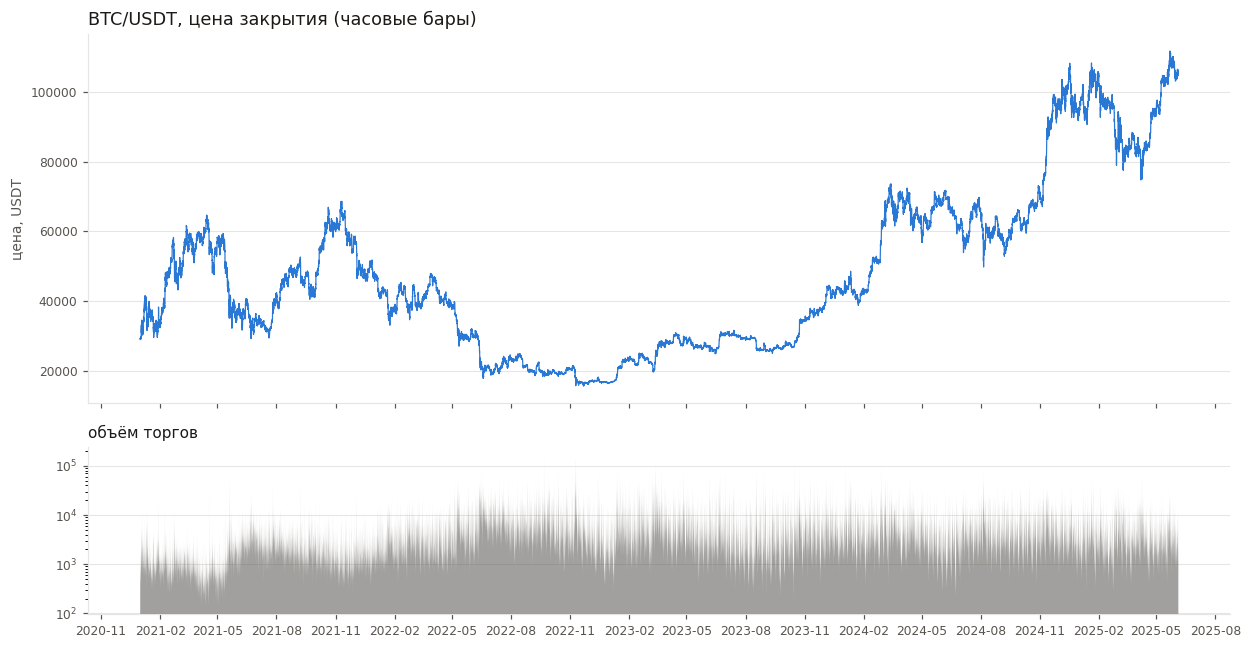

Баров с ценовым разрывом (open != предыдущий close): 66 из 38774 (0.17%), максимальный разрыв 40.0 USDT
Часовая доходность: std=0.6626%, эксцесс=17.0 (у нормального распределения 0), диапазон [-9.28%, 12.50%]


In [3]:
gap = raw["open"] - raw["close"].shift(1)
n_gap = int((gap.abs() > 1e-9).sum())
ret_all = raw["close"].pct_change()

fig, axes = plt.subplots(2, 1, figsize=(11.5, 6), sharex=True,
                         gridspec_kw={"height_ratios": [2.2, 1]})
axes[0].plot(raw["date"], raw["close"], color=COLORS["LogisticRegression"], linewidth=0.8)
axes[0].set_title("BTC/USDT, цена закрытия (часовые бары)", color=INK, loc="left", fontsize=11.5)
axes[0].set_ylabel("цена, USDT", color=INK_MUTED, fontsize=9)
axes[1].fill_between(raw["date"], raw["volume"], color=INK_MUTED, linewidth=0, alpha=0.55)
axes[1].set_title("объём торгов", color=INK, loc="left", fontsize=10)
axes[1].set_yscale("log")
axes[1].xaxis.set_major_locator(mdates.MonthLocator(interval=3))
axes[1].xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m"))
for ax in axes:
    style_ax(ax)
fig.tight_layout()
plt.show()

print(f"Баров с ценовым разрывом (open != предыдущий close): {n_gap} из {len(raw) - 1} "
      f"({n_gap / (len(raw) - 1):.2%}), максимальный разрыв {gap.abs().max():.1f} USDT")
print(f"Часовая доходность: std={ret_all.std():.4%}, эксцесс={ret_all.kurtosis():.1f} "
      f"(у нормального распределения 0), диапазон [{ret_all.min():.2%}, {ret_all.max():.2%}]")

### 1.2 Новостной поток

Источник — `data/btc_news.csv`: 210 832 заголовка крипто-повестки с точными метками времени и
названием издания, от 2011 года до июня 2025-го. Внутрь ценового периода попадает **137 313
заголовков** из 290 изданий: CoinDesk, FX Empire, Reuters, GlobeNewswire, InvestorPlace,
Benzinga, Business Insider и другие — на восемь крупнейших приходится 57% потока. В обработку
берётся чуть больше — **139 570 заголовков**: к периоду добавлены 40 дней перед первым баром,
чтобы PCA и статистики тональности не считались по обрезанному началу. (В таблице ниже строка
«заголовков в файле» — это как раз рабочий набор из 139 570: до неё файл уже отфильтрован по
этому окну.)

Поток собран вокруг биткоина, но это лента финансовых СМИ: в рабочем наборе bitcoin или BTC
прямо упоминают 42% заголовков, крипто-лексика (ethereum, blockchain, токены, биржи) есть у 64%,
остальное — макроэкономика и акции от тех же изданий. Для признаков это скорее плюс: рыночный
фон вокруг биткоина тоже часть повестки, — но называть весь поток «новостями о биткоине» было
бы неточно.

**Ряд цен пришлось обрезать.** Новости кончаются 04.06.2025, цены — 20.07.2026. Если
оставить весь ряд, вся отложенная выборка окажется в зоне, где новостных признаков нет: модель
училась бы с новостями, а проверялась без них. Это не эксперимент, а его имитация. Поэтому цены
обрезаются по последнему часу с новостями — ценой 20% данных и, что важнее, ценой смены
валидационного периода на растущий.

**Плотность потока неравномерна, и это само по себе признак.** Медиана — 2 заголовка в час, но
в 37% часов новостей нет вовсе, а в пике бывает больше 60. Всплеск новостной активности часто
информативнее тональности: рынок реагирует на то, что о нём вообще заговорили.

**Причинность.** Заголовок, опубликованный в момент τ, приписывается к бару
`ceil(τ, 1 час)`, то есть округляется вверх. Если метка времени бара — это его закрытие, то
это первый бар, к закрытию которого новость уже вышла; если метка — открытие (обычное
соглашение для биржевых часовых данных), округление добавляет ещё час запаса. Признак заведомо
не опережает новость ни при одном из двух соглашений, поэтому проверять, какое из них верно для
этого файла, не требуется.
Дальше все агрегаты считаются скользящими окнами по барам `≤ t`, и проверка на утечку из
раздела 7.4 покрывает их наравне с остальными признаками.

,значение
заголовков в файле,139570
в рабочем периоде,137313
изданий,290
часов с новостями,62.5%
медиана на час,2
среднее на час,3.54
максимум на час,62
среднее в сутки,85


Топ изданий:


,заголовков
source,
CoinDesk,29184
FX Empire,11040
Reuters,9068
GlobeNewswire,8146
InvestorPlace,7445
Benzinga,4993
Business Insider,4560
Forkast News,3816


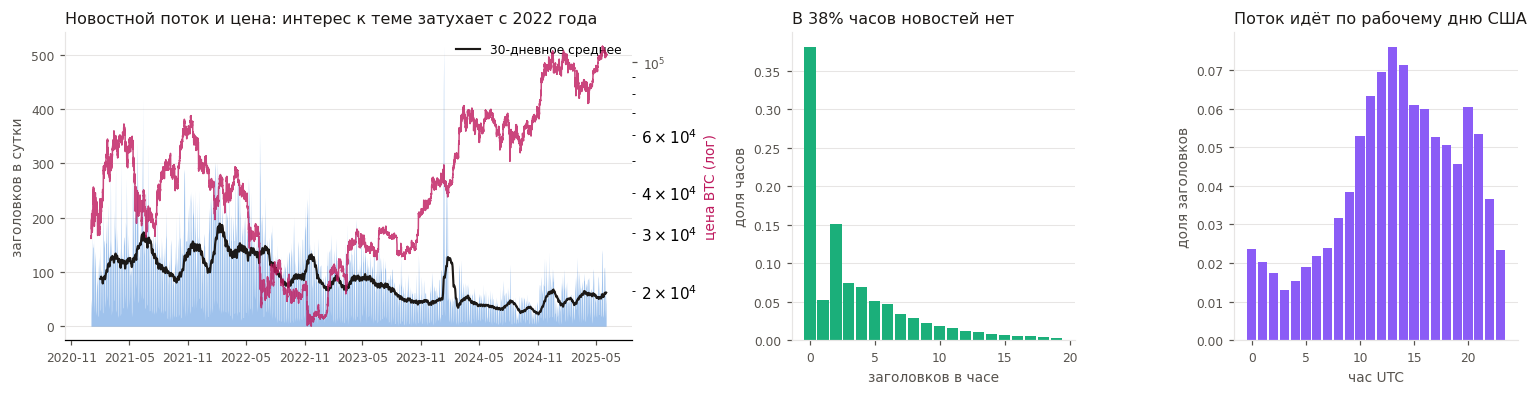

Правая панель объясняет, почему час выхода новости важен: поток подчинён рабочему дню
американских редакций, а торги идут круглосуточно. Ночью новостей почти нет, и признаки
вроде «часов с последней новости» несут в том числе календарную информацию.


In [4]:
# Новостной поток: плотность, источники, покрытие.
news_period = news[(news["dt"] >= raw["date"].min()) & (news["dt"] <= raw["date"].max())]
per_day = news_period.set_index("dt").resample("D").size()
per_bar_cnt = news_period.set_index("dt").resample("h").size().reindex(
    pd.date_range(raw["date"].min(), raw["date"].max(), freq="h"), fill_value=0)

news_stats = pd.DataFrame({
    "значение": [len(news), len(news_period), news_period["source"].nunique(),
                 f"{(per_bar_cnt > 0).mean():.1%}", f"{per_bar_cnt.median():.0f}",
                 f"{per_bar_cnt.mean():.2f}", f"{per_bar_cnt.max():.0f}",
                 f"{per_day.mean():.0f}"],
}, index=["заголовков в файле", "в рабочем периоде", "изданий",
          "часов с новостями", "медиана на час", "среднее на час",
          "максимум на час", "среднее в сутки"])
display(news_stats)
print("Топ изданий:")
display(news_period["source"].value_counts().head(8).rename("заголовков").to_frame())

fig, axes = plt.subplots(1, 3, figsize=(14, 3.7), gridspec_kw={"width_ratios": [2, 1, 1]})

ax = axes[0]
ax.fill_between(per_day.index, per_day.to_numpy(), color=COLORS["LogisticRegression"],
                alpha=0.45, linewidth=0)
ax.plot(per_day.index, per_day.rolling(30).mean(), color=INK, linewidth=1.4,
        label="30-дневное среднее")
ax2 = ax.twinx()
ax2.plot(raw["date"], raw["close"], color=COLORS["TimesFM"], linewidth=1.0, alpha=0.8)
ax2.set_yscale("log")
ax2.set_ylabel("цена BTC (лог)", color=COLORS["TimesFM"], fontsize=9)
ax2.tick_params(colors=INK_MUTED, labelsize=8)
for s in ("top", "right", "left"):
    ax2.spines[s].set_visible(False)
ax.set_ylabel("заголовков в сутки", color=INK_MUTED, fontsize=9)
ax.set_title("Новостной поток и цена: интерес к теме затухает с 2022 года",
             color=INK, fontsize=10.5, loc="left")
ax.legend(frameon=False, fontsize=8, loc="upper right")
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=6))
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m"))
style_ax(ax)

ax = axes[1]
vals, bins = np.histogram(per_bar_cnt, bins=np.arange(0, 21) - 0.5)
ax.bar(np.arange(0, 20), vals / vals.sum(), color=COLORS["CatBoost"], width=0.85)
ax.set_xlabel("заголовков в часе", color=INK_MUTED, fontsize=9)
ax.set_ylabel("доля часов", color=INK_MUTED, fontsize=9)
ax.set_title(f"В {(per_bar_cnt == 0).mean():.0%} часов новостей нет",
             color=INK, fontsize=10.5, loc="left")
style_ax(ax)

ax = axes[2]
by_hour = news_period.groupby(news_period["dt"].dt.hour).size()
ax.bar(by_hour.index, by_hour / by_hour.sum(), color=COLORS["Ensemble"], width=0.85)
ax.set_xlabel("час UTC", color=INK_MUTED, fontsize=9)
ax.set_ylabel("доля заголовков", color=INK_MUTED, fontsize=9)
ax.set_title("Поток идёт по рабочему дню США", color=INK, fontsize=10.5, loc="left")
style_ax(ax)

fig.tight_layout()
plt.show()
print("Правая панель объясняет, почему час выхода новости важен: поток подчинён рабочему дню")
print("американских редакций, а торги идут круглосуточно. Ночью новостей почти нет, и признаки")
print("вроде «часов с последней новости» несут в том числе календарную информацию.")

## 2. Поиск аномалий (выбросов) и их обработка

Проверка на **рыночные выбросы**:
бары с экстремальным движением цены или объёма.

| шаг | что делается | зачем |
|---|---|---|
| обнаружение | робастный z-score (медиана + MAD) по доходности, объёму и истинному диапазону | MAD, в отличие от std, не «раздувается» самими выбросами |
| обнаружение | многомерный `IsolationForest` по причинным признакам бара — **только диагностика**, в конвейер не идёт (раздел 2.2) | ловит аномальные *сочетания* (например, большой объём при нулевом движении) |
| признаки | сами z-оценки и флаги аномальности идут в модель как признаки | кластеризация волатильности — это предсказательная информация |
| ограничение | винзоризация всех признаков по квантилям **обучающей** выборки | убирает влияние хвостов, не удаляя строки из ряда |
| ограничение | понижающий вес баров с выбросом доходности или объёма (`anom_any`) в функции потерь | модель их видит, но они не доминируют |

Строки **не удаляются**. Временной ряд обязан остаться непрерывным,
иначе лаговые признаки будут ссылаться на несуществующие соседние бары, а бэктест — «телепортировать»
капитал через выброшенные часы, завышая результат (именно на пропущенных барах и случаются
самые большие убытки).

In [5]:
# Общие вспомогательные функции: нужны и для поиска аномалий, и для индикаторов ТА.

def wilder(s, n):
    """Сглаживание Уайлдера (RSI/ATR/ADX): экспоненциальное среднее с alpha = 1/n."""
    return s.ewm(alpha=1.0 / n, adjust=False).mean()


def true_range(high, low, close):
    """Истинный диапазон бара с учётом разрыва от предыдущего закрытия."""
    pc = close.shift(1)
    return pd.concat([high - low, (high - pc).abs(), (low - pc).abs()], axis=1).max(axis=1)


def zscore(s, n):
    return (s - s.rolling(n).mean()) / s.rolling(n).std(ddof=0).replace(0, np.nan)


def robust_z(s, n):
    """Робастная z-оценка: (x - медиана) / (1.4826 * MAD) по скользящему окну.

    1.4826 — коэффициент, при котором MAD нормального распределения равен его std,
    поэтому пороги можно трактовать в «сигмах». В отличие от обычного z-score,
    оценка не портится самими выбросами: одна свеча в ±10% не сдвигает медиану.
    """
    med = s.rolling(n).median()
    mad = (s - med).abs().rolling(n).median()
    return (s - med) / (1.4826 * mad).replace(0, np.nan)

### 2.1 Одномерные выбросы: робастные z-оценки

In [6]:
ANOM_WIN = 168        # окно оценки «нормы» — одна неделя часовых баров

ret1 = raw["close"].pct_change()
tr = true_range(raw["high"], raw["low"], raw["close"])
logv = np.log1p(raw["volume"])

anom_z = pd.DataFrame({
    "доходность": robust_z(ret1, ANOM_WIN),
    "объём": robust_z(logv, ANOM_WIN),
    "истинный диапазон": robust_z(tr, ANOM_WIN),
})
anom_flags = anom_z.abs() > OUTLIER_Z

summary = pd.DataFrame({
    "выбросов": anom_flags.sum(),
    "доля": (anom_flags.mean() * 100).round(2).astype(str) + "%",
    "макс |z|": anom_z.abs().max().round(1),
    "выбросов по обычному z": [int((np.abs(zscore(x, ANOM_WIN)) > OUTLIER_Z).sum())
                               for x in (ret1, logv, tr)],
})
summary.index.name = "показатель"
print(f"Порог: |робастный z| > {OUTLIER_Z} при окне {ANOM_WIN} ч")
display(summary)

is_outlier_any = anom_flags.any(axis=1)
print(f"Баров, аномальных хотя бы по одному показателю: {is_outlier_any.sum()} "
      f"({is_outlier_any.mean():.2%})")
ratio = (summary["выбросов"] / summary["выбросов по обычному z"].replace(0, np.nan))
print(f"Последняя колонка — сколько выбросов нашёл бы обычный z-score при том же пороге: "
      f"в {ratio.min():.1f}–{ratio.max():.1f} раза меньше.")
print("Причина в том, что сигма, посчитанная по среднему и std, сама раздувается выбросами")
print("и прячет их; медиана и MAD от одиночных выбросов почти не двигаются.\n")

extreme = raw.loc[anom_z["доходность"].abs().nlargest(8).index, ["date", "close", "volume"]].copy()
extreme["доходность"] = (ret1.loc[extreme.index] * 100).round(2).astype(str) + "%"
extreme["робастный z"] = anom_z.loc[extreme.index, "доходность"].round(1)
extreme["z объёма"] = anom_z.loc[extreme.index, "объём"].round(1)
print("Самые экстремальные бары по доходности:")
display(extreme.set_index("date"))

Порог: |робастный z| > 4.0 при окне 168 ч


,выбросов,доля,макс |z|,выбросов по обычному z
показатель,,,,
доходность,1101,2.84%,46.8,284
объём,43,0.11%,7.4,19
истинный диапазон,1563,4.03%,69.0,374


Баров, аномальных хотя бы по одному показателю: 1848 (4.77%)
Последняя колонка — сколько выбросов нашёл бы обычный z-score при том же пороге: в 2.3–4.2 раза меньше.
Причина в том, что сигма, посчитанная по среднему и std, сама раздувается выбросами
и прячет их; медиана и MAD от одиночных выбросов почти не двигаются.

Самые экстремальные бары по доходности:


,close,volume,доходность,робастный z,z объёма
date,,,,,
2023-08-17 21:00:00,26230.8,85042.204,-5.2%,-46.8,4.3
2023-08-29 14:00:00,27481.7,130484.605,5.53%,37.1,4.7
2023-01-12 17:00:00,18833.5,46472.443,3.9%,30.8,3.4
2023-01-14 00:00:00,20894.0,98605.159,4.95%,29.4,3.6
2022-11-08 17:00:00,19324.5,57086.582,-5.06%,-21.1,3.3
2022-12-13 13:00:00,17878.5,64708.829,2.7%,20.2,3.6
2023-04-26 19:00:00,27871.8,79142.216,-6.24%,-19.3,3.3
2022-12-14 19:00:00,17768.5,63406.765,-2.4%,-19.1,3.5


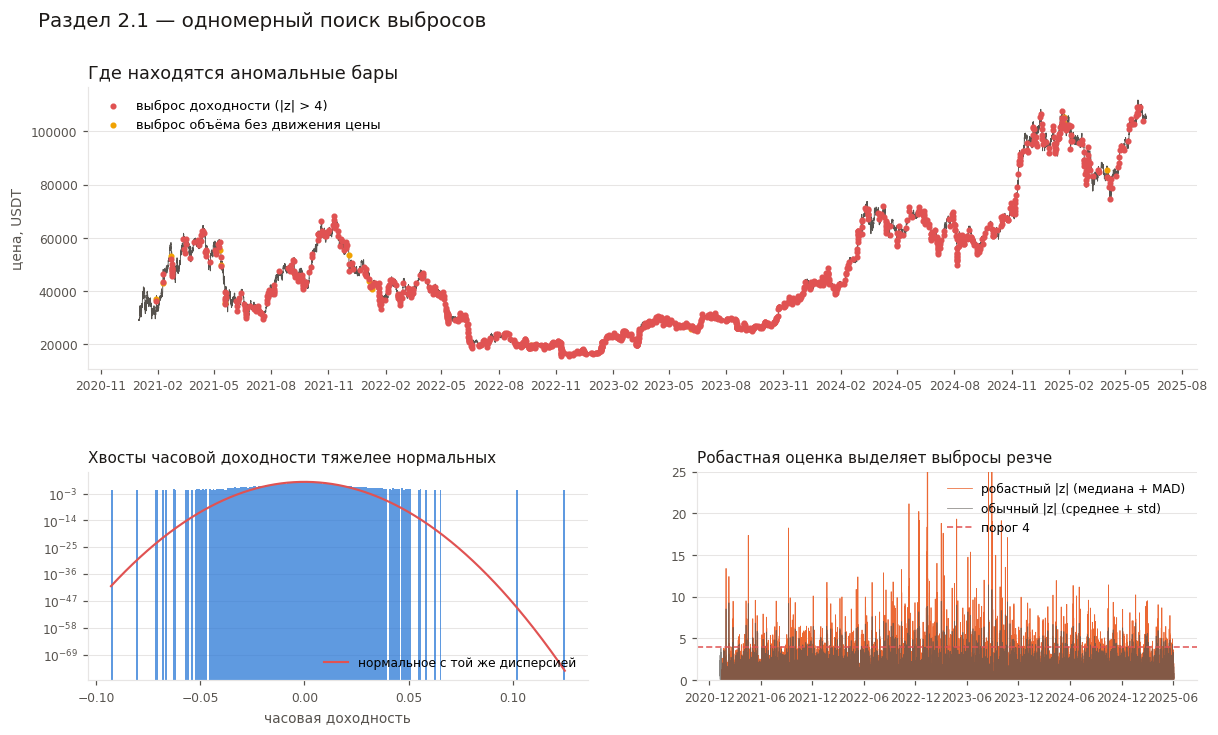

In [7]:
fig = plt.figure(figsize=(13, 7))
gs = fig.add_gridspec(2, 2, height_ratios=[1.35, 1], hspace=0.42, wspace=0.22)

# ── цена с отмеченными выбросами ────────────────────────────────────────────
ax = fig.add_subplot(gs[0, :])
ax.plot(raw["date"], raw["close"], color=INK_MUTED, linewidth=0.6, zorder=1)
out_idx = anom_flags["доходность"]
ax.scatter(raw.loc[out_idx, "date"], raw.loc[out_idx, "close"], s=9,
           color=DOWN, zorder=3, label=f"выброс доходности (|z| > {OUTLIER_Z:.0f})")
vol_only = anom_flags["объём"] & ~anom_flags["доходность"]
ax.scatter(raw.loc[vol_only, "date"], raw.loc[vol_only, "close"], s=9,
           color="#f0a202", zorder=2, label="выброс объёма без движения цены")
ax.set_title("Где находятся аномальные бары", color=INK, loc="left", fontsize=11.5)
ax.set_ylabel("цена, USDT", color=INK_MUTED, fontsize=9)
ax.legend(frameon=False, fontsize=8.5, loc="upper left")
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=3))
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m"))
style_ax(ax)

# ── распределение доходности против нормального ─────────────────────────────
ax = fig.add_subplot(gs[1, 0])
r = ret1.dropna()
ax.hist(r, bins=250, color=COLORS["LogisticRegression"], alpha=0.75, density=True, linewidth=0)
xs = np.linspace(r.min(), r.max(), 500)
ax.plot(xs, stats.norm.pdf(xs, r.mean(), r.std()), color=DOWN, linewidth=1.4,
        label="нормальное с той же дисперсией")
ax.set_yscale("log")
ax.set_title("Хвосты часовой доходности тяжелее нормальных", color=INK, loc="left", fontsize=10)
ax.set_xlabel("часовая доходность", color=INK_MUTED, fontsize=9)
ax.legend(frameon=False, fontsize=8)
style_ax(ax)

# ── robust z против обычного z ──────────────────────────────────────────────
ax = fig.add_subplot(gs[1, 1])
ax.plot(raw["date"], anom_z["доходность"].abs(), color=COLORS["DecisionTree"], linewidth=0.5,
        label="робастный |z| (медиана + MAD)")
ax.plot(raw["date"], zscore(ret1, ANOM_WIN).abs(), color=INK_MUTED, linewidth=0.5, alpha=0.7,
        label="обычный |z| (среднее + std)")
ax.axhline(OUTLIER_Z, color=DOWN, linewidth=1.0, linestyle=(0, (4, 2)),
           label=f"порог {OUTLIER_Z:.0f}")
ax.set_title("Робастная оценка выделяет выбросы резче", color=INK, loc="left", fontsize=10)
ax.set_ylim(0, 25)
ax.legend(frameon=False, fontsize=8)
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=6))
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m"))
style_ax(ax)

fig.suptitle("Раздел 2.1 — одномерный поиск выбросов", fontsize=13, color=INK, x=0.09, ha="left",
             y=0.98)
plt.show()

### 2.2 Многомерные аномалии: IsolationForest

Одномерные оценки не видят аномальных *сочетаний*: бар с обычной по величине доходностью, но
аномальным для неё объёмом и формой свечи, по каждому показателю в отдельности выглядит
нормальным. `IsolationForest` строит случайные деревья и измеряет, за сколько расщеплений
наблюдение удаётся отделить от остальных: выброс отделяется быстро.

Детектор обучается **только на обучающей части ряда** (первые 70%) и применяется ко всему ряду —
так же, как это происходило бы в реальной эксплуатации, когда будущего мы не знаем.

Порог аномальности (99-й перцентиль по train): 0.659
Помечено IsolationForest: 344 баров (0.89%)



IsolationForest,False,True
одномерный выброс,,
False,36895,32
True,1536,312


32 баров (0.08%) аномальны только как сочетание признаков — одномерные оценки их не видят.


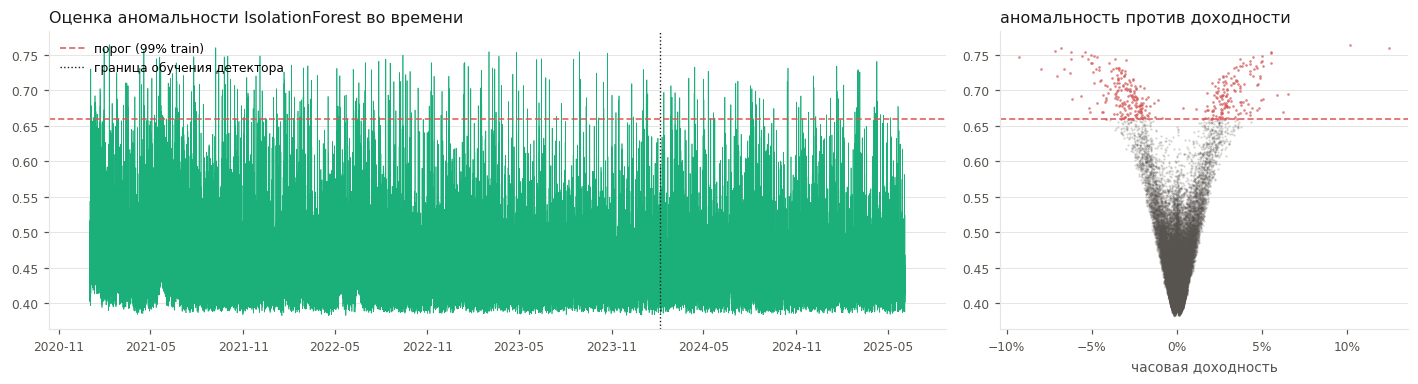

In [8]:
n_raw = len(raw)
train_bound = int(n_raw * TRAIN_END)

# компактный набор причинных характеристик бара
atr14_raw = wilder(true_range(raw["high"], raw["low"], raw["close"]), 14)
rng_raw = (raw["high"] - raw["low"]).replace(0, np.nan)
iso_input = pd.DataFrame({
    "ret": ret1,
    "abs_ret": ret1.abs(),
    "tr_atr": tr / atr14_raw.replace(0, np.nan),
    "vol_z": zscore(logv, ANOM_WIN),
    "body_frac": (raw["close"] - raw["open"]).abs() / rng_raw,
    "clv": ((raw["close"] - raw["low"]) - (raw["high"] - raw["close"])) / rng_raw,
}).replace([np.inf, -np.inf], np.nan)
iso_input = iso_input.ffill().bfill()

iso = IsolationForest(n_estimators=300, contamination=0.01, random_state=RANDOM_STATE, n_jobs=-1)
iso.fit(iso_input.iloc[:train_bound])
iso_score = pd.Series(-iso.score_samples(iso_input), index=raw.index)   # больше = аномальнее
iso_thr = float(np.quantile(iso_score.iloc[:train_bound], 0.99))
iso_flag = iso_score > iso_thr

overlap = pd.crosstab(is_outlier_any.rename("одномерный выброс"),
                      iso_flag.rename("IsolationForest"))
print(f"Порог аномальности (99-й перцентиль по train): {iso_thr:.3f}")
print(f"Помечено IsolationForest: {iso_flag.sum()} баров ({iso_flag.mean():.2%})\n")
display(overlap)
found_only_by_iso = int(((~is_outlier_any) & iso_flag).sum())
print(f"{found_only_by_iso} баров ({found_only_by_iso / len(raw):.2%}) аномальны только как "
      f"сочетание признаков — одномерные оценки их не видят.")

fig, axes = plt.subplots(1, 2, figsize=(13, 3.6), gridspec_kw={"width_ratios": [2.2, 1]})
axes[0].plot(raw["date"], iso_score, color=COLORS["CatBoost"], linewidth=0.45)
axes[0].axhline(iso_thr, color=DOWN, linewidth=1.0, linestyle=(0, (4, 2)), label="порог (99% train)")
axes[0].axvline(raw["date"].iloc[train_bound], color=INK, linewidth=0.9, linestyle=":",
                label="граница обучения детектора")
axes[0].set_title("Оценка аномальности IsolationForest во времени", color=INK, loc="left", fontsize=10.5)
axes[0].legend(frameon=False, fontsize=8, loc="upper left")
axes[0].xaxis.set_major_locator(mdates.MonthLocator(interval=6))
axes[0].xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m"))
style_ax(axes[0])

axes[1].scatter(ret1, iso_score, s=2, alpha=0.25, color=INK_MUTED, linewidth=0)
axes[1].scatter(ret1[iso_flag], iso_score[iso_flag], s=3, alpha=0.6, color=DOWN, linewidth=0)
axes[1].axhline(iso_thr, color=DOWN, linewidth=1.0, linestyle=(0, (4, 2)))
axes[1].set_xlabel("часовая доходность", color=INK_MUTED, fontsize=9)
axes[1].set_title("аномальность против доходности", color=INK, loc="left", fontsize=10.5)
axes[1].xaxis.set_major_formatter(PercentFormatter(xmax=1, decimals=0))
style_ax(axes[1])
fig.tight_layout()
plt.show()

Вертикальная «стенка» точек в правой панели показывает главное: высокая оценка аномальности
встречается и при доходности, близкой к нулю. Это как раз бары с аномальным объёмом или формой
свечи при спокойной цене — их одномерный фильтр по доходности пропускает.

Одна оговорка, без которой раздел вводил бы в заблуждение: **`IsolationForest` здесь —
диагностика, а не часть конвейера.** Его флаг не идёт в модель признаком и не влияет на веса
наблюдений. Причина в том же, из-за чего винзоризация считается внутри фолда: детектор обучен
на первых 70% ряда целиком, и внутри кросс-валидации его оценка для раннего фолда уже знала бы
о более поздних барах. Чтобы использовать её как признак честно, детектор пришлось бы
переобучать в каждом фолде. В модель идут только робастные z-оценки — они считаются скользящим
окном и причинны по построению.


## 3. Библиотека индикаторов технического анализа

In [9]:
def rsi(close, n=14):
    """Индекс относительной силы: отношение среднего роста к среднему падению за n баров."""
    d = close.diff()
    gain = wilder(d.clip(lower=0), n)
    loss = wilder((-d).clip(lower=0), n)
    out = 100 - 100 / (1 + gain / loss.where(loss > 0))
    # loss == 0: рост без падений -> 100; полный штиль -> нейтральные 50
    return out.where(loss > 0, np.where(gain > 0, 100.0, 50.0))


def atr(high, low, close, n=14):
    """Средний истинный диапазон — базовая мера волатильности в единицах цены."""
    return wilder(true_range(high, low, close), n)


def stochastic(high, low, close, n=14, d=3):
    """Стохастик: положение закрытия внутри диапазона последних n баров."""
    ll, hh = low.rolling(n).min(), high.rolling(n).max()
    k = 100 * (close - ll) / (hh - ll).replace(0, np.nan)
    return k, k.rolling(d).mean()


def macd(close, fast=12, slow=26, signal=9):
    """Схождение/расхождение скользящих средних: линия, сигнал и гистограмма."""
    line = close.ewm(span=fast, adjust=False).mean() - close.ewm(span=slow, adjust=False).mean()
    sig = line.ewm(span=signal, adjust=False).mean()
    return line, sig, line - sig


def adx(high, low, close, n=14):
    """Индекс направленного движения: сила тренда (ADX) и его направление (+DI / -DI)."""
    up, dn = high.diff(), -low.diff()
    plus_dm = pd.Series(np.where((up > dn) & (up > 0), up, 0.0), index=high.index)
    minus_dm = pd.Series(np.where((dn > up) & (dn > 0), dn, 0.0), index=high.index)
    tr_n = wilder(true_range(high, low, close), n).replace(0, np.nan)
    plus_di = 100 * wilder(plus_dm, n) / tr_n
    minus_di = 100 * wilder(minus_dm, n) / tr_n
    dx = 100 * (plus_di - minus_di).abs() / (plus_di + minus_di).replace(0, np.nan)
    return wilder(dx, n), plus_di, minus_di


def cci(high, low, close, n=20):
    """Индекс товарного канала: отклонение типичной цены от среднего в единицах среднего отклонения."""
    tp = (high + low + close) / 3
    sma = tp.rolling(n).mean()
    mad = (tp - sma).abs().rolling(n).mean()
    return (tp - sma) / (0.015 * mad.replace(0, np.nan))


def mfi(high, low, close, volume, n=14):
    """Индекс денежного потока — RSI, взвешенный объёмом."""
    tp = (high + low + close) / 3
    raw_flow = tp * volume
    up = raw_flow.where(tp > tp.shift(1), 0.0).rolling(n).sum()
    dn = raw_flow.where(tp < tp.shift(1), 0.0).rolling(n).sum()
    return 100 - 100 / (1 + up / dn.replace(0, np.nan))


def clv(high, low, close):
    """Close Location Value: положение закрытия внутри диапазона бара, от -1 до +1."""
    return ((close - low) - (high - close)) / (high - low).replace(0, np.nan)


def cmf(high, low, close, volume, n=20):
    """Денежный поток Чайкина: объём, взвешенный положением закрытия в баре."""
    return ((clv(high, low, close).fillna(0) * volume).rolling(n).sum()
            / volume.rolling(n).sum().replace(0, np.nan))


def obv(close, volume):
    """Балансовый объём: накопленный объём со знаком движения цены."""
    return (np.sign(close.diff().fillna(0)) * volume).cumsum()


def aroon(high, low, n=25):
    """Aroon: как давно был максимум и минимум окна (100 = прямо сейчас)."""
    hi = high.rolling(n + 1).apply(lambda x: float(np.argmax(x)), raw=True)
    lo = low.rolling(n + 1).apply(lambda x: float(np.argmin(x)), raw=True)
    return 100 * hi / n, 100 * lo / n


def efficiency_ratio(close, n=20):
    """Коэффициент эффективности Кауфмана: 1 — чистый тренд, 0 — «пила» без смещения."""
    direction = (close - close.shift(n)).abs()
    path = close.diff().abs().rolling(n).sum()
    return direction / path.replace(0, np.nan)


# демонстрация на последних сутках
demo = raw.tail(500).reset_index(drop=True)
_adx, _pdi, _mdi = adx(demo["high"], demo["low"], demo["close"])
demo_ind = pd.DataFrame({
    "RSI(14)": rsi(demo["close"]), "ATR(14)": atr(demo["high"], demo["low"], demo["close"]),
    "ADX(14)": _adx, "CCI(20)": cci(demo["high"], demo["low"], demo["close"]),
    "MFI(14)": mfi(demo["high"], demo["low"], demo["close"], demo["volume"]),
    "ER(20)": efficiency_ratio(demo["close"]),
}).tail(3).round(3)
print("Проверка индикаторов на последних барах ряда:")
display(demo_ind)

Проверка индикаторов на последних барах ряда:


,RSI(14),ATR(14),ADX(14),CCI(20),MFI(14),ER(20)
497,42.689,436.358,9.292,-171.830,26.001,0.198
498,38.841,445.883,9.505,-171.150,24.374,0.284
499,43.937,475.791,10.812,-186.071,20.272,0.225


## 4. Свечные паттерны

Реализовано 31 определение: однобарные (доджи, молот, перевёрнутый молот, падающая звезда,
повешенный, марубозу, волчок, «пояс», надгробие и стрекоза), двухбарные (бычье и медвежье
поглощение, харами, пронзающая линия, завеса из тёмных облаков, пинцеты, внутренний и внешний бар)
и трёхбарные (утренняя и вечерняя звезда, три белых солдата, три чёрные вороны, три внутри вверх/вниз).

In [10]:
def candle_anatomy(o_, h_, l_, c_):
    """Геометрия свечи: тело, тени и их доли в диапазоне бара."""
    rng = (h_ - l_).replace(0, np.nan)
    body = c_ - o_
    return pd.DataFrame({
        "rng": rng, "body": body, "abs_body": body.abs(),
        "upper": h_ - np.maximum(o_, c_), "lower": np.minimum(o_, c_) - l_,
        "body_frac": body.abs() / rng,
        "upper_frac": (h_ - np.maximum(o_, c_)) / rng,
        "lower_frac": (np.minimum(o_, c_) - l_) / rng,
        "clv": clv(h_, l_, c_),
    }, index=o_.index)


CANDLE_BULL = ["cdl_hammer", "cdl_inv_hammer", "cdl_dragonfly_doji", "cdl_marubozu_bull",
               "cdl_engulfing_bull", "cdl_harami_bull", "cdl_piercing", "cdl_tweezer_bottom",
               "cdl_morning_star", "cdl_three_white_soldiers", "cdl_three_inside_up",
               "cdl_belt_hold_bull", "cdl_outside_bar_bull"]
CANDLE_BEAR = ["cdl_hanging_man", "cdl_shooting_star", "cdl_gravestone_doji", "cdl_marubozu_bear",
               "cdl_engulfing_bear", "cdl_harami_bear", "cdl_dark_cloud", "cdl_tweezer_top",
               "cdl_evening_star", "cdl_three_black_crows", "cdl_three_inside_down",
               "cdl_belt_hold_bear", "cdl_outside_bar_bear"]
CANDLE_NEUTRAL = ["cdl_doji", "cdl_long_legged_doji", "cdl_spinning_top", "cdl_high_wave",
                  "cdl_inside_bar"]
CANDLE_ALL = CANDLE_BULL + CANDLE_BEAR + CANDLE_NEUTRAL

CANDLE_RU = {
    "cdl_hammer": "молот", "cdl_inv_hammer": "перевёрнутый молот",
    "cdl_dragonfly_doji": "доджи-стрекоза", "cdl_marubozu_bull": "марубозу бычий",
    "cdl_engulfing_bull": "бычье поглощение", "cdl_harami_bull": "харами бычий",
    "cdl_piercing": "пронзающая линия", "cdl_tweezer_bottom": "пинцет снизу",
    "cdl_morning_star": "утренняя звезда", "cdl_three_white_soldiers": "три белых солдата",
    "cdl_three_inside_up": "три внутри вверх", "cdl_belt_hold_bull": "бычий пояс",
    "cdl_outside_bar_bull": "внешний бар бычий", "cdl_hanging_man": "повешенный",
    "cdl_shooting_star": "падающая звезда", "cdl_gravestone_doji": "доджи-надгробие",
    "cdl_marubozu_bear": "марубозу медвежий", "cdl_engulfing_bear": "медвежье поглощение",
    "cdl_harami_bear": "харами медвежий", "cdl_dark_cloud": "завеса из тёмных облаков",
    "cdl_tweezer_top": "пинцет сверху", "cdl_evening_star": "вечерняя звезда",
    "cdl_three_black_crows": "три чёрные вороны", "cdl_three_inside_down": "три внутри вниз",
    "cdl_belt_hold_bear": "медвежий пояс", "cdl_outside_bar_bear": "внешний бар медвежий",
    "cdl_doji": "доджи", "cdl_long_legged_doji": "длинноногий доджи",
    "cdl_spinning_top": "волчок", "cdl_high_wave": "высокая волна",
    "cdl_inside_bar": "внутренний бар",
}


def candlestick_patterns(o_, h_, l_, c_, atr_s, trend_win=10):
    """31 свечной паттерн в виде бинарных признаков (0/1)."""
    a = candle_anatomy(o_, h_, l_, c_)
    rng, body, upper, lower = a["rng"], a["abs_body"], a["upper"], a["lower"]
    bull, bear = c_ > o_, c_ < o_
    body_atr = body / atr_s.replace(0, np.nan)

    o1, h1, l1, c1 = o_.shift(1), h_.shift(1), l_.shift(1), c_.shift(1)
    o2, c2 = o_.shift(2), c_.shift(2)
    bull1, bear1 = c1 > o1, c1 < o1
    bull2, bear2 = c2 > o2, c2 < o2
    body1, body2 = (c1 - o1).abs(), (c2 - o2).abs()
    rng1 = (h1 - l1).replace(0, np.nan)

    prior = c_.shift(1) / c_.shift(1 + trend_win) - 1        # тренд ДО текущего бара
    downtrend, uptrend = prior < 0, prior > 0

    long_body = body_atr > 0.8
    small_body = a["body_frac"] < 0.30
    doji_body = a["body_frac"] < 0.10

    p = {}
    # ── однобарные ───────────────────────────────────────────────────────────
    p["cdl_doji"] = doji_body
    p["cdl_long_legged_doji"] = doji_body & (upper > 0.3 * rng) & (lower > 0.3 * rng)
    p["cdl_dragonfly_doji"] = doji_body & (lower > 0.6 * rng) & (upper < 0.1 * rng)
    p["cdl_gravestone_doji"] = doji_body & (upper > 0.6 * rng) & (lower < 0.1 * rng)
    p["cdl_spinning_top"] = small_body & (upper > body) & (lower > body) & ~doji_body
    p["cdl_high_wave"] = small_body & ((upper + lower) / rng > 0.8) & (rng / atr_s > 1.5)

    hammer_shape = (lower >= 2 * body) & (upper <= 0.25 * body.where(body > 0, rng)) & (a["body_frac"] < 0.4)
    star_shape = (upper >= 2 * body) & (lower <= 0.25 * body.where(body > 0, rng)) & (a["body_frac"] < 0.4)
    p["cdl_hammer"] = hammer_shape & downtrend            # та же форма, что и повешенный,
    p["cdl_hanging_man"] = hammer_shape & uptrend         # различает только тренд до неё
    p["cdl_inv_hammer"] = star_shape & downtrend
    p["cdl_shooting_star"] = star_shape & uptrend
    p["cdl_marubozu_bull"] = bull & (a["body_frac"] > 0.90) & long_body
    p["cdl_marubozu_bear"] = bear & (a["body_frac"] > 0.90) & long_body
    p["cdl_belt_hold_bull"] = bull & (a["lower_frac"] < 0.05) & (a["body_frac"] > 0.7) & downtrend
    p["cdl_belt_hold_bear"] = bear & (a["upper_frac"] < 0.05) & (a["body_frac"] > 0.7) & uptrend

    # ── двухбарные ───────────────────────────────────────────────────────────
    p["cdl_engulfing_bull"] = bear1 & bull & (c_ >= o1) & (o_ <= c1) & (body > body1)
    p["cdl_engulfing_bear"] = bull1 & bear & (o_ >= c1) & (c_ <= o1) & (body > body1)
    p["cdl_harami_bull"] = bear1 & bull & (c_ <= o1) & (o_ >= c1) & (body < 0.6 * body1) & (body1 / atr_s > 0.8)
    p["cdl_harami_bear"] = bull1 & bear & (o_ <= c1) & (c_ >= o1) & (body < 0.6 * body1) & (body1 / atr_s > 0.8)
    # условие гэпа ослаблено до нестрогого: на крипторынке разрывов практически не бывает
    p["cdl_piercing"] = bear1 & bull & (o_ <= c1) & (c_ > (o1 + c1) / 2) & (c_ < o1) & (body1 / atr_s > 0.6)
    p["cdl_dark_cloud"] = bull1 & bear & (o_ >= c1) & (c_ < (o1 + c1) / 2) & (c_ > o1) & (body1 / atr_s > 0.6)
    tw_tol = 0.05 * atr_s
    p["cdl_tweezer_bottom"] = bear1 & bull & ((l_ - l1).abs() < tw_tol) & downtrend
    p["cdl_tweezer_top"] = bull1 & bear & ((h_ - h1).abs() < tw_tol) & uptrend
    p["cdl_inside_bar"] = (h_ < h1) & (l_ > l1)
    p["cdl_outside_bar_bull"] = (h_ > h1) & (l_ < l1) & bull
    p["cdl_outside_bar_bear"] = (h_ > h1) & (l_ < l1) & bear

    # ── трёхбарные ───────────────────────────────────────────────────────────
    small1 = body1 < 0.5 * body2
    p["cdl_morning_star"] = (bear2 & (body2 / atr_s > 0.8) & small1 & bull &
                             (c_ > (o2 + c2) / 2) & (c1 < c2))
    p["cdl_evening_star"] = (bull2 & (body2 / atr_s > 0.8) & small1 & bear &
                             (c_ < (o2 + c2) / 2) & (c1 > c2))
    p["cdl_three_white_soldiers"] = (bull2 & bull1 & bull & (c_ > c1) & (c1 > c2) &
                                     ((c1 - o1).abs() / rng1 > 0.6) & (a["body_frac"] > 0.6))
    p["cdl_three_black_crows"] = (bear2 & bear1 & bear & (c_ < c1) & (c1 < c2) &
                                  ((c1 - o1).abs() / rng1 > 0.6) & (a["body_frac"] > 0.6))
    p["cdl_three_inside_up"] = bear2 & bull1 & bull & (c1 <= o2) & (o1 >= c2) & (c_ > o2)
    p["cdl_three_inside_down"] = bull2 & bear1 & bear & (o1 <= c2) & (c1 >= o2) & (c_ < o2)

    return pd.DataFrame(p, index=o_.index).fillna(False).astype(np.int8)[CANDLE_ALL], a


atr14 = atr(raw["high"], raw["low"], raw["close"], 14)
cdl = candlestick_patterns(raw["open"], raw["high"], raw["low"], raw["close"], atr14)[0]

cdl_freq = pd.DataFrame({
    "паттерн": [CANDLE_RU[c] for c in cdl.columns],
    "тип": ["бычий" if c in CANDLE_BULL else "медвежий" if c in CANDLE_BEAR else "нейтральный"
            for c in cdl.columns],
    "срабатываний": cdl.sum().to_numpy(),
    "частота, %": (cdl.mean() * 100).round(2).to_numpy(),
}, index=cdl.columns).sort_values("срабатываний", ascending=False)
print(f"Распознано {len(cdl.columns)} свечных паттернов, "
      f"{int(cdl.sum().sum())} срабатываний на {len(cdl)} барах")
display(cdl_freq)

Распознано 31 свечных паттернов, 45780 срабатываний на 38775 барах


,паттерн,тип,срабатываний,"частота, %"
cdl_inside_bar,внутренний бар,нейтральный,7273,18.76
cdl_spinning_top,волчок,нейтральный,5056,13.04
cdl_engulfing_bull,бычье поглощение,бычий,4916,12.68
cdl_engulfing_bear,медвежье поглощение,медвежий,4772,12.31
cdl_doji,доджи,нейтральный,4174,10.76
cdl_long_legged_doji,длинноногий доджи,нейтральный,2004,5.17
cdl_outside_bar_bull,внешний бар бычий,бычий,1934,4.99
cdl_outside_bar_bear,внешний бар медвежий,медвежий,1843,4.75
cdl_three_inside_down,три внутри вниз,медвежий,1469,3.79
cdl_three_inside_up,три внутри вверх,бычий,1413,3.64


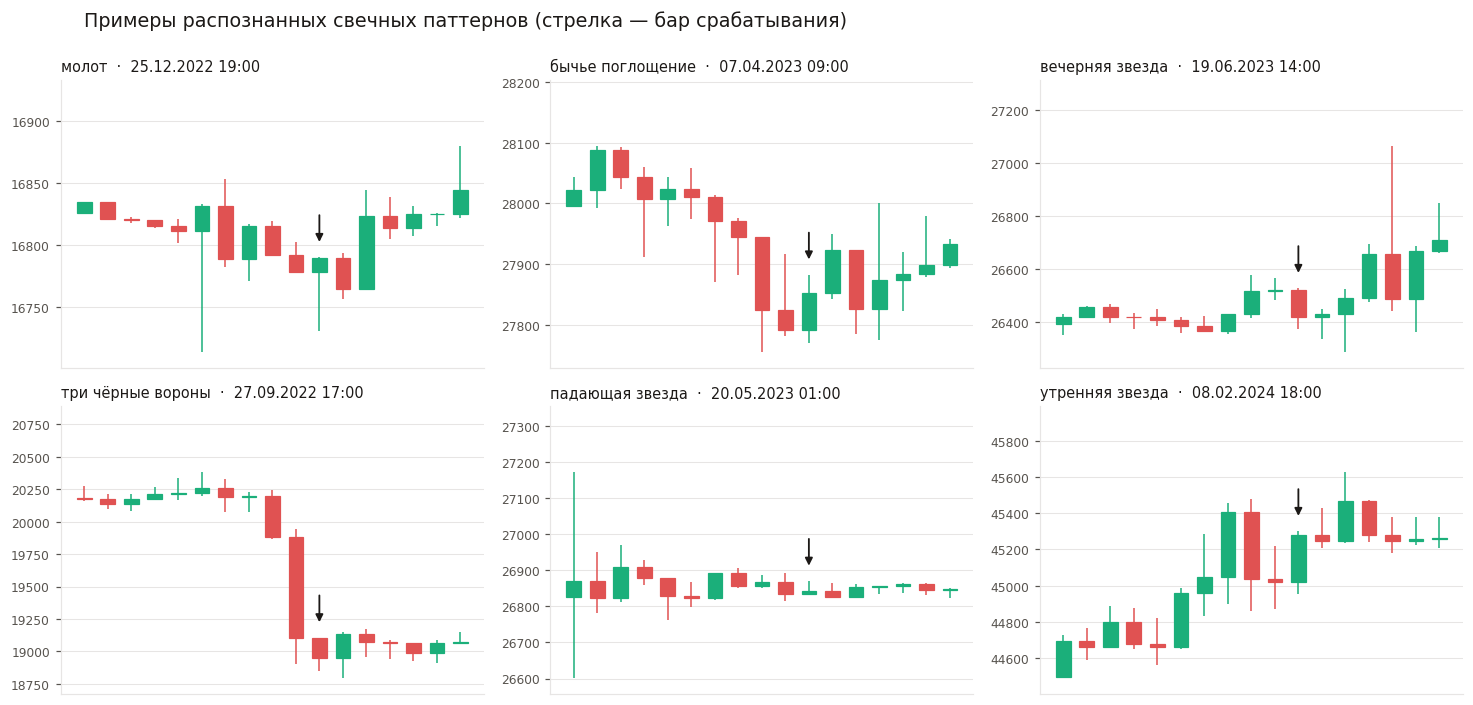

In [11]:
def plot_candles(ax, df, width=0.62):
    """Рисует японские свечи по срезу OHLC."""
    x = np.arange(len(df))
    up = df["close"].to_numpy() >= df["open"].to_numpy()
    colors = np.where(up, UP, DOWN)
    ax.vlines(x, df["low"], df["high"], color=colors, linewidth=1.0)
    for xi, (op, cl, col) in enumerate(zip(df["open"], df["close"], colors)):
        lo, height = min(op, cl), abs(cl - op)
        ax.add_patch(Rectangle((xi - width / 2, lo), width, max(height, 1e-9),
                               facecolor=col, edgecolor=col, linewidth=0.8))
    ax.set_xlim(-1, len(df))
    return x


SHOWCASE = ["cdl_hammer", "cdl_engulfing_bull", "cdl_evening_star", "cdl_three_black_crows",
            "cdl_shooting_star", "cdl_morning_star"]
fig, axes = plt.subplots(2, 3, figsize=(13.5, 6.4))
for ax, name in zip(axes.ravel(), SHOWCASE):
    hits = np.flatnonzero(cdl[name].to_numpy())
    hits = hits[(hits > 12) & (hits < len(raw) - 8)]
    i = int(hits[len(hits) // 2])                     # типичный, а не самый яркий пример
    window = raw.iloc[i - 10:i + 7].reset_index(drop=True)
    plot_candles(ax, window)
    span = window["high"].max() - window["low"].min()
    ax.annotate("", xy=(10, window["high"].iloc[10] + span * 0.06),
                xytext=(10, window["high"].iloc[10] + span * 0.22),
                arrowprops=dict(arrowstyle="-|>", color=INK, linewidth=1.2))
    ax.set_ylim(window["low"].min() - span * 0.08, window["high"].max() + span * 0.32)
    ax.set_title(f"{CANDLE_RU[name]}  ·  {raw['date'].iloc[i]:%d.%m.%Y %H:%M}",
                 color=INK, fontsize=9.5, loc="left")
    ax.set_xticks([])
    style_ax(ax)
fig.suptitle("Примеры распознанных свечных паттернов (стрелка — бар срабатывания)",
             fontsize=12.5, color=INK, x=0.06, ha="left", y=0.995)
fig.tight_layout()
plt.show()

## 5. Паттерны разворота на свинг-точках

Графические паттерны строятся не по отдельным свечам, а по **свинг-экстремумам** (фракталам):
бар считается свинг-максимумом, если его `high` — наибольший в окне ±`PIVOT_W` баров.

Здесь скрыта главная ловушка технического анализа в машинном обучении. Центрированное окно
заглядывает вперёд: чтобы узнать, что бар был вершиной, нужно дождаться `PIVOT_W` последующих
баров. Если поставить флаг «вершина» прямо на бар экстремума, модель получит знание из
будущего, ROC-AUC подскочит, а в реальной торговле стратегия развалится. Поэтому каждый
экстремум сдвигается вперёд на `PIVOT_W` баров: признак появляется **в момент подтверждения**,
то есть тогда же, когда его увидел бы трейдер.

На подтверждённых экстремумах распознаются: двойная и тройная вершина/дно, голова и плечи
(и перевёрнутая), последовательности higher high / lower low, дивергенции RSI, а также
рассчитываются расстояния до ближайших уровней поддержки и сопротивления в единицах ATR.

In [12]:
def swing_points(high, low, w=PIVOT_W):
    """Свинг-экстремумы, сдвинутые на w баров вперёд — к моменту их подтверждения."""
    is_ph = (high == high.rolling(2 * w + 1, center=True).max()) & high.notna()
    is_pl = (low == low.rolling(2 * w + 1, center=True).min()) & low.notna()
    return high.where(is_ph).shift(w), low.where(is_pl).shift(w)


def chart_patterns(high, low, close, rsi_s, atr_s, w=PIVOT_W, tol=0.02, depth=0.02):
    """Паттерны разворота по подтверждённым свинг-точкам + уровни поддержки/сопротивления."""
    ph_price, pl_price = swing_points(high, low, w)
    names = ["pat_double_top", "pat_double_bottom", "pat_triple_top", "pat_triple_bottom",
             "pat_head_shoulders", "pat_inv_head_shoulders",
             "pat_bear_divergence", "pat_bull_divergence",
             "pat_higher_high", "pat_lower_high", "pat_higher_low", "pat_lower_low"]
    out = {k: np.zeros(len(close), dtype=np.int8) for k in names}

    hi_idx, hi_val = ph_price.dropna().index.to_numpy(), ph_price.dropna().to_numpy()
    lo_idx, lo_val = pl_price.dropna().index.to_numpy(), pl_price.dropna().to_numpy()
    rsi_arr = rsi_s.to_numpy()
    hi_rsi = rsi_arr[np.maximum(hi_idx - w, 0)]        # RSI в самой точке экстремума
    lo_rsi = rsi_arr[np.maximum(lo_idx - w, 0)]

    for k in range(1, len(hi_idx)):
        i, p1, p2 = hi_idx[k], hi_val[k - 1], hi_val[k]
        out["pat_higher_high"][i] = int(p2 > p1)
        out["pat_lower_high"][i] = int(p2 < p1)
        if abs(p2 - p1) / p1 <= tol:                                  # две сопоставимые вершины
            trough = lo_val[(lo_idx > hi_idx[k - 1]) & (lo_idx < i)]  # и впадина между ними
            if len(trough) and (min(p1, p2) - trough.min()) / min(p1, p2) >= depth:
                out["pat_double_top"][i] = 1
                if k >= 2 and abs(hi_val[k - 2] - p1) / p1 <= tol:
                    out["pat_triple_top"][i] = 1
        if p2 > p1 and hi_rsi[k] < hi_rsi[k - 1] - 1:                 # цена выше, RSI ниже
            out["pat_bear_divergence"][i] = 1
        if k >= 2:
            s1, head, s2 = hi_val[k - 2], hi_val[k - 1], p2
            if head > s1 and head > s2 and abs(s1 - s2) / s1 <= 1.5 * tol:
                out["pat_head_shoulders"][i] = 1

    for k in range(1, len(lo_idx)):
        i, p1, p2 = lo_idx[k], lo_val[k - 1], lo_val[k]
        out["pat_higher_low"][i] = int(p2 > p1)
        out["pat_lower_low"][i] = int(p2 < p1)
        if abs(p2 - p1) / p1 <= tol:
            peak = hi_val[(hi_idx > lo_idx[k - 1]) & (hi_idx < i)]
            if len(peak) and (peak.max() - max(p1, p2)) / max(p1, p2) >= depth:
                out["pat_double_bottom"][i] = 1
                if k >= 2 and abs(lo_val[k - 2] - p1) / p1 <= tol:
                    out["pat_triple_bottom"][i] = 1
        if p2 < p1 and lo_rsi[k] > lo_rsi[k - 1] + 1:
            out["pat_bull_divergence"][i] = 1
        if k >= 2:
            s1, head, s2 = lo_val[k - 2], lo_val[k - 1], p2
            if head < s1 and head < s2 and abs(s1 - s2) / s1 <= 1.5 * tol:
                out["pat_inv_head_shoulders"][i] = 1

    last_ph, last_pl = ph_price.ffill(), pl_price.ffill()
    levels = pd.DataFrame({
        "dist_resistance_atr": (last_ph - close) / atr_s,
        "dist_support_atr": (close - last_pl) / atr_s,
        "pivot_range_atr": (last_ph - last_pl) / atr_s,
        "pos_in_pivot_range": (close - last_pl) / (last_ph - last_pl).replace(0, np.nan),
    }, index=close.index)
    return pd.DataFrame(out, index=close.index), levels


PATTERN_RU = {
    "key_reversal_up": "ключевой разворот вверх", "key_reversal_dn": "ключевой разворот вниз",
    "breakout_up_20": "пробой канала вверх", "breakout_dn_20": "пробой канала вниз",
    "cdl_net_score": "перевес бычьих свечей", "cdl_net_score_6": "перевес бычьих свечей за 6 ч",
    "cdl_bull_score": "число бычьих свечных сигналов", "cdl_bear_score": "число медвежьих свечных сигналов",
    "pat_double_top": "двойная вершина", "pat_double_bottom": "двойное дно",
    "pat_triple_top": "тройная вершина", "pat_triple_bottom": "тройное дно",
    "pat_head_shoulders": "голова и плечи", "pat_inv_head_shoulders": "перевёрнутые голова и плечи",
    "pat_bear_divergence": "медвежья дивергенция RSI", "pat_bull_divergence": "бычья дивергенция RSI",
    "pat_higher_high": "higher high", "pat_lower_high": "lower high",
    "pat_higher_low": "higher low", "pat_lower_low": "lower low",
    "pat_bull_flag": "бычий флаг", "pat_bear_flag": "медвежий флаг", "pat_pennant": "вымпел",
}

rsi14_raw = rsi(raw["close"], 14)
chart_pat, sr_levels = chart_patterns(raw["high"], raw["low"], raw["close"], rsi14_raw, atr14)
display(pd.DataFrame({
    "паттерн": [PATTERN_RU[c] for c in chart_pat.columns],
    "срабатываний": chart_pat.sum().to_numpy(),
    "частота, %": (chart_pat.mean() * 100).round(2).to_numpy(),
}, index=chart_pat.columns).sort_values("срабатываний", ascending=False))

,паттерн,срабатываний,"частота, %"
pat_higher_low,higher low,1380,3.56
pat_lower_high,lower high,1314,3.39
pat_higher_high,higher high,1246,3.21
pat_lower_low,lower low,1180,3.04
pat_double_top,двойная вершина,623,1.61
pat_double_bottom,двойное дно,576,1.49
pat_head_shoulders,голова и плечи,563,1.45
pat_inv_head_shoulders,перевёрнутые голова и плечи,549,1.42
pat_triple_top,тройная вершина,410,1.06
pat_triple_bottom,тройное дно,381,0.98


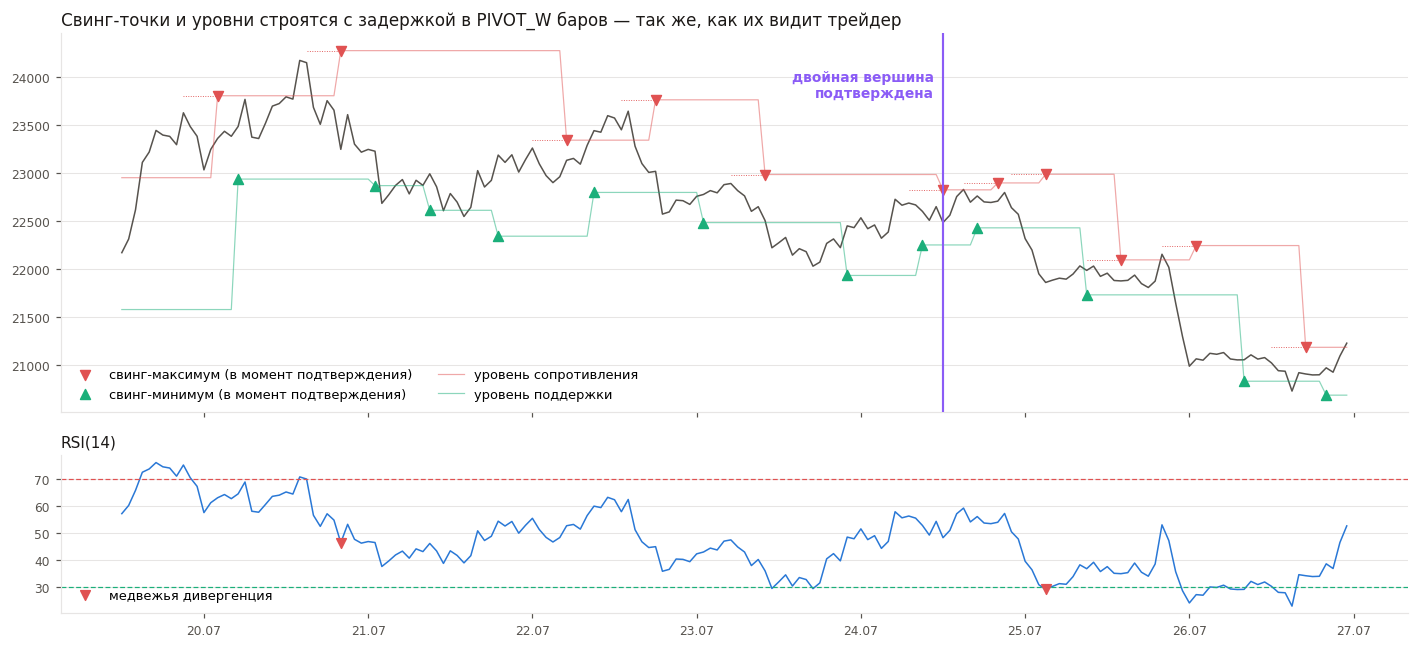

In [13]:
# Иллюстрация: свинг-точки, уровни и подтверждённая двойная вершина.
ph_p, pl_p = swing_points(raw["high"], raw["low"])
dt_hits = np.flatnonzero(chart_pat["pat_double_top"].to_numpy())
i = int(dt_hits[len(dt_hits) // 2])
seg = raw.iloc[i - 120:i + 60]
x = seg["date"]

fig, (ax, ax2) = plt.subplots(2, 1, figsize=(13, 6), sharex=True,
                              gridspec_kw={"height_ratios": [2.4, 1]})
ax.plot(x, seg["close"], color=INK_MUTED, linewidth=1.0, zorder=1)
conf_h = seg.index[ph_p.loc[seg.index].notna()]
conf_l = seg.index[pl_p.loc[seg.index].notna()]
ax.scatter(raw.loc[conf_h, "date"], ph_p.loc[conf_h], marker="v", s=42, color=DOWN,
           zorder=3, label="свинг-максимум (в момент подтверждения)")
ax.scatter(raw.loc[conf_l, "date"], pl_p.loc[conf_l], marker="^", s=42, color=UP,
           zorder=3, label="свинг-минимум (в момент подтверждения)")
for j in conf_h:                                        # поводок от подтверждения к самому экстремуму
    ax.plot([raw["date"].iloc[j - PIVOT_W], raw["date"].iloc[j]],
            [raw["high"].iloc[j - PIVOT_W], ph_p.loc[j]], color=DOWN, linewidth=0.6,
            linestyle=":", zorder=2)
ax.axvline(raw["date"].iloc[i], color=COLORS["Ensemble"], linewidth=1.4, zorder=4)
ax.annotate("двойная вершина\nподтверждена", xy=(raw["date"].iloc[i], seg["close"].max()),
            xytext=(-6, -6), textcoords="offset points", ha="right", va="top",
            fontsize=9, color=COLORS["Ensemble"], fontweight="bold")
ax.plot(x, sr_levels.loc[seg.index, "dist_resistance_atr"] * atr14.loc[seg.index] + seg["close"],
        color=DOWN, linewidth=0.8, alpha=0.5, label="уровень сопротивления")
ax.plot(x, seg["close"] - sr_levels.loc[seg.index, "dist_support_atr"] * atr14.loc[seg.index],
        color=UP, linewidth=0.8, alpha=0.5, label="уровень поддержки")
ax.set_title("Свинг-точки и уровни строятся с задержкой в PIVOT_W баров — так же, как их видит трейдер",
             color=INK, loc="left", fontsize=11)
ax.legend(frameon=False, fontsize=8.5, loc="lower left", ncol=2)
style_ax(ax)

ax2.plot(x, rsi14_raw.loc[seg.index], color=COLORS["LogisticRegression"], linewidth=1.0)
ax2.axhline(70, color=DOWN, linewidth=0.8, linestyle=(0, (4, 2)))
ax2.axhline(30, color=UP, linewidth=0.8, linestyle=(0, (4, 2)))
div = seg.index[chart_pat.loc[seg.index, "pat_bear_divergence"] > 0]
ax2.scatter(raw.loc[div, "date"], rsi14_raw.loc[div], s=40, color=DOWN, marker="v", zorder=3,
            label="медвежья дивергенция")
ax2.set_title("RSI(14)", color=INK, loc="left", fontsize=10)
ax2.legend(frameon=False, fontsize=8.5, loc="lower left")
ax2.xaxis.set_major_formatter(mdates.DateFormatter("%d.%m"))
style_ax(ax2)
fig.tight_layout()
plt.show()

## 6. Паттерны продолжения

Разворотные паттерны отвечают на вопрос «не закончился ли тренд». Паттерны продолжения —
на обратный: «тренд взял паузу или всё-таки развернулся». Реализованы:

- **пробой канала Дончиана** (`breakout_up/dn`) — закрытие выше максимума / ниже минимума
  предыдущих N баров; классический сигнал продолжения тренда;
- **флаг и вымпел** — сильный импульс (движение больше 2 ATR за 12 баров), после которого
  диапазон сжимается, а объём падает; это консолидация внутри тренда, а не разворот;
- **сжатие волатильности** (`bb_squeeze`, `ttm_squeeze`) — ширина полос Боллинджера в нижнем
  квинтиле недельного распределения либо полосы внутри канала Кельтнера; за сжатием обычно
  следует направленное движение;
- **коэффициент эффективности Кауфмана** — доля направленного движения в общем пути цены;
- **серии** — сколько баров подряд цена держится выше EMA20, длина серии внутренних баров,
  длина серии однонаправленных баров.

## 7. Сборка признаков

Все признаки собираются в один датафрейм и группируются по смыслу. К десяти группам
технического анализа здесь добавляются четыре новые: «Фурье», «вейвлет», «CWT» и «новости».

### 7.1 Признаки преобразования Фурье и вейвлет-разложения

Все 246 признаков предыдущего раздела описывают ряд **во временной области**: уровень, наклон,
размах, положение относительно уровней. Ни один из них не отвечает на вопрос, **как энергия
движения распределена по масштабам** — сколько в последней неделе от быстрых колебаний с
периодом в пару часов, а сколько от медленного дрейфа. Это и добавляют два преобразования.

**Преобразование Фурье** раскладывает окно на синусоиды и даёт распределение энергии по
частотам. Из спектра берутся не сами гармоники (их амплитуды на финансовом ряде — шум), а
**форма спектра**: доли энергии в частотных полосах, спектральная энтропия и плоскостность,
наклон спектра в логарифмических координатах, доминирующий период и скорость изменения спектра
от бара к бару.

**Вейвлет-разложение** решает ту же задачу, но не теряет привязку ко времени: коэффициент уровня
`Dj` говорит, что происходило на масштабе `2^j` баров **в конкретный момент**. Отсюда —
распределение энергии по уровням, вейвлет-энтропия, последние коэффициенты каждого уровня
(многомасштабный аналог импульса) и отклонение цены от вейвлет-сглаженного тренда.

**Главная опасность здесь — заглядывание в будущее, и она не теоретическая.** Классическая
ошибка выглядит так: применить `fft` или `wavedec` ко **всему ряду** и разложить коэффициенты
обратно по времени. Каждый коэффициент такого разложения зависит от всего ряда, включая будущее,
поэтому признак на баре `t` знает, что случится после `t`. ROC-AUC от этого подскакивает до
0.9, а стратегия рассыпается в реальной торговле.

Поэтому здесь всё считается **на скользящем окне, заканчивающемся на баре `t`**: окно
`[t-W+1 ... t]`, преобразование внутри окна, признак — характеристика этого окна. Краевые
эффекты (симметричное продолжение вейвлета, окно Ханна у Фурье) тоже задействуют только бары
внутри окна. Проверка на утечку из раздела 7.4 пересчитывает все признаки на обрезанном ряде и
сравнивает с полным — если бы хоть один из новых признаков подглядывал, тест бы это поймал.

**Что подаётся на вход.** Спектральные признаки считаются по **логарифмическим доходностям**,
а не по ценам: спектр нестационарного ряда цен — это почти целиком гигантский пик на нулевой
частоте, и всё остальное тонет в нём. Признаки тренда — по логарифму цены, потому что именно там
тренд и живёт.

| семейство | окно | вход | что извлекается |
|---|---|---|---|
| Фурье | 168 ч (неделя) и 512 ч (три недели) | лог-доходности | доли энергии в 5 полосах периодов, энтропия, плоскостность, наклон спектра, доминирующий период и его доля, спектральный поток |
| вейвлет | 256 ч | лог-доходности | доли энергии по уровням D1–D5 и A5, вейвлет-энтропия, отношение высоких частот к низким, последние коэффициенты уровней, доля шума по универсальному порогу |
| вейвлет | 256 ч | логарифм цены | отклонение от сглаженного тренда и наклон тренда |

In [14]:
import pywt

FFT_WINDOWS = (168, 512)       # неделя и три недели часовых баров
FFT_BANDS = ((2, 4), (4, 8), (8, 24), (24, 72), (72, None))   # полосы по периоду, в часах
WAVELET_WINDOW = 256           # степень двойки: чистое разложение на 5 уровней
WAVELET_NAME = "db4"           # Добеши-4: компромисс между гладкостью и длиной фильтра
WAVELET_LEVEL = 5              # D1..D5 покрывают периоды примерно от 2 до 64 баров
WAVELET_MODE = "symmetric"     # краевое продолжение — только барами внутри окна


def rolling_matrix(series, w):
    """Матрица окон: строка i — бары [i ... i+w-1] исходного ряда.

    Результат короче ряда на w-1: у первых баров окна ещё нет. Выравнивание к бару t
    делает `align_to_bars` — здесь возвращается «сырое» представление без копий.
    """
    a = np.nan_to_num(np.asarray(series, dtype=np.float64), nan=0.0, posinf=0.0, neginf=0.0)
    return np.lib.stride_tricks.sliding_window_view(a, w)


def align_to_bars(values, w, index):
    """Признак окна, заканчивающегося на баре t, кладётся в позицию t. Первые w-1 баров — NaN."""
    return pd.Series(np.concatenate([np.full(w - 1, np.nan), np.asarray(values, float)]),
                     index=index)


def fourier_features(logret, index):
    """Форма спектра скользящего окна лог-доходностей.

    Берутся характеристики распределения энергии по частотам, а не сами гармоники: амплитуда
    отдельной гармоники на финансовом ряде неустойчива и от окна к окну скачет, а форма
    спектра — устойчивая характеристика режима.
    """
    cols = {}
    for w in FFT_WINDOWS:
        win = rolling_matrix(logret, w)
        win = win - win.mean(axis=1, keepdims=True)          # снимаем среднее окна
        # окно Ханна: без него резкий обрыв на краях «размазывает» энергию по всему спектру
        spec = np.abs(np.fft.rfft(win * np.hanning(w), axis=1)) ** 2
        spec, freqs = spec[:, 1:], np.fft.rfftfreq(w)[1:]    # нулевая частота — это среднее
        periods = 1.0 / freqs
        total = spec.sum(axis=1) + 1e-300
        p = spec / total[:, None]

        for lo, hi in FFT_BANDS:
            mask = (periods >= lo) & (periods < (hi if hi is not None else np.inf))
            name = f"fft{w}_e_{lo}_{hi}" if hi is not None else f"fft{w}_e_{lo}p"
            cols[name] = align_to_bars(p[:, mask].sum(axis=1), w, index)

        # энтропия спектра: 1 — энергия размазана ровно (белый шум), 0 — вся в одной частоте
        cols[f"fft{w}_entropy"] = align_to_bars(
            -(p * np.log(p + 1e-300)).sum(axis=1) / np.log(p.shape[1]), w, index)
        # плоскостность (мера Винера): отношение среднего геометрического к арифметическому
        cols[f"fft{w}_flatness"] = align_to_bars(
            np.exp(np.log(spec + 1e-300).mean(axis=1)) / (spec.mean(axis=1) + 1e-300), w, index)
        # наклон спектра в логарифмических координатах: показатель степени в законе 1/f^a
        xc = np.log(freqs) - np.log(freqs).mean()
        yc = np.log(spec + 1e-300)
        yc = yc - yc.mean(axis=1, keepdims=True)
        cols[f"fft{w}_slope"] = align_to_bars((yc @ xc) / (xc @ xc), w, index)
        # доминирующий период и его доля в энергии
        cols[f"fft{w}_dom_period"] = align_to_bars(np.log(periods[p.argmax(axis=1)]), w, index)
        cols[f"fft{w}_dom_share"] = align_to_bars(p.max(axis=1), w, index)
        # спектральный поток: насколько форма спектра изменилась за бар
        flux = np.concatenate([[np.nan], np.sqrt(((p[1:] - p[:-1]) ** 2).sum(axis=1))])
        cols[f"fft{w}_flux"] = align_to_bars(flux, w, index)
    return cols


def wavelet_features(logret, logprice, index):
    """Многомасштабное разложение скользящего окна: энергия по уровням и вейвлет-тренд."""
    w = WAVELET_WINDOW
    win_r = rolling_matrix(logret, w)
    coeffs = pywt.wavedec(win_r, WAVELET_NAME, level=WAVELET_LEVEL, axis=1, mode=WAVELET_MODE)
    names = ["a5", "d5", "d4", "d3", "d2", "d1"]             # порядок, в котором отдаёт wavedec
    energy = np.stack([(c ** 2).sum(axis=1) for c in coeffs], axis=1)
    rel = energy / (energy.sum(axis=1, keepdims=True) + 1e-300)

    cols = {}
    for j, nm in enumerate(names):
        cols[f"wl_e_{nm}"] = align_to_bars(rel[:, j], w, index)
    cols["wl_entropy"] = align_to_bars(
        -(rel * np.log(rel + 1e-300)).sum(axis=1) / np.log(len(names)), w, index)
    # быстрые масштабы против медленных: растёт, когда рынок «дрожит», а не движется
    cols["wl_hf_lf"] = align_to_bars(
        np.log((rel[:, 5] + rel[:, 4] + 1e-9) / (rel[:, 0] + rel[:, 1] + 1e-9)), w, index)

    # последний коэффициент каждого уровня — многомасштабный аналог импульса, со знаком
    sd = win_r.std(axis=1) + 1e-12
    for j, nm in enumerate(names[1:], start=1):
        cols[f"wl_last_{nm}"] = align_to_bars(coeffs[j][:, -1] / sd, w, index)

    # доля энергии деталей ниже универсального порога — «сколько в движении шума»
    sigma = np.median(np.abs(coeffs[-1]), axis=1) / 0.6745    # робастная оценка шума по D1
    thr = (sigma * np.sqrt(2 * np.log(w)))[:, None]
    det_energy = sum((c ** 2).sum(axis=1) for c in coeffs[1:]) + 1e-300
    kept = sum((np.where(np.abs(c) > thr, c, 0.0) ** 2).sum(axis=1) for c in coeffs[1:])
    cols["wl_noise_share"] = align_to_bars(1.0 - kept / det_energy, w, index)

    # вейвлет-сглаживание цены: тренд — реконструкция по одной аппроксимации
    win_p = rolling_matrix(logprice, w)
    cp = pywt.wavedec(win_p, WAVELET_NAME, level=WAVELET_LEVEL, axis=1, mode=WAVELET_MODE)
    trend = pywt.waverec([cp[0]] + [np.zeros_like(c) for c in cp[1:]],
                         WAVELET_NAME, axis=1, mode=WAVELET_MODE)[:, :w]
    cols["wl_trend_dev"] = align_to_bars((win_p[:, -1] - trend[:, -1]) / sd, w, index)
    cols["wl_trend_slope_24"] = align_to_bars((trend[:, -1] - trend[:, -25]) / (24 * sd), w, index)
    cols["wl_trend_curv"] = align_to_bars(
        (trend[:, -1] - 2 * trend[:, -25] + trend[:, -49]) / (24 * sd), w, index)
    return cols


print(f"Фурье: окна {FFT_WINDOWS}, полосы по периоду {FFT_BANDS}")
print(f"Вейвлет: {WAVELET_NAME}, окно {WAVELET_WINDOW} баров, {WAVELET_LEVEL} уровней, "
      f"краевой режим «{WAVELET_MODE}»")
print("Уровни детализации покрывают периоды: " +
      ", ".join(f"D{j} ≈ {2 ** j}–{2 ** (j + 1)} ч" for j in range(1, WAVELET_LEVEL + 1)) +
      f", A{WAVELET_LEVEL} — всё медленнее {2 ** (WAVELET_LEVEL + 1)} ч")

Фурье: окна (168, 512), полосы по периоду ((2, 4), (4, 8), (8, 24), (24, 72), (72, None))
Вейвлет: db4, окно 256 баров, 5 уровней, краевой режим «symmetric»
Уровни детализации покрывают периоды: D1 ≈ 2–4 ч, D2 ≈ 4–8 ч, D3 ≈ 8–16 ч, D4 ≈ 16–32 ч, D5 ≈ 32–64 ч, A5 — всё медленнее 64 ч


### 7.2 Вейвлет и Фурье преобразования

**1. Масштабограмма CWT** — из `Вейвлет_преобразование_CWT` и
`Вейвлет_преобразование_для_временных_рядов`.

Главный аргумент этих примеров стоит того, чтобы его повторить: **DWT «сваливает» все близкие
частоты в одну корзину**. В примере с голосом это показано наглядно — 120 Гц и 210 Гц попадают
в один уровень разложения, и DWT их не различает, а CWT различает. У нас та же беда в другом
масштабе: пять уровней `db4` покрывают периоды 2–4, 4–8, 8–16, 16–32 и 32–64 часа, то есть всё
разрешение по частоте — пять корзин. Непрерывное преобразование с 16 масштабами даёт втрое
более подробную картину.

Из примера взят и способ превращать масштабограмму в признаки: `np.mean(np.abs(coefficients),
axis=1)` — усреднение модуля коэффициентов по времени, вектор размера «число масштабов».
Здесь к этому добавлен **профиль последней точки окна**: усреднение по времени описывает режим
окна в целом, а последний столбец масштабограммы — состояние ряда прямо сейчас, и для прогноза
следующего бара это разные вещи.

**2. Денойзинг мягким порогом с реконструкцией** — из `Фильтрация_ВР_вейвлетами`.

В разделе 7.1 доля шума считалась по энергии коэффициентов ниже порога, но сам очищенный ряд не
восстанавливался. Пример делает именно это: `pywt.threshold(c, thr, mode="soft")` по всем
уровням деталей, затем `pywt.waverec`. Отсюда появляются признаки, которых иначе не получить:
отношение сигнал/шум в окне (в примере — `np.std(signal)/np.std(noise)`), очищенное от шума
значение последнего бара и то, что из него вычли.

Порог здесь не фиксированный, как в примере (`threshold = 0.2` для синтетического сигнала), а
универсальный `σ√(2 ln N)` с робастной оценкой `σ` по коэффициентам первого уровня: на реальном
ряде с меняющейся волатильностью фиксированное число превратилось бы в «всё срезать» на
спокойном участке и «ничего не срезать» на бурном.

**3. Топ-N пиков спектра** — из `Преобразование_Фурье`.

Пример извлекает признаки как `np.argsort(amplitudes)[-top_n:]` — периоды и амплитуды
нескольких самых сильных гармоник. В разделе 7.1 брался только первый пик; здесь добавлены
второй и третий.

**Чего из примеров брать не стал и почему:**

- `Извлечение_признаков_tsfresh` и `tsfel_OTUS` — автоматическая генерация сотен признаков.
  На скользящем окне по 38 тысячам баров это на порядки дороже всего остального ноутбука, а
  спектральная часть их наборов (`fft_coefficient`, `fft_aggregated`, `cwt_coefficients`) — это
  ровно то, что уже посчитано вручную в 7.1. Разумное применение этих библиотек — разведка на
  подвыборке, а не рабочий конвейер.
- `Time_Series_Bag_of_Features` (`pyts`) — представление **целого ряда** мешком локальных
  паттернов для классификации рядов между собой. У нас задача другая: один ряд, метка на каждом
  баре. Прямого переноса нет.
- `Вейвлет_преобразование` — тот же материал, что и в двух взятых примерах, на аудиоданных.

**Причинность остаётся главным ограничением.** Все примеры применяют преобразование ко всему
ряду сразу — для иллюстрации это правильно, для признаков прогнозной модели недопустимо. Как и
в 7.1, здесь всё считается на скользящем окне, заканчивающемся на текущем баре, и проверяется
тестом из 7.4.

In [15]:
# Вейвлет и Фурье преобразования: масштабограмма CWT, денойзинг мягким порогом, топ-N пиков спектра.
CWT_WAVELET = "morl"                          # вейвлет Морле — как в примере с CWT
CWT_SCALES = np.geomspace(2, 64, 16)          # 16 масштабов вместо 5 уровней DWT
CWT_CHUNK = 4000                              # окна считаются частями: вся матрица не влезет
CWT_PERIODS = 1.0 / pywt.scale2frequency(CWT_WAVELET, CWT_SCALES)   # масштаб -> период, часов
FFT_TOP_PEAKS = 3                             # сколько пиков спектра брать (в примере top_n = 8)


def cwt_features(logret, index):
    """Масштабограмма скользящего окна: усреднение по времени и профиль последней точки.

    Усреднение `np.abs(coefficients).mean(axis=время)` — приём из примера: оно описывает режим
    окна целиком. Профиль последнего столбца добавлен здесь: для прогноза следующего бара важно
    не только то, каким было окно, но и то, на каком масштабе движение идёт прямо сейчас.
    """
    w = WAVELET_WINDOW
    win = rolling_matrix(logret, w)
    n_win, n_sc = len(win), len(CWT_SCALES)
    mean_abs = np.empty((n_win, n_sc))
    last_abs = np.empty((n_win, n_sc))
    for s in range(0, n_win, CWT_CHUNK):
        block = win[s:s + CWT_CHUNK]
        coef, _ = pywt.cwt(block, CWT_SCALES, CWT_WAVELET, axis=1)   # (масштабы, окна, время)
        amp = np.abs(coef)
        mean_abs[s:s + len(block)] = amp.mean(axis=2).T
        last_abs[s:s + len(block)] = amp[:, :, -1].T

    share = mean_abs / (mean_abs.sum(axis=1, keepdims=True) + 1e-300)
    cols = {}
    for lo, hi in FFT_BANDS:
        mask = (CWT_PERIODS >= lo) & (CWT_PERIODS < (hi if hi is not None else np.inf))
        name = f"cwt_e_{lo}_{hi}" if hi is not None else f"cwt_e_{lo}p"
        cols[name] = align_to_bars(share[:, mask].sum(axis=1) if mask.any()
                                   else np.zeros(n_win), w, index)
    cols["cwt_entropy"] = align_to_bars(
        -(share * np.log(share + 1e-300)).sum(axis=1) / np.log(n_sc), w, index)
    cols["cwt_dom_period"] = align_to_bars(np.log(CWT_PERIODS[share.argmax(axis=1)]), w, index)
    # состояние «прямо сейчас»: на каком масштабе идёт движение в последней точке окна
    cols["cwt_now_dom_period"] = align_to_bars(
        np.log(CWT_PERIODS[last_abs.argmax(axis=1)]), w, index)
    cols["cwt_now_power"] = align_to_bars(
        last_abs.sum(axis=1) / (mean_abs.sum(axis=1) + 1e-300), w, index)
    half = n_sc // 2
    cols["cwt_now_hf_lf"] = align_to_bars(
        np.log((last_abs[:, :half].sum(axis=1) + 1e-12)
               / (last_abs[:, half:].sum(axis=1) + 1e-12)), w, index)
    return cols


def wavelet_denoise_features(logret, index):
    """Денойзинг мягким порогом с реконструкцией — приём из «Фильтрация_ВР_вейвлетами».

    В отличие от примера порог не фиксированный, а универсальный `σ√(2 ln N)` с робастной
    оценкой σ по коэффициентам первого уровня: на ряде с меняющейся волатильностью постоянное
    число срезало бы всё на спокойном участке и ничего на бурном.
    """
    w = WAVELET_WINDOW
    win = rolling_matrix(logret, w)
    coeffs = pywt.wavedec(win, WAVELET_NAME, level=WAVELET_LEVEL, axis=1, mode=WAVELET_MODE)
    sigma = np.median(np.abs(coeffs[-1]), axis=1) / 0.6745
    thr = (sigma * np.sqrt(2 * np.log(w)))[:, None]
    denoised = [coeffs[0]] + [pywt.threshold(c, thr, mode="soft") for c in coeffs[1:]]
    rec = pywt.waverec(denoised, WAVELET_NAME, axis=1, mode=WAVELET_MODE)[:, :w]
    noise = win - rec
    sd = win.std(axis=1) + 1e-12

    zeroed = sum((np.abs(c) <= thr).sum(axis=1) for c in coeffs[1:])
    n_det = sum(c.shape[1] for c in coeffs[1:])
    return {
        # отношение сигнал/шум в окне — та же величина, что печатает пример
        "wl_snr": align_to_bars(np.log((win.std(axis=1) + 1e-12) / (noise.std(axis=1) + 1e-12)),
                                w, index),
        "wl_den_last": align_to_bars(rec[:, -1] / sd, w, index),
        "wl_noise_last": align_to_bars(noise[:, -1] / sd, w, index),
        "wl_zeroed_frac": align_to_bars(zeroed / n_det, w, index),
    }


def fourier_peak_features(logret, index):
    """Периоды и доли энергии второго и третьего пиков спектра — из «Преобразование_Фурье»."""
    cols = {}
    for w in FFT_WINDOWS:
        win = rolling_matrix(logret, w)
        win = win - win.mean(axis=1, keepdims=True)
        spec = np.abs(np.fft.rfft(win * np.hanning(w), axis=1)) ** 2
        spec, freqs = spec[:, 1:], np.fft.rfftfreq(w)[1:]
        periods = 1.0 / freqs
        p = spec / (spec.sum(axis=1, keepdims=True) + 1e-300)
        top = np.argsort(p, axis=1)[:, ::-1][:, :FFT_TOP_PEAKS]      # индексы top-N пиков
        rows = np.arange(len(p))[:, None]
        for k in range(1, FFT_TOP_PEAKS):                            # первый пик уже есть в 7.1
            cols[f"fft{w}_top{k + 1}_period"] = align_to_bars(
                np.log(periods[top[:, k]]), w, index)
            cols[f"fft{w}_top{k + 1}_share"] = align_to_bars(p[rows, top][:, k], w, index)
    return cols


print(f"CWT: вейвлет {CWT_WAVELET}, {len(CWT_SCALES)} масштабов, периоды "
      f"{CWT_PERIODS[0]:.1f}–{CWT_PERIODS[-1]:.1f} ч "
      f"(у DWT на том же окне — {WAVELET_LEVEL} уровней)")
print(f"Денойзинг: мягкий порог, универсальное правило sigma*sqrt(2*ln({WAVELET_WINDOW}))")
print(f"Пики спектра: берутся первые {FFT_TOP_PEAKS} (в разделе 7.1 был только первый)")

CWT: вейвлет morl, 16 масштабов, периоды 2.5–78.8 ч (у DWT на том же окне — 5 уровней)
Денойзинг: мягкий порог, универсальное правило sigma*sqrt(2*ln(256))
Пики спектра: берутся первые 3 (в разделе 7.1 был только первый)


### 7.3 Признаки из новостей: тональность, темы, интенсивность

Заголовок — это текст, а модели нужен вектор чисел. Превращение идёт в три шага, и каждый
отвечает за свою сторону новости.

**1. Тональность — FinBERT.** `ProsusAI/finbert` — BERT, дообученный на финансовых текстах;
это отраслевой стандарт для тональности в финансах, и он куда точнее универсальных моделей,
потому что «shares plunge» для него негатив, а не нейтральное описание. Модель выдаёт три
вероятности (positive / negative / neutral), из которых берётся **скалярная тональность
`p(pos) − p(neg)`** в диапазоне от −1 до +1.

Прежде чем применять модель к 139 тысячам заголовков, её стоит проверить — и проверить
правильно. **Financial PhraseBank независимой проверкой FinBERT быть не может:**
`ProsusAI/finbert` дообучен ровно на этом корпусе, поэтому прогон по его 4 846 предложениям
измеряет качество на обучающих данных. Такая цифра подтверждает, что веса загрузились и метки
классов не перепутаны; о работе модели на крипто-заголовках она не говорит ничего. Мы её
считаем, но как **воспроизведение опубликованной метрики**, а не как доказательство качества.
Независимая проверка обязана работать на целевом домене и на метках, которых FinBERT не
видел, — этим занят раздел 7.3.1.

**2. Тема — эмбеддинги MiniLM + PCA.** Тональность не различает «SEC подала иск» и «биржу
взломали»: обе новости негативные, но реакция рынка на них разная. Тему несёт эмбеддинг —
`all-MiniLM-L6-v2` даёт 384 числа на заголовок. Из этих 384 колонок оставляем 6 главных
компонент (**PCA**), причём **PCA обучается только на новостях обучающего периода**.

**3. Ключевые слова.** Пять тематических групп по регулярным выражениям — регулирование, ETF и
институции, взломы и мошенничество, майнинг и сеть, макроэкономика. Грубо, зато интерпретируемо
и устойчиво: доля таких заголовков за сутки — понятный признак, в отличие от компоненты PCA.

**Агрегация к барам.** Заголовок в момент τ идёт в бар `ceil(τ, 1 час)`. По бару считаются
мгновенные агрегаты: число заголовков, средняя и суммарная тональность, число позитивных и
негативных, число заголовков от крупных изданий, число попаданий в каждую тематическую группу и
покомпонентные суммы эмбеддинга. Дальше из них считаются скользящие признаки, и деление на
число заголовков окна превращает суммы в средние «на заголовок»: интенсивность в текущем баре
и за 6, 24 и 168 часов, всплеск потока относительно месячной медианы, взвешенная числом
новостей тональность за сутки и за неделю, её импульс, разброс во времени (`news_disagree_24` —
std средней по бару тональности за сутки; спор изданий внутри одного часа здесь не измеряется),
доля негативных и позитивных заголовков, доля заголовков от крупных изданий, доли тематических
групп, компоненты эмбеддинга за неделю и время с последней новости — всего 24 признака.

Отдельно стоит сказать про **всплеск потока** (`news_burst`): отношение числа новостей за сутки
к медиане за месяц. В литературе по новостному трейдингу это часто сильнее тональности — важно
не что написали, а что вообще заговорили.

In [16]:
# Тональность заголовков: FinBERT. Скорер сначала воспроизводит опубликованную метрику,
# потом проверяется на целевом домене (раздел 7.3.1) и только потом идёт в признаки.
from transformers import AutoTokenizer, AutoModel, AutoModelForSequenceClassification
from sklearn.decomposition import PCA

FINBERT = "ProsusAI/finbert"
EMBEDDER = "sentence-transformers/all-MiniLM-L6-v2"
NEWS_BATCH = 256
NEWS_MAXLEN = 64            # заголовки короткие; 64 токена покрывают их с запасом
NEWS_PCA_K = 6
NEWS_TIER1 = ("Reuters", "Bloomberg", "CNBC", "Financial Times", "The Wall Street Journal",
              "Business Insider", "Forbes", "Fortune")
NEWS_KEYWORDS = {
    "regul": r"\bsec\b|regulat|\bban\b|lawsuit|court|\btax|sanction|lawmaker",
    "etf": r"\betf\b|blackrock|institution|custody|grayscale|spot bitcoin",
    "risk": r"hack|exploit|breach|stolen|scam|fraud|bankrupt|collapse",
    "mining": r"mining|miner|hashrate|halving|difficulty",
    "macro": r"\bfed\b|inflation|rate hike|\bcpi\b|dollar|recession|treasury",
}


@torch.no_grad()
def score_texts(texts, model, tokenizer, mode, batch=NEWS_BATCH):
    """Прогон текстов через модель: mode='cls' — вероятности классов, 'emb' — эмбеддинги."""
    out = []
    for s in range(0, len(texts), batch):
        enc = tokenizer(list(texts[s:s + batch]), return_tensors="pt", padding=True,
                        truncation=True, max_length=NEWS_MAXLEN).to(DEVICE)
        if mode == "cls":
            out.append(torch.softmax(model(**enc).logits, dim=-1).float().cpu().numpy())
        else:                                    # усреднение по токенам с учётом маски
            h = model(**enc).last_hidden_state
            m = enc["attention_mask"].unsqueeze(-1).float()
            out.append(((h * m).sum(1) / m.sum(1)).float().cpu().numpy())
    return np.vstack(out)


fin_tok = AutoTokenizer.from_pretrained(FINBERT)
fin_model = AutoModelForSequenceClassification.from_pretrained(FINBERT).to(DEVICE).eval()
label_pos = {v: k for k, v in fin_model.config.id2label.items()}


def sent_scalar(texts):
    """Скалярная тональность p(pos) − p(neg) для списка текстов."""
    p = score_texts(np.asarray(texts, dtype=object), fin_model, fin_tok, "cls")
    return p[:, label_pos["positive"]] - p[:, label_pos["negative"]]


# ── шаг 0: PhraseBank — воспроизведение опубликованной метрики, НЕ независимая проверка ────
# ProsusAI/finbert дообучен на Financial PhraseBank, поэтому эти 4 846 предложений для него —
# обучающая выборка. Цифра ниже подтверждает только то, что модель загружена правильно и
# метки классов не перепутаны местами. Независимая проверка — в разделе 7.3.1.
bank = pd.read_csv(PHRASEBANK_PATH, encoding="latin-1")
bank_p = score_texts(bank["headline"].to_numpy(), fin_model, fin_tok, "cls")
bank_pred = np.array([fin_model.config.id2label[i] for i in bank_p.argmax(1)])
bank_acc = float((bank_pred == bank["sentiment"].to_numpy()).mean())
print(f"FinBERT на Financial PhraseBank ({len(bank)} предложений): accuracy = {bank_acc:.3f}")
display(pd.crosstab(bank["sentiment"], bank_pred, rownames=["разметка"], colnames=["FinBERT"]))
print("ВАЖНО: это НЕ независимая проверка. Financial PhraseBank — корпус, на котором FinBERT")
print("дообучали, так что здесь измеряется качество на обучающих данных: цифра подтверждает")
print("корректность загрузки весов и порядок классов, но не переносимость на крипто-заголовки.")
print("Независимая проверка на целевом домене — раздел 7.3.1.\n")

# ── шаг 1: тональность всех заголовков рабочего периода ────────────────────
t_start = time.perf_counter()
probs = score_texts(news["title"].to_numpy(), fin_model, fin_tok, "cls")
news["p_pos"] = probs[:, label_pos["positive"]]
news["p_neg"] = probs[:, label_pos["negative"]]
news["sent"] = news["p_pos"] - news["p_neg"]
print(f"FinBERT: {len(news)} заголовков за {(time.perf_counter() - t_start) / 60:.1f} мин; "
      f"средняя тональность {news['sent'].mean():+.3f}, "
      f"позитивных {float((news['sent'] > 0.2).mean()):.1%}, "
      f"негативных {float((news['sent'] < -0.2).mean()):.1%}")

FinBERT на Financial PhraseBank (4846 предложений): accuracy = 0.889


FinBERT,negative,neutral,positive
разметка,,,
negative,586,11,7
neutral,124,2467,288
positive,22,86,1255


ВАЖНО: это НЕ независимая проверка. Financial PhraseBank — корпус, на котором FinBERT
дообучали, так что здесь измеряется качество на обучающих данных: цифра подтверждает
корректность загрузки весов и порядок классов, но не переносимость на крипто-заголовки.
Независимая проверка на целевом домене — раздел 7.3.1.



FinBERT: 139570 заголовков за 1.1 мин; средняя тональность +0.019, позитивных 30.2%, негативных 25.7%


#### 7.3.1 Независимая проверка скорера на крипто-заголовках

Три проверки ниже отличаются от прогона по PhraseBank тем, что метки в них FinBERT не видел:
слово-якорь в самом заголовке, антоним внутри минимальной пары и доходность бара.

Оговорка про домен: поток собран вокруг биткоина, но это лента финансовых СМИ, и часть
заголовков — про акции и макроэкономику (см. раздел 1.2). Поэтому первые две проверки измеряют
полярность **финансового заголовка вообще**, а доля заголовков с прямым упоминанием BTC
печатается рядом, чтобы не выдавать одно за другое.

Что именно должна показать каждая:

- **Якоря** — необходимое условие. Тональность заголовков с `surges/soars/rallies` должна
  отличаться от тональности заголовков с `plunges/crashes/tumbles`. Тест слабый (модель видит
  само слово), но если он не проходит, весь блок тональности можно выбрасывать.
- **Минимальные пары** — чувствительность к полярности при фиксированной теме. Заголовок
  «Bitcoin surges past $70,000» и «Bitcoin plunges past $70,000» отличаются одним словом, и
  разность тональностей внутри пары не может объясняться темой, издательством или длиной.
- **Кросс-корреляция с ценой** — единственная проверка с внешней разметкой. Если тональность
  бара связана с доходностью того же и предшествующих часов, то скорер улавливает реальную
  полярность крипто-повестки. Если при этом связи с доходностью следующего часа нет — значит
  новость выходит вслед за движением, и предсказывать по ней нечего. Именно это разделение
  отвечает на вопрос «скорер плохой или сигнала нет».

1. Якоря: 21415 заголовков потока с однозначным словом направления (13114 «рост», 8301 «падение»); 55% из них прямо упоминают bitcoin или BTC.
   ROC-AUC тональности против якоря = 0.898, доля совпадений знака = 0.802


FinBERT (порог ±0.2),negative,neutral,positive
якорь,,,
падение,0.831,0.110,0.059
рост,0.197,0.163,0.640



2. Минимальные пары: 1494 заголовков, в каждом слово направления заменено антонимом.
   Знак разности верный в 92.1% пар, средняя разность тональности +0.732 (медиана +0.505)


,исходный заголовок,тональность,с заменённым словом,тональность
0,Crypto Markets Optimistic Despite Bitcoin's Pl...,0.862,Crypto Markets Optimistic Despite Bitcoin's su...,0.841
1,7 Oversold Stocks to Buy After the Market Crash,-0.848,7 Oversold Stocks to Buy After the Market spike,-0.829
2,"Bitcoin, Ether remain under key levels; Sol le...",0.917,"Bitcoin, Ether remain under key levels; Sol le...",-0.945
3,Hasbro (HAS) Stock Falls on Reduced Sales Fore...,-0.962,Hasbro (HAS) Stock climbs on Reduced Sales For...,-0.932



3. Кросс-корреляция часовой тональности с доходностью бара t + k (разметка — цена, не разметчик):


,Spearman ρ,p-value,баров
"сдвиг k, ч",,,
-6,0.0406,0.0000,24251
-5,0.0270,0.0000,24251
-4,0.0297,0.0000,24252
-3,0.0354,0.0000,24253
-2,0.0271,0.0000,24253
-1,0.0108,0.0917,24253
0,0.0002,0.9728,24253
1,0.0121,0.0589,24254
2,0.0003,0.9579,24254


   тот же час: ρ = +0.0002 (p = 0.97), предыдущий: ρ = +0.0108, следующий: ρ = +0.0121 (p = 0.059)


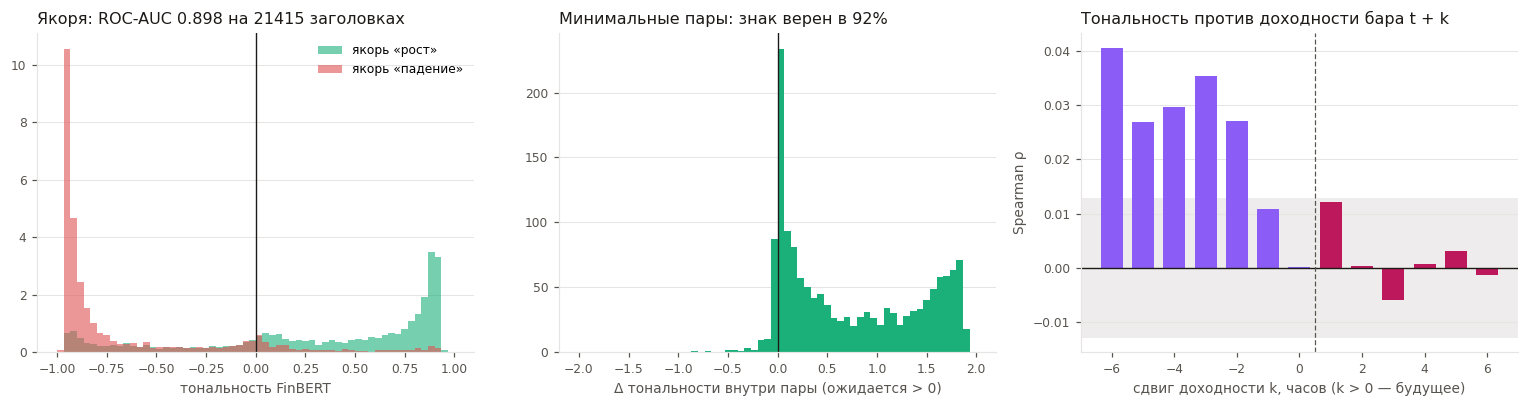

Серая полоса на правой панели — ±2/√n = ±0.0128, грубая граница значимости.
Вне полосы слева от пунктира (k <= 0, прошлое и текущий час): [-6, -5, -4, -3, -2].
Вне полосы справа (k > 0, будущее): ни одного сдвига.
Разметка в этой проверке — цена, а не разметчик, поэтому она и говорит, работает ли
скорер на крипто-заголовках: связь с уже случившимся движением означает, что
тональность улавливает реальную полярность, а её отсутствие в будущих барах — что
предсказывать по ней нечего.


In [17]:
# Независимая проверка скорера: якоря по направлению, минимальные пары, кросс-корреляция с ценой.
ANCHOR_PAIRS = [("surges", "plunges"), ("surge", "plunge"), ("soars", "sinks"),
                ("soar", "sink"), ("rallies", "tumbles"), ("rally", "tumble"),
                ("jumps", "drops"), ("jump", "drop"), ("climbs", "falls"), ("climb", "fall"),
                ("rises", "slides"), ("rise", "slide"), ("gains", "slumps"),
                ("gain", "slump"), ("spikes", "crashes"), ("spike", "crash")]
UP_WORDS = [u for u, _ in ANCHOR_PAIRS]
DN_WORDS = [d for _, d in ANCHOR_PAIRS]
ANTONYM = {**dict(ANCHOR_PAIRS), **{d: u for u, d in ANCHOR_PAIRS}}
N_PAIRS = 1500                      # сколько минимальных пар прогонять (по 2 прогона на пару)

low_titles = news["title"].str.lower()
up_hits = low_titles.str.count(r"\b(?:" + "|".join(UP_WORDS) + r")\b")
dn_hits = low_titles.str.count(r"\b(?:" + "|".join(DN_WORDS) + r")\b")

# ── проверка 1: направленные якоря ─────────────────────────────────────────
anchor_mask = ((up_hits > 0) & (dn_hits == 0)) | ((dn_hits > 0) & (up_hits == 0))
anchor = pd.DataFrame({
    "title": news.loc[anchor_mask, "title"].to_numpy(),
    "sent": news.loc[anchor_mask, "sent"].to_numpy(),
    "якорь": np.where(up_hits[anchor_mask] > 0, "рост", "падение"),
    # поток собран вокруг биткоина, но те же издания пишут и про акции с макро,
    # поэтому долю «про BTC» лучше показать честно, а не подразумевать
    "про btc": low_titles[anchor_mask].str.contains(r"bitcoin|\bbtc\b", regex=True).to_numpy(),
})
y_anchor = (anchor["якорь"] == "рост").astype(int).to_numpy()
anchor_auc = roc_auc_score(y_anchor, anchor["sent"].to_numpy())
anchor_acc = float(((anchor["sent"].to_numpy() > 0).astype(int) == y_anchor).mean())
fin_label = np.where(anchor["sent"] > 0.2, "positive",
                     np.where(anchor["sent"] < -0.2, "negative", "neutral"))
print(f"1. Якоря: {len(anchor)} заголовков потока с однозначным словом направления "
      f"({int(y_anchor.sum())} «рост», {int((1 - y_anchor).sum())} «падение»); "
      f"{anchor['про btc'].mean():.0%} из них прямо упоминают bitcoin или BTC.")
print(f"   ROC-AUC тональности против якоря = {anchor_auc:.3f}, "
      f"доля совпадений знака = {anchor_acc:.3f}")
display(pd.crosstab(anchor["якорь"], fin_label, rownames=["якорь"],
                    colnames=["FinBERT (порог ±0.2)"], normalize="index").round(3))

# ── проверка 2: минимальные пары ───────────────────────────────────────────
rng_pairs = np.random.default_rng(RANDOM_STATE)
pair_idx = rng_pairs.choice(len(anchor), size=min(N_PAIRS, len(anchor)), replace=False)
orig, flipped, direction = [], [], []
for t in anchor["title"].to_numpy()[pair_idx]:
    words = re.findall(r"[A-Za-z']+", t)
    hit = next((w for w in words if w.lower() in ANTONYM), None)
    if hit is None:
        continue
    orig.append(t)
    flipped.append(re.sub(rf"\b{re.escape(hit)}\b", ANTONYM[hit.lower()], t, count=1))
    direction.append("рост" if hit.lower() in ANTONYM and hit.lower() in UP_WORDS else "падение")

s_orig, s_flip = sent_scalar(orig), sent_scalar(flipped)
sign = np.where(np.array(direction) == "рост", 1.0, -1.0)
delta = sign * (s_orig - s_flip)          # ожидаем > 0: «растущий» вариант позитивнее
print(f"\n2. Минимальные пары: {len(orig)} заголовков, в каждом слово направления заменено "
      f"антонимом.")
print(f"   Знак разности верный в {float((delta > 0).mean()):.1%} пар, средняя разность "
      f"тональности {delta.mean():+.3f} (медиана {np.median(delta):+.3f})")
pairs_demo = pd.DataFrame({
    "исходный заголовок": orig[:4], "тональность": s_orig[:4].round(3),
    "с заменённым словом": flipped[:4], "тональность ": s_flip[:4].round(3),
})
display(pairs_demo)

# ── проверка 3: внешняя метка — доходность бара ────────────────────────────
# Тональность бара t — среднее по заголовкам, вышедшим в (t-1, t]; сравнивается с доходностью
# бара t + k. k < 0 — прошлое, k = 0 — тот же час, k > 0 — будущее. Разметка целиком рыночная.
LAGS = range(-6, 7)
sent_bar = (pd.DataFrame({"bar": news["dt"].dt.ceil("h"), "sent": news["sent"]})
            .groupby("bar")["sent"].mean().reindex(raw["date"].to_numpy()))
ret_bar = raw["close"].pct_change().to_numpy()
sent_v = sent_bar.to_numpy()
xcorr = []
for k in LAGS:
    r_shift = pd.Series(ret_bar).shift(-k).to_numpy()
    ok = np.isfinite(sent_v) & np.isfinite(r_shift)
    rho, pval = stats.spearmanr(sent_v[ok], r_shift[ok])
    xcorr.append({"сдвиг k, ч": k, "Spearman ρ": rho, "p-value": pval, "баров": int(ok.sum())})
xcorr = pd.DataFrame(xcorr).set_index("сдвиг k, ч")
print(f"\n3. Кросс-корреляция часовой тональности с доходностью бара t + k "
      f"(разметка — цена, не разметчик):")
display(xcorr.round(4))
rho_past, rho_now = xcorr.loc[-1, "Spearman ρ"], xcorr.loc[0, "Spearman ρ"]
rho_fut = xcorr.loc[1, "Spearman ρ"]
print(f"   тот же час: ρ = {rho_now:+.4f} (p = {xcorr.loc[0, 'p-value']:.2g}), "
      f"предыдущий: ρ = {rho_past:+.4f}, следующий: ρ = {rho_fut:+.4f} "
      f"(p = {xcorr.loc[1, 'p-value']:.2g})")

fig, axes = plt.subplots(1, 3, figsize=(14, 3.8))

ax = axes[0]
bins = np.linspace(-1, 1, 61)
ax.hist(anchor.loc[anchor["якорь"] == "рост", "sent"], bins=bins, color=UP, alpha=0.6,
        linewidth=0, label="якорь «рост»", density=True)
ax.hist(anchor.loc[anchor["якорь"] == "падение", "sent"], bins=bins, color=DOWN, alpha=0.6,
        linewidth=0, label="якорь «падение»", density=True)
ax.axvline(0, color=INK, linewidth=0.9)
ax.set_xlabel("тональность FinBERT", color=INK_MUTED, fontsize=9)
ax.set_title(f"Якоря: ROC-AUC {anchor_auc:.3f} на {len(anchor)} заголовках",
             color=INK, fontsize=10.5, loc="left")
ax.legend(frameon=False, fontsize=8)
style_ax(ax)

ax = axes[1]
ax.hist(delta, bins=np.linspace(-2, 2, 61), color=COLORS["CatBoost"], linewidth=0)
ax.axvline(0, color=INK, linewidth=0.9)
ax.set_xlabel("Δ тональности внутри пары (ожидается > 0)", color=INK_MUTED, fontsize=9)
ax.set_title(f"Минимальные пары: знак верен в {float((delta > 0).mean()):.0%}",
             color=INK, fontsize=10.5, loc="left")
style_ax(ax)

ax = axes[2]
ks = np.array(list(LAGS))
band = 2.0 / np.sqrt(float(xcorr["баров"].iloc[0]))
ax.axhspan(-band, band, color=GRID, alpha=0.7, linewidth=0)
ax.bar(ks, xcorr["Spearman ρ"].to_numpy(), width=0.7,
       color=[COLORS["Ensemble"] if k <= 0 else COLORS["TimesFM"] for k in ks])
ax.axhline(0, color=INK, linewidth=0.9)
ax.axvline(0.5, color=INK_MUTED, linewidth=0.8, linestyle=(0, (4, 2)))
ax.set_xlabel("сдвиг доходности k, часов (k > 0 — будущее)", color=INK_MUTED, fontsize=9)
ax.set_ylabel("Spearman ρ", color=INK_MUTED, fontsize=9)
ax.set_title("Тональность против доходности бара t + k", color=INK, fontsize=10.5,
             loc="left")
style_ax(ax)

fig.tight_layout()
plt.show()
rho_all = xcorr["Spearman ρ"]
past_out = [k for k in LAGS if k <= 0 and abs(rho_all.loc[k]) > band]
fut_out = [k for k in LAGS if k > 0 and abs(rho_all.loc[k]) > band]
print(f"Серая полоса на правой панели — ±2/√n = ±{band:.4f}, грубая граница значимости.")
print(f"Вне полосы слева от пунктира (k <= 0, прошлое и текущий час): "
      f"{past_out if past_out else 'ни одного сдвига'}.")
print(f"Вне полосы справа (k > 0, будущее): {fut_out if fut_out else 'ни одного сдвига'}.")
print("Разметка в этой проверке — цена, а не разметчик, поэтому она и говорит, работает ли")
print("скорер на крипто-заголовках: связь с уже случившимся движением означает, что")
print("тональность улавливает реальную полярность, а её отсутствие в будущих барах — что")
print("предсказывать по ней нечего.")

del fin_model
torch.cuda.empty_cache() if DEVICE.type == "cuda" else None

In [18]:
# Темы (эмбеддинги MiniLM + PCA) и агрегация всех новостных величин к часовым барам.

# ── шаг 2: эмбеддинги и PCA (обучается только на новостях обучающего периода) ──
t_start = time.perf_counter()
emb_tok = AutoTokenizer.from_pretrained(EMBEDDER)
emb_model = AutoModel.from_pretrained(EMBEDDER).to(DEVICE).eval()
emb = score_texts(news["title"].to_numpy(), emb_model, emb_tok, "emb")
NEWS_FIT_END = raw["date"].iloc[int(len(raw) * TRAIN_END)]
fit_mask = (news["dt"] < NEWS_FIT_END).to_numpy()
news_pca = PCA(n_components=NEWS_PCA_K, random_state=RANDOM_STATE).fit(emb[fit_mask])
emb_pca = news_pca.transform(emb)
print(f"MiniLM: эмбеддинги {emb.shape} за {(time.perf_counter() - t_start) / 60:.1f} мин; "
      f"PCA обучена на {int(fit_mask.sum())} заголовках до {NEWS_FIT_END:%Y-%m-%d} "
      f"и объясняет {news_pca.explained_variance_ratio_.sum():.1%} дисперсии в {NEWS_PCA_K} "
      f"компонентах")
del emb_model
torch.cuda.empty_cache() if DEVICE.type == "cuda" else None

# ── шаг 3: агрегация к барам ────────────────────────────────────────────────
low = news["title"].str.lower()
agg = pd.DataFrame({"bar": news["dt"].dt.ceil("h"), "sent": news["sent"],
                    "neg": (news["sent"] < -0.2).astype(float),
                    "pos": (news["sent"] > 0.2).astype(float),
                    "tier1": news["source"].isin(NEWS_TIER1).astype(float)})
for k, pat in NEWS_KEYWORDS.items():
    agg[f"kw_{k}"] = low.str.contains(pat, regex=True).astype(float)
for j in range(NEWS_PCA_K):
    agg[f"emb{j + 1}"] = emb_pca[:, j]

g = agg.groupby("bar")
NEWS_BAR = pd.DataFrame({"n_count": g.size(), "n_sent_mean": g["sent"].mean(),
                         "n_sent_sum": g["sent"].sum(), "n_neg": g["neg"].sum(),
                         "n_pos": g["pos"].sum(), "n_tier1": g["tier1"].sum()})
for k in NEWS_KEYWORDS:
    NEWS_BAR[f"n_kw_{k}"] = g[f"kw_{k}"].sum()
for j in range(NEWS_PCA_K):
    NEWS_BAR[f"n_emb{j + 1}"] = g[f"emb{j + 1}"].sum()
print(f"Агрегировано к {len(NEWS_BAR)} часовым барам "
      f"({len(NEWS_BAR) / len(raw):.0%} баров ряда содержат хотя бы одну новость)")

MiniLM: эмбеддинги (139570, 384) за 0.3 мин; PCA обучена на 117983 заголовках до 2024-02-05 и объясняет 18.2% дисперсии в 6 компонентах


Агрегировано к 24766 часовым барам (64% баров ряда содержат хотя бы одну новость)


In [19]:
# Признаки из новостей: скользящие агрегаты по барам <= t.
NEWS_WINDOWS = (6, 24, 168)
NEWS_BURST_WINDOW = 720            # месяц: база для сравнения текущей активности


def news_features(df, index=None):
    """Новостные признаки для баров df. Все окна смотрят только назад."""
    index = df.index if index is None else index
    nb = NEWS_BAR.reindex(df["date"].to_numpy())
    cnt = pd.Series(nb["n_count"].to_numpy(), index=index).fillna(0.0)
    ssum = pd.Series(nb["n_sent_sum"].to_numpy(), index=index).fillna(0.0)

    def wmean(numer, w):
        """Среднее по окну, взвешенное числом новостей: часы без новостей не тянут к нулю."""
        return (numer.rolling(w, min_periods=1).sum()
                / (cnt.rolling(w, min_periods=1).sum() + 1e-9))

    cols = {"news_count": np.log1p(cnt)}
    for w in NEWS_WINDOWS:
        cols[f"news_count_{w}"] = np.log1p(cnt.rolling(w, min_periods=1).sum())
    # всплеск потока: сутки против месячной медианы — «о рынке вдруг заговорили»
    c24 = cnt.rolling(24, min_periods=1).sum()
    cols["news_burst"] = c24 / (c24.rolling(NEWS_BURST_WINDOW, min_periods=24).median() + 1.0)
    cols["news_bars_since"] = bars_since(cnt > 0)

    for w in (24, 168):
        cols[f"news_sent_{w}"] = wmean(ssum, w)
    cols["news_sent_mom"] = cols["news_sent_24"] - cols["news_sent_168"]
    cols["news_neg_24"] = wmean(pd.Series(nb["n_neg"].to_numpy(), index=index).fillna(0.0), 24)
    cols["news_pos_24"] = wmean(pd.Series(nb["n_pos"].to_numpy(), index=index).fillna(0.0), 24)
    # Разброс тональности ВО ВРЕМЕНИ: std средней по бару тональности за сутки. Это не спор
    # изданий внутри одного часа (для него нужна дисперсия внутри бара, её здесь нет), а
    # неустойчивость фона: когда тональность мечется, движение чаще резче.
    bar_mean = pd.Series(nb["n_sent_mean"].to_numpy(), index=index)
    cols["news_disagree_24"] = bar_mean.rolling(24, min_periods=2).std()
    cols["news_tier1_24"] = wmean(pd.Series(nb["n_tier1"].to_numpy(), index=index).fillna(0.0), 24)

    for k in NEWS_KEYWORDS:
        s = pd.Series(nb[f"n_kw_{k}"].to_numpy(), index=index).fillna(0.0)
        cols[f"news_kw_{k}"] = wmean(s, 24)
    for j in range(NEWS_PCA_K):
        s = pd.Series(nb[f"n_emb{j + 1}"].to_numpy(), index=index).fillna(0.0)
        cols[f"news_emb{j + 1}"] = wmean(s, 168)
    return cols

In [20]:
MA_WINDOWS = [5, 10, 20, 50, 100, 200]
RET_HORIZONS = [1, 2, 3, 6, 12, 24, 48, 72, 168]


def running_streak(sign_series):
    """Длина текущей серии одинаковых знаков: +n — n баров подряд вверх, -n — вниз."""
    s = pd.Series(sign_series).fillna(0).to_numpy()
    out = np.zeros(len(s))
    for i in range(1, len(s)):
        out[i] = out[i - 1] + s[i] if s[i] == s[i - 1] and s[i] != 0 else s[i]
    return pd.Series(out, index=pd.Series(sign_series).index)


def bars_since(flag, cap=500):
    """Сколько баров прошло с последнего срабатывания флага."""
    f = pd.Series(flag).fillna(False).to_numpy().astype(bool)
    out, last = np.empty(len(f)), -1
    for i in range(len(f)):
        if f[i]:
            last = i
        out[i] = (i - last) if last >= 0 else np.nan
    return pd.Series(np.minimum(out, cap), index=pd.Series(flag).index)


def build_ta_features(df, n_lags=N_LAGS):
    """Полная матрица признаков технического анализа. Возвращает (признаки, группы)."""
    o_, h_, l_, c_, v_ = (df[x] for x in OHLCV)
    X, groups = {}, {}

    def add(group, cols):
        groups.setdefault(group, []).extend(cols)
        X.update(cols)

    atr_s = atr(h_, l_, c_, 14)
    natr = atr_s / c_
    ret_1 = c_.pct_change()
    logret = np.log(c_).diff()

    # ── доходности и лаги ───────────────────────────────────────────────────
    cols = {}
    for k in RET_HORIZONS:
        cols[f"ret_{k}"] = c_.pct_change(k)
        cols[f"ret_{k}_atr"] = (c_ / c_.shift(k) - 1) / natr.replace(0, np.nan)   # ход в ATR
    for k in range(n_lags):
        cols[f"ret_lag_{k}"] = ret_1.shift(k)
    cols["logret_skew_24"] = logret.rolling(24).skew()
    cols["logret_kurt_24"] = logret.rolling(24).kurt()
    cols["up_bars_frac_24"] = (ret_1 > 0).rolling(24).mean()
    cols["ret_streak"] = running_streak(np.sign(ret_1.fillna(0)))
    add("доходности", cols)

    # ── скользящие средние ──────────────────────────────────────────────────
    cols, sma, ema = {}, {}, {}
    for w in MA_WINDOWS:
        sma[w] = c_.rolling(w).mean()
        ema[w] = c_.ewm(span=w, adjust=False).mean()
        cols[f"close_sma{w}_ratio"] = c_ / sma[w] - 1
        cols[f"close_ema{w}_ratio"] = c_ / ema[w] - 1
        cols[f"sma{w}_slope"] = sma[w].pct_change(max(3, w // 4))
        cols[f"close_sma{w}_atr"] = (c_ - sma[w]) / atr_s          # удалённость от MA в ATR
    for fast, slow in [(5, 20), (10, 50), (20, 50), (50, 200)]:
        spread = sma[fast] / sma[slow] - 1
        above = (spread > 0).astype(np.int8)
        up_cross = ((above == 1) & (above.shift(1) == 0)).astype(np.int8)
        dn_cross = ((above == 0) & (above.shift(1) == 1)).astype(np.int8)
        cols[f"ma_spread_{fast}_{slow}"] = spread
        cols[f"ma_above_{fast}_{slow}"] = above
        cols[f"ma_cross_up_{fast}_{slow}"] = up_cross               # «золотой крест»
        cols[f"ma_cross_dn_{fast}_{slow}"] = dn_cross               # «мёртвый крест»
        cols[f"bars_since_cross_{fast}_{slow}"] = bars_since((up_cross + dn_cross) > 0)
    ribbon = sum((sma[a] > sma[b]).astype(int) for a, b in zip(MA_WINDOWS[:-1], MA_WINDOWS[1:]))
    cols["ma_ribbon_score"] = ribbon / (len(MA_WINDOWS) - 1)        # упорядоченность «ленты» MA
    cols["price_above_all_ma"] = np.minimum.reduce([(c_ > sma[w]).to_numpy() for w in MA_WINDOWS]).astype(np.int8)
    cols["price_below_all_ma"] = np.minimum.reduce([(c_ < sma[w]).to_numpy() for w in MA_WINDOWS]).astype(np.int8)
    add("скользящие средние", cols)

    # ── осцилляторы импульса ────────────────────────────────────────────────
    cols = {}
    for n in (7, 14, 28):
        r = rsi(c_, n)
        cols[f"rsi_{n}"], cols[f"rsi_{n}_slope"] = r, r.diff(3)
    r14 = cols["rsi_14"]
    cols["rsi_overbought"] = (r14 > 70).astype(np.int8)
    cols["rsi_oversold"] = (r14 < 30).astype(np.int8)
    cols["rsi_cross_50_up"] = ((r14 > 50) & (r14.shift(1) <= 50)).astype(np.int8)
    cols["rsi_cross_50_dn"] = ((r14 < 50) & (r14.shift(1) >= 50)).astype(np.int8)
    k_, d_ = stochastic(h_, l_, c_, 14, 3)
    cols["stoch_k"], cols["stoch_d"], cols["stoch_diff"] = k_, d_, k_ - d_
    cols["williams_r"] = k_ - 100
    line, sig, hist = macd(c_)
    cols["macd"], cols["macd_signal"], cols["macd_hist"] = line / c_, sig / c_, hist / c_
    cols["macd_hist_slope"] = (hist / c_).diff(3)
    cols["macd_cross_up"] = ((hist > 0) & (hist.shift(1) <= 0)).astype(np.int8)
    cols["macd_cross_dn"] = ((hist < 0) & (hist.shift(1) >= 0)).astype(np.int8)
    adx_s, pdi, mdi = adx(h_, l_, c_, 14)
    cols["adx"], cols["di_plus"], cols["di_minus"] = adx_s, pdi, mdi
    cols["di_diff"], cols["adx_slope"] = pdi - mdi, adx_s.diff(3)
    cols["adx_strong_trend"] = (adx_s > 25).astype(np.int8)
    cols["cci_20"] = cci(h_, l_, c_, 20)
    au, ad = aroon(h_, l_, 25)
    cols["aroon_up"], cols["aroon_down"], cols["aroon_osc"] = au, ad, au - ad
    cols["mom_roc_12"] = c_.pct_change(12)
    cols["ultimate_bias"] = (c_ - (h_.rolling(24).max() + l_.rolling(24).min()) / 2) / atr_s
    add("осцилляторы", cols)

    # ── волатильность ───────────────────────────────────────────────────────
    cols = {}
    cols["atr_14"] = natr
    cols["atr_ratio_short_long"] = atr(h_, l_, c_, 7) / atr_s.replace(0, np.nan)
    cols["tr_atr"] = true_range(h_, l_, c_) / atr_s.replace(0, np.nan)
    for n in (24, 72, 168):
        cols[f"vol_{n}"] = logret.rolling(n).std(ddof=0)
    cols["vol_regime"] = cols["vol_24"] / cols["vol_168"].replace(0, np.nan)
    cols["vol_of_vol"] = cols["vol_24"].rolling(72).std(ddof=0) / cols["vol_24"].replace(0, np.nan)
    cols["parkinson_24"] = np.sqrt((np.log(h_ / l_) ** 2).rolling(24).mean() / (4 * np.log(2)))
    cols["garman_klass_24"] = np.sqrt((0.5 * np.log(h_ / l_) ** 2
                                       - (2 * np.log(2) - 1) * np.log(c_ / o_) ** 2)
                                      .rolling(24).mean().clip(lower=0))
    bb_mid, bb_std = c_.rolling(20).mean(), c_.rolling(20).std(ddof=0)
    cols["bb_pctb"] = (c_ - (bb_mid - 2 * bb_std)) / (4 * bb_std).replace(0, np.nan)
    cols["bb_width"] = (4 * bb_std) / bb_mid
    cols["bb_squeeze"] = (cols["bb_width"] < cols["bb_width"].rolling(168).quantile(0.20)).astype(np.int8)
    kc_mid = c_.ewm(span=20, adjust=False).mean()
    cols["kc_pos"] = (c_ - kc_mid) / (2 * atr_s).replace(0, np.nan)
    cols["ttm_squeeze"] = ((bb_mid + 2 * bb_std < kc_mid + 2 * atr_s) &
                           (bb_mid - 2 * bb_std > kc_mid - 2 * atr_s)).astype(np.int8)
    add("волатильность", cols)

    # ── объём ───────────────────────────────────────────────────────────────
    cols = {}
    logv_ = np.log1p(v_)
    cols["vol_z_24"], cols["vol_z_168"] = zscore(logv_, 24), zscore(logv_, 168)
    cols["vol_ratio_sma"] = v_ / v_.rolling(24).mean().replace(0, np.nan)
    cols["vol_change"] = logv_.diff()
    obv_s = obv(c_, v_)
    cols["obv_z"] = zscore(obv_s, 168)
    cols["obv_slope"] = obv_s.diff(24) / v_.rolling(24).sum().replace(0, np.nan)
    cols["mfi_14"] = mfi(h_, l_, c_, v_, 14)
    cols["cmf_20"] = cmf(h_, l_, c_, v_, 20)
    vwap = (((h_ + l_ + c_) / 3) * v_).rolling(24).sum() / v_.rolling(24).sum().replace(0, np.nan)
    cols["vwap_dev"] = c_ / vwap - 1
    cols["force_index"] = wilder(c_.diff() * v_, 13) / (atr_s * v_.rolling(24).mean()).replace(0, np.nan)
    cols["vol_price_corr_24"] = logret.rolling(24).corr(logv_.diff())
    add("объём", cols)

    # ── свечи: геометрия и паттерны ─────────────────────────────────────────
    cdl_df, anat = candlestick_patterns(o_, h_, l_, c_, atr_s)
    cols = {
        "body_frac": anat["body_frac"], "upper_frac": anat["upper_frac"],
        "lower_frac": anat["lower_frac"], "clv": anat["clv"],
        "range_atr": anat["rng"] / atr_s.replace(0, np.nan),
        "body_atr": anat["body"] / atr_s.replace(0, np.nan),
        "gap_open": o_ / c_.shift(1) - 1,
        "shadow_imbalance": (anat["upper"] - anat["lower"]) / anat["rng"],
    }
    cols.update({name: cdl_df[name] for name in cdl_df.columns})
    bull_cnt, bear_cnt = cdl_df[CANDLE_BULL].sum(axis=1), cdl_df[CANDLE_BEAR].sum(axis=1)
    cols["cdl_bull_score"], cols["cdl_bear_score"] = bull_cnt, bear_cnt
    cols["cdl_net_score"] = bull_cnt - bear_cnt
    cols["cdl_net_score_6"] = (bull_cnt - bear_cnt).rolling(6).sum()
    add("свечные паттерны", cols)

    # ── паттерны разворота ──────────────────────────────────────────────────
    pat_df, lvl = chart_patterns(h_, l_, c_, X["rsi_14"], atr_s)
    cols = {}
    for name in pat_df.columns:
        cols[name] = pat_df[name]
        cols[f"{name}_24"] = pat_df[name].rolling(24).max()      # паттерн «действует» ещё сутки
    cols.update({name: lvl[name] for name in lvl.columns})
    cols["dist_high_168_atr"] = (h_.rolling(168).max() - c_) / atr_s
    cols["dist_low_168_atr"] = (c_ - l_.rolling(168).min()) / atr_s
    cols["new_high_168"] = (c_ >= c_.rolling(168).max()).astype(np.int8)
    cols["new_low_168"] = (c_ <= c_.rolling(168).min()).astype(np.int8)
    cols["key_reversal_up"] = ((l_ < l_.shift(1).rolling(24).min()) & (c_ > c_.shift(1))).astype(np.int8)
    cols["key_reversal_dn"] = ((h_ > h_.shift(1).rolling(24).max()) & (c_ < c_.shift(1))).astype(np.int8)
    add("паттерны разворота", cols)

    # ── паттерны продолжения ────────────────────────────────────────────────
    cols = {}
    for n in (20, 55):
        dh, dl = h_.rolling(n).max(), l_.rolling(n).min()
        cols[f"donchian_pos_{n}"] = (c_ - dl) / (dh - dl).replace(0, np.nan)
        cols[f"donchian_width_{n}"] = (dh - dl) / atr_s
        cols[f"breakout_up_{n}"] = (c_ > dh.shift(1)).astype(np.int8)
        cols[f"breakout_dn_{n}"] = (c_ < dl.shift(1)).astype(np.int8)
    cols["er_20"], cols["er_72"] = efficiency_ratio(c_, 20), efficiency_ratio(c_, 72)
    impulse_up = (c_.shift(6) / c_.shift(18) - 1) > 2 * natr.shift(6)
    impulse_dn = (c_.shift(6) / c_.shift(18) - 1) < -2 * natr.shift(6)
    consolidation = (((h_.rolling(6).max() - l_.rolling(6).min()) / atr_s < 2.0) &
                     (v_.rolling(6).mean() < v_.rolling(24).mean()))
    cols["pat_bull_flag"] = (impulse_up & consolidation).astype(np.int8)
    cols["pat_bear_flag"] = (impulse_dn & consolidation).astype(np.int8)
    cols["pat_pennant"] = (consolidation & (X["bb_squeeze"] == 1)).astype(np.int8)
    cols["range_contraction"] = ((h_.rolling(6).max() - l_.rolling(6).min()) /
                                 (h_.rolling(24).max() - l_.rolling(24).min()).replace(0, np.nan))
    cols["inside_bar_streak"] = running_streak(cdl_df["cdl_inside_bar"].astype(int))
    cols["above_ema20_streak"] = running_streak((c_ > ema[20]).astype(int))
    cols["trend_continuation"] = (((X["adx"] > 25) & (X["adx_slope"] > 0) &
                                   (X["di_diff"].abs() > 5)).astype(np.int8) * np.sign(X["di_diff"]))
    add("паттерны продолжения", cols)

    # ── аномальность бара (раздел 2) ────────────────────────────────────────
    cols = {
        "anom_ret_z": robust_z(ret_1, ANOM_WIN),
        "anom_vol_z": robust_z(np.log1p(v_), ANOM_WIN),
        "anom_tr_z": robust_z(true_range(h_, l_, c_), ANOM_WIN),
    }
    cols["anom_ret_outlier"] = (cols["anom_ret_z"].abs() > OUTLIER_Z).astype(np.int8)
    cols["anom_vol_outlier"] = (cols["anom_vol_z"].abs() > OUTLIER_Z).astype(np.int8)
    # anom_any объединяет выбросы доходности и объёма — 1119 баров (2.94%), а не все 1848
    # (4.85%) из раздела 2.1: флага по истинному диапазону здесь нет. Именно этот признак
    # задаёт понижающий вес в sample_weights, поэтому 729 баров, аномальных только по
    # диапазону, обучаются с полным весом.
    cols["anom_any"] = ((cols["anom_ret_outlier"] + cols["anom_vol_outlier"]) > 0).astype(np.int8)
    cols["anom_count_24"] = cols["anom_any"].rolling(24).sum()
    cols["anom_bars_since"] = bars_since(cols["anom_any"] > 0)
    add("аномалии", cols)

    # ── спектр и вейвлет-разложение (раздел 7.1) ────────────────────────────
    add("Фурье", {**fourier_features(logret, df.index),
                  **fourier_peak_features(logret, df.index)})
    add("вейвлет", {**wavelet_features(logret, np.log(c_), df.index),
                    **wavelet_denoise_features(logret, df.index)})
    add("CWT", cwt_features(logret, df.index))

    # ── новости (раздел 7.3) ────────────────────────────────────────────────
    add("новости", news_features(df))

    # ── календарь ───────────────────────────────────────────────────────────
    hour, dow = df["date"].dt.hour, df["date"].dt.dayofweek
    add("календарь", {
        "hour_sin": np.sin(2 * np.pi * hour / 24), "hour_cos": np.cos(2 * np.pi * hour / 24),
        "dow_sin": np.sin(2 * np.pi * dow / 7), "dow_cos": np.cos(2 * np.pi * dow / 7),
        "is_weekend": (dow >= 5).astype(np.int8),
    })

    return pd.concat([df, pd.DataFrame(X, index=df.index)], axis=1), groups


feat, FEATURE_GROUPS = build_ta_features(raw)
feature_cols = [c for g in FEATURE_GROUPS.values() for c in g]
assert len(feature_cols) == len(set(feature_cols)), "дублирующиеся имена признаков"

group_table = pd.DataFrame({
    "признаков": {g: len(cols) for g, cols in FEATURE_GROUPS.items()},
    "примеры": {g: ", ".join(cols[:3]) + (" …" if len(cols) > 3 else "")
                for g, cols in FEATURE_GROUPS.items()},
}).rename_axis("группа")
print(f"Всего признаков: {len(feature_cols)} (в ДЗ №2 было 24 лага доходности)")
display(group_table)

Всего признаков: 331 (в ДЗ №2 было 24 лага доходности)


,признаков,примеры
группа,,
доходности,34,"ret_1, ret_1_atr, ret_2 …"
скользящие средние,47,"close_sma5_ratio, close_ema5_ratio, sma5_slope …"
осцилляторы,32,"rsi_7, rsi_7_slope, rsi_14 …"
волатильность,15,"atr_14, atr_ratio_short_long, tr_atr …"
объём,11,"vol_z_24, vol_z_168, vol_ratio_sma …"
свечные паттерны,43,"body_frac, upper_frac, lower_frac …"
паттерны разворота,34,"pat_double_top, pat_double_top_24, pat_double_..."
паттерны продолжения,17,"donchian_pos_20, donchian_width_20, breakout_u..."
аномалии,8,"anom_ret_z, anom_vol_z, anom_tr_z …"


In [21]:
# Целевая переменная и подготовка датафрейма.
close = feat["close"]
feat["target"] = (close.shift(-HORIZON) > close).astype("float")   # направление через HORIZON баров
feat["fwd_ret"] = close.shift(-1) / close - 1                      # доходность бара t -> t+1

# бесконечности возникают при делении на нулевую волатильность — трактуем как пропуск
feat[feature_cols] = feat[feature_cols].replace([np.inf, -np.inf], np.nan)

# «Прогрев»: первые бары обрезаются, потому что окно SMA(200) ещё не заполнено.
# Строки в середине ряда НЕ удаляются — непрерывность ряда важнее пары пропусков,
# редкие внутренние NaN (например, MFI при нулевом знаменателе) переносятся с предыдущего бара.
warmup = max(feat[c].first_valid_index() for c in feature_cols)
interior_nan = int(feat[feature_cols].iloc[warmup:].isna().sum().sum())
feat = feat.iloc[warmup:].reset_index(drop=True)
feat[feature_cols] = feat[feature_cols].ffill().fillna(0)
feat = feat.dropna(subset=["target", "fwd_ret"]).reset_index(drop=True)
feat["target"] = feat["target"].astype(int)

print(f"Прогрев: отброшено первых {warmup} баров; заполнено {interior_nan} внутренних пропусков")
print(f"Итоговая матрица: {len(feat)} наблюдений × {len(feature_cols)} признаков")
print(f"Период: {feat['date'].min()} — {feat['date'].max()}")
print(f"Баланс классов: {feat['target'].value_counts(normalize=True).round(3).to_dict()}")

Прогрев: отброшено первых 680 баров; заполнено 241 внутренних пропусков
Итоговая матрица: 38094 наблюдений × 331 признаков
Период: 2021-01-29 08:00:00 — 2025-06-04 13:00:00
Баланс классов: {1: 0.505, 0: 0.495}


Новостных признаков: 24
Определены с бара 23 (прогрев ТА отбрасывает больше)


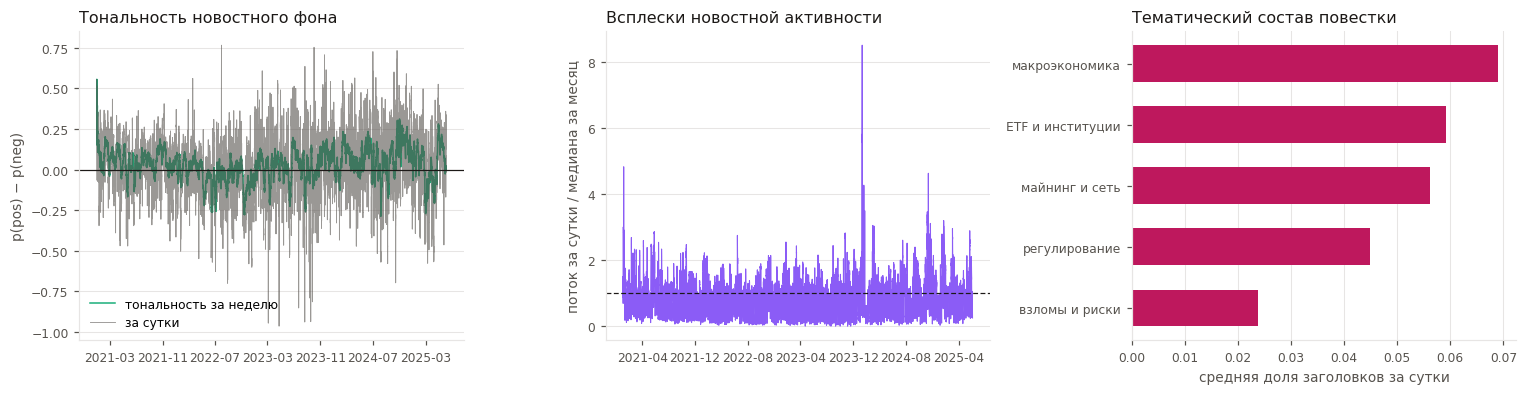

Левая панель показывает главное свойство тональности новостей о крипте: она колеблется
в узкой полосе около небольшого положительного среднего (+0.019 на заголовок: 30.2%
позитивных против 25.7% негативных). Информативен поэтому не уровень тональности, а её
отклонение от собственного среднего — это и делает news_sent_mom.


In [22]:
# Как выглядят новостные признаки.
demo_cols = news_features(raw)
demo_df = pd.DataFrame(demo_cols, index=raw.index)
print(f"Новостных признаков: {len(demo_cols)}")
print(f"Определены с бара {int(max(demo_df[c].first_valid_index() for c in demo_df))} "
      f"(прогрев ТА отбрасывает больше)")

fig, axes = plt.subplots(1, 3, figsize=(14, 3.7))
ax = axes[0]
ax.plot(raw["date"], demo_df["news_sent_168"], color=COLORS["CatBoost"], linewidth=1.0,
        label="тональность за неделю")
ax.plot(raw["date"], demo_df["news_sent_24"], color=INK_MUTED, linewidth=0.6, alpha=0.6,
        label="за сутки")
ax.axhline(0, color=INK, linewidth=0.8)
ax.set_ylabel("p(pos) − p(neg)", color=INK_MUTED, fontsize=9)
ax.set_title("Тональность новостного фона", color=INK, fontsize=10.5, loc="left")
ax.legend(frameon=False, fontsize=8)
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=8))
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m"))
style_ax(ax)

ax = axes[1]
ax.plot(raw["date"], demo_df["news_burst"], color=COLORS["Ensemble"], linewidth=0.7)
ax.axhline(1.0, color=INK, linewidth=0.8, linestyle=(0, (4, 2)))
ax.set_ylabel("поток за сутки / медиана за месяц", color=INK_MUTED, fontsize=9)
ax.set_title("Всплески новостной активности", color=INK, fontsize=10.5, loc="left")
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=8))
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m"))
style_ax(ax)

ax = axes[2]
kw_share = pd.Series({k: float(demo_df[f"news_kw_{k}"].mean()) for k in NEWS_KEYWORDS})
names_ru = {"regul": "регулирование", "etf": "ETF и институции", "risk": "взломы и риски",
            "mining": "майнинг и сеть", "macro": "макроэкономика"}
kw_share = kw_share.sort_values()
ax.barh(np.arange(len(kw_share)), kw_share.to_numpy(), color=COLORS["TimesFM"], height=0.6)
ax.set_yticks(np.arange(len(kw_share)))
ax.set_yticklabels([names_ru[k] for k in kw_share.index], fontsize=9)
ax.set_xlabel("средняя доля заголовков за сутки", color=INK_MUTED, fontsize=9)
ax.set_title("Тематический состав повестки", color=INK, fontsize=10.5, loc="left")
style_ax(ax, ygrid=False, xgrid=True)

fig.tight_layout()
plt.show()
print("Левая панель показывает главное свойство тональности новостей о крипте: она колеблется")
print("в узкой полосе около небольшого положительного среднего (+0.019 на заголовок: 30.2%")
print("позитивных против 25.7% негативных). Информативен поэтому не уровень тональности, а её")
print("отклонение от собственного среднего — это и делает news_sent_mom.")

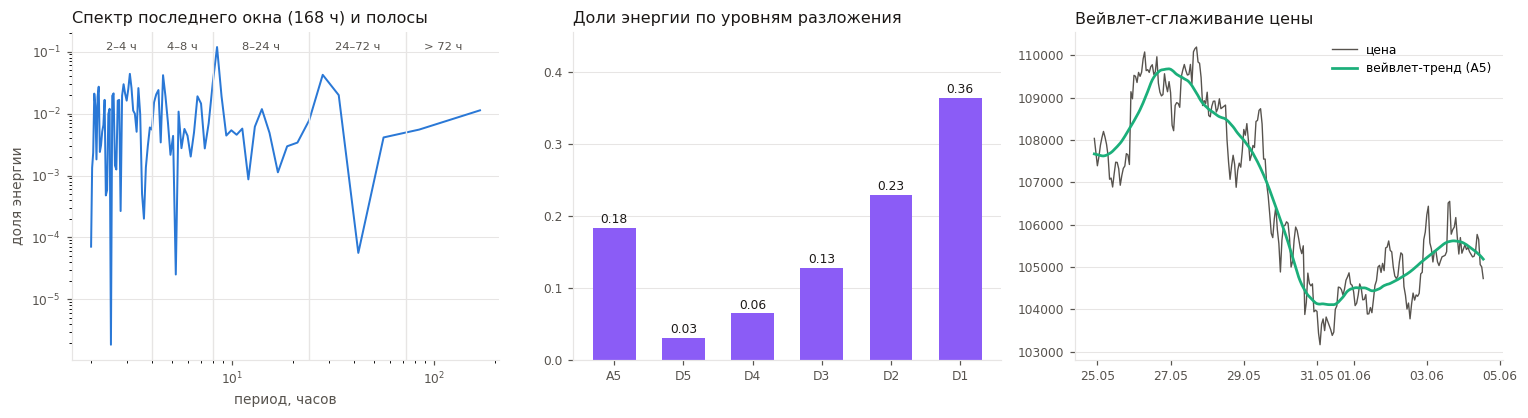

Слева направо: во что превращается последнее окно у Фурье, у вейвлета по энергии
и у вейвлета по тренду. Признаками становятся числа, описывающие форму этих картинок,
а не сами картинки: форма устойчива от окна к окну, отдельные коэффициенты — нет.


In [23]:
# Как выглядят новые признаки: спектр окна, вейвлет-разложение и вейвлет-тренд.
demo_end = len(feat) - 1
demo_lo = demo_end - WAVELET_WINDOW + 1
demo_logret = np.log(feat["close"].to_numpy()[demo_lo:demo_end + 1] /
                     feat["close"].to_numpy()[demo_lo - 1:demo_end])
demo_logprice = np.log(feat["close"].to_numpy()[demo_lo:demo_end + 1])

fig, axes = plt.subplots(1, 3, figsize=(14, 3.9))

ax = axes[0]
w = FFT_WINDOWS[0]
seg = demo_logret[-w:] - demo_logret[-w:].mean()
spec = np.abs(np.fft.rfft(seg * np.hanning(w))) ** 2
freqs = np.fft.rfftfreq(w)[1:]
periods = 1.0 / freqs
p = spec[1:] / spec[1:].sum()
ax.loglog(periods, p, color=COLORS["LogisticRegression"], linewidth=1.3)
for lo, hi in FFT_BANDS[:-1]:
    ax.axvline(hi, color=GRID, linewidth=0.9)
for (lo, hi), lbl in zip(FFT_BANDS, ["2–4 ч", "4–8 ч", "8–24 ч", "24–72 ч", "> 72 ч"]):
    mid = np.sqrt(lo * (hi if hi else w))
    ax.annotate(lbl, xy=(mid, 1.0), xycoords=("data", "axes fraction"), xytext=(0, -12),
                textcoords="offset points", ha="center", fontsize=7.5, color=INK_MUTED)
ax.set_xlabel("период, часов", color=INK_MUTED, fontsize=9)
ax.set_ylabel("доля энергии", color=INK_MUTED, fontsize=9)
ax.set_title(f"Спектр последнего окна ({w} ч) и полосы", color=INK, fontsize=10.5, loc="left")
style_ax(ax)

ax = axes[1]
cf = pywt.wavedec(demo_logret, WAVELET_NAME, level=WAVELET_LEVEL, mode=WAVELET_MODE)
lvl_names = [f"A{WAVELET_LEVEL}"] + [f"D{j}" for j in range(WAVELET_LEVEL, 0, -1)]
en = np.array([float((c ** 2).sum()) for c in cf])
en = en / en.sum()
ax.bar(np.arange(len(en)), en, color=COLORS["Ensemble"], width=0.62)
for xi, v in enumerate(en):
    ax.annotate(f"{v:.2f}", xy=(xi, v), xytext=(0, 3), textcoords="offset points",
                ha="center", fontsize=8, color=INK)
ax.set_xticks(np.arange(len(en)))
ax.set_xticklabels(lvl_names, fontsize=9)
ax.set_ylim(0, en.max() * 1.25)
ax.set_title("Доли энергии по уровням разложения", color=INK, fontsize=10.5, loc="left")
style_ax(ax)

ax = axes[2]
cp_demo = pywt.wavedec(demo_logprice, WAVELET_NAME, level=WAVELET_LEVEL, mode=WAVELET_MODE)
trend_demo = pywt.waverec([cp_demo[0]] + [np.zeros_like(c) for c in cp_demo[1:]],
                          WAVELET_NAME, mode=WAVELET_MODE)[:len(demo_logprice)]
dates_demo = feat["date"].to_numpy()[demo_lo:demo_end + 1]
ax.plot(dates_demo, np.exp(demo_logprice), color=INK_MUTED, linewidth=0.9, label="цена")
ax.plot(dates_demo, np.exp(trend_demo), color=COLORS["CatBoost"], linewidth=1.8,
        label=f"вейвлет-тренд (A{WAVELET_LEVEL})")
ax.set_title("Вейвлет-сглаживание цены", color=INK, fontsize=10.5, loc="left")
ax.legend(frameon=False, fontsize=8)
ax.xaxis.set_major_formatter(mdates.DateFormatter("%d.%m"))
style_ax(ax)

fig.tight_layout()
plt.show()
print("Слева направо: во что превращается последнее окно у Фурье, у вейвлета по энергии")
print("и у вейвлета по тренду. Признаками становятся числа, описывающие форму этих картинок,")
print("а не сами картинки: форма устойчива от окна к окну, отдельные коэффициенты — нет.")

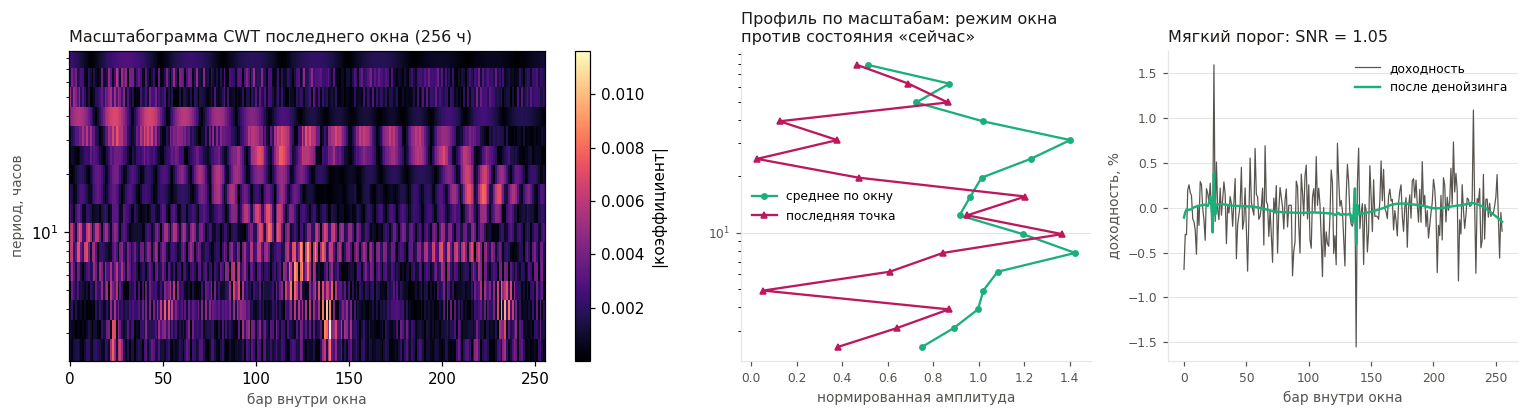

Слева — то, чего DWT дать не может: энергия по 16 масштабам и по времени одновременно.
В середине — два вектора признаков из этой картинки: усреднение по окну (режим) и
последний столбец (состояние сейчас). Справа — денойзинг мягким порогом: при SNR около
единицы «очищенный» ряд по амплитуде сопоставим с тем, что из него вычли.


In [24]:
# Масштабограмма последнего окна: та самая картинка из примера, но на нашем ряде.
demo_ret = demo_logret                      # то же окно, что в предыдущей ячейке
coef_demo, _ = pywt.cwt(demo_ret, CWT_SCALES, CWT_WAVELET)
amp_demo = np.abs(coef_demo)

fig, axes = plt.subplots(1, 3, figsize=(14, 3.9),
                         gridspec_kw={"width_ratios": [1.7, 1, 1]})

ax = axes[0]
im = ax.pcolormesh(np.arange(len(demo_ret)), CWT_PERIODS, amp_demo, cmap="magma", shading="auto")
ax.set_yscale("log")
ax.set_ylabel("период, часов", color=INK_MUTED, fontsize=9)
ax.set_xlabel("бар внутри окна", color=INK_MUTED, fontsize=9)
ax.set_title(f"Масштабограмма CWT последнего окна ({WAVELET_WINDOW} ч)",
             color=INK, fontsize=10.5, loc="left")
fig.colorbar(im, ax=ax, label="|коэффициент|")

ax = axes[1]
ax.plot(amp_demo.mean(axis=1) / amp_demo.mean(), CWT_PERIODS, marker="o", markersize=3.5,
        linewidth=1.5, color=COLORS["CatBoost"], label="среднее по окну")
ax.plot(amp_demo[:, -1] / amp_demo.mean(), CWT_PERIODS, marker="^", markersize=4,
        linewidth=1.5, color=COLORS["TimesFM"], label="последняя точка")
ax.set_yscale("log")
ax.set_xlabel("нормированная амплитуда", color=INK_MUTED, fontsize=9)
ax.set_title("Профиль по масштабам: режим окна\nпротив состояния «сейчас»",
             color=INK, fontsize=10.5, loc="left")
ax.legend(frameon=False, fontsize=8)
style_ax(ax)

ax = axes[2]
cf_demo = pywt.wavedec(demo_ret, WAVELET_NAME, level=WAVELET_LEVEL, mode=WAVELET_MODE)
sig_demo = np.median(np.abs(cf_demo[-1])) / 0.6745
thr_demo = sig_demo * np.sqrt(2 * np.log(len(demo_ret)))
den_demo = [cf_demo[0]] + [pywt.threshold(c, thr_demo, mode="soft") for c in cf_demo[1:]]
rec_demo = pywt.waverec(den_demo, WAVELET_NAME, mode=WAVELET_MODE)[:len(demo_ret)]
ax.plot(demo_ret * 100, color=INK_MUTED, linewidth=0.8, label="доходность")
ax.plot(rec_demo * 100, color=COLORS["CatBoost"], linewidth=1.6, label="после денойзинга")
ax.set_xlabel("бар внутри окна", color=INK_MUTED, fontsize=9)
ax.set_ylabel("доходность, %", color=INK_MUTED, fontsize=9)
ax.set_title(f"Мягкий порог: SNR = "
             f"{demo_ret.std() / (demo_ret - rec_demo).std():.2f}",
             color=INK, fontsize=10.5, loc="left")
ax.legend(frameon=False, fontsize=8)
style_ax(ax)

fig.tight_layout()
plt.show()
print("Слева — то, чего DWT дать не может: энергия по 16 масштабам и по времени одновременно.")
print("В середине — два вектора признаков из этой картинки: усреднение по окну (режим) и")
print("последний столбец (состояние сейчас). Справа — денойзинг мягким порогом: при SNR около")
print("единицы «очищенный» ряд по амплитуде сопоставим с тем, что из него вычли.")

### 7.4 Проверка на утечку данных

Обрезаем ряд на произвольном баре, пересчитываем все признаки на обрезанных
данных и сравниваем с признаками, посчитанными на полном ряде. Если ни одна функция не
использует будущее, значения обязаны совпасть.

In [25]:
CUT = int(len(raw) * 0.6)
truncated, _ = build_ta_features(raw.iloc[:CUT].reset_index(drop=True))
full_slice = build_ta_features(raw)[0].iloc[:CUT].reset_index(drop=True)

check_from = 500                                    # пропускаем прогрев индикаторов
SENTINEL = -9.876543e12                             # чтобы NaN не «замаскировал» расхождение
a = truncated[feature_cols].iloc[check_from:CUT - 1].fillna(SENTINEL)
b = full_slice[feature_cols].iloc[check_from:CUT - 1].fillna(SENTINEL)
diff = (a - b).abs().max()
bad = diff[diff > 1e-9].sort_values(ascending=False)

print(f"Ряд обрезан на баре {CUT} ({raw['date'].iloc[CUT]}), признаки пересчитаны заново.")
print(f"Сравнивается {len(a)} строк × {len(feature_cols)} признаков.")
if len(bad) == 0:
    print("OK: все признаки совпали — ни один из них не использует данные из будущего.")
else:
    display(bad.head(20))
    raise AssertionError(f"{len(bad)} признаков зависят от будущего")

# сдвиг признаков относительно последнего бара: у свинг-паттернов он не меньше PIVOT_W
last_pivot = swing_points(raw["high"], raw["low"])[0].last_valid_index()
print(f"\nПоследний подтверждённый свинг-максимум относится к бару {last_pivot} из {len(raw) - 1} "
      f"(сам экстремум — на PIVOT_W = {PIVOT_W} баров раньше, {last_pivot - PIVOT_W}): признак "
      f"появляется только в момент подтверждения. Свежих подтверждений в последних "
      f"{len(raw) - 1 - last_pivot} барах нет — это нормально, вершины случаются не каждый час.")

Ряд обрезан на баре 23265 (2023-08-28 09:00:00), признаки пересчитаны заново.
Сравнивается 22764 строк × 331 признаков.
OK: все признаки совпали — ни один из них не использует данные из будущего.

Последний подтверждённый свинг-максимум относится к бару 38756 из 38774 (сам экстремум — на PIVOT_W = 5 баров раньше, 38751): признак появляется только в момент подтверждения. Свежих подтверждений в последних 18 барах нет — это нормально, вершины случаются не каждый час.


## 8. Разбиение на train / test / validation

Разбиваем строго по времени, без перемешивания:

- **train** (70%) — обучение;
- **test** (15%) — вместе с train участвует в подборе гиперпараметров;
- **validation** (15%) — отложенная выборка, используется ровно один раз в конце;
- **dev** = train + test — внутри него идёт кросс-валидация временных рядов.

Между выборками выдерживается разрыв, чтобы последние бары обучающей части не знали о начале следующей.

In [26]:
n = len(feat)
train_end = int(n * TRAIN_END)
test_end = int(n * TEST_END)

train_df = feat.iloc[:train_end - EMBARGO].reset_index(drop=True)
test_df = feat.iloc[train_end:test_end - EMBARGO].reset_index(drop=True)
val_df = feat.iloc[test_end:].reset_index(drop=True)
dev_df = feat.iloc[:test_end - EMBARGO].reset_index(drop=True)

for name, part in (("train", train_df), ("test", test_df), ("validation", val_df)):
    print(f"{name:11s}: {len(part):5d} строк | {part['date'].min()} — {part['date'].max()}")

gap_tr_te = (test_df["date"].min() - train_df["date"].max()) / pd.Timedelta(hours=1)
gap_te_val = (val_df["date"].min() - test_df["date"].max()) / pd.Timedelta(hours=1)
print(f"\nразрыв train->test: {gap_tr_te:.0f} ч, test->validation: {gap_te_val:.0f} ч "
      f"(нужно > {HORIZON} ч — на длину метки)")
assert gap_tr_te > HORIZON and gap_te_val > HORIZON, "выборки перекрываются по периоду метки"

bh_val_return = float((1 + val_df["fwd_ret"]).prod() - 1)
print(f"Buy & hold на валидации: {bh_val_return:+.1%} — период {'падающий' if bh_val_return < 0 else 'растущий'}")

train      : 26664 строк | 2021-01-29 08:00:00 — 2024-02-14 07:00:00
test       :  5713 строк | 2024-02-14 09:00:00 — 2024-10-09 09:00:00
validation :  5715 строк | 2024-10-09 11:00:00 — 2025-06-04 13:00:00

разрыв train->test: 2 ч, test->validation: 2 ч (нужно > 1 ч — на длину метки)
Buy & hold на валидации: +68.9% — период растущий


## 9. Бэктест и стоимостно-осознанный торговый слой

In [27]:
def backtest(dates, fwd_ret, position, fee_rate=FEE_RATE):
    """Бэктест непрерывной позиции.

    position — доля капитала в позиции от -1 (полный short) до +1 (полный long), принятая
    в момент t по информации, известной к t, и применённая к доходности бара (t -> t+1).
    Комиссия начисляется с оборота |Δposition|: переворот long <-> short стоит 2 * fee_rate.

    Доходность считается и gross (без издержек), и net (с издержками): без этого разделения
    нельзя отличить «у модели нет предсказательной силы» от «edge есть, но его съедают издержки».
    """
    dates = pd.Series(dates).reset_index(drop=True)
    fwd_ret = np.asarray(fwd_ret, dtype=float)
    position = np.asarray(position, dtype=float)

    prev = np.roll(position, 1)
    prev[0] = 0.0                                   # до первой сделки капитал вне рынка
    turnover = np.abs(position - prev)

    gross_ret = position * fwd_ret
    fees = fee_rate * turnover
    strat_ret = gross_ret - fees

    equity = (1 + strat_ret).cumprod()
    equity_gross = (1 + gross_ret).cumprod()
    drawdown = equity / np.maximum.accumulate(equity) - 1

    n_periods = len(strat_ret)
    if n_periods == 0:
        raise ValueError("backtest получил пустую выборку")
    total_return = float(equity[-1] - 1)
    vol = strat_ret.std(ddof=0)
    gross_vol = gross_ret.std(ddof=0)

    curve = pd.DataFrame({"date": dates, "position": position, "strategy_return": strat_ret,
                          "equity": equity, "equity_gross": equity_gross, "drawdown": drawdown})
    metrics = {
        "total_return": total_return,                                   # net, с издержками
        "gross_return": float(equity_gross[-1] - 1),                    # edge модели
        "fee_drag": float(fees.sum()),                                  # издержки в долях капитала
        "annualized_return": float((1 + total_return) ** (PERIODS_PER_YEAR / n_periods) - 1),
        "sharpe": float(strat_ret.mean() / vol * np.sqrt(PERIODS_PER_YEAR)) if vol > 0 else 0.0,
        "gross_sharpe": float(gross_ret.mean() / gross_vol * np.sqrt(PERIODS_PER_YEAR)) if gross_vol > 0 else 0.0,
        "max_drawdown": float(drawdown.min()),
        "n_trades": int((turnover > TRADE_EPS).sum()),
        "turnover_units": float(turnover.sum()),
        "time_in_market": float((np.abs(position) > TRADE_EPS).mean()),
        "avg_abs_position": float(np.abs(position).mean()),              # фактическая экспозиция
        "avg_position": float(position.mean()),                          # смещение в long/short
        "profitable_bars": float((strat_ret > 0).mean()),
    }
    return curve, metrics


def positions_from_proba(proba, mode="hold", q=0.1, scale=10.0, span=1, rebalance=1, ref=None):
    """Перевод вероятности роста в позицию.

    mode:
      always    — всегда в рынке ±1 (правило из ДЗ №2);
      flat      — вне рынка в зоне неопределённости;
      hold      — в зоне неопределённости удерживается предыдущая позиция (гистерезис);
      ramp      — размер позиции растёт линейно от порога до экстремума вероятности;
      long_flat — только long или вне рынка (шорт запрещён);
      scaled    — непрерывный размер позиции, пропорциональный уверенности.

    span      — окно экспоненциального сглаживания вероятности (гасит однобаровый шум);
    rebalance — позиция пересматривается раз в k баров;
    q         — доля баров с каждой стороны, попадающая в «уверенную» зону; пороги берутся как
                квантили распределения вероятностей, что устойчиво к калибровке модели;
    ref       — распределение вероятностей, по которому считаются пороги (на валидации это
                распределение с dev-выборки: пороги не подбираются по будущим данным).
    """
    p = np.asarray(proba, dtype=float)
    if span > 1:
        p = pd.Series(p).ewm(span=span, adjust=False).mean().to_numpy()
    src = p if ref is None else np.asarray(ref, dtype=float)

    if mode == "always":
        pos = np.where(p >= 0.5, 1.0, -1.0)
    elif mode in ("hold", "flat"):
        hi, lo = np.quantile(src, 1 - q), np.quantile(src, q)
        sig = np.where(p >= hi, 1.0, np.where(p <= lo, -1.0, np.nan))
        pos = pd.Series(sig).ffill().fillna(0.0).to_numpy() if mode == "hold" else np.nan_to_num(sig)
    elif mode == "long_flat":
        pos = (p >= np.quantile(src, 1 - q)).astype(float)
    elif mode == "ramp":
        hi, lo = np.quantile(src, 1 - q), np.quantile(src, q)
        up = np.clip((p - hi) / max(np.quantile(src, 0.999) - hi, 1e-6), 0, 1)
        dn = np.clip((lo - p) / max(lo - np.quantile(src, 0.001), 1e-6), 0, 1)
        pos = up - dn
    elif mode == "scaled":
        pos = np.clip((p - 0.5) * scale, -1.0, 1.0)
    else:
        raise ValueError(f"неизвестный режим сигнала: {mode}")

    if rebalance > 1:
        keep = (np.arange(len(pos)) % rebalance) == 0
        pos = pd.Series(np.where(keep, pos, np.nan)).ffill().fillna(0.0).to_numpy()
    return pos


# сетка торгового слоя: перебирается при подборе гиперпараметров
SIGNAL_GRID = ([{"mode": "always"}] +
               [{"mode": m, "q": q} for m in ("hold", "flat", "ramp", "long_flat")
                for q in (0.02, 0.05, 0.10, 0.20, 0.35)] +
               [{"mode": "scaled", "scale": s} for s in (4, 10, 25)])
SPAN_GRID = (1, 4, 12, 24)
REBALANCE_GRID = (1, 6, 24)


def tune_signal_layer(proba, dates, fwd_ret, fee_rate=FEE_RATE):
    """Перебор параметров торгового слоя по чистому (net) коэффициенту Шарпа.

    Максимизировать один только Sharpe нельзя — у этой задачи есть вырожденный оптимум.
    Стратегия, которая держит крошечную почти постоянную позицию, не платит комиссий и
    показывает прекрасный Sharpe при нулевой полезности: это замаскированный buy & hold с
    плечом 0.07, а не торговая система. Ровно в этот угол и уходит оптимизатор, если его не
    ограничить. Поэтому конфигурация обязана:

    1. давать оборот не меньше MIN_TURNOVER_PER_YEAR единиц капитала в год — то есть
       действительно менять решение, а не «пересиживать»;
    2. держать средний размер позиции не меньше MIN_AVG_EXPOSURE капитала — то есть
       действительно рисковать деньгами;
    3. быть прибыльной хотя бы в MIN_POSITIVE_BLOCKS из N_BLOCKS подпериодов — защита от
       результата, который держится на одной удачной сделке.

    Возвращает (параметры, таблица, признак того, что допустимая конфигурация найдена).
    """
    rows = []
    for span in SPAN_GRID:
        for reb in REBALANCE_GRID:
            for prm in SIGNAL_GRID:
                pos = positions_from_proba(proba, span=span, rebalance=reb, **prm)
                curve, m = backtest(dates, fwd_ret, pos, fee_rate)
                blocks = np.array_split(curve["strategy_return"].to_numpy(), N_BLOCKS)
                block_sharpe = [float(b.mean() / b.std(ddof=0) * np.sqrt(PERIODS_PER_YEAR))
                                if b.std(ddof=0) > 0 else 0.0 for b in blocks]
                rows.append({**prm, "span": span, "rebalance": reb, "sharpe": m["sharpe"],
                             "net": m["total_return"], "gross": m["gross_return"],
                             "turnover": m["turnover_units"], "n_trades": m["n_trades"],
                             "time_in_market": m["time_in_market"],
                             "экспозиция": m["avg_abs_position"],
                             "sharpe_min_блок": float(np.min(block_sharpe)),
                             "прибыльных блоков": int(np.sum(np.array(block_sharpe) > 0))})
    tab = pd.DataFrame(rows)
    years = len(fwd_ret) / PERIODS_PER_YEAR
    tab["допустима"] = ((tab["turnover"] >= MIN_TURNOVER_PER_YEAR * years) &
                        (tab["экспозиция"] >= MIN_AVG_EXPOSURE))
    feasible = tab[tab["допустима"]]
    ok = len(feasible) > 0
    stable = feasible[feasible["прибыльных блоков"] >= MIN_POSITIVE_BLOCKS]
    pool = stable if len(stable) else (feasible if ok else tab)
    best = pool.loc[pool["sharpe"].idxmax()]
    params = {"mode": str(best["mode"]), "span": int(best["span"]),
              "rebalance": int(best["rebalance"])}
    for k in ("q", "scale"):                     # присутствуют не у всех режимов
        if k in tab.columns and pd.notna(best[k]):
            params[k] = float(best[k])
    return params, tab, ok

## 10. Метрики качества классификации

In [28]:
def predict_proba1(model, X):
    """Вероятность класса 1 (рост) — нужна для порогонезависимых ROC-AUC и PR-AUC."""
    return np.asarray(model.predict_proba(X))[:, 1]


def classification_metrics(y_true, y_pred, y_proba):
    """Шесть стандартных метрик: четыре пороговые и две порогонезависимые."""
    return {
        "accuracy": accuracy_score(y_true, y_pred),
        "precision": precision_score(y_true, y_pred, zero_division=0),
        "recall": recall_score(y_true, y_pred, zero_division=0),
        "f1": f1_score(y_true, y_pred, zero_division=0),
        "roc_auc": roc_auc_score(y_true, y_proba),
        "pr_auc": average_precision_score(y_true, y_proba),
    }

## 11. Обработка выбросов внутри конвейера

Найденные в разделе 2 аномалии обрабатываются тремя способами:

1. **Винзоризация.** Границы усечения — квантили 0.1% и 99.9%, посчитанные **только по
   обучающей части фолда**. Значения за границами прижимаются к границам. Строки не удаляются:
   экстремальный бар остаётся в ряду и в бэктесте, ограничивается лишь его влияние на обучение.
2. **Веса наблюдений.** Бар с флагом `anom_any` — выброс робастной z-оценки по доходности
   или объёму — получает вес `OUTLIER_WEIGHT = 0.25` в функции потерь. Истинный диапазон в этот
   флаг не входит, поэтому 729 баров, аномальных только по диапазону, обучаются с полным весом;
   включение их в флаг — отдельное решение, меняющее все последующие числа.
3. **Признаки аномальности.** Сами z-оценки и флаги остаются признаками: всплеск волатильности
   предсказывает всплеск волатильности следующего бара, и это полезная информация.

Отдельно проверяется четвёртая идея — **взвешивание баров по модулю будущей доходности**.
Обычная логистическая функция потерь считает все бары одинаково важными, хотя заработок
определяется крупными движениями. Вес `|fwd_ret|` смещает обучение в сторону экономически
значимых баров. В разделе 12 видно, что этот приём ухудшает ROC-AUC, но улучшает
gross-доходность, — поэтому он вынесен в подбираемые Optuna параметры, а не включён по умолчанию.

In [29]:
def winsor_bounds(X_train, q=WINSOR_Q):
    """Границы усечения по обучающей выборке."""
    return X_train.quantile(q), X_train.quantile(1 - q)


def apply_winsor(X, bounds):
    lo, hi = bounds
    return X.clip(lower=lo, upper=hi, axis=1)


def sample_weights(data, idx, w_outlier=True, w_ret=False):
    """Веса наблюдений: понижение веса выбросов и/или акцент на крупных движениях."""
    w = np.ones(len(idx), dtype=float)
    if w_outlier:
        w *= np.where(data["anom_any"].to_numpy()[idx] > 0, OUTLIER_WEIGHT, 1.0)
    if w_ret:
        a = data["fwd_ret"].abs().to_numpy()[idx]
        w *= a / a.mean()
    return w


# наглядно: что делает винзоризация с распределением признака
bounds_demo = winsor_bounds(train_df[feature_cols])
demo_cols = ["ret_1", "anom_ret_z", "pos_in_pivot_range", "force_index"]
before = train_df[demo_cols]
after = apply_winsor(train_df[demo_cols], (bounds_demo[0][demo_cols], bounds_demo[1][demo_cols]))
comparison = pd.DataFrame({
    "min до": before.min(), "min после": after.min(),
    "max до": before.max(), "max после": after.max(),
    "std до": before.std(), "std после": after.std(),
}).round(3)
n_clipped = int(((train_df[feature_cols] < bounds_demo[0]) |
                 (train_df[feature_cols] > bounds_demo[1])).sum().sum())
print(f"Границы усечения посчитаны по {len(train_df)} обучающим барам (квантили "
      f"{WINSOR_Q:.1%} / {1 - WINSOR_Q:.1%}).")
print(f"Усечено {n_clipped} значений из {len(train_df) * len(feature_cols)} "
      f"({n_clipped / (len(train_df) * len(feature_cols)):.3%}).")
display(comparison)

w_demo = sample_weights(train_df, np.arange(len(train_df)))
print(f"Понижен вес у {(w_demo < 1).sum()} баров ({(w_demo < 1).mean():.2%}); "
      f"суммарный вес выборки {w_demo.sum():.0f} вместо {len(w_demo)}")

Границы усечения посчитаны по 26664 обучающим барам (квантили 0.1% / 99.9%).
Усечено 10891 значений из 8825784 (0.123%).


,min до,min после,max до,max после,std до,std после
ret_1,-0.093,-0.041,0.125,0.043,0.007,0.007
anom_ret_z,-46.808,-10.274,37.102,11.012,1.697,1.582
pos_in_pivot_range,-35.635,-5.425,36.857,8.729,1.274,0.947
force_index,-5.122,-2.505,10.054,2.584,0.427,0.409


Понижен вес у 814 баров (3.05%); суммарный вес выборки 26054 вместо 26664


## 12. Абляция: что именно улучшает модель

Улучшений сразу несколько, и без раздельного измерения непонятно, какое из них работает.
Строки A–F повторяют абляцию из ДЗ №3 на исходных 246 признаках ТА. Строки G–J добавляют к
конфигурации E по одному спектральному семейству и все три сразу. Строки K–M отвечают на
вопрос этого ноутбука: **K** — новостной блок поверх признаков ТА (сравнивать с E), **L** —
новостной блок в паре с одними лагами доходности, без технического анализа (сравнивать с A;
обработка выбросов в L отключена ровно как в A, чтобы разница означала только новости),
**M** — всё вместе, 331 признак.
Все варианты сравниваются в одинаковых условиях: CatBoost с фиксированными параметрами,
одна и та же кросс-валидация временных рядов на dev-наборе, одни и те же фолды.

Метрики две, и они отвечают на разные вопросы:

- **ROC-AUC** — качество ранжирования, чисто статистическая характеристика;
- **gross Sharpe** — коэффициент Шарпа стратегии «всегда в рынке» **без издержек**, то есть
  экономическая ценность сигнала до вычета комиссий. Издержки здесь намеренно исключены,
  чтобы отделить качество модели от настройки торгового слоя (это раздел 14).

In [30]:
tscv = TimeSeriesSplit(n_splits=N_CV_SPLITS, gap=EMBARGO)

X_dev_all = dev_df[feature_cols].reset_index(drop=True)
y_dev = dev_df["target"].reset_index(drop=True)
dates_dev = dev_df["date"].reset_index(drop=True)
fwd_dev = dev_df["fwd_ret"].reset_index(drop=True)


def cv_oof(build_model, cols, winsor=True, w_outlier=True, w_ret=False,
           data=None, splitter=None):
    """Out-of-fold вероятности на dev-наборе.

    Винзоризация и веса считаются внутри каждого фолда по его обучающей части —
    иначе статистики подсматривались бы из тестовой части фолда.
    """
    data = dev_df if data is None else data
    splitter = tscv if splitter is None else splitter
    X, y = data[cols], data["target"]
    oof = np.full(len(data), np.nan)
    for tr_idx, te_idx in splitter.split(X):
        X_tr, X_te = X.iloc[tr_idx], X.iloc[te_idx]
        if winsor:
            b = winsor_bounds(X_tr)
            X_tr, X_te = apply_winsor(X_tr, b), apply_winsor(X_te, b)
        w = sample_weights(data, tr_idx, w_outlier, w_ret)
        model = build_model()
        if hasattr(model, "steps"):
            model.fit(X_tr, y.iloc[tr_idx], **{f"{model.steps[-1][0]}__sample_weight": w})
        else:
            model.fit(X_tr, y.iloc[tr_idx], sample_weight=w)
        oof[te_idx] = predict_proba1(model, X_te)
    return oof, ~np.isnan(oof)


def oof_report(oof, mask, data=None):
    """Метрики по OOF-вероятностям: классификация + экономика без издержек."""
    data = dev_df if data is None else data
    y_true = data["target"].to_numpy()[mask]
    proba = oof[mask]
    pred = (proba >= 0.5).astype(int)
    pos = np.where(proba >= 0.5, 1.0, -1.0)
    _, tr_m = backtest(data["date"].to_numpy()[mask], data["fwd_ret"].to_numpy()[mask], pos, 0.0)
    return {**classification_metrics(y_true, pred, proba),
            "gross_sharpe": tr_m["gross_sharpe"], "gross_return": tr_m["gross_return"]}


def make_catboost(**params):
    return CatBoostClassifier(verbose=False, random_state=RANDOM_STATE, allow_writing_files=False,
                              thread_count=-1, **params)


CB_FIXED = dict(iterations=300, depth=5, learning_rate=0.05)
# базовый набор — ровно те 246 признаков, без спектральных
spectral_cols = (FEATURE_GROUPS["Фурье"] + FEATURE_GROUPS["вейвлет"]
                 + FEATURE_GROUPS["CWT"])
news_cols = FEATURE_GROUPS["новости"]
base_cols = [c for c in feature_cols if c not in spectral_cols + news_cols]
lag_cols = [c for c in base_cols if c.startswith("ret_lag_")]
ta_only_cols = [c for c in base_cols if c not in FEATURE_GROUPS["аномалии"]]

ablation_configs = [
    ("A. только лаги доходности (ДЗ №2)", lag_cols, dict(winsor=False, w_outlier=False)),
    ("B. + технический анализ", ta_only_cols, dict(winsor=False, w_outlier=False)),
    ("C. + признаки аномальности", base_cols, dict(winsor=False, w_outlier=False)),
    ("D. + винзоризация", base_cols, dict(winsor=True, w_outlier=False)),
    ("E. + понижение веса выбросов", base_cols, dict(winsor=True, w_outlier=True)),
    ("F. + вес по |доходности|", base_cols, dict(winsor=True, w_outlier=True, w_ret=True)),
    ("G. E + признаки Фурье", base_cols + FEATURE_GROUPS["Фурье"],
     dict(winsor=True, w_outlier=True)),
    ("H. E + вейвлет-признаки", base_cols + FEATURE_GROUPS["вейвлет"],
     dict(winsor=True, w_outlier=True)),
    ("I. E + масштабограмма CWT", base_cols + FEATURE_GROUPS["CWT"],
     dict(winsor=True, w_outlier=True)),
    ("J. E + все три спектральных семейства", base_cols + spectral_cols,
     dict(winsor=True, w_outlier=True)),
    ("K. E + новостные признаки", base_cols + news_cols, dict(winsor=True, w_outlier=True)),
    # обработка та же, что в A (без винзоризации и весов): иначе разница A -> L смешивала бы
    # вклад новостей с вкладом винзоризации и весов выбросов
    ("L. только лаги доходности + новости", lag_cols + news_cols,
     dict(winsor=False, w_outlier=False)),
    ("M. всё вместе", feature_cols, dict(winsor=True, w_outlier=True)),
]

ablation_rows = []
for label, cols_used, kw in ablation_configs:
    oof, mask = cv_oof(lambda: make_catboost(**CB_FIXED), cols_used, **kw)
    ablation_rows.append({"конфигурация": label, "признаков": len(cols_used),
                          **oof_report(oof, mask)})
    print(f"  {label:38s} готово")

ablation = pd.DataFrame(ablation_rows).set_index("конфигурация")
display(ablation[["признаков", "accuracy", "f1", "roc_auc", "pr_auc",
                  "gross_sharpe", "gross_return"]].round(4))

  A. только лаги доходности (ДЗ №2)      готово


  B. + технический анализ                готово


  C. + признаки аномальности             готово


  D. + винзоризация                      готово


  E. + понижение веса выбросов           готово


...

  J. E + все три спектральных семейства  готово


  K. E + новостные признаки              готово


  L. только лаги доходности + новости    готово


  M. всё вместе                          готово


,признаков,accuracy,f1,roc_auc,pr_auc,gross_sharpe,gross_return
конфигурация,,,,,,,
A. только лаги доходности (ДЗ №2),12,0.5325,0.5200,0.5472,0.5372,0.6549,0.9008
B. + технический анализ,238,0.5459,0.5481,0.5619,0.5510,1.3413,5.0681
C. + признаки аномальности,246,0.5460,0.5498,0.5594,0.5485,1.4348,6.1069
D. + винзоризация,246,0.5407,0.5454,0.5603,0.5492,1.1470,3.3695
E. + понижение веса выбросов,246,0.5427,0.5454,0.5613,0.5516,0.9579,2.1726
F. + вес по |доходности|,246,0.5123,0.5053,0.5188,0.5166,1.5125,7.1123
G. E + признаки Фурье,276,0.5428,0.5468,0.5595,0.5502,0.8537,1.6596
H. E + вейвлет-признаки,267,0.5437,0.5477,0.5604,0.5497,1.4509,6.3058
I. E + масштабограмма CWT,256,0.5413,0.5474,0.5580,0.5489,0.8202,1.5137


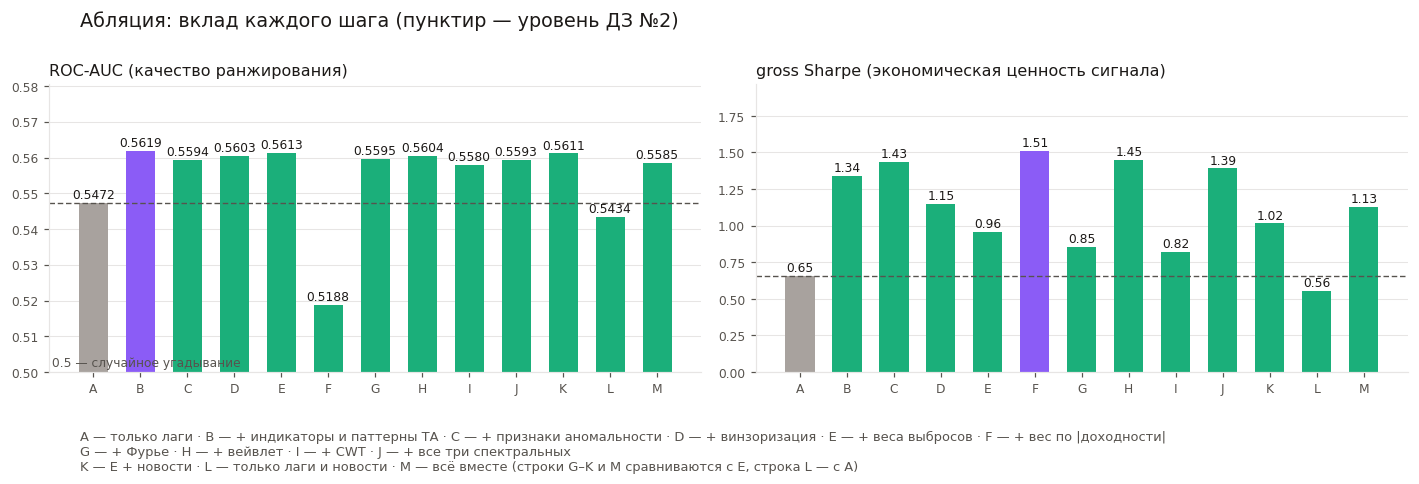

In [31]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.2))
labels = [i.split(".")[0] for i in ablation.index]
x = np.arange(len(ablation))
for ax, col, title, fmt in (
        (axes[0], "roc_auc", "ROC-AUC (качество ранжирования)", lambda v: f"{v:.4f}"),
        (axes[1], "gross_sharpe", "gross Sharpe (экономическая ценность сигнала)", lambda v: f"{v:.2f}")):
    vals = ablation[col].to_numpy()
    colors = [COLORS["HW2_Baseline"]] + [COLORS["CatBoost"]] * (len(vals) - 1)
    ax.bar(x, vals, color=colors, width=0.62)
    best = int(np.argmax(vals))
    ax.bar(best, vals[best], color=COLORS["Ensemble"], width=0.62)
    for xi, v in enumerate(vals):
        ax.annotate(fmt(v), xy=(xi, v), xytext=(0, 3), textcoords="offset points",
                    ha="center", fontsize=8, color=INK)
    ax.axhline(vals[0], color=INK_MUTED, linewidth=0.9, linestyle=(0, (4, 2)))
    ax.set_xticks(x)
    ax.set_xticklabels(labels, fontsize=9)
    ax.set_title(title, color=INK, loc="left", fontsize=10.5)
    # у ROC-AUC содержательный ноль — это 0.5 (случайное угадывание), от него и строим шкалу,
    # иначе разница 0.5455 против 0.5615 визуально неразличима
    floor = 0.5 if col == "roc_auc" else 0.0
    ax.set_ylim(floor, max(vals) + (max(vals) - floor) * 0.30)
    if floor:
        ax.annotate("0.5 — случайное угадывание", xy=(0.005, 0.02), xycoords="axes fraction",
                    fontsize=8, color=INK_MUTED)
    style_ax(ax)
fig.suptitle("Абляция: вклад каждого шага (пунктир — уровень ДЗ №2)",
             fontsize=12.5, color=INK, x=0.06, ha="left", y=1.0)
fig.tight_layout(rect=(0, 0.13, 1, 1))          # место под расшифровку букв под осью
fig.text(0.06, 0.005, "A — только лаги · B — + индикаторы и паттерны ТА · C — + признаки аномальности · "
                      "D — + винзоризация · E — + веса выбросов · F — + вес по |доходности|\n"
                      "G — + Фурье · H — + вейвлет · I — + CWT · J — + все три спектральных\n"
                      "K — E + новости · L — только лаги и новости · M — всё вместе "
                      "(строки G–K и M сравниваются с E, строка L — с A)",
         fontsize=8.5, color=INK_MUTED)
plt.show()

### 12.1 Вклад отдельных групп признаков

Обратная абляция: из полного набора по очереди удаляется одна группа. Чем сильнее падает
метрика, тем важнее группа. Важная оговорка: признаки сильно скоррелированы между группами
(RSI, стохастик и Williams %R измеряют почти одно и то же), поэтому удаление одной группы
редко что-то ломает — оставшиеся её «подменяют». Поэтому здесь надо смотреть не на абсолютную
величину, а на знак и на то, какая группа единственная даёт заметное падение.

  без «доходности»: готово


  без «скользящие средние»: готово


  без «осцилляторы»: готово


  без «волатильность»: готово


  без «объём»: готово


...

  без «CWT»: готово


  без «новости»: готово


  без «календарь»: готово



Полный набор: ROC-AUC = 0.5585, gross Sharpe = 1.126


,признаков осталось,roc_auc,Δ ROC-AUC,gross_sharpe,Δ gross Sharpe
убрана группа,,,,,
свечные паттерны,288,0.5553,-0.0032,0.1666,-0.9589
волатильность,316,0.5601,0.0016,0.5784,-0.5471
CWT,321,0.5592,0.0007,0.7449,-0.3807
объём,320,0.5596,0.0011,0.8501,-0.2755
аномалии,323,0.5577,-0.0009,0.8735,-0.2520
паттерны разворота,297,0.5623,0.0038,0.8788,-0.2468
календарь,326,0.5600,0.0015,0.9099,-0.2157
скользящие средние,284,0.5586,0.0001,0.9302,-0.1954
паттерны продолжения,314,0.5592,0.0007,1.0053,-0.1203


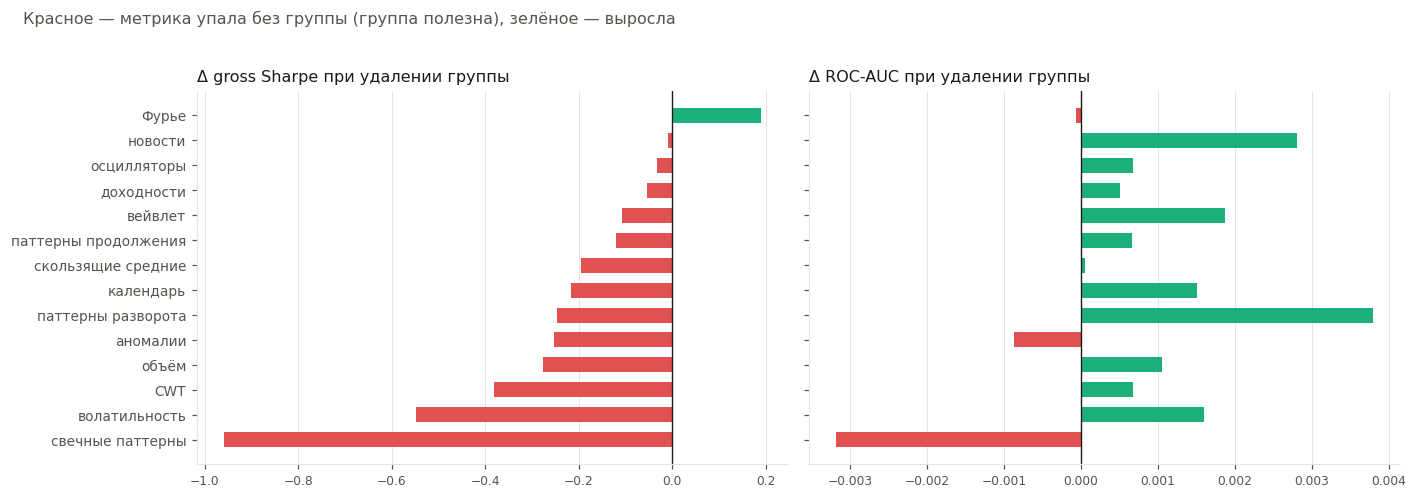

In [32]:
group_rows = []
for gname, gcols in FEATURE_GROUPS.items():
    keep = [c for c in feature_cols if c not in gcols]
    oof, mask = cv_oof(lambda: make_catboost(**CB_FIXED), keep, winsor=True, w_outlier=True)
    group_rows.append({"убрана группа": gname, "признаков осталось": len(keep),
                       **oof_report(oof, mask)})
    print(f"  без «{gname}»: готово")

oof_full, mask_full = cv_oof(lambda: make_catboost(**CB_FIXED), feature_cols,
                             winsor=True, w_outlier=True)
full_report = oof_report(oof_full, mask_full)
group_ablation = pd.DataFrame(group_rows).set_index("убрана группа")
group_ablation["Δ ROC-AUC"] = group_ablation["roc_auc"] - full_report["roc_auc"]
group_ablation["Δ gross Sharpe"] = group_ablation["gross_sharpe"] - full_report["gross_sharpe"]
group_ablation = group_ablation.sort_values("Δ gross Sharpe")
print(f"\nПолный набор: ROC-AUC = {full_report['roc_auc']:.4f}, "
      f"gross Sharpe = {full_report['gross_sharpe']:.3f}")
display(group_ablation[["признаков осталось", "roc_auc", "Δ ROC-AUC",
                        "gross_sharpe", "Δ gross Sharpe"]].round(4))

fig, axes = plt.subplots(1, 2, figsize=(13, 4.4), sharey=True)
yv = np.arange(len(group_ablation))
for ax, col, title in ((axes[0], "Δ gross Sharpe", "Δ gross Sharpe при удалении группы"),
                       (axes[1], "Δ ROC-AUC", "Δ ROC-AUC при удалении группы")):
    ax.barh(yv, group_ablation[col], height=0.6,
            color=[DOWN if v < 0 else UP for v in group_ablation[col]])
    ax.axvline(0, color=INK, linewidth=0.9)
    ax.set_title(title, color=INK, loc="left", fontsize=10.5)
    style_ax(ax, ygrid=False, xgrid=True)
axes[0].set_yticks(yv)
axes[0].set_yticklabels(group_ablation.index, fontsize=9)
fig.suptitle("Красное — метрика упала без группы (группа полезна), зелёное — выросла",
             fontsize=10.5, color=INK_MUTED, x=0.02, ha="left", y=1.02)
fig.tight_layout()
plt.show()

### 12.2 Отбор признаков

После добавления трёх спектральных семейств и новостного блока признаков стало 331, и вопрос «а не мусор ли
половина из них» перестал быть риторическим. Отбор идёт в два шага, оба — **только по
dev-набору**, валидация в отборе не участвует.

**Шаг 1. Чистка по корреляции.** Признаки сортируются по одномерной силе связи с меткой
(|ROC-AUC − 0.5| каждого признака в отдельности), после чего сверху вниз выбрасывается всё, что
коррелирует с уже оставленным сильнее 0.95. Это убирает буквальные дубли — RSI(7) против RSI(14),
доли энергии соседних полос — не решая, полезен признак или нет.

**Шаг 2. Признаки-тени (shadow features).** Ключевой вопрос — не «какая важность у признака»,
а «больше ли она, чем у заведомо бесполезного признака с тем же распределением». Поэтому к
каждому признаку добавляется его **перемешанная копия**: те же значения, случайно переставленные
во времени, то есть связь с меткой уничтожена, а распределение сохранено. CatBoost обучается на
удвоенном наборе, и порогом становится **максимальная важность среди теней**. Признак проходит,
если его важность выше этого порога.

Порог берётся в двух вариантах, и это принципиально. **Строгий** — максимум важности среди
всех теней: правило Boruta, но при 308 тенях сам максимум является экстремальным значением, и
отбор получается очень жёстким. **Мягкий** — 95-й перцентиль теней: допускает, что каждый
двадцатый прошедший признак случаен. Процедура повторяется `SEL_SHADOW_ROUNDS` раз с разными
перестановками, признак проходит, если прошёл в большинстве попыток, а какой из двух порогов
использовать дальше — решает кросс-валидация. Это упрощённая Boruta — и именно тот инструмент,
который нужен, чтобы честно ответить, зарабатывают ли спектральные и новостные признаки своё
место или просто добавляют шума в модель. Для новостей отдельно считается контрольный набор
«мягкий отбор без новостей»: те же признаки минус новостные, на той же кросс-валидации.

Дальше по ноутбуку — подбор гиперпараметров, финальные модели, валидация — используется
**отобранный** набор `MODEL_COLS`.

In [33]:
# Отбор признаков: чистка по корреляции + сравнение с признаками-тенями.
SEL_CORR_THRESHOLD = 0.95
SEL_SHADOW_ROUNDS = 3
SEL_MIN_VOTES = 2
# Порог теней берётся в двух вариантах. Строгий (максимум по всем теням) — правило Boruta,
# но максимум по сотням теней сам по себе экстремальное значение, и отбор получается
# очень жёстким. Мягкий (95-й перцентиль) допускает, что каждый двадцатый прошедший признак —
# случайность. Какой из двух брать, решает кросс-валидация ниже.
SEL_SOFT_QUANTILE = 0.95

X_sel = dev_df[feature_cols]
y_sel = dev_df["target"].to_numpy()
w_sel = sample_weights(dev_df, np.arange(len(dev_df)), w_outlier=True)

# ── шаг 1: одномерная сила и чистка по корреляции ───────────────────────────
t_start = time.perf_counter()
uni = pd.Series({c: abs(roc_auc_score(y_sel, X_sel[c].to_numpy()) - 0.5) for c in feature_cols})
corr = X_sel.corr().abs().to_numpy()
name_pos = {c: i for i, c in enumerate(feature_cols)}
kept_cols = []
for c in uni.sort_values(ascending=False).index:
    i = name_pos[c]
    if all(corr[i, name_pos[k]] < SEL_CORR_THRESHOLD for k in kept_cols):
        kept_cols.append(c)
print(f"Чистка по корреляции (порог {SEL_CORR_THRESHOLD}): "
      f"{len(feature_cols)} -> {len(kept_cols)} признаков, "
      f"{time.perf_counter() - t_start:.0f} с")

# ── шаг 2: признаки-тени ────────────────────────────────────────────────────
t_start = time.perf_counter()
votes = pd.Series(0, index=kept_cols, dtype=int)
votes_soft = pd.Series(0, index=kept_cols, dtype=int)
shadow_thresholds = []
X_kept = X_sel[kept_cols].reset_index(drop=True)
for r in range(SEL_SHADOW_ROUNDS):
    rng = np.random.default_rng(RANDOM_STATE + r)
    shadow = pd.DataFrame({f"shadow__{c}": rng.permutation(X_kept[c].to_numpy())
                           for c in kept_cols})
    both = pd.concat([X_kept, shadow], axis=1)
    model = make_catboost(**CB_FIXED)
    model.fit(both, y_sel, sample_weight=w_sel)
    imp_r = pd.Series(model.get_feature_importance(), index=both.columns)
    sh = imp_r[[f"shadow__{c}" for c in kept_cols]]
    thr, thr_soft = sh.max(), sh.quantile(SEL_SOFT_QUANTILE)
    shadow_thresholds.append((float(thr), float(thr_soft)))
    votes += (imp_r[kept_cols] > thr).astype(int)
    votes_soft += (imp_r[kept_cols] > thr_soft).astype(int)
    print(f"  попытка {r + 1}: порог строгий {thr:.4f} (прошли "
          f"{int((imp_r[kept_cols] > thr).sum())}), мягкий {thr_soft:.4f} (прошли "
          f"{int((imp_r[kept_cols] > thr_soft).sum())}) из {len(kept_cols)}", flush=True)

strict_cols = [c for c in feature_cols if votes.get(c, 0) >= SEL_MIN_VOTES]
soft_cols = [c for c in feature_cols if votes_soft.get(c, 0) >= SEL_MIN_VOTES]
print(f"Строгий отбор: {len(strict_cols)} признаков, мягкий: {len(soft_cols)} "
      f"(из {len(feature_cols)}), {(time.perf_counter() - t_start) / 60:.1f} мин")

# ── что осталось от каждой группы ───────────────────────────────────────────
sel_by_group = pd.DataFrame({
    "было": {g: len(cols) for g, cols in FEATURE_GROUPS.items()},
    "после чистки корреляций": {g: sum(c in kept_cols for c in cols)
                                for g, cols in FEATURE_GROUPS.items()},
    "мягкий отбор": {g: sum(c in soft_cols for c in cols) for g, cols in FEATURE_GROUPS.items()},
    "строгий отбор": {g: sum(c in strict_cols for c in cols)
                      for g, cols in FEATURE_GROUPS.items()},
}).rename_axis("группа")
sel_by_group["доля при мягком"] = (sel_by_group["мягкий отбор"] / sel_by_group["было"]).round(3)
display(sel_by_group.sort_values("доля при мягком", ascending=False))

# ── сравнение наборов на кросс-валидации ────────────────────────────────────
sel_variants = {
    "полный набор": feature_cols,
    "после чистки корреляций": kept_cols,
    "мягкий отбор": soft_cols,
    "строгий отбор": strict_cols,
    "мягкий отбор без спектральных": [c for c in soft_cols if c not in spectral_cols],
    "мягкий отбор без новостей": [c for c in soft_cols if c not in news_cols],
}
sel_rows = []
for label, cols_used in sel_variants.items():
    oof_s, mask_s = cv_oof(lambda: make_catboost(**CB_FIXED), cols_used,
                           winsor=True, w_outlier=True)
    sel_rows.append({"набор": label, "признаков": len(cols_used), **oof_report(oof_s, mask_s)})
    print(f"  {label:36s} готово")
selection_table = pd.DataFrame(sel_rows).set_index("набор")
display(selection_table[["признаков", "accuracy", "f1", "roc_auc", "pr_auc",
                         "gross_sharpe", "gross_return"]].round(4))

# Дальше по ноутбуку идёт тот из двух отборов, что лучше по ROC-AUC на кросс-валидации.
best_sel = selection_table.loc[["мягкий отбор", "строгий отбор"], "roc_auc"].idxmax()
MODEL_COLS = sel_variants[best_sel]
survived = [c for c in MODEL_COLS if c in spectral_cols]
survived_news = [c for c in MODEL_COLS if c in news_cols]
print(f"\nВ дальнейшем используется «{best_sel}»: {len(MODEL_COLS)} признаков из "
      f"{len(feature_cols)}, из них спектральных {len(survived)}"
      + (f": {', '.join(survived)}." if survived else "."))
print(f"Из {len(spectral_cols)} спектральных признаков отбор пережили {len(survived)}, "
      f"из {len(news_cols)} новостных — {len(survived_news)}"
      + (f": {', '.join(survived_news)}." if survived_news else "."))

Чистка по корреляции (порог 0.95): 331 -> 308 признаков, 6 с


  попытка 1: порог строгий 1.2471 (прошли 4), мягкий 0.4968 (прошли 26) из 308


  попытка 2: порог строгий 0.8312 (прошли 8), мягкий 0.4551 (прошли 27) из 308


  попытка 3: порог строгий 0.8232 (прошли 9), мягкий 0.4694 (прошли 27) из 308


Строгий отбор: 7 признаков, мягкий: 25 (из 331), 0.2 мин


...

  строгий отбор                        готово


  мягкий отбор без спектральных        готово


  мягкий отбор без новостей            готово


,признаков,accuracy,f1,roc_auc,pr_auc,gross_sharpe,gross_return
набор,,,,,,,
полный набор,331,0.5438,0.5591,0.5585,0.5494,1.1256,3.2130
после чистки корреляций,308,0.5414,0.5535,0.5588,0.5503,0.9067,1.9102
мягкий отбор,25,0.5478,0.5675,0.5648,0.5558,2.1328,22.1426
строгий отбор,7,0.5497,0.5679,0.5630,0.5475,2.3090,30.1720
мягкий отбор без спектральных,22,0.5481,0.5642,0.5645,0.5552,1.9576,16.2095
мягкий отбор без новостей,23,0.5461,0.5574,0.5612,0.5497,1.5594,7.7755



В дальнейшем используется «мягкий отбор»: 25 признаков из 331, из них спектральных 3: fft168_dom_period, fft512_top3_period, wl_den_last.
Из 61 спектральных признаков отбор пережили 3, из 24 новостных — 2: news_count_24, news_count_168.


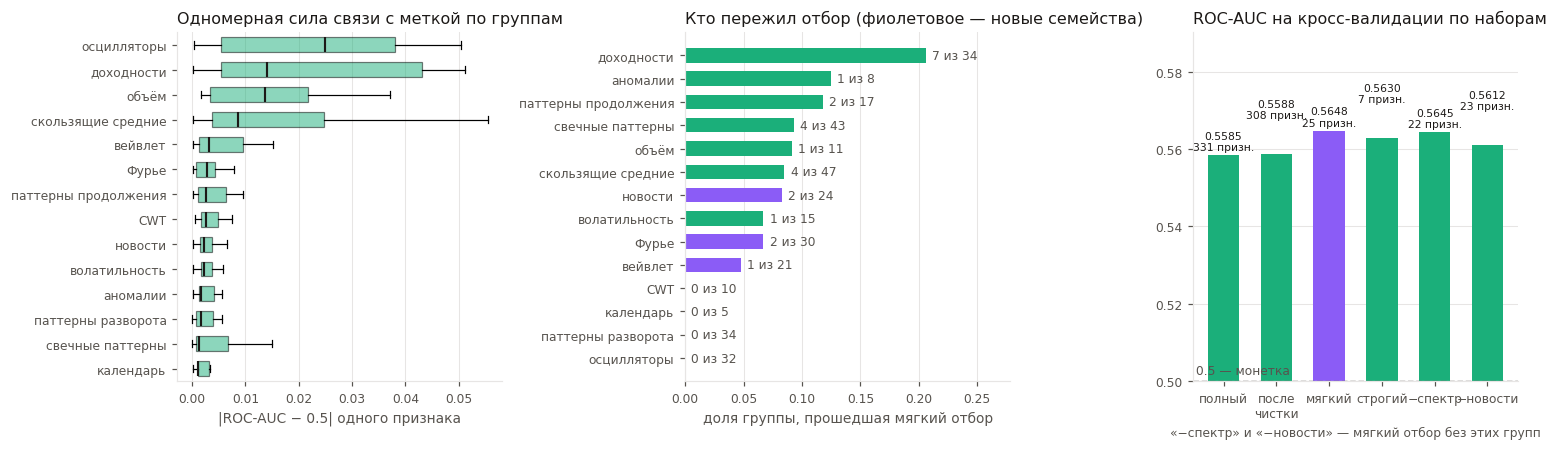

In [34]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4.2))

# ── 1. одномерная сила признаков по группам ─────────────────────────────────
ax = axes[0]
group_of_sel = {c: g for g, cols in FEATURE_GROUPS.items() for c in cols}
uni_df = pd.DataFrame({"группа": [group_of_sel[c] for c in uni.index], "сила": uni.to_numpy()})
grp_order = uni_df.groupby("группа")["сила"].median().sort_values().index
ax.boxplot([uni_df[uni_df["группа"] == g]["сила"].to_numpy() for g in grp_order],
           vert=False, widths=0.6, patch_artist=True, showfliers=False,
           boxprops=dict(facecolor=COLORS["CatBoost"], alpha=0.5, linewidth=0.8),
           medianprops=dict(color=INK, linewidth=1.4), whiskerprops=dict(linewidth=0.8),
           capprops=dict(linewidth=0.8))
ax.set_yticklabels(grp_order, fontsize=8)
ax.set_xlabel("|ROC-AUC − 0.5| одного признака", color=INK_MUTED, fontsize=9)
ax.set_title("Одномерная сила связи с меткой по группам", color=INK, fontsize=10.5, loc="left")
style_ax(ax, ygrid=False, xgrid=True)

# ── 2. доля признаков группы, прошедших отбор ───────────────────────────────
ax = axes[1]
share = sel_by_group.sort_values("доля при мягком")
ys = np.arange(len(share))
NEW_GROUPS = ("Фурье", "вейвлет", "CWT", "новости")
ax.barh(ys, share["доля при мягком"], height=0.62,
        color=[COLORS["Ensemble"] if g in NEW_GROUPS else COLORS["CatBoost"]
               for g in share.index])
for yi, (g, row) in enumerate(share.iterrows()):
    ax.annotate(f"{int(row['мягкий отбор'])} из {int(row['было'])}",
                xy=(row["доля при мягком"], yi), xytext=(4, 0), textcoords="offset points",
                va="center", fontsize=8, color=INK_MUTED)
ax.set_yticks(ys)
ax.set_yticklabels(share.index, fontsize=8)
ax.set_xlim(0, max(share["доля при мягком"]) * 1.35)
ax.set_xlabel("доля группы, прошедшая мягкий отбор", color=INK_MUTED, fontsize=9)
ax.set_title("Кто пережил отбор (фиолетовое — новые семейства)",
             color=INK, fontsize=10.5, loc="left")
style_ax(ax, ygrid=False, xgrid=True)

# ── 3. сравнение наборов ────────────────────────────────────────────────────
ax = axes[2]
xs = np.arange(len(selection_table))
vals = selection_table["roc_auc"].to_numpy()
ax.bar(xs, vals, width=0.6, color=[COLORS["CatBoost"]] * len(xs))
best = int(np.argmax(vals))
ax.bar(best, vals[best], width=0.6, color=COLORS["Ensemble"])
for xi, (v, k) in enumerate(zip(vals, selection_table["признаков"])):
    # подписи соседних столбиков разводятся по высоте: иначе «0.5585 331 призн.» и
    # «0.5588 308 призн.» слипаются в нечитаемую строку
    ax.annotate(f"{v:.4f}\n{int(k)} призн.", xy=(xi, v), xytext=(0, 3 + 20 * (xi % 2)),
                textcoords="offset points", ha="center", fontsize=7, color=INK)
ax.axhline(0.5, color=INK_MUTED, linewidth=0.9, linestyle=(0, (4, 2)))
ax.set_ylim(0.5, max(vals) * 1.045)
ax.set_xticks(xs)
SEL_SHORT = {"полный набор": "полный", "после чистки корреляций": "после\nчистки",
             "мягкий отбор": "мягкий", "строгий отбор": "строгий",
             "мягкий отбор без спектральных": "−спектр",
             "мягкий отбор без новостей": "−новости"}
ax.set_xticklabels([SEL_SHORT.get(t, t) for t in selection_table.index],
                   rotation=0, ha="center", fontsize=7.5)
ax.set_xlabel("«−спектр» и «−новости» — мягкий отбор без этих групп",
              color=INK_MUTED, fontsize=8)
ax.set_title("ROC-AUC на кросс-валидации по наборам", color=INK, fontsize=10.5, loc="left")
ax.annotate("0.5 — монетка", xy=(0.01, 0.02), xycoords="axes fraction",
            fontsize=8, color=INK_MUTED)
style_ax(ax)

fig.tight_layout()
plt.show()

## 13. Выбор горизонта прогноза

Направление следующего часа — самая шумная из возможных целей. Логично проверить, не станет ли
задача легче, если предсказывать направление через 6, 12 или 24 часа: сигнал будет более
инерционным, а значит и позиция будет реже меняться. Сравнение идёт на той же
кросс-валидации, с тем же CatBoost и с разрывом фолдов, равным горизонту.

In [35]:
horizon_rows = []
for H in (1, 6, 12, 24):
    d = feat.copy()
    d["target"] = (d["close"].shift(-H) > d["close"]).astype("float")
    d = d.dropna(subset=["target", "fwd_ret"]).reset_index(drop=True)
    d["target"] = d["target"].astype(int)
    dev_h = d.iloc[:int(len(d) * TEST_END) - H].reset_index(drop=True)
    oof_h, mask_h = cv_oof(lambda: make_catboost(**CB_FIXED), MODEL_COLS,
                           winsor=True, w_outlier=True, data=dev_h,
                           splitter=TimeSeriesSplit(n_splits=N_CV_SPLITS, gap=H))
    rep = oof_report(oof_h, mask_h, data=dev_h)
    # инерционность прогноза: как часто знак сигнала меняется от бара к бару
    sign_flips = float((np.diff((oof_h[mask_h] >= 0.5).astype(int)) != 0).mean())
    horizon_rows.append({"горизонт, ч": H, "roc_auc": rep["roc_auc"], "pr_auc": rep["pr_auc"],
                         "accuracy": rep["accuracy"], "gross_sharpe": rep["gross_sharpe"],
                         "смена знака прогноза, доля баров": sign_flips})
    print(f"  горизонт {H:2d} ч: готово")

horizon_tab = pd.DataFrame(horizon_rows).set_index("горизонт, ч")
display(horizon_tab.round(4))
best_h = int(horizon_tab["roc_auc"].idxmax())
print(f"Лучший горизонт по ROC-AUC: {best_h} ч. "
      f"Дальше используется HORIZON = {HORIZON} ч.")
print("Удлинение горизонта не помогает: ранжирование ухудшается быстрее, чем растёт инерционность\n"
      "прогноза. Проблему оборота решает не горизонт цели, а торговый слой (раздел 14).")

  горизонт  1 ч: готово


  горизонт  6 ч: готово


  горизонт 12 ч: готово


  горизонт 24 ч: готово


,roc_auc,pr_auc,accuracy,gross_sharpe,"смена знака прогноза, доля баров"
"горизонт, ч",,,,,
1,0.5648,0.5558,0.5478,2.1328,0.3328
6,0.5393,0.5374,0.5266,1.4371,0.2240
12,0.5204,0.5140,0.5186,0.3005,0.1571
24,0.5272,0.5250,0.5239,1.0260,0.1262


Лучший горизонт по ROC-AUC: 1 ч. Дальше используется HORIZON = 1 ч.
Удлинение горизонта не помогает: ранжирование ухудшается быстрее, чем растёт инерционность
прогноза. Проблему оборота решает не горизонт цели, а торговый слой (раздел 14).


## 14. Настройка торгового слоя

Берём OOF-вероятности лучшей конфигурации из абляции и перебираем параметры торгового слоя:
режим, ширину зоны неопределённости `q`, окно сглаживания `span` и период ребалансировки.
Все варианты оцениваются по чистому (net) Sharpe на dev-наборе; валидация не участвует.

Правило ДЗ №2 «всегда в рынке»: net Sharpe =  -9.11, оборот =    17503 ед., net = -100.0%
Выбранный торговый слой:       net Sharpe =   0.37, оборот =      194 ед., net = +19.5%
  параметры: {'mode': 'long_flat', 'span': 4, 'rebalance': 24, 'q': 0.1}
  оборот снижен в 90 раз

Топ-10 конфигураций по net Sharpe (колонка «прибыльных блоков» — сколько из 5 подпериодов прибыльны; фильтр требует не меньше 3):


,mode,span,rebalance,sharpe,net,gross,turnover,n_trades,time_in_market,экспозиция,sharpe_min_блок,прибыльных блоков,q,scale,допустима
59,ramp,1,24,0.827,0.164,0.191,23.107,79,0.036,0.010,-0.133,4,0.02,NaN,False
60,ramp,1,24,0.578,0.135,0.190,47.035,189,0.092,0.022,-0.471,4,0.05,NaN,False
35,ramp,1,6,0.471,0.105,0.215,94.447,309,0.036,0.011,-0.495,4,0.02,NaN,False
61,ramp,1,24,0.420,0.112,0.210,84.393,381,0.191,0.042,-0.649,4,0.10,NaN,False
65,long_flat,1,24,0.410,0.193,0.315,98.000,98,0.051,0.051,-0.304,3,0.05,NaN,False
138,long_flat,4,24,0.366,0.195,0.450,194.000,194,0.106,0.106,-0.947,3,0.10,NaN,True
51,hold,1,24,0.343,0.124,2.140,1027.000,514,0.999,0.999,-0.785,3,0.10,NaN,True
64,long_flat,1,24,0.342,0.110,0.158,42.000,42,0.020,0.020,0.000,4,0.02,NaN,False
68,long_flat,1,24,0.329,0.181,0.920,486.000,486,0.343,0.343,-1.598,4,0.35,NaN,True
139,long_flat,4,24,0.283,0.131,0.602,348.000,348,0.211,0.211,-1.266,3,0.20,NaN,True


Из 288 конфигураций 197 удовлетворяют требованиям к активности (оборот от 6 единиц капитала в год и средняя экспозиция от 10%), из них 27 прибыльны хотя бы в 3 подпериодах.
Без ограничений победила бы вырожденная конфигурация (ramp, Sharpe 0.83) с оборотом 23.1 ед. и средней экспозицией 1.0% — она «зарабатывает» тем, что не торгует.


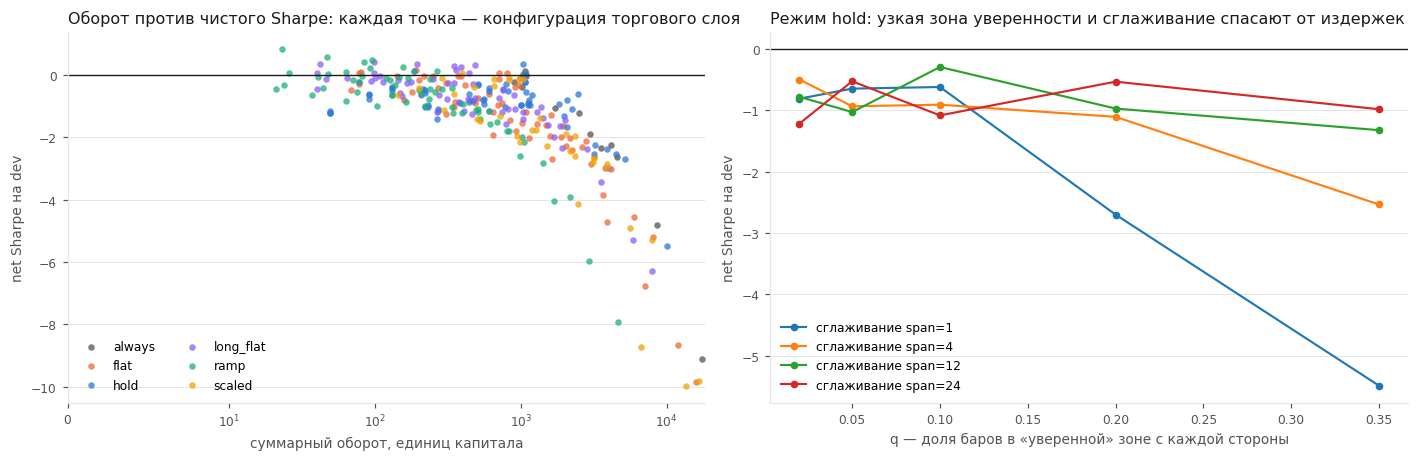

In [36]:
signal_params, signal_tab, signal_ok = tune_signal_layer(
    oof_full[mask_full], dates_dev.to_numpy()[mask_full], fwd_dev.to_numpy()[mask_full])

hw2_rule = signal_tab.query("mode == 'always' and span == 1 and rebalance == 1").iloc[0]
# строка ВЫБРАННОЙ конфигурации — той, что вернул tune_signal_layer с учётом фильтра
# активности. Брать глобальный максимум Sharpe нельзя: без фильтра побеждает конфигурация,
# которая почти не торгует, и напечатанное разошлось бы с реально выбранными параметрами.
sel = np.logical_and.reduce([(signal_tab[k] == v).to_numpy() for k, v in signal_params.items()])
best_row = signal_tab[sel].iloc[0]
print(f"Правило ДЗ №2 «всегда в рынке»: net Sharpe = {hw2_rule['sharpe']:6.2f}, "
      f"оборот = {hw2_rule['turnover']:8.0f} ед., net = {hw2_rule['net']:+.1%}")
print(f"Выбранный торговый слой:       net Sharpe = {best_row['sharpe']:6.2f}, "
      f"оборот = {best_row['turnover']:8.0f} ед., net = {best_row['net']:+.1%}")
print(f"  параметры: {signal_params}")
print(f"  оборот снижен в {hw2_rule['turnover'] / max(best_row['turnover'], 1e-9):.0f} раз")
print(f"\nТоп-10 конфигураций по net Sharpe (колонка «прибыльных блоков» — сколько из "
      f"{N_BLOCKS} подпериодов прибыльны; фильтр требует не меньше {MIN_POSITIVE_BLOCKS}):")
display(signal_tab.sort_values("sharpe", ascending=False).head(10).round(3))
n_feasible = int(signal_tab["допустима"].sum())
n_stable = int((signal_tab["допустима"] &
                (signal_tab["прибыльных блоков"] >= MIN_POSITIVE_BLOCKS)).sum())
print(f"Из {len(signal_tab)} конфигураций {n_feasible} удовлетворяют требованиям к активности "
      f"(оборот от {MIN_TURNOVER_PER_YEAR} единиц капитала в год и средняя экспозиция от "
      f"{MIN_AVG_EXPOSURE:.0%}), из них {n_stable} прибыльны хотя бы в "
      f"{MIN_POSITIVE_BLOCKS} подпериодах.")
best_unconstrained = signal_tab.loc[signal_tab["sharpe"].idxmax()]
if not best_unconstrained["допустима"]:
    print(f"Без ограничений победила бы вырожденная конфигурация "
          f"({best_unconstrained['mode']}, Sharpe {best_unconstrained['sharpe']:.2f}) "
          f"с оборотом {best_unconstrained['turnover']:.1f} ед. и средней экспозицией "
          f"{best_unconstrained['экспозиция']:.1%} — она «зарабатывает» тем, что не торгует.")

fig, axes = plt.subplots(1, 2, figsize=(13, 4.3))
mode_colors = {"always": INK_MUTED, "hold": COLORS["LogisticRegression"],
               "flat": COLORS["DecisionTree"], "ramp": COLORS["CatBoost"],
               "long_flat": COLORS["Ensemble"], "scaled": "#f0a202"}
for mode, grp in signal_tab.groupby("mode"):
    axes[0].scatter(grp["turnover"], grp["sharpe"], s=18, alpha=0.75,
                    color=mode_colors[mode], label=mode, linewidth=0)
axes[0].axhline(0, color=INK, linewidth=0.9)
axes[0].set_xscale("symlog", linthresh=10)
axes[0].set_xlim(left=0)
axes[0].set_xlabel("суммарный оборот, единиц капитала", color=INK_MUTED, fontsize=9)
axes[0].set_ylabel("net Sharpe на dev", color=INK_MUTED, fontsize=9)
axes[0].set_title("Оборот против чистого Sharpe: каждая точка — конфигурация торгового слоя",
                  color=INK, loc="left", fontsize=10.5)
axes[0].legend(frameon=False, fontsize=8, ncol=2)
style_ax(axes[0])

sub = signal_tab[(signal_tab["mode"] == "hold") & (signal_tab["rebalance"] == 1)]
for span, grp in sub.groupby("span"):
    g = grp.sort_values("q")
    axes[1].plot(g["q"], g["sharpe"], marker="o", markersize=4, linewidth=1.4,
                 label=f"сглаживание span={span}")
axes[1].axhline(0, color=INK, linewidth=0.9)
axes[1].set_xlabel("q — доля баров в «уверенной» зоне с каждой стороны", color=INK_MUTED, fontsize=9)
axes[1].set_ylabel("net Sharpe на dev", color=INK_MUTED, fontsize=9)
axes[1].set_title("Режим hold: узкая зона уверенности и сглаживание спасают от издержек",
                  color=INK, loc="left", fontsize=10.5)
axes[1].legend(frameon=False, fontsize=8)
style_ax(axes[1])
fig.tight_layout()
plt.show()

## 15. Подбор гиперпараметров: Optuna + кросс-валидация временных рядов

> Кросс-валидация временных рядов: данные разбиваются на k частей (fold), обучение идёт на
> частях, предшествующих тестированию, и процедура повторяется k раз.

Используется `TimeSeriesSplit` (расширяющееся окно) на dev-наборе (train + test) с разрывом
`gap = EMBARGO`. Валидационная выборка в подборе не участвует.

Optuna максимизирует **чистый (net) коэффициент Шарпа** — метрику, которая уже включает издержки.
Внутри каждой попытки:

1. считаются OOF-вероятности на 5 фолдах;
2. на них подбирается торговый слой (раздел 14);
3. значением попытки становится net Sharpe при лучшем торговом слое.

Дополнительно перебирается способ взвешивания наблюдений (`w_ret`) — тот самый приём из
раздела 12, который улучшает экономику ценой ROC-AUC. Все остальные метрики сохраняются
в `user_attrs`, чтобы затем сопоставить статистическое качество с экономикой.

**Защита от вырождения.** У задачи «максимизировать Sharpe» есть тривиальное решение:
не торговать. Стратегия с нулевым оборотом не платит комиссий, а если её крошечная
постоянная позиция случайно совпала с направлением рынка на dev-периоде, формальный Sharpe
получается прекрасным. При первом запуске Optuna нашла ровно такой угол: логистическая
регрессия с `C = 3e-4` и штрафом L1 почти обнуляла коэффициенты, выдавала почти постоянную
вероятность, а торговый слой превращал её в неподвижную позицию размером 7% капитала —
CV Sharpe 1.42 при обороте 0.15 единицы в год. Формально это лучший Sharpe из всех, фактически
это buy & hold с плечом 0.07, замаскированный под модель. Поэтому попытка штрафуется значением
`DEGENERATE_PENALTY`, если разброс OOF-вероятностей меньше 0.001 (модель ничего не ранжирует)
или если ни одна конфигурация торгового слоя не проходит требования к активности из раздела 14.

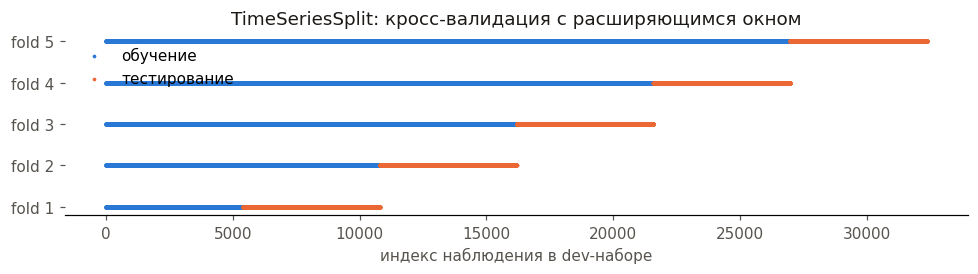

In [37]:
fig, ax = plt.subplots(figsize=(9, 2.6))
for i, (tr_idx, te_idx) in enumerate(tscv.split(X_dev_all)):
    ax.scatter(tr_idx, [i] * len(tr_idx), c=COLORS["LogisticRegression"], s=2,
               label="обучение" if i == 0 else None)
    ax.scatter(te_idx, [i] * len(te_idx), c=COLORS["DecisionTree"], s=2,
               label="тестирование" if i == 0 else None)
ax.set_yticks(range(N_CV_SPLITS))
ax.set_yticklabels([f"fold {i + 1}" for i in range(N_CV_SPLITS)])
ax.set_xlabel("индекс наблюдения в dev-наборе", color=INK_MUTED)
ax.set_title("TimeSeriesSplit: кросс-валидация с расширяющимся окном", color=INK)
ax.legend(loc="upper left", frameon=False)
for s in ("top", "right", "left"):
    ax.spines[s].set_visible(False)
ax.tick_params(colors=INK_MUTED)
fig.tight_layout()
plt.show()


DEGENERATE_PENALTY = -10.0        # значение попытки, если модель или слой вырождены


def objective_factory(build_from_params, param_space):
    """Единая целевая функция: OOF -> торговый слой -> net Sharpe."""
    def objective(trial):
        params = param_space(trial)
        w_ret = trial.suggest_categorical("w_ret", [False, True])
        oof, mask = cv_oof(lambda: build_from_params(params), MODEL_COLS,
                           winsor=True, w_outlier=True, w_ret=w_ret)
        d, f = dates_dev.to_numpy()[mask], fwd_dev.to_numpy()[mask]
        # вырожденная модель (почти постоянная вероятность) не ранжирует ничего:
        # любая «прибыль» от неё — это отказ от торговли, а не прогноз
        if float(np.std(oof[mask])) < 1e-3:
            trial.set_user_attr("degenerate", True)
            return DEGENERATE_PENALTY
        sig_prm, _, ok = tune_signal_layer(oof[mask], d, f)
        if not ok:
            trial.set_user_attr("degenerate", True)
            return DEGENERATE_PENALTY
        pos = positions_from_proba(oof[mask], **sig_prm)
        _, trade = backtest(d, f, pos)
        rep = oof_report(oof, mask)
        for k, v in {**rep, **{f"trade_{k}": v for k, v in trade.items()}}.items():
            trial.set_user_attr(k, float(v))
        trial.set_user_attr("signal_params", sig_prm)
        return trade["sharpe"]
    return objective


def run_study(objective, name):
    study = optuna.create_study(direction="maximize",
                                sampler=optuna.samplers.TPESampler(seed=RANDOM_STATE))
    study.optimize(objective, n_trials=N_TRIALS, show_progress_bar=False)
    a = study.best_trial.user_attrs
    n_deg = sum(1 for t in study.trials if t.user_attrs.get("degenerate"))
    print(f"{name}: лучший CV net Sharpe = {study.best_value:.3f} "
          f"({N_TRIALS} попыток, отклонено как вырожденные: {n_deg})")
    print(f"  гиперпараметры:  {study.best_params}")
    print(f"  торговый слой:   {a['signal_params']}")
    print(f"  на тех же фолдах: ROC-AUC={a['roc_auc']:.4f}, accuracy={a['accuracy']:.4f}, "
          f"F1={a['f1']:.4f} | net={a['trade_total_return']:+.2%}, "
          f"gross={a['trade_gross_return']:+.2%}, оборот={a['trade_turnover_units']:.0f}")
    return study


def make_logreg(**params):
    # RobustScaler вместо StandardScaler: медиана и межквартильный размах не «съезжают»
    # от экстремальных баров, что важно на тяжёлых хвостах криптодоходностей.
    return Pipeline([
        ("scaler", RobustScaler(quantile_range=(5, 95))),
        ("clf", LogisticRegression(max_iter=500, tol=1e-3, random_state=RANDOM_STATE, **params)),
    ])


def make_tree(**params):
    return DecisionTreeClassifier(random_state=RANDOM_STATE, **params)

In [38]:
def space_logreg(trial):
    params = {
        "C": trial.suggest_float("C", 1e-4, 1e2, log=True),
        "penalty": trial.suggest_categorical("penalty", ["l1", "l2"]),
        "class_weight": trial.suggest_categorical("class_weight", [None, "balanced"]),
    }
    params["solver"] = "saga" if params["penalty"] == "l1" else "lbfgs"
    return params


study_logreg = run_study(objective_factory(lambda p: make_logreg(**p), space_logreg),
                         "LogisticRegression")

LogisticRegression: лучший CV net Sharpe = 1.776 (25 попыток, отклонено как вырожденные: 3)
  гиперпараметры:  {'C': 0.013820379228637011, 'penalty': 'l2', 'class_weight': 'balanced', 'w_ret': True}
  торговый слой:   {'mode': 'flat', 'span': 24, 'rebalance': 6, 'q': 0.1}
  на тех же фолдах: ROC-AUC=0.5089, accuracy=0.5062, F1=0.5706 | net=+284.18%, gross=+499.04%, оборот=444


In [39]:
def space_tree(trial):
    return {
        "max_depth": trial.suggest_int("max_depth", 2, 14),
        "min_samples_split": trial.suggest_int("min_samples_split", 2, 200),
        "min_samples_leaf": trial.suggest_int("min_samples_leaf", 5, 300),
        "max_features": trial.suggest_float("max_features", 0.2, 1.0),
        "criterion": trial.suggest_categorical("criterion", ["gini", "entropy"]),
    }


study_tree = run_study(objective_factory(lambda p: make_tree(**p), space_tree), "DecisionTree")

DecisionTree: лучший CV net Sharpe = 1.741 (25 попыток, отклонено как вырожденные: 0)
  гиперпараметры:  {'max_depth': 7, 'min_samples_split': 72, 'min_samples_leaf': 196, 'max_features': 0.49512806334661275, 'criterion': 'gini', 'w_ret': True}
  торговый слой:   {'mode': 'hold', 'span': 1, 'rebalance': 24, 'q': 0.02}
  на тех же фолдах: ROC-AUC=0.5028, accuracy=0.4994, F1=0.4955 | net=+1095.60%, gross=+1376.93%, оборот=211


In [40]:
def space_catboost(trial):
    return {
        "depth": trial.suggest_int("depth", 3, 8),
        "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.3, log=True),
        "l2_leaf_reg": trial.suggest_float("l2_leaf_reg", 1.0, 20.0, log=True),
        "iterations": trial.suggest_int("iterations", 100, 500),
        "rsm": trial.suggest_float("rsm", 0.3, 1.0),
    }


study_catboost = run_study(objective_factory(lambda p: make_catboost(**p), space_catboost),
                           "CatBoost")

CatBoost: лучший CV net Sharpe = 1.281 (25 попыток, отклонено как вырожденные: 0)
  гиперпараметры:  {'depth': 6, 'learning_rate': 0.011711509955524094, 'l2_leaf_reg': 6.172115948107071, 'iterations': 168, 'rsm': 0.3455361150896956, 'w_ret': True}
  торговый слой:   {'mode': 'always', 'span': 24, 'rebalance': 24}
  на тех же фолдах: ROC-AUC=0.5206, accuracy=0.5142, F1=0.5371 | net=+448.88%, gross=+887.44%, оборот=587


In [41]:
studies = {"LogisticRegression": study_logreg, "DecisionTree": study_tree, "CatBoost": study_catboost}
tuning_summary = pd.DataFrame([
    {
        "model": name,
        "CV net Sharpe": st.best_value,
        "CV roc_auc": st.best_trial.user_attrs["roc_auc"],
        "CV pr_auc": st.best_trial.user_attrs["pr_auc"],
        "CV gross Sharpe": st.best_trial.user_attrs["gross_sharpe"],
        "CV net": st.best_trial.user_attrs["trade_total_return"],
        "CV оборот": st.best_trial.user_attrs["trade_turnover_units"],
        "вес по |ret|": st.best_params.get("w_ret"),
        "торговый слой": st.best_trial.user_attrs["signal_params"],
    }
    for name, st in studies.items()
]).set_index("model")
display(tuning_summary.drop(columns="торговый слой").round(4))
for name, st in studies.items():
    print(f"{name}:\n  модель: {st.best_params}\n  слой:   {st.best_trial.user_attrs['signal_params']}")

,CV net Sharpe,CV roc_auc,CV pr_auc,CV gross Sharpe,CV net,CV оборот,вес по |ret|
model,,,,,,,
LogisticRegression,1.7763,0.5089,0.5081,2.9532,2.8418,444.0,True
DecisionTree,1.7414,0.5028,0.5097,0.6467,10.9560,211.0,True
CatBoost,1.2808,0.5206,0.5194,2.9310,4.4888,587.0,True


LogisticRegression:
  модель: {'C': 0.013820379228637011, 'penalty': 'l2', 'class_weight': 'balanced', 'w_ret': True}
  слой:   {'mode': 'flat', 'span': 24, 'rebalance': 6, 'q': 0.1}
DecisionTree:
  модель: {'max_depth': 7, 'min_samples_split': 72, 'min_samples_leaf': 196, 'max_features': 0.49512806334661275, 'criterion': 'gini', 'w_ret': True}
  слой:   {'mode': 'hold', 'span': 1, 'rebalance': 24, 'q': 0.02}
CatBoost:
  модель: {'depth': 6, 'learning_rate': 0.011711509955524094, 'l2_leaf_reg': 6.172115948107071, 'iterations': 168, 'rsm': 0.3455361150896956, 'w_ret': True}
  слой:   {'mode': 'always', 'span': 24, 'rebalance': 24}


## 16. Финальные модели

Модели с лучшими гиперпараметрами переобучаются на всём dev-наборе (train + test) — тех же
данных, на которых шёл подбор, и на отобранном наборе признаков `MODEL_COLS` из раздела 12.2.
Границы винзоризации и веса наблюдений считаются по dev.
Режим торгового слоя и ширина зоны `q` берутся из подбора на OOF (раздел 15), а сами числовые
пороги считаются как квантили **dev-прогнозов уже обученной финальной модели** — именно она
уходит в эксплуатацию, и её распределение вероятностей отличается от OOF (подробнее — в
`apply_signal`, раздел 18). На валидации применяются эти зафиксированные пороги, а не
пересчитанные по будущим данным квантили.

Дополнительно строится **ансамбль** — среднее вероятностей трёх моделей. Усреднение снижает
дисперсию прогноза, а значит и число ложных переворотов позиции.

In [42]:
final_specs = {
    "LogisticRegression": (make_logreg, {**{k: v for k, v in study_logreg.best_params.items()
                                            if k != "w_ret"}}),
    "DecisionTree": (make_tree, {k: v for k, v in study_tree.best_params.items() if k != "w_ret"}),
    "CatBoost": (make_catboost, {k: v for k, v in study_catboost.best_params.items() if k != "w_ret"}),
}
final_specs["LogisticRegression"][1]["solver"] = (
    "saga" if final_specs["LogisticRegression"][1]["penalty"] == "l1" else "lbfgs")

dev_bounds = winsor_bounds(dev_df[MODEL_COLS])
X_dev_w = apply_winsor(dev_df[MODEL_COLS], dev_bounds)
X_val_w = apply_winsor(val_df[MODEL_COLS], dev_bounds)
y_dev_full, y_val = dev_df["target"], val_df["target"]

final_models, dev_oof, val_proba, signal_by_model, dev_proba_final = {}, {}, {}, {}, {}
for name, (builder, params) in final_specs.items():
    w_ret = studies[name].best_params.get("w_ret", False)
    # OOF на dev — источник и порогов торгового слоя, и эталонного распределения вероятностей
    oof, mask = cv_oof(lambda: builder(**params), MODEL_COLS,
                       winsor=True, w_outlier=True, w_ret=w_ret)
    dev_oof[name] = (oof, mask)
    signal_by_model[name] = studies[name].best_trial.user_attrs["signal_params"]

    model = builder(**params)
    w = sample_weights(dev_df, np.arange(len(dev_df)), w_outlier=True, w_ret=w_ret)
    if hasattr(model, "steps"):
        model.fit(X_dev_w, y_dev_full, **{f"{model.steps[-1][0]}__sample_weight": w})
    else:
        model.fit(X_dev_w, y_dev_full, sample_weight=w)
    final_models[name] = model
    dev_proba_final[name] = predict_proba1(model, X_dev_w)
    val_proba[name] = predict_proba1(model, X_val_w)
    print(f"{name}: обучена на {len(X_dev_w)} наблюдениях, "
          f"средняя вероятность роста на валидации {val_proba[name].mean():.3f}")

# ансамбль: усреднение вероятностей, торговый слой подбирается на усреднённом OOF
common_mask = np.all([dev_oof[n][1] for n in final_models], axis=0)
ens_oof = np.nanmean(np.vstack([dev_oof[n][0] for n in final_models]), axis=0)
signal_by_model["Ensemble"], _, _ = tune_signal_layer(
    ens_oof[common_mask], dates_dev.to_numpy()[common_mask], fwd_dev.to_numpy()[common_mask])
dev_oof["Ensemble"] = (ens_oof, common_mask)
dev_proba_final["Ensemble"] = np.mean([dev_proba_final[n] for n in final_models], axis=0)
val_proba["Ensemble"] = np.mean([val_proba[n] for n in final_models], axis=0)
print(f"Ensemble: торговый слой {signal_by_model['Ensemble']}")

LogisticRegression: обучена на 32378 наблюдениях, средняя вероятность роста на валидации 0.513


DecisionTree: обучена на 32378 наблюдениях, средняя вероятность роста на валидации 0.514


CatBoost: обучена на 32378 наблюдениях, средняя вероятность роста на валидации 0.512


Ensemble: торговый слой {'mode': 'hold', 'span': 12, 'rebalance': 1, 'q': 0.02}


In [43]:
# Устойчивость выбранных стратегий на dev: Sharpe по подпериодам OOF-периода.
stability_rows = []
for name in list(final_models) + ["Ensemble"]:
    oof, mask = dev_oof[name]
    pos = positions_from_proba(oof[mask], **signal_by_model[name])
    curve, m = backtest(dates_dev.to_numpy()[mask], fwd_dev.to_numpy()[mask], pos)
    blocks = np.array_split(curve["strategy_return"].to_numpy(), N_BLOCKS)
    row = {"стратегия": name, "net Sharpe (весь dev)": m["sharpe"]}
    for bi, b in enumerate(blocks, 1):
        row[f"блок {bi}"] = float(b.mean() / b.std(ddof=0) * np.sqrt(PERIODS_PER_YEAR)) if b.std(ddof=0) > 0 else 0.0
    row["прибыльных блоков"] = int(sum(row[f"блок {bi}"] > 0 for bi in range(1, N_BLOCKS + 1)))
    stability_rows.append(row)
print("Sharpe по подпериодам dev-выборки (проверка, что результат не держится на одной сделке):")
display(pd.DataFrame(stability_rows).set_index("стратегия").round(3))

Sharpe по подпериодам dev-выборки (проверка, что результат не держится на одной сделке):


,net Sharpe (весь dev),блок 1,блок 2,блок 3,блок 4,блок 5,прибыльных блоков
стратегия,,,,,,,
LogisticRegression,1.776,2.769,2.704,1.706,0.282,1.115,5
DecisionTree,1.741,1.103,1.717,2.260,3.229,1.121,5
CatBoost,1.281,2.412,0.368,2.285,1.016,0.563,5
Ensemble,1.745,0.713,1.984,2.552,3.356,0.909,5


### 16.1 Воспроизведение стратегии ДЗ №2 как точки отсчёта

Чтобы улучшение измерялось честно, рядом строится стратегия из ДЗ №2 на тех же выборках:
CatBoost по одним лагам доходности, без обработки выбросов, правило «всегда в рынке».

In [44]:
hw2_model = make_catboost(iterations=200, depth=4, learning_rate=0.05)
hw2_model.fit(dev_df[lag_cols], y_dev_full)
hw2_val_proba = predict_proba1(hw2_model, val_df[lag_cols])
print(f"ДЗ №2: {len(lag_cols)} признаков-лагов, правило «всегда в рынке», без торгового слоя.")

# «ТА без слоя»: те же признаки и обработка выбросов, что в ДЗ №3, но правило торговли из ДЗ №2.
# Эта промежуточная точка отделяет вклад признаков от вклада торгового слоя на валидации.
ta_model = make_catboost(**CB_FIXED)
ta_model.fit(X_dev_w, y_dev_full,
             sample_weight=sample_weights(dev_df, np.arange(len(dev_df)), w_outlier=True))
ta_val_proba = predict_proba1(ta_model, X_val_w)
print(f"ТА без слоя: {len(MODEL_COLS)} отобранных признаков + обработка выбросов, "
      f"правило торговли то же — «всегда в рынке».")

ДЗ №2: 12 признаков-лагов, правило «всегда в рынке», без торгового слоя.


ТА без слоя: 25 отобранных признаков + обработка выбросов, правило торговли то же — «всегда в рынке».


## 17. Модели последовательностей: TimesNet, TSMixer и TimesFM 2.0

Все модели разделов 12–16 видят бар как строку таблицы: 331 число, посчитанное по прошлому
(после отбора раздела 12.2 остаётся 25), — и ничего не знают о том, в каком порядке шли сами
бары. Порядок зашит внутрь признаков (лаги, скользящие средние, длины серий), но как
последовательность модель его не воспринимает. Здесь
добавляются три модели принципиально другого устройства — они получают на вход окно из 168
последних баров (неделю часовых данных) как многомерный ряд.

**TimesNet** (Wu et al., «TimesNet: Temporal 2D-Variation Modeling for General Time Series
Analysis», ICLR 2023) сам ищет в окне периодичность: одномерный ряд разворачивается в двумерную
«картинку» (столбец — фаза внутри периода, строка — номер цикла), после чего зависимости внутри
периода и между периодами обрабатываются обычными 2D-свёртками. Периоды не задаются руками, а
берутся как top-k пиков амплитудного спектра (FFT), то есть модель сама решает, есть ли в
часовом биткоине суточный или недельный ритм.

**TSMixer** (Chen et al., «TSMixer: An All-MLP Architecture for Time Series Forecasting», TMLR
2023) — противоположный по духу ответ на ту же задачу: никаких свёрток и внимания, только
чередование двух линейных слоёв. Один смешивает информацию **по времени** (для каждого канала
отдельно), второй — **по каналам** (для каждого момента отдельно). Статья показывает, что на
многих бенчмарках этого достаточно, чтобы догнать трансформеры при кратно меньшей стоимости.
Для нас это ещё и полезная контрольная точка: если сложный TimesNet не обыгрывает стопку MLP,
значит, дело не в архитектуре.

**TimesFM 2.0** (Das et al., «A decoder-only foundation model for time-series forecasting»,
ICML 2024; веса `google/timesfm-2.0-500m-pytorch`) — foundation-модель: 500 млн параметров,
предобученных на сотнях миллиардов точек чужих временных рядов. Она отвечает на отдельный
вопрос: сколько из этого предобучения переносится на часовой BTC — при применении как есть,
при использовании её представления и после дообучения верхних слоёв под нашу задачу. Все три
режима проверяются в разделе 17.3.

TimesNet и TSMixer выписаны здесь по статьям, а не взяты из библиотеки: обе архитектуры
компактны, а видеть, что именно считается, важнее экономии двадцати строк — к тому же обе модели
тогда проходят через один и тот же обучающий цикл, и их сравнение не смешивается с различиями в
оптимизаторе, расписании и весах наблюдений. TimesFM переиспользуется как есть — предобученные
веса воспроизвести нельзя.

Все три модели проходят через тот же конвейер, что и остальные: вероятность роста → торговый
слой из раздела 9 → бэктест с теми же издержками → те же метрики. Только при таком условии
сравнение имеет смысл.

In [45]:
# Представление ряда для моделей последовательностей.
#
# Каналы — 14 непрерывных признаков ТА, покрывающих цену, тренд, импульс, волатильность,
# объём и геометрию свечи. Все они уже проверены на причинность в разделе 7.4, поэтому
# окно [t-167 ... t] не содержит ничего, что не было бы известно к моменту t.
SEQ_LEN = 168                       # окно модели: 168 часов = ровно неделя
SEQ_CHANNELS = [
    "ret_1",              # доходность бара
    "tr_atr",             # истинный диапазон в ATR
    "atr_14",             # нормированный ATR — уровень волатильности
    "close_ema20_ratio",  # отклонение цены от EMA(20)
    "close_sma50_atr",    # удалённость от SMA(50) в ATR
    "rsi_14",             # импульс
    "macd_hist",          # гистограмма MACD
    "bb_pctb",            # положение в полосе Боллинджера
    "adx",                # сила тренда
    "di_diff",            # направление тренда
    "vol_z_24",           # z-оценка объёма
    "vwap_dev",           # отклонение от VWAP
    "clv",                # положение закрытия внутри бара
    "cdl_net_score",      # свечные паттерны: бычьи минус медвежьи
]
assert all(c in feature_cols for c in SEQ_CHANNELS), "канал отсутствует в матрице признаков"

SEQ_RAW = feat[SEQ_CHANNELS].to_numpy(np.float32)
SEQ_TARGET = feat["target"].to_numpy(np.float32)
SEQ_ANOM = feat["anom_any"].to_numpy(np.float32)
SEQ_MIN_IDX = SEQ_LEN - 1           # первые бары окном не покрываются


def sequence_windows(fit_idx):
    """Стандартизованные окна ряда. Медиана и IQR берутся ТОЛЬКО по обучающим барам.

    Возвращает представление формы [n - SEQ_LEN + 1, каналы, SEQ_LEN]: окно, заканчивающееся
    на баре t, лежит по индексу t - SEQ_LEN + 1. Это numpy-view, копий полного массива нет.
    """
    med = np.median(SEQ_RAW[fit_idx], axis=0)
    iqr = np.subtract(*np.percentile(SEQ_RAW[fit_idx], [75, 25], axis=0))
    iqr[iqr < 1e-9] = 1.0
    z = np.clip((SEQ_RAW - med) / iqr, -8.0, 8.0).astype(np.float32)   # клип вместо винзоризации
    return np.lib.stride_tricks.sliding_window_view(z, SEQ_LEN, axis=0)


def window_batch(win, idx):
    """Батч [B, SEQ_LEN, каналы] для баров idx (idx — абсолютные позиции в feat)."""
    return torch.from_numpy(win[idx - (SEQ_LEN - 1)].transpose(0, 2, 1).copy())


print(f"Окно {SEQ_LEN} баров × {len(SEQ_CHANNELS)} каналов; "
      f"полных окон: {len(feat) - SEQ_MIN_IDX} из {len(feat)} баров")
print(f"Устройство: {DEVICE}" + (f" ({torch.cuda.get_device_name(0)})"
                                 if DEVICE.type == "cuda" else ""))

Окно 168 баров × 14 каналов; полных окон: 37927 из 38094 баров
Устройство: cuda (NVIDIA GeForce RTX 3090)


In [46]:
# Общий обучающий цикл для TimesNet и TSMixer.
#
# Соглашения ровно те же, что у табличных моделей конвейера: веса наблюдений понижены на
# аномальных барах (раздел 11), статистики стандартизации считаются только по train-части
# фолда, оптимизатор и расписание одинаковы для обеих архитектур. Разница между моделями —
# только в самой модели, и это единственное, что должно объяснять разницу в результате.
SEQ_BATCH = 256
SEQ_INFER_BATCH = 512


def seq_fit(build, win, tr_idx, epochs, lr, seed=RANDOM_STATE):
    """Обучение на барах tr_idx. Возвращает (модель, история значений функции потерь)."""
    torch.manual_seed(seed)
    model = build().to(DEVICE)
    opt = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=1e-2)
    n_steps = epochs * int(np.ceil(len(tr_idx) / SEQ_BATCH))
    sched = torch.optim.lr_scheduler.OneCycleLR(opt, max_lr=lr, total_steps=n_steps,
                                                pct_start=0.25)
    gen = torch.Generator().manual_seed(seed)
    w_all = np.where(SEQ_ANOM > 0, OUTLIER_WEIGHT, 1.0).astype(np.float32)
    history = []
    for _ in range(epochs):
        model.train()
        order = torch.randperm(len(tr_idx), generator=gen).numpy()
        running = 0.0
        for s in range(0, len(tr_idx), SEQ_BATCH):
            b = tr_idx[order[s:s + SEQ_BATCH]]
            xb = window_batch(win, b).to(DEVICE)
            yb = torch.from_numpy(SEQ_TARGET[b]).to(DEVICE)
            wb = torch.from_numpy(w_all[b]).to(DEVICE)
            loss = (F.binary_cross_entropy_with_logits(model(xb), yb, reduction="none")
                    * wb).sum() / wb.sum()
            opt.zero_grad(set_to_none=True)
            loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            opt.step()
            sched.step()
            running += float(loss) * len(b)
        history.append(running / len(tr_idx))
    return model, history


def seq_predict(model, win, idx):
    """Вероятность роста для баров idx."""
    model.eval()
    out = []
    with torch.no_grad():
        for s in range(0, len(idx), SEQ_INFER_BATCH):
            xb = window_batch(win, idx[s:s + SEQ_INFER_BATCH]).to(DEVICE)
            out.append(torch.sigmoid(model(xb)).float().cpu().numpy())
    return np.concatenate(out)


def seq_cv_oof(build, epochs, lr):
    """OOF-вероятности на dev по тем же фолдам TimeSeriesSplit, что у табличных моделей."""
    oof = np.full(len(dev_df), np.nan)
    fold_history = []
    for tr_idx, te_idx in tscv.split(X_dev_all):
        tr_idx = tr_idx[tr_idx >= SEQ_MIN_IDX]         # первым барам не хватает окна
        win = sequence_windows(tr_idx)                 # статистики — по train-части фолда
        model, hist = seq_fit(build, win, tr_idx, epochs, lr)
        oof[te_idx] = seq_predict(model, win, te_idx)
        fold_history.append(hist)
        del model
        if DEVICE.type == "cuda":
            torch.cuda.empty_cache()
    return oof, ~np.isnan(oof), fold_history


def seq_evaluate(oof, mask):
    """OOF -> торговый слой -> экономика. Тот же критерий, что у Optuna в разделе 15."""
    d_, f_ = dates_dev.to_numpy()[mask], fwd_dev.to_numpy()[mask]
    sig_prm, _, ok = tune_signal_layer(oof[mask], d_, f_)
    pos = positions_from_proba(oof[mask], **sig_prm)
    _, trade = backtest(d_, f_, pos)
    return oof_report(oof, mask), trade, sig_prm, ok

### 17.1 TimesNet

Один блок TimesNet работает так:

1. **FFT** по окну даёт амплитудный спектр; берутся `top_k` частот с наибольшей амплитудой,
   каждая переводится в период `p = SEQ_LEN / f`.
2. **Разворот в 2D**: ряд длины `T` перекладывается в матрицу `(T/p) × p` — строки это
   последовательные циклы, столбцы — фаза внутри цикла. Соседи по столбцу теперь означают
   «тот же час вчера», соседи по строке — «следующий час».
3. **2D-свёртки** блоком Inception (параллельные ядра разного размера) обрабатывают эту
   матрицу: одна и та же свёртка ловит и внутрисуточную форму, и связь между сутками.
4. **Агрегация**: результаты по разным периодам складываются с весами softmax от амплитуд —
   период с более выраженным пиком получает больший вес. Плюс остаточная связь.

**Оговорка про причинность.** Периоды выбираются по среднему спектру **батча** — так сделано в
оригинальной реализации, так оставлено и здесь. Формально это значит, что для бара внутри батча
выбор периодов зависит и от более поздних баров того же батча: в предсказание попадает крупица
информации из будущего. Крупица именно такая — три целых числа на батч из 512 окон, — и спектр
окна спадает монотонно с заметным отрывом третьего пика от четвёртого (левая панель графика в
конце раздела), так что набор периодов практически один и тот же для любого батча. Строго
причинный вариант — фиксировать периоды по обучающей части фолда; в этом ноутбуке он не
проверялся, и проверка на утечку из раздела 7.4 моделей последовательностей не покрывает.

Поверх нескольких таких блоков ставится голова классификации: GELU → dropout → линейный слой
на одну логит-величину, из которой сигмоидой получается вероятность роста. Это ровно та же
величина, что выдают LogReg, дерево и CatBoost, — значит, и торговый слой, и метрики
применимы без изменений.

In [47]:
def fft_periods(x, k):
    """top-k доминирующих периодов окна и их амплитуды (шаг 1 блока TimesNet)."""
    xf = torch.fft.rfft(x, dim=1)                      # [B, T//2+1, C]
    amp = xf.abs().mean(dim=0).mean(dim=-1)            # усреднение по батчу и каналам
    amp[0] = 0.0                                       # нулевая частота — это среднее, не период
    _, idx = torch.topk(amp, k)
    periods = (x.shape[1] // idx).clamp(min=1)
    return periods.tolist(), xf.abs().mean(dim=-1)[:, idx]      # веса периодов, [B, k]


class InceptionBlock(nn.Module):
    """Параллельные 2D-свёртки разных масштабов (Inception V1 из оригинальной реализации)."""

    def __init__(self, c_in, c_out, num_kernels):
        super().__init__()
        self.convs = nn.ModuleList([nn.Conv2d(c_in, c_out, 2 * i + 1, padding=i)
                                    for i in range(num_kernels)])

    def forward(self, x):
        return torch.stack([conv(x) for conv in self.convs], dim=-1).mean(-1)


class TimesBlock(nn.Module):
    """1D-ряд → 2D (цикл × фаза) → свёртки → обратно, с суммированием по периодам."""

    def __init__(self, d_model, d_ff, top_k, num_kernels):
        super().__init__()
        self.k = top_k
        self.conv = nn.Sequential(InceptionBlock(d_model, d_ff, num_kernels), nn.GELU(),
                                  InceptionBlock(d_ff, d_model, num_kernels))
        self.last_periods = []                          # для диагностики: что выбрал FFT

    def forward(self, x):
        B, T, N = x.shape
        periods, weights = fft_periods(x, self.k)
        self.last_periods = periods
        res = []
        for p in periods:
            pad = (-T) % p                              # добиваем до целого числа циклов
            out = F.pad(x, (0, 0, 0, pad)) if pad else x
            L = T + pad
            out = out.reshape(B, L // p, p, N).permute(0, 3, 1, 2).contiguous()   # [B,N,цикл,фаза]
            out = self.conv(out)
            res.append(out.permute(0, 2, 3, 1).reshape(B, L, N)[:, :T])
        w = F.softmax(weights, dim=1).unsqueeze(1).unsqueeze(1)                   # [B,1,1,k]
        return (torch.stack(res, dim=-1) * w).sum(-1) + x                         # остаточная связь


class TimesNetClassifier(nn.Module):
    """TimesNet с головой бинарной классификации: P(следующий бар выше текущего)."""

    def __init__(self, c_in, seq_len, d_model=32, d_ff=32, e_layers=2, top_k=3,
                 num_kernels=4, dropout=0.2):
        super().__init__()
        self.embed = nn.Conv1d(c_in, d_model, 3, padding=1, padding_mode="circular", bias=False)
        self.pos = nn.Parameter(torch.zeros(1, seq_len, d_model))
        self.blocks = nn.ModuleList([TimesBlock(d_model, d_ff, top_k, num_kernels)
                                     for _ in range(e_layers)])
        self.norms = nn.ModuleList([nn.LayerNorm(d_model) for _ in range(e_layers)])
        self.drop = nn.Dropout(dropout)
        self.head = nn.Linear(seq_len * d_model, 1)

    def forward(self, x):                               # x: [B, T, C]
        h = self.embed(x.transpose(1, 2)).transpose(1, 2) + self.pos
        for blk, nrm in zip(self.blocks, self.norms):
            h = nrm(blk(h))
        return self.head(self.drop(F.gelu(h)).flatten(1)).squeeze(-1)


demo = TimesNetClassifier(len(SEQ_CHANNELS), SEQ_LEN)
print(f"TimesNet: параметров {sum(p.numel() for p in demo.parameters()):,}".replace(",", " "))
print(f"  из них в голове классификации: "
      f"{sum(p.numel() for p in demo.head.parameters()):,}".replace(",", " "))
del demo

TimesNet: параметров 356 801
  из них в голове классификации: 5 377


### 17.2 TSMixer

TSMixer — это стопка одинаковых блоков, в каждом из которых ровно два действия:

1. **Смешивание по времени.** Матрица окна `T × C` транспонируется, и один линейный слой
   `T → T` применяется к каждому каналу независимо. Он учит, какие моменты окна складывать
   с какими весами, — то есть подбирает себе фильтр вроде скользящего среднего, но не
   заданный руками, а выученный.
2. **Смешивание по каналам.** Двухслойный MLP `C → d_ff → C` применяется к каждому моменту
   независимо: это учёт того, что RSI, ATR и объём в один и тот же час связаны между собой.

Оба действия обёрнуты в нормализацию и остаточные связи. Дополнительно перед первым блоком
стоит **RevIN** — обратимая нормализация окна: из каждого окна вычитается его собственное
среднее и делится на собственное стандартное отклонение. Для нестационарного ряда это
существенно: модель перестаёт видеть разницу между «биткоин по 20 тысяч» и «по 100 тысяч» и
смотрит только на форму движения.

Отличие от оригинала одно и оно намеренное: в статье внутри блока стоит `BatchNorm2d` по всей
карте `T × C`, здесь — `LayerNorm` по каналам. При обучении батчами из соседних часов
батч-статистики сильно плавают между окнами спокойного и бурного рынка; послойная нормализация
от этого не зависит и на нашем ряде сходится заметно стабильнее.

Голова здесь шире, чем у TimesNet: dropout → линейный слой на 64 нейрона → GELU → dropout →
линейный слой на одну логит-величину → сигмоида. И она же — самая тяжёлая часть модели:
развёрнутое окно составляет 168 × 14 = 2352 числа, поэтому первый слой головы `2352 → 64` весит
150 657 параметров — больше половины всех 271 957. У TimesNet вход головы блоками уже сжат до
168 × 32 и отображается в логит напрямую, отчего голова стоит всего 5 377 параметров из 356 801.
Это стоит держать в уме при сравнении: у TSMixer заметная доля ёмкости лежит не в блоках-смесителях,
а в голове, и уменьшение числа блоков (конфигурация B) сокращает модель слабее, чем кажется.

In [48]:
class RevIN(nn.Module):
    """Обратимая нормализация окна (Kim et al., ICLR 2022): снимает уровень и масштаб.

    Считается по самому окну, а не по обучающей выборке, поэтому подглядывания нет:
    в окне [t-167 ... t] нет ничего, что не было бы известно к моменту t.
    """

    def __init__(self, c_in, eps=1e-5):
        super().__init__()
        self.gamma = nn.Parameter(torch.ones(c_in))
        self.beta = nn.Parameter(torch.zeros(c_in))
        self.eps = eps

    def forward(self, x):                               # [B, T, C]
        m = x.mean(dim=1, keepdim=True)
        s = x.std(dim=1, keepdim=True) + self.eps
        return (x - m) / s * self.gamma + self.beta


class MixerBlock(nn.Module):
    """Блок TSMixer: смешивание по времени, затем по каналам."""

    def __init__(self, seq_len, c_in, d_ff, dropout):
        super().__init__()
        self.norm_time = nn.LayerNorm(c_in)
        self.time_mix = nn.Sequential(nn.Linear(seq_len, seq_len), nn.GELU(), nn.Dropout(dropout))
        self.norm_feat = nn.LayerNorm(c_in)
        self.feat_mix = nn.Sequential(nn.Linear(c_in, d_ff), nn.GELU(), nn.Dropout(dropout),
                                      nn.Linear(d_ff, c_in), nn.Dropout(dropout))

    def forward(self, x):                               # [B, T, C]
        h = self.norm_time(x).transpose(1, 2)           # [B, C, T] — время становится последним
        x = x + self.time_mix(h).transpose(1, 2)        # каналы смешиваются независимо друг от друга
        return x + self.feat_mix(self.norm_feat(x))     # моменты смешиваются независимо друг от друга


class TSMixerClassifier(nn.Module):
    """TSMixer с головой бинарной классификации: P(следующий бар выше текущего)."""

    def __init__(self, c_in, seq_len, n_blocks=4, d_ff=64, d_head=64, dropout=0.2):
        super().__init__()
        self.revin = RevIN(c_in)
        self.blocks = nn.ModuleList([MixerBlock(seq_len, c_in, d_ff, dropout)
                                     for _ in range(n_blocks)])
        self.drop = nn.Dropout(dropout)
        self.head = nn.Sequential(nn.Linear(seq_len * c_in, d_head), nn.GELU(),
                                  nn.Dropout(dropout), nn.Linear(d_head, 1))

    def forward(self, x):                               # x: [B, T, C]
        h = self.revin(x)
        for blk in self.blocks:
            h = blk(h)
        return self.head(self.drop(h).flatten(1)).squeeze(-1)


demo = TSMixerClassifier(len(SEQ_CHANNELS), SEQ_LEN)
print(f"TSMixer: параметров {sum(p.numel() for p in demo.parameters()):,}".replace(",", " "))
print(f"  из них в голове классификации: "
      f"{sum(p.numel() for p in demo.head.parameters()):,}".replace(",", " "))
del demo

TSMixer: параметров 271 957
  из них в голове классификации: 150 657


In [49]:
# Подбор конфигураций TimesNet и TSMixer.
#
# Критерий тот же, что у Optuna в разделе 15: OOF-вероятности -> торговый слой -> net Sharpe.
# Но перебор здесь короткий и ручной: одна конфигурация обучается на пяти фолдах минуты,
# а не миллисекунды, и 25 попыток TPE на каждую архитектуру стоили бы часы. Это ограничение
# бюджета, а не утверждение, что нейросетям не нужен более тонкий подбор.
SEQ_GRID = {
    "TimesNet": [
        ("A: d_model 32, 2 блока, top_k 3",
         dict(d_model=32, d_ff=32, e_layers=2, top_k=3, num_kernels=4, dropout=0.2), 8, 1e-3),
        ("B: уже (d_model 16), сильнее dropout",
         dict(d_model=16, d_ff=32, e_layers=2, top_k=3, num_kernels=4, dropout=0.3), 8, 1e-3),
        ("C: один блок, зато top_k 5",
         dict(d_model=32, d_ff=64, e_layers=1, top_k=5, num_kernels=4, dropout=0.2), 8, 1e-3),
        ("D: конфигурация A, но дольше и мягче",
         dict(d_model=32, d_ff=32, e_layers=2, top_k=3, num_kernels=4, dropout=0.2), 14, 5e-4),
    ],
    "TSMixer": [
        ("A: 4 блока, d_ff 64", dict(n_blocks=4, d_ff=64, d_head=64, dropout=0.2), 8, 1e-3),
        ("B: 2 блока — вдвое меньше ёмкости",
         dict(n_blocks=2, d_ff=64, d_head=64, dropout=0.2), 8, 1e-3),
        ("C: 6 блоков, сильнее dropout",
         dict(n_blocks=6, d_ff=128, d_head=64, dropout=0.35), 8, 1e-3),
        ("D: конфигурация A, но дольше и мягче",
         dict(n_blocks=4, d_ff=64, d_head=64, dropout=0.2), 14, 5e-4),
    ],
}
SEQ_BUILDERS = {
    "TimesNet": lambda cfg: (lambda: TimesNetClassifier(len(SEQ_CHANNELS), SEQ_LEN, **cfg)),
    "TSMixer": lambda cfg: (lambda: TSMixerClassifier(len(SEQ_CHANNELS), SEQ_LEN, **cfg)),
}

seq_rows, seq_runs, seq_best = [], {}, {}
for arch, grid in SEQ_GRID.items():
    for label, cfg, epochs, lr in grid:
        t_start = time.perf_counter()
        oof, mask, hist = seq_cv_oof(SEQ_BUILDERS[arch](cfg), epochs, lr)
        rep, trade, sig_prm, ok = seq_evaluate(oof, mask)
        minutes = (time.perf_counter() - t_start) / 60
        seq_runs[(arch, label)] = dict(cfg=cfg, epochs=epochs, lr=lr, oof=oof, mask=mask,
                                       history=hist, signal=sig_prm)
        seq_rows.append({"архитектура": arch, "конфигурация": label, "эпох": epochs,
                         "CV net Sharpe": trade["sharpe"], "CV net": trade["total_return"],
                         "CV roc_auc": rep["roc_auc"], "CV pr_auc": rep["pr_auc"],
                         "разброс OOF": float(oof[mask].std()),
                         "оборот": trade["turnover_units"], "слой допустим": ok,
                         "минут": minutes})
        print(f"  {arch:9s} {label:38s} {minutes:4.1f} мин | "
              f"net Sharpe {trade['sharpe']:+.3f}, ROC-AUC {rep['roc_auc']:.4f}", flush=True)

seq_table = pd.DataFrame(seq_rows).set_index(["архитектура", "конфигурация"])
display(seq_table.round(4))

for arch in SEQ_GRID:
    sub = seq_table.loc[arch]
    best_label = sub["CV net Sharpe"].idxmax()
    run = seq_runs[(arch, best_label)]
    seq_best[arch] = {**run, "label": best_label}
    dev_oof[arch] = (run["oof"], run["mask"])
    signal_by_model[arch] = run["signal"]
    print(f"\n{arch}: выбрана конфигурация «{best_label}» — {run['cfg']}, "
          f"эпох {run['epochs']}, lr {run['lr']:g}")
    print(f"  торговый слой: {run['signal']}")
print(f"\nДля сравнения, лучший CV net Sharpe у табличных моделей: "
      f"{max(st.best_value for st in studies.values()):.3f}")

  TimesNet  A: d_model 32, 2 блока, top_k 3         1.6 мин | net Sharpe +1.282, ROC-AUC 0.5256


  TimesNet  B: уже (d_model 16), сильнее dropout    1.2 мин | net Sharpe +0.550, ROC-AUC 0.5269


  TimesNet  C: один блок, зато top_k 5              2.0 мин | net Sharpe +0.628, ROC-AUC 0.5293


  TimesNet  D: конфигурация A, но дольше и мягче    2.8 мин | net Sharpe +1.098, ROC-AUC 0.5276


  TSMixer   A: 4 блока, d_ff 64                     0.4 мин | net Sharpe +0.315, ROC-AUC 0.5189


  TSMixer   B: 2 блока — вдвое меньше ёмкости       0.2 мин | net Sharpe +1.223, ROC-AUC 0.5243


  TSMixer   C: 6 блоков, сильнее dropout            0.6 мин | net Sharpe +0.843, ROC-AUC 0.5275


  TSMixer   D: конфигурация A, но дольше и мягче    0.7 мин | net Sharpe +0.970, ROC-AUC 0.5195


эпох  CV net Sharpe  CV net  \
архитектура конфигурация                                                        
TimesNet    A: d_model 32, 2 блока, top_k 3          8         1.2820  1.0382   
            B: уже (d_model 16), сильнее dropout     8         0.5504  0.2074   
            C: один блок, зато top_k 5               8         0.6283  0.5881   
            D: конфигурация A, но дольше и мягче    14         1.0978  3.0149   
TSMixer     A: 4 блока, d_ff 64                      8         0.3151  0.1589   
            B: 2 блока — вдвое меньше ёмкости        8         1.2234  1.3050   
            C: 6 блоков, сильнее dropout             8         0.8426  0.3681   
            D: конфигурация A, но дольше и мягче    14         0.9699  1.2069   

                                                  CV roc_auc  CV pr_auc  \
архитектура конфигурация                                                  
TimesNet    A: d_model 32, 2 блока, top_k 3           0.5256     0.5225   
            B: уже (d_model 16), сильнее dropout      0.5269     0.5220   
            C: один блок, зато top_k 5                0.5293     0.5256   
            D: конфигурация A, но дольше и мягче      0.5276     0.5255   
TSMixer     A: 4 блока, d_ff 64                       0.5189     0.5177   
            B: 2 блока — вдвое меньше ёмкости         0.5243     0.5200   
            C: 6 блоков, сильнее dropout              0.5275     0.5252   
            D: конфигурация A, но дольше и мягче      0.5195     0.5174   

                                                  разброс OOF    оборот  \
архитектура конфигурация                                                  
TimesNet    A: d_model 32, 2 блока, top_k 3            0.1509  216.0000   
            B: уже (d_model 16), сильнее dropout       0.1010  206.9463   
            C: один блок, зато top_k 5                 0.1515  460.0000   
            D: конфигурация A, но дольше и мягче       0.1581  921.0000   
TSMixer     A: 4 блока, d_ff 64                        0.2161  352.0000   
            B: 2 блока — вдвое меньше ёмкости          0.2082  346.0000   
            C: 6 блоков, сильнее dropout               0.0932  188.3978   
            D: конфигурация A, но дольше и мягче       0.2352  477.0000   

                                                  слой допустим   минут  
архитектура конфигурация                                                 
TimesNet    A: d_model 32, 2 блока, top_k 3                True  1.5736  
            B: уже (d_model 16), сильнее dropout           True  1.2420  
            C: один блок, зато top_k 5                     True  1.9777  
            D: конфигурация A, но дольше и мягче           True  2.7901  
TSMixer     A: 4 блока, d_ff 64                            True  0.4260  
            B: 2 блока — вдвое меньше ёмкости              True  0.2396  
            C: 6 блоков, сильнее dropout                   True  0.6370  
            D: конфигурация A, но дольше и мягче           True  0.7279


TimesNet: выбрана конфигурация «A: d_model 32, 2 блока, top_k 3» — {'d_model': 32, 'd_ff': 32, 'e_layers': 2, 'top_k': 3, 'num_kernels': 4, 'dropout': 0.2}, эпох 8, lr 0.001
  торговый слой: {'mode': 'flat', 'span': 1, 'rebalance': 24, 'q': 0.05}

TSMixer: выбрана конфигурация «B: 2 блока — вдвое меньше ёмкости» — {'n_blocks': 2, 'd_ff': 64, 'd_head': 64, 'dropout': 0.2}, эпох 8, lr 0.001
  торговый слой: {'mode': 'flat', 'span': 1, 'rebalance': 24, 'q': 0.1}

Для сравнения, лучший CV net Sharpe у табличных моделей: 1.776


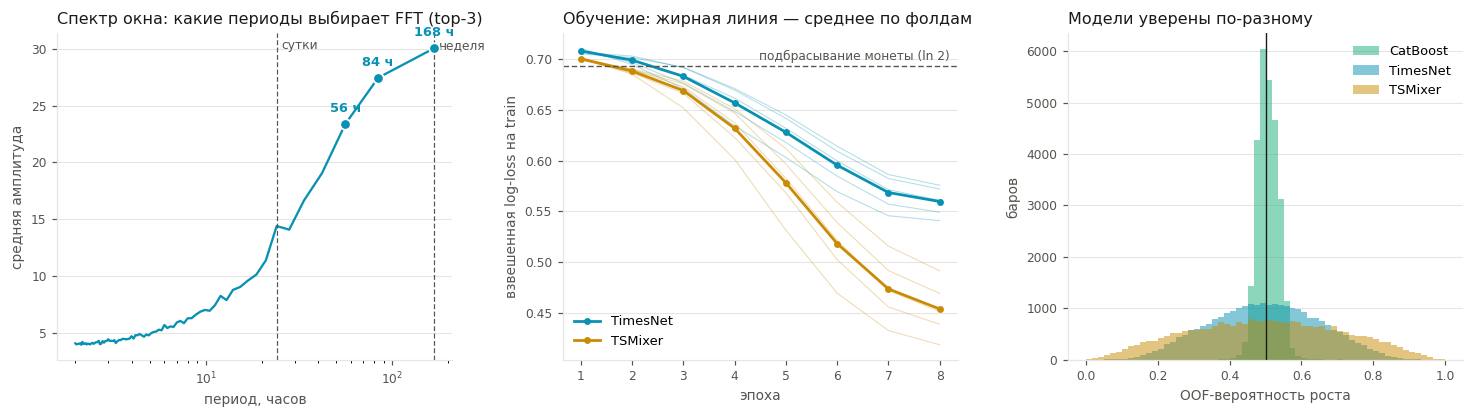

Корреляция OOF-вероятностей на dev-наборе:


,LogisticRegression,DecisionTree,CatBoost,TimesNet,TSMixer
LogisticRegression,1.000,0.314,0.718,-0.036,-0.004
DecisionTree,0.314,1.000,0.428,0.035,0.022
CatBoost,0.718,0.428,1.000,0.041,0.045
TimesNet,-0.036,0.035,0.041,1.000,0.473
TSMixer,-0.004,0.022,0.045,0.473,1.000


Чем ниже корреляция, тем больше смысла в ансамбле: модели ошибаются в разных местах.


In [50]:
# Что модели нашли в ряде и как они учились.
fit_idx_full = np.arange(SEQ_MIN_IDX, len(dev_df))
win_dev = sequence_windows(fit_idx_full)
sample = np.linspace(SEQ_MIN_IDX, len(dev_df) - 1, 4096).astype(int)
x_sample = window_batch(win_dev, sample)
amp = torch.fft.rfft(x_sample, dim=1).abs().mean(dim=0).mean(dim=-1).numpy()
amp[0] = 0.0
freqs = np.arange(len(amp))
periods_h = np.where(freqs > 0, SEQ_LEN / np.maximum(freqs, 1), np.nan)
top_k = seq_best["TimesNet"]["cfg"]["top_k"]
top_idx = np.argsort(amp)[::-1][:top_k]

fig, axes = plt.subplots(1, 3, figsize=(13.5, 3.9))

ax = axes[0]
ax.plot(periods_h[1:], amp[1:], color=COLORS["TimesNet"], linewidth=1.5)
ax.scatter(periods_h[top_idx], amp[top_idx], s=48, color=COLORS["TimesNet"],
           edgecolor="white", linewidth=1.2, zorder=4)
for i in top_idx:
    ax.annotate(f"{periods_h[i]:.0f} ч", xy=(periods_h[i], amp[i]), xytext=(0, 8),
                textcoords="offset points", ha="center", fontsize=8.5,
                color=COLORS["TimesNet"], fontweight="bold")
for mark, lbl in ((24, "сутки"), (168, "неделя")):
    ax.axvline(mark, color=INK_MUTED, linewidth=0.8, linestyle=(0, (4, 2)))
    ax.annotate(lbl, xy=(mark, 1.0), xycoords=("data", "axes fraction"), xytext=(3, -4),
                textcoords="offset points", va="top", fontsize=8, color=INK_MUTED)
ax.set_xscale("log")
ax.set_xlabel("период, часов", color=INK_MUTED, fontsize=9)
ax.set_ylabel("средняя амплитуда", color=INK_MUTED, fontsize=9)
ax.set_title(f"Спектр окна: какие периоды выбирает FFT (top-{top_k})",
             color=INK, fontsize=10.5, loc="left")
style_ax(ax)

ax = axes[1]
for arch in SEQ_GRID:
    hist = seq_best[arch]["history"]
    mean_hist = np.mean(np.vstack(hist), axis=0)
    ax.plot(np.arange(1, len(mean_hist) + 1), mean_hist, linewidth=1.8, marker="o",
            markersize=3.5, color=COLORS[arch], label=arch)
    for h in hist:
        ax.plot(np.arange(1, len(h) + 1), h, linewidth=0.7, color=COLORS[arch], alpha=0.3)
ax.axhline(np.log(2), color=INK_MUTED, linewidth=0.9, linestyle=(0, (4, 2)))
ax.annotate("подбрасывание монеты (ln 2)", xy=(0.98, np.log(2)), xycoords=("axes fraction", "data"),
            xytext=(0, 4), textcoords="offset points", ha="right", fontsize=8, color=INK_MUTED)
ax.set_xlabel("эпоха", color=INK_MUTED, fontsize=9)
ax.set_ylabel("взвешенная log-loss на train", color=INK_MUTED, fontsize=9)
ax.set_title("Обучение: жирная линия — среднее по фолдам", color=INK, fontsize=10.5, loc="left")
ax.legend(frameon=False, fontsize=8.5)
style_ax(ax)

ax = axes[2]
bins = np.linspace(0, 1, 61)
cb_oof, cb_mask = dev_oof["CatBoost"]
ax.hist(cb_oof[cb_mask], bins=bins, color=COLORS["CatBoost"], alpha=0.5, label="CatBoost")
for arch in SEQ_GRID:
    o_, m_ = dev_oof[arch]
    ax.hist(o_[m_], bins=bins, color=COLORS[arch], alpha=0.5, label=arch)
ax.axvline(0.5, color=INK, linewidth=0.9)
ax.set_xlabel("OOF-вероятность роста", color=INK_MUTED, fontsize=9)
ax.set_ylabel("баров", color=INK_MUTED, fontsize=9)
ax.set_title("Модели уверены по-разному", color=INK, fontsize=10.5, loc="left")
ax.legend(frameon=False, fontsize=8.5)
style_ax(ax)

fig.tight_layout()
plt.show()

corr_names = list(final_models) + list(SEQ_GRID)
corr_mask = np.all([dev_oof[nm][1] for nm in corr_names], axis=0)
corr = pd.DataFrame({nm: dev_oof[nm][0][corr_mask] for nm in corr_names}).corr()
print("Корреляция OOF-вероятностей на dev-наборе:")
display(corr.round(3))
print("Чем ниже корреляция, тем больше смысла в ансамбле: модели ошибаются в разных местах.")

Три панели выше говорят три разные вещи, и все три стоит проговорить.

**Выраженного суточного цикла в часовом BTC нет.** Амплитудный спектр монотонно спадает с
частотой, и top-3 периода — 168, 84 и 56 часов — это просто три самые низкие частоты окна;
24-часовой период (седьмая гармоника) в тройку не попадает. Значит, 2D-развёртка TimesNet
работает здесь не как выделение сезонности, ради которого она придумана, а как многомасштабное
сглаживание: свёртка по «столбцу» усредняет бары, отстоящие друг от друга на 56–168 часов.
Ради честности это стоит сказать прямо: главный механизм архитектуры на наших данных
простаивает.

**Обе сети запоминают обучающую выборку.** Взвешенная log-loss на train уходит с 0.70 до 0.56
у TimesNet и до 0.45 у TSMixer — заметно ниже ln 2 = 0.693, то есть сети уверенно
«предсказывают» бары, которые видели. При этом OOF ROC-AUC остаётся в диапазоне 0.519–0.529.
Попытки зажать модель сильнее не помогают, а лучший ROC-AUC и лучшая экономика достаются разным
конфигурациям: у TSMixer C (6 блоков, dropout 0.35) ROC-AUC 0.5275 против 0.5243 у выбранной B,
но net Sharpe 0.84 против 1.22; у TimesNet C лучший ROC-AUC из всех восьми — 0.5293, — и
net Sharpe 0.63 против 1.28 у выбранной A. Ранжирование и экономика тут расходятся так же, как в
абляции раздела 12.

**Модели последовательностей и табличные модели видят разное.** TimesNet и TSMixer
скоррелированы между собой на 0.473 — они смотрят в одно и то же окно, — но с логистической
регрессией, деревом и CatBoost корреляция лежит между −0.036 и 0.045, тогда как между собой
табличные модели скоррелированы куда сильнее — 0.314–0.718. Это не оценка качества, но это
ровно то условие, при котором усреднение прогнозов имеет смысл, и на валидации расширенный
ансамбль раздела 17.4 действительно окажется лучшим по ранжированию среди стратегий с торговым
слоем (ROC-AUC 0.548).

Итог подраздела: **по ранжированию сети чуть впереди табличных моделей, по деньгам — заметно
позади.** CV ROC-AUC 0.519–0.529 против 0.503–0.521 у табличных; CV net Sharpe — 1.28 у TimesNet
и 1.22 у TSMixer против 1.78 у логистической регрессии и 1.74 у дерева. Стоимость при этом
несопоставима: минуты обучения на GPU против миллисекунд. Оговорка обязательна: сети получили
4 конфигурации, выбранные вручную, а табличные модели — 25 попыток TPE, так что сравнение
неравнобюджетное и говорит скорее «сети не дали заметного выигрыша за разумные деньги», чем
«сети хуже».

### 17.3 TimesFM 2.0: zero-shot, линейный зонд и дообучение

TimesNet и TSMixer учились на нашем ряде с нуля. Foundation-модель позволяет пройти этот путь
с другого конца: взять 500 млн параметров, предобученных на чужих временных рядах, и
посмотреть, сколько из них переносится на часовой BTC. Вопрос подраздела: **что даёт
предобученная модель прогнозирования — как есть, как источник представления и после
дообучения под нашу задачу?**

Берётся `google/timesfm-2.0-500m-pytorch` — декодер из 50 слоёв, работающий патчами по 32
точки. Для каждого бара `t` в модель подаются 512 последних значений ряда лог-доходностей
(сам бар `t` включительно, ничего из будущего). Ряд именно доходностей, а не цен: прогноз
уровня цены у любой модели почти совпадает с последним значением, и вся полезная информация
оказывается в четвёртом знаке.

Проверяются шесть постановок, от «вообще не трогаем модель» до «дообучаем верхушку»:

1. **Zero-shot.** Вероятность роста берётся прямо из прогнозного распределения:
   `P(рост) = P(r_{t+1} > 0) = 1 − F(0)`, где `F` восстанавливается линейной интерполяцией по
   девяти квантилям, которые выдаёт голова прогноза. Никакого обучения на BTC вообще.
2. **Линейный зонд (sklearn).** Бэкбон заморожен, из него берётся эмбеддинг последнего патча —
   вектор на 1280 чисел, — и поверх обучается логистическая регрессия. Стандартный способ
   проверить, есть ли нужная информация в представлении, даже если голова предобучения её не
   выдаёт.
3. **Голова на torch, бэкбон заморожен.** То же самое, но голова обучается тем же
   оптимизатором и той же взвешенной функцией потерь, что и дообучение ниже, и с щедрым
   бюджетом (8 эпох по всем окнам). Это «потолок замороженного бэкбона»: сколько можно выжать
   из представления, не трогая веса.
4. **Голова на torch в бюджете дообучения.** Та же голова и то же расписание, что у дообучения
   ниже: две эпохи, каждое второе окно, батч 64. Бэкбон заморожен и работает в режиме `eval`,
   поэтому его эмбеддинги детерминированы, и эта строка **математически совпадает с дообучением
   при `unfreeze_last = 0`**. Именно она — точный контроль: от строк 5 и 6 её отличает ровно
   одно — верхние слои не двигаются. Без неё разницу между зондом и дообучением можно было бы
   списать на смену оптимизатора или на размер обучающего расписания, а не на разморозку.
5. **Дообучение: 2 верхних слоя декодера.** К голове добавляется градиентный шаг по последним
   двум из 50 слоёв — около 20 млн обучаемых параметров из 500 млн.
6. **Дообучение: 6 верхних слоёв декодера.** То же с большей ёмкостью — около 59 млн
   параметров.

Все шесть проходят по одним и тем же фолдам `TimeSeriesSplit`, с теми же весами наблюдений и
тем же критерием, что и остальные модели конвейера. Постановка, идущая дальше в сравнение
стратегий, выбирается по ROC-AUC на dev-наборе. Выбирать по `max |AUC − 0.5|` было бы
подглядыванием: так можно «выбрать» перевёрнутую модель под конкретную выборку.

In [51]:
os.environ["HF_HUB_DISABLE_PROGRESS_BARS"] = "1"
from transformers import TimesFmModelForPrediction
from transformers.utils import logging as hf_logging

hf_logging.disable_progress_bar()
hf_logging.set_verbosity_error()

TIMESFM_CHECKPOINT = "google/timesfm-2.0-500m-pytorch"
TIMESFM_CTX = 512            # кратно патчу 32; модель держит и 2048, но это вчетверо дороже
TIMESFM_BATCH = 128
TIMESFM_HIDDEN = 1280

# Выравнивание feat -> raw делается по датам, а не арифметикой по длинам: ошибка на один бар
# здесь означала бы, что в контекст попадает будущее (и ROC-AUC внезапно становится 0.9).
tfm_offset = int(raw.index[raw["date"] == feat["date"].iloc[0]][0])
assert (raw["date"].to_numpy()[tfm_offset:tfm_offset + len(feat)]
        == feat["date"].to_numpy()).all(), "feat и raw разъехались по времени"
assert np.allclose(raw["close"].to_numpy()[tfm_offset:tfm_offset + len(feat)],
                   feat["close"].to_numpy())

logret_raw = np.concatenate(
    [[0.0], np.diff(np.log(raw["close"].to_numpy(np.float64)))]).astype(np.float32)
context_rows = np.arange(len(feat)) + tfm_offset - (TIMESFM_CTX - 1)
assert context_rows[0] >= 0, "не хватает истории на контекст"
# последняя точка контекста — это бар t и ничто иное
assert np.allclose(logret_raw[context_rows + TIMESFM_CTX - 1],
                   logret_raw[np.arange(len(feat)) + tfm_offset])


@torch.no_grad()
def timesfm_scan(model, series, batch_size=TIMESFM_BATCH):
    """Один проход по всем барам feat: квантили прогноза на бар вперёд и эмбеддинг бара.

    Контекст короче 2048 модель дописывает нулями СЛЕВА, поэтому последняя позиция
    `last_hidden_state` соответствует самому свежему патчу, то есть бару t.
    """
    windows = np.lib.stride_tricks.sliding_window_view(series, TIMESFM_CTX)
    n_lvl = len(model.config.quantiles)
    quant = np.empty((len(feat), n_lvl), np.float32)
    point = np.empty(len(feat), np.float32)
    emb = np.empty((len(feat), TIMESFM_HIDDEN), np.float16)
    t0 = time.perf_counter()
    for s in range(0, len(feat), batch_size):
        block = context_rows[s:s + batch_size]
        ctx = torch.from_numpy(windows[block].copy()).to(DEVICE)
        out = model(past_values=ctx, output_hidden_states=True)
        full = out.full_predictions[:, 0, :].float().cpu().numpy()   # [B, 1 + квантили]
        point[s:s + len(block)] = full[:, 0]
        quant[s:s + len(block)] = full[:, 1:]
        emb[s:s + len(block)] = out.last_hidden_state[:, -1, :].float().cpu().numpy()
        if (s // batch_size) % 100 == 0:
            print(f"    {min(s + batch_size, len(feat))}/{len(feat)} окон, "
                  f"{time.perf_counter() - t0:.0f} с", flush=True)
    return np.sort(quant, axis=1), point, emb          # квантили обязаны быть неубывающими


def prob_above(quantiles, levels, threshold=0.0):
    """P(значение > threshold) по квантилям, с линейным продолжением хвостов."""
    lo = quantiles[:, 0] - 2 * (quantiles[:, 1] - quantiles[:, 0])
    hi = quantiles[:, -1] + 2 * (quantiles[:, -1] - quantiles[:, -2])
    grid = np.column_stack([lo, quantiles, hi])
    lvl = np.concatenate([[0.02], levels, [0.98]])
    cdf = np.array([np.interp(threshold, grid[i], lvl) for i in range(len(quantiles))])
    return 1.0 - cdf


t_start = time.perf_counter()
# float32, а не bfloat16: часовые лог-доходности BTC — это величины порядка 1e-3, в bf16
# соседние квантили схлопываются в одно значение и вероятность становится бесполезной.
timesfm_backbone = TimesFmModelForPrediction.from_pretrained(
    TIMESFM_CHECKPOINT, dtype=torch.float32).to(DEVICE).eval()
TIMESFM_LEVELS = np.array(timesfm_backbone.config.quantiles, dtype=float)
print(f"Загружено: {TIMESFM_CHECKPOINT}, "
      f"{sum(p.numel() for p in timesfm_backbone.parameters()) / 1e6:.0f} млн параметров, "
      f"{time.perf_counter() - t_start:.0f} с. Обучения на BTC нет — модель как есть.")

t_start = time.perf_counter()
tfm_quant, tfm_point, tfm_emb = timesfm_scan(timesfm_backbone, logret_raw)
print(f"Проход по {len(feat)} окнам за {(time.perf_counter() - t_start) / 60:.1f} мин: "
      f"квантили {tfm_quant.shape}, эмбеддинги {tfm_emb.shape} "
      f"({tfm_emb.nbytes / 2 ** 20:.0f} МиБ)")

p_tfm_zeroshot = prob_above(tfm_quant, TIMESFM_LEVELS, 0.0)
print(f"Точечный прогноз положителен на {float((tfm_point > 0).mean()):.1%} баров при "
      f"фактической доле роста {feat['target'].mean():.1%} — у прогноза есть систематический "
      f"сдвиг в сторону падения, и он один объясняет смещение P(рост) влево.")
# модель не удаляется: тот же бэкбон дообучается ниже

Загружено: google/timesfm-2.0-500m-pytorch, 499 млн параметров, 2 с. Обучения на BTC нет — модель как есть.


    128/38094 окон, 1 с


    12928/38094 окон, 53 с


    25728/38094 окон, 105 с


Проход по 38094 окнам за 2.6 мин: квантили (38094, 9), эмбеддинги (38094, 1280) (93 МиБ)
Точечный прогноз положителен на 14.0% баров при фактической доле роста 50.5% — у прогноза есть систематический сдвиг в сторону падения, и он один объясняет смещение P(рост) влево.


**Как устроено дообучение и почему именно так.**

- **Размораживается верхушка, а не вся модель.** Полный градиентный шаг по 500 млн параметров
  на 40 тысячах наблюдений с меткой, близкой к подбрасыванию монеты, — это гарантированное
  переобучение и лишние часы счёта. Нижние слои держат общее представление ряда, верхние
  специализируются под задачу; размораживаются последние `k` слоёв декодера и голова.
- **Два темпа обучения.** Предобученным слоям `lr = 1e-5`, свежей голове `lr = 1e-3`: одинаковый
  темп либо разрушил бы предобученные веса, либо не сдвинул бы голову с места.
- **Замороженная часть остаётся в режиме `eval`.** Иначе dropout нижних слоёв зашумлял бы
  эмбеддинг, который они обязаны выдавать одинаково на обучении и на предсказании.
- **Каждый фолд начинается с чистых предобученных весов.** Разморозка меняет слои на месте,
  поэтому перед каждым фолдом верхние `k` слоёв восстанавливаются из снимка. Без этого второй
  фолд стартовал бы с весов, уже видевших его собственное прошлое, а пятый — почти весь
  dev-набор.
- **Обучение идёт по каждому второму окну.** Соседние окна совпадают в 511 точках из 512, так
  что информации это почти не теряет, а счёт сокращает вдвое. Предсказание считается по всем
  барам фолда без прореживания.

In [52]:
# Дообучение TimesFM: частичная разморозка декодера.
n_dev, n_val = len(dev_df), len(val_df)
y_dev_np, y_val_np = dev_df["target"].to_numpy(), val_df["target"].to_numpy()
val_rows_in_feat = np.arange(n_val) + (len(feat) - n_val)
assert feat["date"].to_numpy()[val_rows_in_feat][0] == val_df["date"].iloc[0], "валидация смещена"

TFM_UNFREEZE_GRID = (2, 6)   # сколько последних слоёв декодера из 50 размораживать
TFM_FT_EPOCHS = 2
TFM_FT_STRIDE = 2            # обучение по каждому второму окну: соседние совпадают на 511/512
TFM_FT_BATCH = 64
TFM_HEAD_EPOCHS = 8          # голова на кэшированных эмбеддингах дешёвая, ей эпох не жалко
TFM_LR_BACKBONE = 1e-5       # предобученным слоям — осторожный темп
TFM_LR_HEAD = 1e-3           # свежей голове — обычный
TFM_PROBE_C = 0.01           # сильная регуляризация: 1280 признаков против 40 тысяч наблюдений

TFM_WINDOWS = np.lib.stride_tricks.sliding_window_view(logret_raw, TIMESFM_CTX)
SEQ_W_ALL = np.where(SEQ_ANOM > 0, OUTLIER_WEIGHT, 1.0).astype(np.float32)


def tfm_context_batch(rows):
    """Контексты [B, 512] лог-доходностей, заканчивающиеся на барах rows."""
    return torch.from_numpy(TFM_WINDOWS[context_rows[np.asarray(rows)]].copy()).to(DEVICE)


def make_tfm_head(dropout=0.1):
    """Голова классификации над эмбеддингом бара — одна и та же во всех torch-постановках."""
    return nn.Sequential(nn.LayerNorm(TIMESFM_HIDDEN), nn.Dropout(dropout),
                         nn.Linear(TIMESFM_HIDDEN, 1))


def make_probe(C=TFM_PROBE_C):
    return Pipeline([("scaler", StandardScaler()),
                     ("clf", LogisticRegression(C=C, max_iter=1000, tol=1e-3,
                                                random_state=RANDOM_STATE))])


class TimesFmClassifier(nn.Module):
    """TimesFM с головой классификации и разморозкой последних unfreeze_last слоёв декодера."""

    def __init__(self, backbone, unfreeze_last, dropout=0.1):
        super().__init__()
        self.backbone = backbone
        for p in self.backbone.parameters():
            p.requires_grad = False
        layers = self.backbone.decoder.layers
        self.tuned = list(layers[len(layers) - unfreeze_last:]) if unfreeze_last else []
        for layer in self.tuned:
            for p in layer.parameters():
                p.requires_grad = True
        self.head = make_tfm_head(dropout)

    def train_mode(self):
        """Замороженная часть остаётся в eval: её dropout не должен зашумлять эмбеддинг."""
        self.backbone.eval()
        for layer in self.tuned:
            layer.train()
        self.head.train()

    def forward(self, ctx):
        emb = self.backbone(past_values=ctx).last_hidden_state[:, -1, :]
        return self.head(emb).squeeze(-1)


def weighted_bce(logit, rows):
    """Взвешенная логистическая потеря: те же веса выбросов, что у всех моделей конвейера."""
    y = torch.from_numpy(SEQ_TARGET[rows]).to(DEVICE)
    w = torch.from_numpy(SEQ_W_ALL[rows]).to(DEVICE)
    return (F.binary_cross_entropy_with_logits(logit, y, reduction="none") * w).sum() / w.sum()


def timesfm_ft_fit(rows, unfreeze_last, epochs=TFM_FT_EPOCHS, seed=RANDOM_STATE):
    """Дообучение верхушки на барах rows. Веса декодера восстанавливаются перед стартом."""
    torch.manual_seed(seed)
    timesfm_backbone.decoder.layers[-max(TFM_UNFREEZE_GRID):].load_state_dict(tfm_snapshot)
    model = TimesFmClassifier(timesfm_backbone, unfreeze_last).to(DEVICE)
    groups = [{"params": list(model.head.parameters()), "lr": TFM_LR_HEAD}]
    if model.tuned:
        groups.insert(0, {"params": [p for l in model.tuned for p in l.parameters()],
                          "lr": TFM_LR_BACKBONE})
    opt = torch.optim.AdamW(groups, weight_decay=1e-2)
    rows = np.asarray(rows)
    steps = epochs * int(np.ceil(len(rows) / TFM_FT_BATCH))
    sched = torch.optim.lr_scheduler.OneCycleLR(opt, max_lr=[g["lr"] for g in groups],
                                                total_steps=steps, pct_start=0.25)
    trainable = [p for p in model.parameters() if p.requires_grad]
    gen = torch.Generator().manual_seed(seed)
    history = []
    for _ in range(epochs):
        model.train_mode()
        order = torch.randperm(len(rows), generator=gen).numpy()
        running = 0.0
        for s in range(0, len(rows), TFM_FT_BATCH):
            b = rows[order[s:s + TFM_FT_BATCH]]
            loss = weighted_bce(model(tfm_context_batch(b)), b)
            opt.zero_grad(set_to_none=True)
            loss.backward()
            nn.utils.clip_grad_norm_(trainable, 1.0)
            opt.step()
            sched.step()
            running += float(loss) * len(b)
        history.append(running / len(rows))
    return model, history


@torch.no_grad()
def timesfm_ft_predict(model, rows, batch=TIMESFM_BATCH):
    model.eval()
    rows = np.asarray(rows)
    out = [torch.sigmoid(model(tfm_context_batch(rows[s:s + batch]))).float().cpu().numpy()
           for s in range(0, len(rows), batch)]
    return np.concatenate(out)


def timesfm_head_fit(rows, epochs=TFM_HEAD_EPOCHS, batch=SEQ_BATCH, seed=RANDOM_STATE):
    """Контроль: та же голова и тот же оптимизатор, но на кэшированных эмбеддингах."""
    torch.manual_seed(seed)
    head = make_tfm_head().to(DEVICE)
    opt = torch.optim.AdamW(head.parameters(), lr=TFM_LR_HEAD, weight_decay=1e-2)
    rows = np.asarray(rows)
    steps = epochs * int(np.ceil(len(rows) / batch))
    sched = torch.optim.lr_scheduler.OneCycleLR(opt, max_lr=TFM_LR_HEAD, total_steps=steps,
                                                pct_start=0.25)
    gen = torch.Generator().manual_seed(seed)
    for _ in range(epochs):
        head.train()
        order = torch.randperm(len(rows), generator=gen).numpy()
        for s in range(0, len(rows), batch):
            b = rows[order[s:s + batch]]
            xb = torch.from_numpy(tfm_emb[b].astype(np.float32)).to(DEVICE)
            loss = weighted_bce(head(xb).squeeze(-1), b)
            opt.zero_grad(set_to_none=True)
            loss.backward()
            nn.utils.clip_grad_norm_(head.parameters(), 1.0)
            opt.step()
            sched.step()
    return head


@torch.no_grad()
def timesfm_head_predict(head, rows, batch=2048):
    head.eval()
    rows = np.asarray(rows)
    out = []
    for s in range(0, len(rows), batch):
        xb = torch.from_numpy(tfm_emb[rows[s:s + batch]].astype(np.float32)).to(DEVICE)
        out.append(torch.sigmoid(head(xb).squeeze(-1)).float().cpu().numpy())
    return np.concatenate(out)


def probe_cv_oof():
    """OOF линейного зонда на тех же фолдах и с теми же весами, что у остальных моделей."""
    oof = np.full(n_dev, np.nan)
    for tr_idx, te_idx in tscv.split(X_dev_all):
        probe = make_probe()
        probe.fit(tfm_emb[tr_idx].astype(np.float32), y_dev_np[tr_idx],
                  clf__sample_weight=sample_weights(dev_df, tr_idx, w_outlier=True))
        oof[te_idx] = predict_proba1(probe, tfm_emb[te_idx].astype(np.float32))
    return oof, ~np.isnan(oof)


def head_cv_oof(epochs=TFM_HEAD_EPOCHS, stride=1, batch=SEQ_BATCH):
    """OOF головы на замороженных эмбеддингах. stride/epochs/batch задают бюджет обучения:
    при бюджете дообучения эта постановка равна дообучению с unfreeze_last = 0."""
    oof = np.full(n_dev, np.nan)
    for tr_idx, te_idx in tscv.split(X_dev_all):
        head = timesfm_head_fit(tr_idx[::stride], epochs, batch)
        oof[te_idx] = timesfm_head_predict(head, te_idx)
    return oof, ~np.isnan(oof)


def ft_cv_oof(unfreeze_last):
    """OOF дообученной модели. Каждый фолд обучается с нуля от предобученных весов."""
    oof = np.full(n_dev, np.nan)
    hist = []
    for tr_idx, te_idx in tscv.split(X_dev_all):
        model, h = timesfm_ft_fit(tr_idx[::TFM_FT_STRIDE], unfreeze_last)
        oof[te_idx] = timesfm_ft_predict(model, te_idx)
        hist.append(h)
        del model
        torch.cuda.empty_cache() if DEVICE.type == "cuda" else None
    return oof, ~np.isnan(oof), hist


def ft_label(k):
    return f"дообучение: {k} верхних сло{'я' if k < 5 else 'ёв'} декодера"

In [53]:
# Прогон всех постановок TimesFM по одним и тем же фолдам.
# снимок предобученных весов верхних слоёв: к нему возвращаемся перед каждым фолдом
tfm_snapshot = {k: v.detach().clone() for k, v in
                timesfm_backbone.decoder.layers[-max(TFM_UNFREEZE_GRID):].state_dict().items()}
n_tuned = {k: sum(p.numel() for layer in timesfm_backbone.decoder.layers[-k:]
                  for p in layer.parameters()) for k in TFM_UNFREEZE_GRID}
print(f"Декодер: {len(timesfm_backbone.decoder.layers)} слоёв, "
      f"{sum(p.numel() for p in timesfm_backbone.parameters()) / 1e6:.0f} млн параметров")
for k, v in n_tuned.items():
    print(f"  разморозка {k} верхних слоёв -> {v / 1e6:.0f} млн обучаемых параметров "
          f"({v / sum(p.numel() for p in timesfm_backbone.parameters()):.1%} модели)")

tfm_oof = {}
t0 = time.perf_counter()
tfm_oof["линейный зонд по эмбеддингам"] = probe_cv_oof()
print(f"\nЛинейный зонд (sklearn): {time.perf_counter() - t0:.0f} с")

t0 = time.perf_counter()
tfm_oof["голова на torch, бэкбон заморожен"] = head_cv_oof()
print(f"Голова на torch, щедрый бюджет ({TFM_HEAD_EPOCHS} эпох, все окна): "
      f"{time.perf_counter() - t0:.0f} с")

t0 = time.perf_counter()
tfm_oof["голова на torch, бюджет дообучения"] = head_cv_oof(
    epochs=TFM_FT_EPOCHS, stride=TFM_FT_STRIDE, batch=TFM_FT_BATCH)
print(f"Голова на torch, бюджет дообучения ({TFM_FT_EPOCHS} эпохи, каждое второе окно): "
      f"{time.perf_counter() - t0:.0f} с — это дообучение при unfreeze_last = 0")

ft_history = {}
for k in TFM_UNFREEZE_GRID:
    t0 = time.perf_counter()
    oof_k, mask_k, hist_k = ft_cv_oof(k)
    tfm_oof[ft_label(k)] = (oof_k, mask_k)
    ft_history[k] = hist_k
    print(f"{ft_label(k)}: {(time.perf_counter() - t0) / 60:.1f} мин, "
          f"log-loss на train {np.mean([h[0] for h in hist_k]):.4f} -> "
          f"{np.mean([h[-1] for h in hist_k]):.4f}", flush=True)

# финальное обучение выбранной постановки на всём dev — вызывается в разделе 17.4
def _final_probe():
    probe = make_probe()
    probe.fit(tfm_emb[:n_dev].astype(np.float32), y_dev_np,
              clf__sample_weight=sample_weights(dev_df, np.arange(n_dev), w_outlier=True))
    return (predict_proba1(probe, tfm_emb[:n_dev].astype(np.float32)),
            predict_proba1(probe, tfm_emb[val_rows_in_feat].astype(np.float32)))


def _final_head(epochs=TFM_HEAD_EPOCHS, stride=1, batch=SEQ_BATCH):
    head = timesfm_head_fit(np.arange(0, n_dev, stride), epochs, batch)
    return (timesfm_head_predict(head, np.arange(n_dev)),
            timesfm_head_predict(head, val_rows_in_feat))


def _final_ft(k):
    model, _ = timesfm_ft_fit(np.arange(0, n_dev, TFM_FT_STRIDE), k)
    dev_p = timesfm_ft_predict(model, np.arange(n_dev))
    val_p = timesfm_ft_predict(model, val_rows_in_feat)
    del model
    torch.cuda.empty_cache() if DEVICE.type == "cuda" else None
    return dev_p, val_p


tfm_final_fit = {
    "zero-shot: P(r > 0) по квантилям":
        lambda: (p_tfm_zeroshot[:n_dev], p_tfm_zeroshot[val_rows_in_feat]),
    "линейный зонд по эмбеддингам": _final_probe,
    "голова на torch, бэкбон заморожен": _final_head,
    "голова на torch, бюджет дообучения":
        lambda: _final_head(TFM_FT_EPOCHS, TFM_FT_STRIDE, TFM_FT_BATCH),
    **{ft_label(k): (lambda k=k: _final_ft(k)) for k in TFM_UNFREEZE_GRID},
}

Декодер: 50 слоёв, 499 млн параметров
  разморозка 2 верхних слоёв -> 20 млн обучаемых параметров (3.9% модели)
  разморозка 6 верхних слоёв -> 59 млн обучаемых параметров (11.8% модели)



Линейный зонд (sklearn): 5 с


Голова на torch, щедрый бюджет (8 эпох, все окна): 4 с


Голова на torch, бюджет дообучения (2 эпохи, каждое второе окно): 1 с — это дообучение при unfreeze_last = 0


дообучение: 2 верхних слоя декодера: 7.7 мин, log-loss на train 0.7048 -> 0.6917


дообучение: 6 верхних слоёв декодера: 8.7 мин, log-loss на train 0.7045 -> 0.6911


,ROC-AUC dev,PR-AUC dev,accuracy dev,gross Sharpe,net Sharpe,разброс P(рост),средняя P(рост),слой допустим
постановка,,,,,,,,
zero-shot: P(r > 0) по квантилям,0.4625,0.4770,0.4790,-0.0813,0.8420,0.1229,0.3838,True
линейный зонд по эмбеддингам,0.5204,0.5185,0.5149,-0.1891,0.2902,0.1961,0.5304,True
"голова на torch, бэкбон заморожен",0.5344,0.5307,0.5249,0.4489,0.8697,0.0580,0.5057,True
"голова на torch, бюджет дообучения",0.5197,0.5213,0.5136,0.8257,2.0921,0.0467,0.5147,True
дообучение: 2 верхних слоя декодера,0.5194,0.5187,0.5117,0.5718,1.3643,0.0352,0.5157,True
дообучение: 6 верхних слоёв декодера,0.5200,0.5204,0.5090,0.7455,1.7735,0.0284,0.5191,True


Взята постановка «голова на torch, бэкбон заморожен» (по ROC-AUC на dev).
Торговый слой TimesFM: {'mode': 'hold', 'span': 24, 'rebalance': 24, 'q': 0.1}, допустимая конфигурация найдена: True


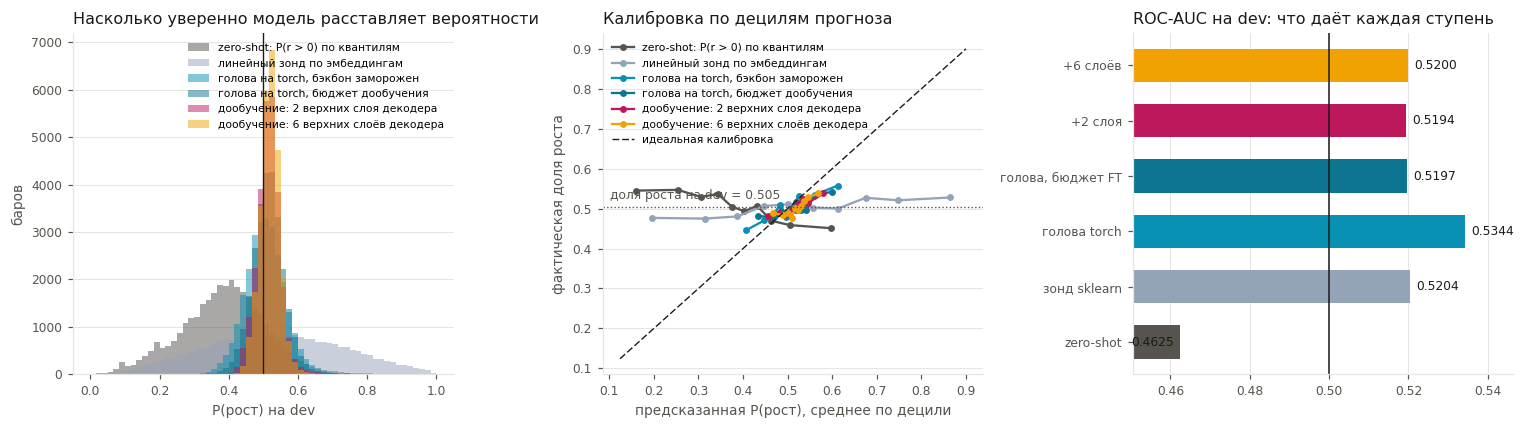

Для zero-shot постановки порог 0.5 бессмыслен — модель не обучалась на нашей метке;
поэтому смотрим на ROC-AUC и на квантильные пороги торгового слоя.


In [54]:
# Сравнение постановок TimesFM и выбор той, что идёт в сравнение стратегий.
tfm_variants = {"zero-shot: P(r > 0) по квантилям": (p_tfm_zeroshot[:n_dev], np.ones(n_dev, bool)),
                **tfm_oof}
tfm_rows = []
for label, (p_var, m_var) in tfm_variants.items():
    rep, trade, sig_prm, ok = seq_evaluate(p_var, m_var)
    tfm_rows.append({"постановка": label, "ROC-AUC dev": rep["roc_auc"],
                     "PR-AUC dev": rep["pr_auc"], "accuracy dev": rep["accuracy"],
                     "gross Sharpe": rep["gross_sharpe"], "net Sharpe": trade["sharpe"],
                     "разброс P(рост)": float(p_var[m_var].std()),
                     "средняя P(рост)": float(p_var[m_var].mean()),
                     "слой допустим": ok})
tfm_table = pd.DataFrame(tfm_rows).set_index("постановка")
display(tfm_table.round(4))

tfm_best_label = tfm_table["ROC-AUC dev"].idxmax()
p_tfm_dev, tfm_mask = tfm_variants[tfm_best_label]
dev_oof["TimesFM"] = (p_tfm_dev, tfm_mask)
signal_by_model["TimesFM"], _, tfm_layer_ok = tune_signal_layer(
    p_tfm_dev[tfm_mask], dates_dev.to_numpy()[tfm_mask], fwd_dev.to_numpy()[tfm_mask])
print(f"Взята постановка «{tfm_best_label}» (по ROC-AUC на dev).")
print(f"Торговый слой TimesFM: {signal_by_model['TimesFM']}, "
      f"допустимая конфигурация найдена: {tfm_layer_ok}")

TFM_SHORT = dict(zip(tfm_variants,
                     ["zero-shot", "зонд sklearn", "голова torch", "голова, бюджет FT"]
                     + [f"+{k} сло{'я' if k < 5 else 'ёв'}" for k in TFM_UNFREEZE_GRID]))

fig, axes = plt.subplots(1, 3, figsize=(14, 4.0))
palette = {lbl: c for lbl, c in zip(tfm_variants, [INK_MUTED, "#94a3b8", "#0891b2",
                                                   "#0e7490", COLORS["TimesFM"], "#f0a202"])}

ax = axes[0]
bins = np.linspace(0, 1, 61)
for label, (p_var, m_var) in tfm_variants.items():
    ax.hist(p_var[m_var], bins=bins, alpha=0.5, label=label, color=palette[label], linewidth=0)
ax.axvline(0.5, color=INK, linewidth=0.9)
ax.set_xlabel("P(рост) на dev", color=INK_MUTED, fontsize=9)
ax.set_ylabel("баров", color=INK_MUTED, fontsize=9)
ax.set_title("Насколько уверенно модель расставляет вероятности",
             color=INK, fontsize=10.5, loc="left")
ax.legend(frameon=False, fontsize=7)
style_ax(ax)

ax = axes[1]
for label, (p_var, m_var) in tfm_variants.items():
    pv, yv = p_var[m_var], y_dev_np[m_var]
    edges = np.unique(np.quantile(pv, np.linspace(0, 1, 11)))
    idx_bin = np.clip(np.digitize(pv, edges[1:-1]), 0, len(edges) - 2)
    xs = [pv[idx_bin == b].mean() for b in range(len(edges) - 1)]
    ys = [yv[idx_bin == b].mean() for b in range(len(edges) - 1)]
    ax.plot(xs, ys, marker="o", markersize=3.5, linewidth=1.5, label=label, color=palette[label])
lims = ax.get_xlim()
ax.plot(lims, lims, color=INK, linewidth=0.9, linestyle=(0, (5, 2)), label="идеальная калибровка")
ax.axhline(y_dev_np.mean(), color=INK_MUTED, linewidth=0.9, linestyle=":")
ax.annotate(f"доля роста на dev = {y_dev_np.mean():.3f}", xy=(0.02, y_dev_np.mean()),
            xycoords=("axes fraction", "data"), xytext=(0, 5), textcoords="offset points",
            fontsize=8, color=INK_MUTED)
ax.set_xlabel("предсказанная P(рост), среднее по децили", color=INK_MUTED, fontsize=9)
ax.set_ylabel("фактическая доля роста", color=INK_MUTED, fontsize=9)
ax.set_title("Калибровка по децилям прогноза", color=INK, fontsize=10.5, loc="left")
ax.legend(frameon=False, fontsize=7)
style_ax(ax)

ax = axes[2]
order = [lbl for lbl in tfm_variants]
vals = [tfm_table.loc[lbl, "ROC-AUC dev"] for lbl in order]
ax.barh(np.arange(len(order)), vals, color=[palette[l] for l in order], height=0.6)
ax.axvline(0.5, color=INK, linewidth=1.0)
ax.annotate("0.5 — монетка", xy=(0.5, -0.75), xytext=(3, 0), textcoords="offset points",
            fontsize=8, color=INK_MUTED)
for yi, v in enumerate(vals):
    ax.annotate(f"{v:.4f}", xy=(v, yi), xytext=(4 if v >= 0.5 else -4, 0),
                textcoords="offset points", va="center",
                ha="left" if v >= 0.5 else "right", fontsize=8, color=INK)
ax.set_yticks(np.arange(len(order)))
ax.set_yticklabels([TFM_SHORT[l] for l in order], fontsize=8)
ax.set_xlim(min(vals) - 0.012, max(vals) + 0.012)
ax.set_title("ROC-AUC на dev: что даёт каждая ступень", color=INK, fontsize=10.5, loc="left")
style_ax(ax, ygrid=False, xgrid=True)

fig.tight_layout()
plt.show()
print("Для zero-shot постановки порог 0.5 бессмыслен — модель не обучалась на нашей метке;")
print("поэтому смотрим на ROC-AUC и на квантильные пороги торгового слоя.")

Шесть постановок выстраиваются в лестницу, и каждая ступень отвечает на свой вопрос.

**Zero-shot: отрицательный результат, и однозначный.** ROC-AUC 0.463 — ниже 0.5, калибровочная
кривая на средней панели идёт вниз. Это не «перевёрнутый сигнал, который можно использовать
наоборот»: на dev-наборе такой разворот означал бы подгонку под выборку. Плюс систематический
сдвиг — точечный прогноз положителен всего на 14.0% баров при фактической доле роста 50.5%,
отсюда и смещённое влево распределение P(рост) со средним 0.384. Готовая голова прогноза
направления следующего часа не даёт.

**Представление полезнее прогноза.** Линейный зонд по замороженным эмбеддингам поднимает
ROC-AUC до 0.520, а та же голова, обученная torch-оптимизатором со взвешенной функцией потерь
и щедрым бюджетом, — до **0.534**. Обе цифры получены на одних и тех же замороженных
эмбеддингах: разница целиком в рецепте обучения головы, а не в качестве представления.

**Разморозка верхних слоёв не даёт ничего — и увидеть это можно только с согласованным
контролем.** При одинаковом расписании (2 эпохи, каждое второе окно, батч 64) замороженный
бэкбон даёт 0.5197, разморозка двух верхних слоёв — 0.5194, шести — 0.5200. Разброс между ними
0.0006 — на порядок меньше разницы между ступенями лестницы, то есть разморозка не двигает
метрику ни в одну сторону.

Сравнение же с щедрым контролем (0.5344 против 0.5197) выглядело бы как «дообучение вредит» —
и было бы **неверным прочтением**: 0.5344 против 0.5197 получены на одном и том же
замороженном бэкбоне и отличаются только длиной обучения головы. Иначе говоря, **бюджет
обучения головы стоит +0.0147 ROC-AUC, а разморозка 59 млн параметров — +0.0003**. Ради
этой строки контроль и добавлен; без неё раздел уверенно сообщил бы эффект, которого нет.

**То же и с экономикой, но с оговоркой.** gross Sharpe: 0.449 у щедрого контроля, 0.826 у
согласованного, 0.572 при разморозке двух слоёв, 0.746 при шести. Укорочение бюджета поднимает
gross Sharpe и одновременно опускает ROC-AUC — та же развилка, что у конфигурации F в
разделе 12. Разморозка при этом опускает gross Sharpe (0.826 → 0.57–0.75), не двигая ROC-AUC:
на 0.0006 ROC-AUC приходится 0.25 Sharpe, и это лучшая иллюстрация того, насколько
экономическая метрика чувствительнее к мелочам. Метрики измеряют разное: ROC-AUC усредняет
ранжирование по всем барам одинаково, а gross Sharpe в `oof_report` считается по правилу «в лонг, если
P ≥ 0.5, иначе в шорт»: он зависит только от знака решения и взвешивается фактическим
движением цены.

Левая панель добавляет наблюдение о форме прогнозов: разброс сужается и от укорочения бюджета
(0.058 → 0.047), и от разморозки (0.047 → 0.035 → 0.028). Модель становится осторожнее и
прижимает вероятности к базовой частоте — на торговый слой это влияет напрямую, потому что его
пороги квантильные.

По правилу отбора (dev ROC-AUC) дальше идёт **голова на torch поверх замороженного бэкбона с
щедрым бюджетом**.

**Границы утверждения.** Проверено одно сочетание: 2 и 6 верхних слоёв из 50, две эпохи,
каждое второе окно, `lr = 1e-5` для декодера и `1e-3` для головы, без перебора расписания и
без ранней остановки. Полного градиентного шага по всем 500 млн параметров не делалось вовсе.
Отсюда следует «в этом бюджете разморозка верхушки не окупается, а удлинение обучения головы
окупается», но не следует «дообучать TimesFM бесполезно».

### 17.4 Финальные модели последовательностей и расширенный ансамбль

TimesNet и TSMixer с выбранными конфигурациями переобучаются на всём dev-наборе — как и
табличные модели раздела 16. Статистики стандартизации окон считаются по dev, пороги торгового
слоя берутся из dev-распределения прогнозов финальной модели. TimesFM переобучается в той постановке,
которая выиграла по dev ROC-AUC: zero-shot не требует ничего, зонд и голова обучаются на
dev-эмбеддингах, а дообучение заново проходит по dev от чистых предобученных весов.

Дополнительно строится **расширенный ансамбль** — среднее вероятностей всех шести моделей
(три табличные + три из этого раздела). Смысл в том, что показала матрица корреляций выше:
табличные модели и модели последовательностей ошибаются в разных местах.

In [55]:
# Финальные модели последовательностей: обучение на всём dev и прогноз на валидации.
seq_train_idx = np.arange(SEQ_MIN_IDX, n_dev)
win_final = sequence_windows(seq_train_idx)            # статистики — только по dev

for arch in SEQ_GRID:
    t_start = time.perf_counter()
    best = seq_best[arch]
    model, _ = seq_fit(SEQ_BUILDERS[arch](best["cfg"]), win_final, seq_train_idx,
                       best["epochs"], best["lr"])
    dev_proba_final[arch] = np.full(n_dev, np.nan)
    dev_proba_final[arch][seq_train_idx] = seq_predict(model, win_final, seq_train_idx)
    val_proba[arch] = seq_predict(model, win_final, val_rows_in_feat)
    del model
    if DEVICE.type == "cuda":
        torch.cuda.empty_cache()
    print(f"{arch}: обучен на {len(seq_train_idx)} окнах за "
          f"{(time.perf_counter() - t_start) / 60:.1f} мин; средняя вероятность роста "
          f"на валидации {val_proba[arch].mean():.3f}")

t_start = time.perf_counter()
dev_proba_final["TimesFM"], val_proba["TimesFM"] = tfm_final_fit[tfm_best_label]()
print(f"TimesFM: постановка «{tfm_best_label}», обучение на всём dev за "
      f"{time.perf_counter() - t_start:.0f} с")
print(f"  средняя вероятность роста на валидации {val_proba['TimesFM'].mean():.3f}")

# Расширенный ансамбль: три табличные модели + три модели последовательностей.
SEQ_NAMES = ["TimesNet", "TSMixer", "TimesFM"]
ENSEMBLE_ALL = list(final_models) + SEQ_NAMES
mask_all = np.all([dev_oof[nm][1] for nm in ENSEMBLE_ALL], axis=0)
oof_all = np.nanmean(np.vstack([dev_oof[nm][0] for nm in ENSEMBLE_ALL]), axis=0)
signal_by_model["EnsembleAll"], _, _ = tune_signal_layer(
    oof_all[mask_all], dates_dev.to_numpy()[mask_all], fwd_dev.to_numpy()[mask_all])
dev_oof["EnsembleAll"] = (oof_all, mask_all)
dev_proba_final["EnsembleAll"] = np.nanmean(
    np.vstack([dev_proba_final[nm] for nm in ENSEMBLE_ALL]), axis=0)
val_proba["EnsembleAll"] = np.mean([val_proba[nm] for nm in ENSEMBLE_ALL], axis=0)
print(f"\nEnsembleAll ({', '.join(SHORT[nm] for nm in ENSEMBLE_ALL)}): "
      f"торговый слой {signal_by_model['EnsembleAll']}")

SEQ_MODELS = SEQ_NAMES + ["EnsembleAll"]
seq_dev_rows = []
for nm in SEQ_MODELS:
    o_, m_ = dev_oof[nm]
    rep, trade, _, _ = seq_evaluate(o_, m_)
    seq_dev_rows.append({"модель": nm, **{k: rep[k] for k in ("accuracy", "f1", "roc_auc",
                                                              "pr_auc", "gross_sharpe")},
                         "net Sharpe": trade["sharpe"], "net": trade["total_return"],
                         "оборот": trade["turnover_units"]})
print("\nКачество на dev (OOF для обучаемых моделей, прогноз как есть для zero-shot):")
display(pd.DataFrame(seq_dev_rows).set_index("модель").round(4))

seq_stability_rows = []
for nm in SEQ_MODELS:
    o_, m_ = dev_oof[nm]
    pos = positions_from_proba(o_[m_], **signal_by_model[nm])
    curve, m = backtest(dates_dev.to_numpy()[m_], fwd_dev.to_numpy()[m_], pos)
    blocks = np.array_split(curve["strategy_return"].to_numpy(), N_BLOCKS)
    row = {"стратегия": nm, "net Sharpe (весь dev)": m["sharpe"]}
    for bi, b in enumerate(blocks, 1):
        row[f"блок {bi}"] = (float(b.mean() / b.std(ddof=0) * np.sqrt(PERIODS_PER_YEAR))
                             if b.std(ddof=0) > 0 else 0.0)
    row["прибыльных блоков"] = int(sum(row[f"блок {bi}"] > 0 for bi in range(1, N_BLOCKS + 1)))
    seq_stability_rows.append(row)
print("Устойчивость по подпериодам dev (та же проверка, что в разделе 16):")
display(pd.DataFrame(seq_stability_rows).set_index("стратегия").round(3))

TimesNet: обучен на 32211 окнах за 0.7 мин; средняя вероятность роста на валидации 0.503


TSMixer: обучен на 32211 окнах за 0.1 мин; средняя вероятность роста на валидации 0.500


TimesFM: постановка «голова на torch, бэкбон заморожен», обучение на всём dev за 2 с
  средняя вероятность роста на валидации 0.513



EnsembleAll (LogReg, Tree, CatBoost, TimesNet, TSMixer, TimesFM): торговый слой {'mode': 'flat', 'span': 1, 'rebalance': 24, 'q': 0.1}



Качество на dev (OOF для обучаемых моделей, прогноз как есть для zero-shot):


,accuracy,f1,roc_auc,pr_auc,gross_sharpe,net Sharpe,net,оборот
модель,,,,,,,,
TimesNet,0.5179,0.5187,0.5256,0.5225,1.1052,1.2820,1.0382,216.0
TSMixer,0.5196,0.5201,0.5243,0.5200,0.7101,1.2234,1.3050,346.0
TimesFM,0.5249,0.5417,0.5344,0.5307,0.4489,0.8697,1.7380,165.0
EnsembleAll,0.5222,0.5397,0.5341,0.5312,1.2470,1.2753,1.4110,350.0


Устойчивость по подпериодам dev (та же проверка, что в разделе 16):


,net Sharpe (весь dev),блок 1,блок 2,блок 3,блок 4,блок 5,прибыльных блоков
стратегия,,,,,,,
TimesNet,1.282,2.344,1.528,-0.731,-0.319,2.101,3
TSMixer,1.223,1.829,2.878,-1.908,-0.457,2.257,3
TimesFM,0.870,2.295,1.183,0.802,-2.190,1.249,4
EnsembleAll,1.275,2.684,1.765,-0.602,-0.810,1.792,3


## 18. Финальное тестирование на валидационной выборке

In [56]:
def apply_signal(proba, params, ref_proba):
    """Применение торгового слоя с порогами, зафиксированными по dev-распределению.

    Квантильные пороги считаются по прогнозам ФИНАЛЬНОЙ модели на dev, а не по OOF:
    деплоится именно финальная модель, и её распределение вероятностей отличается от
    OOF (особенно у неглубокого дерева, у которого всего несколько возможных значений).
    Взяв пороги из чужого распределения, легко получить стратегию, которая на валидации
    не совершает ни одной сделки.
    """
    ref_proba = np.asarray(ref_proba, dtype=float)
    ref_proba = ref_proba[np.isfinite(ref_proba)]     # у моделей раздела 17 первые бары без окна
    span = int(params.get("span", 1))
    ref = (pd.Series(ref_proba).ewm(span=span, adjust=False).mean().to_numpy()
           if span > 1 else ref_proba)
    return positions_from_proba(proba, ref=ref, **params)


val_dates, val_fwd = val_df["date"].to_numpy(), val_df["fwd_ret"].to_numpy()
val_curves, val_rows, val_positions = {}, [], {}

bh_pos = np.ones(len(val_df))
bh_curve, bh_trade = backtest(val_dates, val_fwd, bh_pos)
val_curves["BuyAndHold"] = bh_curve
val_positions["BuyAndHold"] = bh_pos
val_rows.append({"strategy": "BuyAndHold",
                 **classification_metrics(y_val, np.ones(len(val_df), dtype=int),
                                          np.full(len(val_df), 0.5)),
                 **bh_trade})

hw2_pos = np.where(hw2_val_proba >= 0.5, 1.0, -1.0)
hw2_curve, hw2_trade = backtest(val_dates, val_fwd, hw2_pos)
val_curves["HW2_Baseline"] = hw2_curve
val_positions["HW2_Baseline"] = hw2_pos
val_rows.append({"strategy": "HW2_Baseline",
                 **classification_metrics(y_val, (hw2_val_proba >= 0.5).astype(int), hw2_val_proba),
                 **hw2_trade})

ta_pos = np.where(ta_val_proba >= 0.5, 1.0, -1.0)
ta_curve, ta_trade = backtest(val_dates, val_fwd, ta_pos)
val_curves["TA_AlwaysIn"] = ta_curve
val_positions["TA_AlwaysIn"] = ta_pos
val_rows.append({"strategy": "TA_AlwaysIn",
                 **classification_metrics(y_val, (ta_val_proba >= 0.5).astype(int), ta_val_proba),
                 **ta_trade})

for name in list(final_models) + ["Ensemble"] + SEQ_MODELS:
    proba = val_proba[name]
    pos = apply_signal(proba, signal_by_model[name], dev_proba_final[name])
    curve, trade = backtest(val_dates, val_fwd, pos)
    val_curves[name] = curve
    val_positions[name] = pos
    val_rows.append({"strategy": name,
                     **classification_metrics(y_val, (proba >= 0.5).astype(int), proba),
                     **trade})

val_comparison = pd.DataFrame(val_rows).set_index("strategy")
strategies = list(val_curves)

print(f"Валидация: {len(val_df)} часовых баров, {val_df['date'].min()} — {val_df['date'].max()}")
print(f"Buy & hold за период: {bh_trade['total_return']:+.1%}\n")
print("Качество классификации:")
display(val_comparison[CLS_COLS].round(4))
print("Экономика стратегии:")
display(val_comparison[TRADE_COLS].round(4))
print("\nКак читать:")
print("  roc_auc ~ 0.5   — модель не отличает рост от падения")
print("  gross_return    — доходность БЕЗ издержек: есть ли у модели предсказательный edge")
print("  fee_drag        — сколько капитала съели комиссии")
print("  total_return    — net: то, что реально осталось бы у трейдера")

print("\nСколько решений на самом деле принято на валидации:")
for nm in strategies:
    tr = int(val_comparison.loc[nm, "n_trades"])
    print(f"  {SHORT[nm]:12s}: {tr:5d} изменений позиции, "
          f"в рынке {val_comparison.loc[nm, 'time_in_market']:.0%} времени")
val_months = (val_df["date"].iloc[-1] - val_df["date"].iloc[0]) / pd.Timedelta(days=30.44)
print("Чем меньше сделок, тем шире доверительный интервал у Sharpe: результат стратегии,")
print(f"сделавшей единицы сделок за {val_months:.0f} месяцев, определяется удачей в этих "
      f"единицах сделок,")
print("а не устойчивым преимуществом. Это ограничение подхода, а не его достоинство.")

Валидация: 5715 часовых баров, 2024-10-09 11:00:00 — 2025-06-04 13:00:00
Buy & hold за период: +68.7%

Качество классификации:


,accuracy,precision,recall,f1,roc_auc,pr_auc
strategy,,,,,,
BuyAndHold,0.5095,0.5095,1.0000,0.6751,0.5000,0.5095
HW2_Baseline,0.5398,0.5484,0.5491,0.5487,0.5459,0.5546
TA_AlwaysIn,0.5393,0.5456,0.5735,0.5592,0.5505,0.5530
LogisticRegression,0.5139,0.5178,0.6686,0.5836,0.5119,0.5178
DecisionTree,0.4987,0.5111,0.3702,0.4294,0.5026,0.5194
CatBoost,0.5048,0.5110,0.6518,0.5729,0.5200,0.5350
Ensemble,0.5046,0.5117,0.6102,0.5566,0.5133,0.5269
TimesNet,0.5260,0.5349,0.5347,0.5348,0.5377,0.5481
TSMixer,0.5284,0.5380,0.5275,0.5327,0.5350,0.5416


Экономика стратегии:


,gross_return,fee_drag,total_return,sharpe,max_drawdown,n_trades,turnover_units,avg_abs_position
strategy,,,,,,,,
BuyAndHold,0.6885,0.001,0.6868,1.8073,-0.3098,1,1.0,1.0000
HW2_Baseline,1.9289,4.081,-0.9507,-8.5063,-0.9513,2041,4081.0,1.0000
TA_AlwaysIn,1.7798,3.825,-0.9396,-7.9226,-0.9401,1913,3825.0,1.0000
LogisticRegression,0.0262,0.099,-0.0705,-0.3745,-0.2659,99,99.0,0.2577
DecisionTree,0.2383,0.111,0.1082,0.5631,-0.4323,56,111.0,0.9958
CatBoost,0.4160,0.055,0.3402,1.1257,-0.4365,28,55.0,1.0000
Ensemble,0.7376,0.001,0.7358,1.8938,-0.3098,1,1.0,0.9977
TimesNet,0.0852,0.040,0.0426,0.5592,-0.0875,40,40.0,0.0840
TSMixer,0.1369,0.042,0.0902,1.0221,-0.0718,41,42.0,0.0966



Как читать:
  roc_auc ~ 0.5   — модель не отличает рост от падения
  gross_return    — доходность БЕЗ издержек: есть ли у модели предсказательный edge
  fee_drag        — сколько капитала съели комиссии
  total_return    — net: то, что реально осталось бы у трейдера

Сколько решений на самом деле принято на валидации:
  B&H         :     1 изменений позиции, в рынке 100% времени
  ДЗ№2        :  2041 изменений позиции, в рынке 100% времени
  ТА без слоя :  1913 изменений позиции, в рынке 100% времени
  LogReg      :    99 изменений позиции, в рынке 26% времени
  Tree        :    56 изменений позиции, в рынке 100% времени
  CatBoost    :    28 изменений позиции, в рынке 100% времени
  Ансамбль    :     1 изменений позиции, в рынке 100% времени
  TimesNet    :    40 изменений позиции, в рынке 8% времени
  TSMixer     :    41 изменений позиции, в рынке 10% времени
  TimesFM     :    34 изменений позиции, в рынке 100% времени
  Ансамбль+   :    53 изменений позиции, в рынке 12% времени
Че

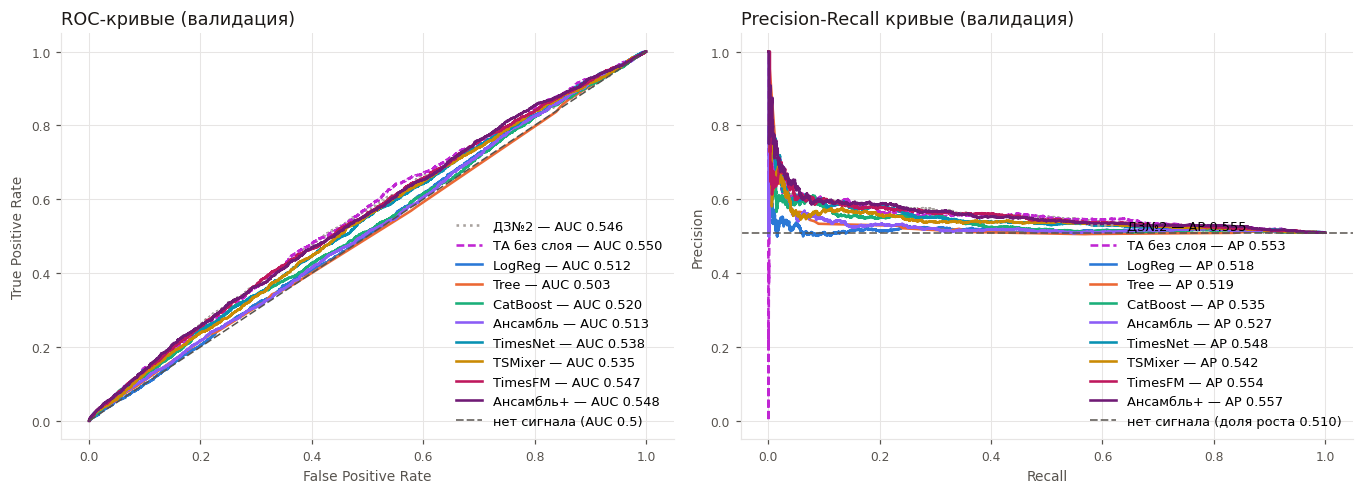

In [57]:
prevalence = float(y_val.mean())
fig, (ax_roc, ax_pr) = plt.subplots(1, 2, figsize=(12.5, 4.6))
curve_models = (["HW2_Baseline", "TA_AlwaysIn"] + list(final_models)
                + ["Ensemble"] + SEQ_MODELS)
proba_map = {"HW2_Baseline": hw2_val_proba, "TA_AlwaysIn": ta_val_proba, **val_proba}
for name in curve_models:
    prob = proba_map[name]
    fpr, tpr, _ = roc_curve(y_val, prob)
    ax_roc.plot(fpr, tpr, color=COLORS[name], linewidth=1.7,
                linestyle=STYLES.get(name, "-"),
                label=f"{SHORT[name]} — AUC {val_comparison.loc[name, 'roc_auc']:.3f}")
    prec, rec, _ = precision_recall_curve(y_val, prob)
    ax_pr.plot(rec, prec, color=COLORS[name], linewidth=1.7, linestyle=STYLES.get(name, "-"),
               label=f"{SHORT[name]} — AP {val_comparison.loc[name, 'pr_auc']:.3f}")
ax_roc.plot([0, 1], [0, 1], color=INK_MUTED, linewidth=1.0, linestyle=(0, (5, 2)),
            label="нет сигнала (AUC 0.5)")
ax_roc.set_xlabel("False Positive Rate", color=INK_MUTED, fontsize=9)
ax_roc.set_ylabel("True Positive Rate", color=INK_MUTED, fontsize=9)
ax_roc.set_title("ROC-кривые (валидация)", color=INK, fontsize=11.5, loc="left")
ax_pr.axhline(prevalence, color=INK_MUTED, linewidth=1.0, linestyle=(0, (5, 2)),
              label=f"нет сигнала (доля роста {prevalence:.3f})")
ax_pr.set_xlabel("Recall", color=INK_MUTED, fontsize=9)
ax_pr.set_ylabel("Precision", color=INK_MUTED, fontsize=9)
ax_pr.set_title("Precision-Recall кривые (валидация)", color=INK, fontsize=11.5, loc="left")
for ax in (ax_roc, ax_pr):
    ax.legend(frameon=False, fontsize=8.5, loc="lower right")
    ax.grid(color=GRID, linewidth=0.7)
    style_ax(ax, ygrid=False)
    ax.grid(color=GRID, linewidth=0.7)
fig.tight_layout()
plt.show()

### 18.1 Прямое сравнение: та же модель с новостями и без них

Абляция раздела 12 сравнивала наборы признаков на кросс-валидации внутри dev. Отложенная
выборка такого сравнения до сих пор не видела: на ней были только модели **с** новостями, а
эталонами служили buy & hold и ДЗ №2 — другие признаки, другой торговый слой. Ответить
«окупились ли новости» по такой таблице нельзя.

Здесь строится **парный эксперимент на валидации**. Для каждой из трёх моделей (и для их
ансамбля) обучается близнец на том же наборе `MODEL_COLS`, из которого удалены новостные
признаки. Совпадает всё остальное: гиперпараметры из раздела 15, границы винзоризации по dev,
веса наблюдений, фолды кросс-валидации, разбиение выборок. Различие ровно одно — наличие
новостных признаков в матрице.

Торговый слой показан в двух вариантах, и это не придирка:

- **тот же слой** — близнец получает от модели с новостями параметры слоя (режим, ширину зоны
  `q`, сглаживание и период ребалансировки), а квантильные пороги, как и везде в ноутбуке,
  считаются по его собственному dev-распределению прогнозов: пороги чужого распределения просто
  обнулили бы торговлю. Тогда разница в деньгах объясняется только прогнозом, но близнец
  работает на чужих настройках слоя;
- **свой слой** — близнецу подбирается слой по его собственным OOF-прогнозам, как в разделе 15
  для основных моделей. Честнее по отношению к близнецу, зато в разницу попадает и настройка
  слоя.

Оговорка, которую нельзя опускать: гиперпараметры подбирались Optuna на наборе **с**
новостями, поэтому конфигурация чуть подстроена именно под него. Симметричный эксперимент —
отдельный подбор для близнеца — стоил бы ещё 75 попыток и в этот ноутбук не влез; смещение
здесь работает **в пользу** новостей, и это надо помнить при чтении Δ.

Модели раздела 17 в парном эксперименте не участвуют: их каналы — 14 непрерывных признаков
ТА, новостных признаков они не видят вовсе, поэтому близнеца «без новостей» у них нет.

Разность метрик на выборке в 5 715 баров сама по себе шумная, поэтому к каждой Δ приложен
**блочный бутстрап** (блок 24 бара — сутки, 1 000 повторов): доверительный интервал говорит,
отличима ли разница от нуля вообще.

С новостями: 25 признаков, из них новостных 2 (news_count_24, news_count_168)
Без новостей: тот же набор минус новостные, всего 23



  близнец LogisticRegression   готов; свой торговый слой: {'mode': 'hold', 'span': 1, 'rebalance': 24, 'q': 0.35}


  близнец DecisionTree         готов; свой торговый слой: {'mode': 'hold', 'span': 4, 'rebalance': 24, 'q': 0.05}


  близнец CatBoost             готов; свой торговый слой: {'mode': 'hold', 'span': 4, 'rebalance': 1, 'q': 0.2}


  LogReg    : Δ ROC-AUC +0.0013, Δ net +6.34%, Δ Sharpe +0.53


...

признаков  accuracy      f1  roc_auc  \
модель   вариант                                                           
LogReg   с новостями                       25    0.5139  0.5836   0.5119   
         без новостей, тот же слой         23    0.5032  0.5316   0.5106   
         без новостей, свой слой           23    0.5032  0.5316   0.5106   
Tree     с новостями                       25    0.4987  0.4294   0.5026   
         без новостей, тот же слой         23    0.5045  0.3854   0.5050   
         без новостей, свой слой           23    0.5045  0.3854   0.5050   
CatBoost с новостями                       25    0.5048  0.5729   0.5200   
         без новостей, тот же слой         23    0.5074  0.5392   0.5171   
         без новостей, свой слой           23    0.5074  0.5392   0.5171   
Ансамбль с новостями                       25    0.5046  0.5566   0.5133   
         без новостей, тот же слой         23    0.5059  0.4666   0.5140   
         без новостей, свой слой           23    0.5059  0.4666   0.5140   

                                    pr_auc  
модель   вариант                            
LogReg   с новостями                0.5178  
         без новостей, тот же слой  0.5197  
         без новостей, свой слой    0.5197  
Tree     с новостями                0.5194  
         без новостей, тот же слой  0.5126  
         без новостей, свой слой    0.5126  
CatBoost с новостями                0.5350  
         без новостей, тот же слой  0.5318  
         без новостей, свой слой    0.5318  
Ансамбль с новостями                0.5269  
         без новостей, тот же слой  0.5212  
         без новостей, свой слой    0.5212

gross_return  fee_drag  total_return  \
модель   вариант                                                           
LogReg   с новостями                      0.0262     0.099       -0.0705   
         без новостей, тот же слой       -0.0087     0.135       -0.1339   
         без новостей, свой слой          0.0707     0.223       -0.1435   
Tree     с новостями                      0.2383     0.111        0.1082   
         без новостей, тот же слой       -0.0757     0.103       -0.1662   
         без новостей, свой слой         -0.3747     0.159       -0.4666   
CatBoost с новостями                      0.4160     0.055        0.3402   
         без новостей, тот же слой        0.0713     0.123       -0.0529   
         без новостей, свой слой          0.1311     0.657       -0.4139   
Ансамбль с новостями                      0.7376     0.001        0.7358   
         без новостей, тот же слой       -0.0584     0.021       -0.0780   
         без новостей, свой слой          0.4109     0.077        0.3064   

                                    sharpe  max_drawdown  n_trades  \
модель   вариант                                                     
LogReg   с новостями               -0.3745       -0.2659        99   
         без новостей, тот же слой -0.9030       -0.2363       135   
         без новостей, свой слой   -0.1992       -0.3896       112   
Tree     с новостями                0.5631       -0.4323        56   
         без новостей, тот же слой -0.2812       -0.3336        52   
         без новостей, свой слой   -1.6042       -0.5730        80   
CatBoost с новостями                1.1257       -0.4365        28   
         без новостей, тот же слой  0.0989       -0.5567        62   
         без новостей, свой слой   -1.3183       -0.4587       329   
Ансамбль с новостями                1.8938       -0.3098         1   
         без новостей, тот же слой  0.0100       -0.5413        11   
         без новостей, свой слой    1.7874       -0.1671        77   

                                    turnover_units  time_in_market  \
модель   вариант                                                     
LogReg   с новостями                          99.0          0.2577   
         без новостей, тот же слой           135.0          0.1790   
         без новостей, свой слой             223.0          1.0000   
Tree     с новостями                         111.0          0.9958   
         без новостей, тот же слой           103.0          0.9916   
         без новостей, свой слой             159.0          0.9958   
CatBoost с новостями                          55.0          1.0000   
         без новостей, тот же слой           123.0          1.0000   
         без новостей, свой слой             657.0          0.9997   
Ансамбль с новостями                           1.0          0.9977   
         без новостей, тот же слой            21.0          0.9601   
         без новостей, свой слой              77.0          0.2399   

                                    avg_position  
модель   вариант                                  
LogReg   с новостями                      0.1948  
         без новостей, тот же слой        0.0320  
         без новостей, свой слой          0.0425  
Tree     с новостями                      0.4499  
         без новостей, тот же слой        0.0509  
         без новостей, свой слой         -0.0373  
CatBoost с новостями                      0.7984  
         без новостей, тот же слой        0.5213  
         без новостей, свой слой          0.2770  
Ансамбль с новостями                      0.9977  
         без новостей, тот же слой        0.3743  
         без новостей, свой слой          0.2399

Разность «с новостями − без новостей» при одинаковом торговом слое и её 95% ДИ по блочному бутстрапу:


,ROC-AUC с,ROC-AUC без,Δ ROC-AUC,95% ДИ Δ ROC-AUC,Δ net Sharpe,95% ДИ Δ Sharpe,Δ gross,Δ net,Δ сделок
модель,,,,,,,,,
LogReg,0.5119,0.5106,0.0013,[-0.0019; +0.0045],0.53,[-1.87; +2.88],0.0349,0.0634,-36
Tree,0.5026,0.5050,-0.0023,[-0.0174; +0.0130],0.84,[-2.60; +4.61],0.3141,0.2744,4
CatBoost,0.5200,0.5171,0.0029,[-0.0016; +0.0078],1.03,[-1.37; +3.52],0.3447,0.3930,-34
Ансамбль,0.5133,0.5140,-0.0007,[-0.0114; +0.0101],1.88,[-0.39; +4.24],0.7959,0.8138,-10


Доверительный интервал накрывает ноль: у 4 из 4 моделей по Δ ROC-AUC и у 4 из 4 по Δ net Sharpe.


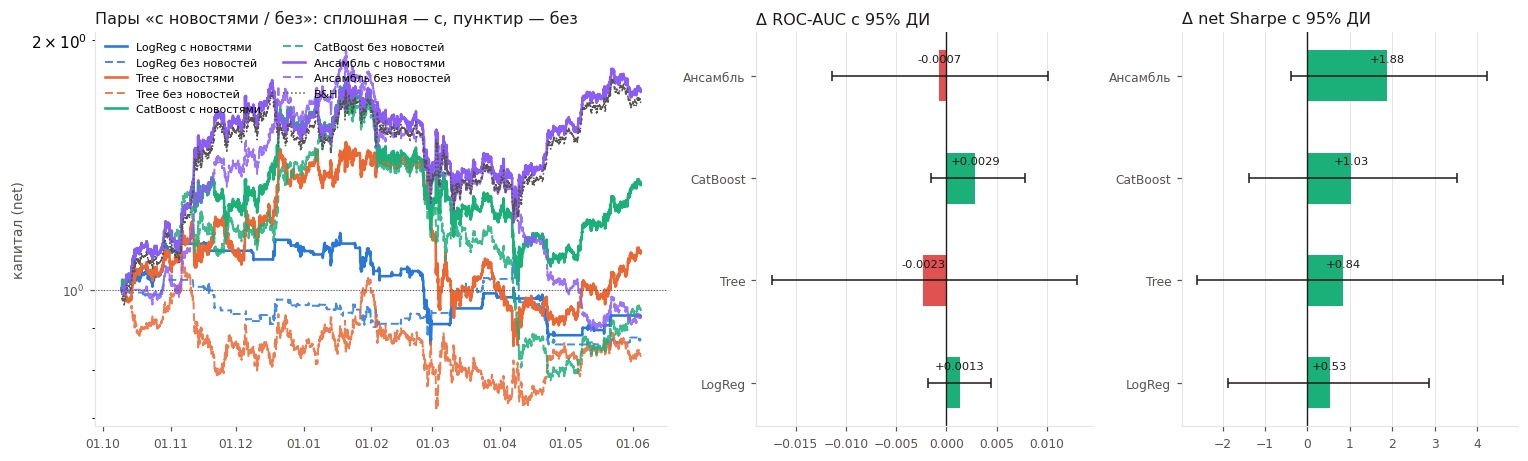

Средняя ширина 95% ДИ для Δ ROC-AUC — 0.0169 при |Δ| не больше 0.0029: на выборке в 5715 баров
разница «с новостями / без» неотличима от нуля — тот же вывод, что и у абляции раздела 12,
сделанной на другой выборке и по другому протоколу.


In [58]:
# Парный эксперимент: те же модели и тот же конвейер, но матрица без новостных признаков.
NEWS_IN_MODEL = [c for c in MODEL_COLS if c in news_cols]
NONEWS_COLS = [c for c in MODEL_COLS if c not in news_cols]
PAIR_MODELS = list(final_models) + ["Ensemble"]
BOOT_BLOCK, BOOT_B = 24, 1000        # блок бутстрапа = сутки, число повторов

print(f"С новостями: {len(MODEL_COLS)} признаков, из них новостных {len(NEWS_IN_MODEL)} "
      f"({', '.join(NEWS_IN_MODEL) if NEWS_IN_MODEL else '—'})")
print(f"Без новостей: тот же набор минус новостные, всего {len(NONEWS_COLS)}\n")

nonews_bounds = winsor_bounds(dev_df[NONEWS_COLS])
Xd_nn = apply_winsor(dev_df[NONEWS_COLS], nonews_bounds)
Xv_nn = apply_winsor(val_df[NONEWS_COLS], nonews_bounds)

nonews_models, nonews_oof, nonews_signal = {}, {}, {}
nonews_dev_proba, nonews_val_proba = {}, {}
for name, (builder, params) in final_specs.items():
    w_ret = studies[name].best_params.get("w_ret", False)
    oof, mask = cv_oof(lambda: builder(**params), NONEWS_COLS,
                       winsor=True, w_outlier=True, w_ret=w_ret)
    nonews_oof[name] = (oof, mask)
    nonews_signal[name], _, _ = tune_signal_layer(oof[mask], dates_dev.to_numpy()[mask],
                                                  fwd_dev.to_numpy()[mask])
    model = builder(**params)
    w = sample_weights(dev_df, np.arange(len(dev_df)), w_outlier=True, w_ret=w_ret)
    if hasattr(model, "steps"):
        model.fit(Xd_nn, y_dev_full, **{f"{model.steps[-1][0]}__sample_weight": w})
    else:
        model.fit(Xd_nn, y_dev_full, sample_weight=w)
    nonews_models[name] = model
    nonews_dev_proba[name] = predict_proba1(model, Xd_nn)
    nonews_val_proba[name] = predict_proba1(model, Xv_nn)
    print(f"  близнец {name:20s} готов; свой торговый слой: {nonews_signal[name]}")

# ансамбль без новостей собирается ровно так же, как в разделе 16
mask_nn = np.all([nonews_oof[nm][1] for nm in nonews_models], axis=0)
oof_ens_nn = np.nanmean(np.vstack([nonews_oof[nm][0] for nm in nonews_models]), axis=0)
nonews_oof["Ensemble"] = (oof_ens_nn, mask_nn)
nonews_signal["Ensemble"], _, _ = tune_signal_layer(
    oof_ens_nn[mask_nn], dates_dev.to_numpy()[mask_nn], fwd_dev.to_numpy()[mask_nn])
nonews_dev_proba["Ensemble"] = np.mean([nonews_dev_proba[nm] for nm in nonews_models], axis=0)
nonews_val_proba["Ensemble"] = np.mean([nonews_val_proba[nm] for nm in nonews_models], axis=0)


def eval_on_val(proba, params, ref):
    """Прогноз -> торговый слой -> метрики на валидации. Пороги — из dev-распределения."""
    pos = apply_signal(proba, params, ref)
    curve, trade = backtest(val_dates, val_fwd, pos)
    rep = classification_metrics(y_val, (proba >= 0.5).astype(int), proba)
    return pos, curve, {**rep, **trade}


def sharpe_of(r):
    s = float(np.std(r, ddof=0))
    return float(np.mean(r) / s * np.sqrt(PERIODS_PER_YEAR)) if s > 0 else 0.0


def block_idx(n, rng):
    """Индексы одного повтора блочного бутстрапа: склейка случайных суточных блоков."""
    starts = rng.integers(0, max(n - BOOT_BLOCK, 1), size=int(np.ceil(n / BOOT_BLOCK)))
    return (starts[:, None] + np.arange(BOOT_BLOCK)).ravel()[:n]


def paired_bootstrap(p_a, p_b, r_a, r_b):
    """95% ДИ парных разностей Δ ROC-AUC и Δ net Sharpe на одних и тех же ресемплах."""
    rng = np.random.default_rng(RANDOM_STATE)
    yv = y_val.to_numpy()
    d_auc, d_sh = [], []
    for _ in range(BOOT_B):
        i = block_idx(len(yv), rng)
        yy = yv[i]
        if yy.min() == yy.max():
            continue
        d_auc.append(roc_auc_score(yy, p_a[i]) - roc_auc_score(yy, p_b[i]))
        d_sh.append(sharpe_of(r_a[i]) - sharpe_of(r_b[i]))
    ci = lambda v: (float(np.quantile(v, 0.025)), float(np.quantile(v, 0.975)))
    return ci(d_auc), ci(d_sh)


pair_rows, delta_rows = [], []
nonews_positions, nonews_curves, pair_curves, pair_metrics = {}, {}, {}, {}
for name in PAIR_MODELS:
    pos_w, curve_w, m_w = eval_on_val(val_proba[name], signal_by_model[name],
                                      dev_proba_final[name])
    pos_o, curve_o, m_o = eval_on_val(nonews_val_proba[name], signal_by_model[name],
                                      nonews_dev_proba[name])
    pos_s, curve_s, m_s = eval_on_val(nonews_val_proba[name], nonews_signal[name],
                                      nonews_dev_proba[name])
    nonews_positions[name], nonews_curves[name] = pos_o, curve_o
    pair_curves[name], pair_metrics[name] = (curve_w, curve_o), (m_w, m_o)
    for tag, k_cols, m in (("с новостями", len(MODEL_COLS), m_w),
                           ("без новостей, тот же слой", len(NONEWS_COLS), m_o),
                           ("без новостей, свой слой", len(NONEWS_COLS), m_s)):
        pair_rows.append({"модель": SHORT[name], "вариант": tag, "признаков": k_cols, **m})
    ci_auc, ci_sh = paired_bootstrap(val_proba[name], nonews_val_proba[name],
                                     curve_w["strategy_return"].to_numpy(),
                                     curve_o["strategy_return"].to_numpy())
    delta_rows.append({
        "модель": SHORT[name],
        "ROC-AUC с": m_w["roc_auc"], "ROC-AUC без": m_o["roc_auc"],
        "Δ ROC-AUC": m_w["roc_auc"] - m_o["roc_auc"],
        "auc_lo": ci_auc[0], "auc_hi": ci_auc[1],
        "Δ net Sharpe": m_w["sharpe"] - m_o["sharpe"],
        "sh_lo": ci_sh[0], "sh_hi": ci_sh[1],
        "Δ gross": m_w["gross_return"] - m_o["gross_return"],
        "Δ net": m_w["total_return"] - m_o["total_return"],
        "Δ сделок": int(m_w["n_trades"] - m_o["n_trades"]),
    })
    print(f"  {SHORT[name]:10s}: Δ ROC-AUC {m_w['roc_auc'] - m_o['roc_auc']:+.4f}, "
          f"Δ net {m_w['total_return'] - m_o['total_return']:+.2%}, "
          f"Δ Sharpe {m_w['sharpe'] - m_o['sharpe']:+.2f}")

pair_table = pd.DataFrame(pair_rows).set_index(["модель", "вариант"])
print("\nОдна и та же модель на валидации: с новостными признаками и без них")
display(pair_table[["признаков", "accuracy", "f1", "roc_auc", "pr_auc"]].round(4))
display(pair_table[["gross_return", "fee_drag", "total_return", "sharpe", "max_drawdown",
                    "n_trades", "turnover_units", "time_in_market",
                    "avg_position"]].round(4))

delta_table = pd.DataFrame(delta_rows).set_index("модель")
delta_show = delta_table[["ROC-AUC с", "ROC-AUC без", "Δ ROC-AUC"]].round(4)
delta_show["95% ДИ Δ ROC-AUC"] = [f"[{r.auc_lo:+.4f}; {r.auc_hi:+.4f}]"
                                  for r in delta_table.itertuples()]
delta_show["Δ net Sharpe"] = delta_table["Δ net Sharpe"].round(2)
delta_show["95% ДИ Δ Sharpe"] = [f"[{r.sh_lo:+.2f}; {r.sh_hi:+.2f}]"
                                 for r in delta_table.itertuples()]
delta_show["Δ gross"] = delta_table["Δ gross"].round(4)
delta_show["Δ net"] = delta_table["Δ net"].round(4)
delta_show["Δ сделок"] = delta_table["Δ сделок"]
print("Разность «с новостями − без новостей» при одинаковом торговом слое и её 95% ДИ "
      "по блочному бутстрапу:")
display(delta_show)
auc_zero = int(((delta_table["auc_lo"] < 0) & (delta_table["auc_hi"] > 0)).sum())
sh_zero = int(((delta_table["sh_lo"] < 0) & (delta_table["sh_hi"] > 0)).sum())
print(f"Доверительный интервал накрывает ноль: у {auc_zero} из {len(delta_table)} моделей "
      f"по Δ ROC-AUC и у {sh_zero} из {len(delta_table)} по Δ net Sharpe.")

fig, axes = plt.subplots(1, 3, figsize=(14, 4.3), gridspec_kw={"width_ratios": [1.7, 1, 1]})

ax = axes[0]
for name in PAIR_MODELS:
    cw, co = pair_curves[name]
    ax.plot(cw["date"], cw["equity"], color=COLORS[name], linewidth=1.7,
            label=f"{SHORT[name]} с новостями")
    ax.plot(co["date"], co["equity"], color=COLORS[name], linewidth=1.3,
            linestyle=(0, (4, 2)), alpha=0.85, label=f"{SHORT[name]} без новостей")
ax.plot(val_curves["BuyAndHold"]["date"], val_curves["BuyAndHold"]["equity"],
        color=INK_MUTED, linewidth=1.0, linestyle=":", label="B&H")
ax.axhline(1.0, color=INK_MUTED, linewidth=0.7, linestyle=":")
ax.set_yscale("log")
ax.set_ylabel("капитал (net)", color=INK_MUTED, fontsize=9)
ax.set_title("Пары «с новостями / без»: сплошная — с, пунктир — без",
             color=INK, fontsize=10.5, loc="left")
ax.legend(frameon=False, fontsize=7.2, ncol=2, loc="upper left")
ax.xaxis.set_major_formatter(mdates.DateFormatter("%d.%m"))
style_ax(ax)

for ax, col, lo_col, hi_col, title, fmt in (
        (axes[1], "Δ ROC-AUC", "auc_lo", "auc_hi", "Δ ROC-AUC с 95% ДИ", "{:+.4f}"),
        (axes[2], "Δ net Sharpe", "sh_lo", "sh_hi", "Δ net Sharpe с 95% ДИ", "{:+.2f}")):
    ys = np.arange(len(delta_table))
    vals = delta_table[col].to_numpy()
    lo = delta_table[lo_col].to_numpy()
    hi = delta_table[hi_col].to_numpy()
    ax.barh(ys, vals, height=0.5, color=[UP if v > 0 else DOWN for v in vals])
    ax.errorbar(vals, ys, xerr=[vals - lo, hi - vals], fmt="none", ecolor=INK,
                elinewidth=1.0, capsize=3)
    ax.axvline(0, color=INK, linewidth=0.9)
    ax.set_yticks(ys)
    ax.set_yticklabels(delta_table.index, fontsize=9)
    ax.set_title(title, color=INK, fontsize=10.5, loc="left")
    for yi, v in enumerate(vals):
        ax.annotate(fmt.format(v), xy=(v, yi), xytext=(0, 9), textcoords="offset points",
                    ha="center", fontsize=7.5, color=INK)
    style_ax(ax, ygrid=False, xgrid=True)

fig.tight_layout()
plt.show()
width_auc = float((delta_table["auc_hi"] - delta_table["auc_lo"]).mean())
print(f"Средняя ширина 95% ДИ для Δ ROC-AUC — {width_auc:.4f} при |Δ| не больше "
      f"{float(delta_table['Δ ROC-AUC'].abs().max()):.4f}: на выборке в {len(val_df)} баров")
print(f"разница «с новостями / без» {'неотличима' if auc_zero == len(delta_table) else 'у большинства моделей неотличима'} "
      f"от нуля — тот же вывод, что и у абляции раздела 12,")
print("сделанной на другой выборке и по другому протоколу.")

Таблица распадается на две части, и они говорят разное.

**Ранжирование не изменилось.** Δ ROC-AUC — от −0.0023 до +0.0029, и 95% доверительный интервал
накрывает ноль у всех четырёх моделей при средней ширине 0.0169, то есть в шесть раз больше
самой разницы. Это тот же вывод, что дала абляция раздела 12, но полученный на отложенной
выборке и в самой прямой постановке.

**Деньги изменились сильно, и все четыре различия в пользу новостей**: +6.3 п.п. net у LogReg,
+27.4 у дерева, +39.3 у CatBoost, +81.4 у ансамбля. Соблазн назвать это «эффектом новостей»
велик — именно поэтому дальше идёт раздел 18.2, который разбирает разницу на части. Два намёка
видны уже здесь:

- **средняя позиция** (`avg_position`) у моделей с новостями систематически длиннее: 0.195
  против 0.032 у LogReg, 0.450 против 0.051 у дерева, 0.798 против 0.521 у CatBoost и 0.998
  против 0.374 у ансамбля. На периоде, где buy & hold даёт +68.7%, более длинная позиция
  зарабатывает сама по себе, без всякого прогноза;
- **оборот** у трёх моделей из четырёх ниже (55 единиц против 123 у CatBoost, 1 против 21 у
  ансамбля), поэтому новостные модели меньше платят комиссий.

Вариант «близнец со своим торговым слоем» показывает, насколько результат чувствителен к
настройке слоя: слой, подобранный по собственным OOF-прогнозам близнеца, даёт на валидации
−46.7% у дерева и −41.4% у CatBoost — хуже, чем слой, взятый у модели с новостями. Разброс от
настройки торгового слоя здесь больше, чем от наличия новостных признаков, и это ещё одна
причина не принимать Δ net за меру полезности новостей.

### 18.2 Как новостные признаки меняют позиции портфеля

Метрики сравнивают модели, но задание требует другого: показать, что новости делают с
**позициями**. Разность двух портфелей из раздела 18.1 — та же модель с новостями и без —
сама является торговой серией: `Δpos(t) = pos_с(t) − pos_без(t)`, а её вклад в доходность
равен `Σ Δpos(t)·r(t→t+1)`. Раздел отвечает на три вопроса:

1. **Как часто** новости меняют решение — и меняют ли знак позиции (long ↔ short) или только
   присутствие в рынке (в позиции ↔ вне позиции);
2. **Чего это стоит и что приносит**: вклад различающихся баров в gross-доходность, добавленный
   оборот и добавленные комиссии, доля различий с верно угаданным знаком;
3. **Когда** различия возникают — привязаны ли они к всплескам новостного потока (`news_burst`,
   отношение суток к месячной медиане) или разбросаны по выборке случайно. Если новостные
   признаки работают как признаки *новостей*, различия должны сгущаться в шумных часах.

Позиции на валидации: одна и та же модель с новостными признаками и без них


,позиции совпали,баров с разной позицией,смена знака,вход/выход из рынка,средняя |Δpos|,средний Δpos,верный знак Δpos
модель,,,,,,,
LogReg,0.8058,1110,0,1110,1.0000,0.1627,0.5081
Tree,0.5339,2664,2640,24,1.9910,0.3990,0.5161
CatBoost,0.8614,792,792,0,2.0000,0.2772,0.5000
Ансамбль,0.6695,1889,1674,215,1.8862,0.6234,0.5082


,вклад Σ Δpos·r,из него наклон,из него тайминг,Δ оборота,Δ комиссий,Δ net
модель,,,,,,
LogReg,0.0363,0.0995,-0.0632,-36.0,-0.036,0.0634
Tree,0.2927,0.2439,0.0488,8.0,0.008,0.2744
CatBoost,0.2789,0.1694,0.1095,-68.0,-0.068,0.3930
Ансамбль,0.6154,0.3811,0.2343,-20.0,-0.020,0.8138


Доля баров с расхождением позиции по квинтилям всплеска новостного потока:


,LogReg,Tree,CatBoost,Ансамбль
квинтиль news_burst,,,,
очень тихо,0.2642,0.4217,0.1129,0.3403
тихо,0.2780,0.4327,0.1005,0.3872
норма,0.1414,0.4799,0.1195,0.4773
шумно,0.1665,0.5180,0.1323,0.3234
всплеск,0.1209,0.4785,0.2279,0.1236


Дальше на графике — Tree: у этой пары расхождений больше всего (46.6% баров).


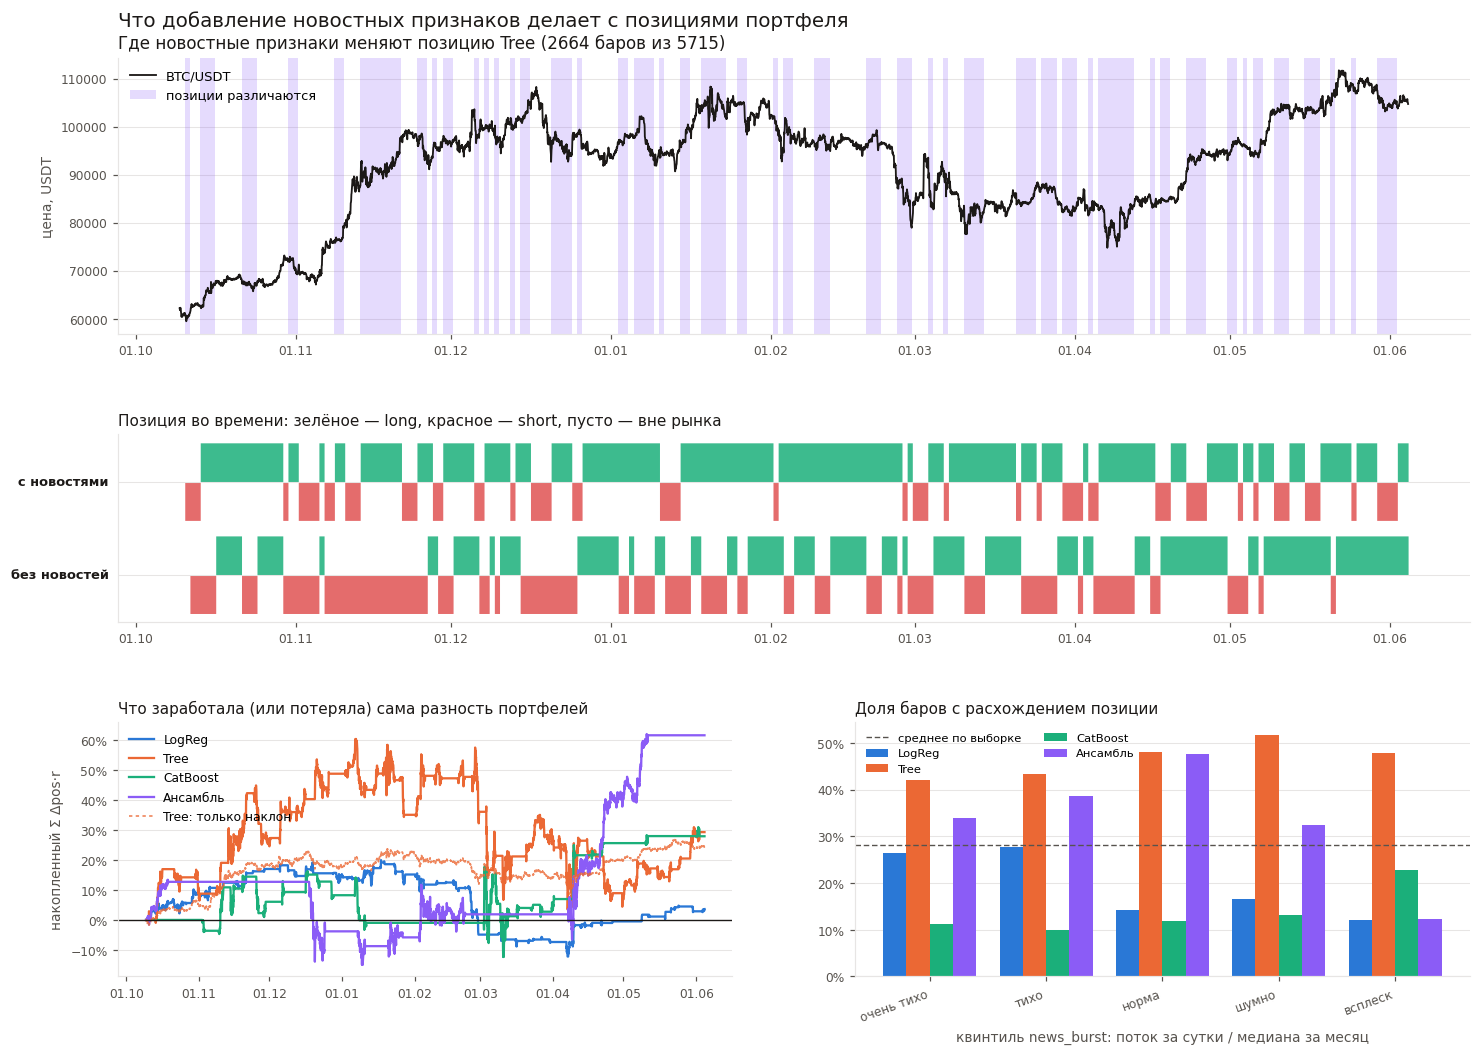

Различия с верно угаданным знаком: от 50.0% до 51.6% при доле роста на валидации 51.0%.
Расхождений больше всего в квинтиле «норма» (30.5% баров), меньше всего — «всплеск» (23.8%).
Суммарный вклад разности портфелей Σ Δpos·r: LogReg +3.63%, Tree +29.27%, CatBoost +27.89%, Ансамбль +61.54%
В нём наклон (просто более длинная средняя позиция на растущем периоде): LogReg +9.95%, Tree +24.39%, CatBoost +16.94%, Ансамбль +38.11%
и тайминг (умение менять позицию вовремя): LogReg -6.32%, Tree +4.88%, CatBoost +10.95%, Ансамбль +23.43%
Добавленные новостями комиссии: LogReg -3.60%, Tree +0.80%, CatBoost -6.80%, Ансамбль -2.00%


In [59]:
# Разность позиций: что новостные признаки меняют в портфеле на валидации.
BURST_LABELS = ["очень тихо", "тихо", "норма", "шумно", "всплеск"]
burst_codes, burst_bins = pd.qcut(val_df["news_burst"].to_numpy(), 5, labels=False,
                                  retbins=True, duplicates="drop")
burst_names = (BURST_LABELS if len(burst_bins) - 1 == len(BURST_LABELS)
               else [f"группа {i + 1}" for i in range(len(burst_bins) - 1)])
burst_q = pd.Categorical.from_codes(burst_codes, categories=burst_names, ordered=True)

pos_rows, intensity = [], {}
for name in PAIR_MODELS:
    p_w, p_o = val_positions[name], nonews_positions[name]
    m_w, m_o = pair_metrics[name]
    d = p_w - p_o
    diff = np.abs(d) > TRADE_EPS
    flip = diff & (p_w * p_o < 0)
    inout = diff & ((np.abs(p_w) <= TRADE_EPS) | (np.abs(p_o) <= TRADE_EPS))
    contrib = d * val_fwd
    # Σ Δpos·r = mean(Δpos)·Σr + n·cov(Δpos, r): первое слагаемое — просто более длинная
    # средняя позиция на растущем периоде, второе — умение менять её вовремя.
    drift = float(d.mean() * val_fwd.sum())
    pos_rows.append({
        "модель": SHORT[name],
        "позиции совпали": float(1 - diff.mean()),
        "баров с разной позицией": int(diff.sum()),
        "смена знака": int(flip.sum()),
        "вход/выход из рынка": int(inout.sum()),
        "средняя |Δpos|": float(np.abs(d[diff]).mean()) if diff.any() else 0.0,
        "верный знак Δpos": (float((np.sign(d[diff]) == np.sign(val_fwd[diff])).mean())
                             if diff.any() else np.nan),
        "средний Δpos": float(d.mean()),
        "вклад Σ Δpos·r": float(contrib.sum()),
        "из него наклон": drift,
        "из него тайминг": float(contrib.sum()) - drift,
        "Δ оборота": m_w["turnover_units"] - m_o["turnover_units"],
        "Δ комиссий": FEE_RATE * (m_w["turnover_units"] - m_o["turnover_units"]),
        "Δ net": m_w["total_return"] - m_o["total_return"],
    })
    intensity[SHORT[name]] = pd.Series(diff, dtype=float).groupby(burst_q,
                                                                  observed=False).mean()

pos_table = pd.DataFrame(pos_rows).set_index("модель")
print("Позиции на валидации: одна и та же модель с новостными признаками и без них")
display(pos_table[["позиции совпали", "баров с разной позицией", "смена знака",
                   "вход/выход из рынка", "средняя |Δpos|", "средний Δpos",
                   "верный знак Δpos"]].round(4))
display(pos_table[["вклад Σ Δpos·r", "из него наклон", "из него тайминг", "Δ оборота",
                   "Δ комиссий", "Δ net"]].round(4))

intensity_tab = pd.DataFrame(intensity)
intensity_tab.index.name = "квинтиль news_burst"
print("Доля баров с расхождением позиции по квинтилям всплеска новостного потока:")
display(intensity_tab.round(4))

FOCUS = max(PAIR_MODELS, key=lambda nm: float(
    (np.abs(val_positions[nm] - nonews_positions[nm]) > TRADE_EPS).mean()))
p_w, p_o = val_positions[FOCUS], nonews_positions[FOCUS]
d_focus = p_w - p_o
diff_focus = np.abs(d_focus) > TRADE_EPS
print(f"Дальше на графике — {SHORT[FOCUS]}: у этой пары расхождений больше всего "
      f"({diff_focus.mean():.1%} баров).")

fig = plt.figure(figsize=(13.5, 9.6))
gs = fig.add_gridspec(3, 2, height_ratios=[1.25, 0.85, 1.15], hspace=0.42, wspace=0.2,
                      top=0.94, bottom=0.07, left=0.07, right=0.98)

# ── 1. цена и бары, где новости изменили позицию ────────────────────────────
ax = fig.add_subplot(gs[0, :])
ax.plot(val_dates, val_df["close"].to_numpy(), color=INK, linewidth=1.2, label="BTC/USDT")
ymin, ymax = ax.get_ylim()
ax.fill_between(val_dates, ymin, ymax, where=diff_focus, color=COLORS["Ensemble"],
                alpha=0.22, linewidth=0, step="post", label="позиции различаются")
ax.set_ylim(ymin, ymax)
ax.set_ylabel("цена, USDT", color=INK_MUTED, fontsize=9)
ax.set_title(f"Где новостные признаки меняют позицию {SHORT[FOCUS]} "
             f"({int(diff_focus.sum())} баров из {len(val_df)})",
             color=INK, fontsize=11, loc="left")
ax.legend(frameon=False, fontsize=8.5, loc="upper left")
ax.xaxis.set_major_formatter(mdates.DateFormatter("%d.%m"))
style_ax(ax)

# ── 2. две полосы позиций и их разность ─────────────────────────────────────
ax = fig.add_subplot(gs[1, :])
for k, (lbl, pos) in enumerate((("без новостей", p_o), ("с новостями", p_w))):
    ax.fill_between(val_dates, k * 2.4 + np.clip(pos, 0, 1), k * 2.4, color=UP,
                    linewidth=0, alpha=0.85, step="post")
    ax.fill_between(val_dates, k * 2.4 + np.clip(pos, -1, 0), k * 2.4, color=DOWN,
                    linewidth=0, alpha=0.85, step="post")
    ax.axhline(k * 2.4, color=GRID, linewidth=0.7)
    ax.annotate(lbl, xy=(0, k * 2.4), xycoords=("axes fraction", "data"), xytext=(-6, 0),
                textcoords="offset points", ha="right", va="center", fontsize=8.5,
                color=INK, fontweight="bold")
ax.set_yticks([])
ax.set_title("Позиция во времени: зелёное — long, красное — short, пусто — вне рынка",
             color=INK, fontsize=10, loc="left")
ax.xaxis.set_major_formatter(mdates.DateFormatter("%d.%m"))
style_ax(ax, ygrid=False)

# ── 3. накопленный вклад разности портфелей ─────────────────────────────────
ax = fig.add_subplot(gs[2, 0])
for name in PAIR_MODELS:
    d = val_positions[name] - nonews_positions[name]
    ax.plot(val_dates, np.cumsum(d * val_fwd), color=COLORS[name], linewidth=1.5,
            label=SHORT[name])
d_focus_only = val_positions[FOCUS] - nonews_positions[FOCUS]
ax.plot(val_dates, np.cumsum(d_focus_only.mean() * val_fwd), color=COLORS[FOCUS],
        linewidth=1.1, linestyle=(0, (2, 2)), alpha=0.8,
        label=f"{SHORT[FOCUS]}: только наклон")
ax.axhline(0, color=INK, linewidth=0.9)
ax.yaxis.set_major_formatter(PercentFormatter(xmax=1, decimals=0))
ax.set_ylabel("накопленный Σ Δpos·r", color=INK_MUTED, fontsize=9)
ax.set_title("Что заработала (или потеряла) сама разность портфелей",
             color=INK, fontsize=10, loc="left")
ax.legend(frameon=False, fontsize=8)
ax.xaxis.set_major_formatter(mdates.DateFormatter("%d.%m"))
style_ax(ax)

# ── 4. различия против новостного фона ──────────────────────────────────────
ax = fig.add_subplot(gs[2, 1])
xs = np.arange(len(intensity_tab))
width = 0.8 / len(PAIR_MODELS)
for j, name in enumerate(PAIR_MODELS):
    ax.bar(xs + j * width - 0.4 + width / 2, intensity_tab[SHORT[name]].to_numpy(),
           width=width, color=COLORS[name], label=SHORT[name])
ax.axhline(float(np.mean([intensity_tab[SHORT[nm]].mean() for nm in PAIR_MODELS])),
           color=INK_MUTED, linewidth=0.9, linestyle=(0, (4, 2)), label="среднее по выборке")
ax.set_xticks(xs)
ax.set_xticklabels(intensity_tab.index, fontsize=8, rotation=20, ha="right")
ax.yaxis.set_major_formatter(PercentFormatter(xmax=1, decimals=0))
ax.set_xlabel("квинтиль news_burst: поток за сутки / медиана за месяц",
              color=INK_MUTED, fontsize=9)
ax.set_title("Доля баров с расхождением позиции", color=INK, fontsize=10, loc="left")
ax.legend(frameon=False, fontsize=7.5, ncol=2)
style_ax(ax)

fig.suptitle("Что добавление новостных признаков делает с позициями портфеля",
             fontsize=13, y=0.985, color=INK, x=0.07, ha="left")
plt.show()

mean_share = intensity_tab.mean(axis=1)
top_q, bot_q = mean_share.idxmax(), mean_share.idxmin()
print(f"Различия с верно угаданным знаком: от {pos_table['верный знак Δpos'].min():.1%} "
      f"до {pos_table['верный знак Δpos'].max():.1%} при доле роста на валидации "
      f"{float(y_val.mean()):.1%}.")
print(f"Расхождений больше всего в квинтиле «{top_q}» ({mean_share.max():.1%} баров), "
      f"меньше всего — «{bot_q}» ({mean_share.min():.1%}).")
print("Суммарный вклад разности портфелей Σ Δpos·r: "
      + ", ".join(f"{i} {v:+.2%}" for i, v in pos_table["вклад Σ Δpos·r"].items()))
print("В нём наклон (просто более длинная средняя позиция на растущем периоде): "
      + ", ".join(f"{i} {v:+.2%}" for i, v in pos_table["из него наклон"].items()))
print("и тайминг (умение менять позицию вовремя): "
      + ", ".join(f"{i} {v:+.2%}" for i, v in pos_table["из него тайминг"].items()))
print("Добавленные новостями комиссии: "
      + ", ".join(f"{i} {v:+.2%}" for i, v in pos_table["Δ комиссий"].items()))

Три вопроса раздела получили ответы, и все три уточняют картину из 18.1.

**Как часто.** Новости меняют позицию редко и по-разному: у CatBoost расходится 13.9% баров, у
ансамбля 33.1%, у дерева 46.6%. Характер расхождения задаёт торговый слой: у CatBoost все 792
расхождения — переворот знака (модель всегда в рынке), у LogReg все 1 110 — вход или выход из
рынка.

**Чего это стоит и что приносит.** Разложение `Σ Δpos·r = mean(Δpos)·Σr + n·cov(Δpos, r)`
показывает, что основную часть вклада даёт **наклон**, а не тайминг: у LogReg +9.9% наклона
против −6.3% тайминга при итоге +3.6%, у дерева +24.4% из +29.3%, у CatBoost +16.9% из +27.9%,
у ансамбля +38.1% из +61.5%. Средний Δpos положителен у всех четырёх моделей (от +0.16 до
+0.62): новостные счётчики убеждают модель дольше стоять в лонге, а период растущий. К этому
добавляется экономия на комиссиях — до 6.8% капитала у CatBoost за счёт меньшего оборота.

Доля различающихся баров, где знак Δpos совпал со знаком доходности, — 50.0–51.6% при базовой
доле роста 51.0%. Систематической правоты в этих решениях нет: тайминговая часть дохода
набралась на нескольких крупных барах, а не на устойчивом преимуществе.

**Когда.** Единой связи со всплесками потока нет: по квинтилям `news_burst` доля расхождений не
монотонна, и её направление зависит от модели — у CatBoost расхождения вдвое чаще в квинтиле
«всплеск» (22.8% против 10–13% в тихих часах), а у LogReg и ансамбля там же, наоборот, реже
всего (12.1% и 12.4%). То есть у отдельной модели связь бывает, но общего правила «шумно —
значит расходимся» нет. Уцелевшие счётчики ведут себя как медленный фоновый признак режима, а не как
реакция на новостное событие — ровно то применение, которое предлагается в конце раздела 23.

## 19. Обучение с подкреплением: агенты на FinRL

Все стратегии до этого места устроены одинаково. Модель оценивает вероятность роста, а отдельный
торговый слой (раздел 9) переводит эту вероятность в позицию по фиксированному правилу, параметры
которого подобраны перебором по сетке. Два решения — «куда пойдёт цена» и «какую долю капитала под
это поставить» — принимаются разными механизмами, и второй знает о первом ровно одно число.

Обучение с подкреплением снимает это разделение. Агент видит состояние рынка и собственную позицию,
действием сразу выбирает новую позицию, а наградой получает чистую — после комиссии — доходность
бара. Максимизируется ровно та величина, которой заканчивается бэктест; издержки входят в награду,
поэтому по замыслу агент сам решает, сколько торговать. Ограничения активности из раздела 14
(`MIN_TURNOVER_PER_YEAR`, `MIN_AVG_EXPOSURE`) здесь не нужны — но не потому, что агент сдержаннее:
они удерживали перебор торгового слоя от вырожденного «не торговать вовсе», а у агента такого выхода
нет, бездействие награды не приносит. Сработал ли сам замысел — вопрос раздела 19.4; забегая вперёд,
нет: оборот агенты не удержали.

**Чего здесь ждать не стоит.** RL в трейдинге сталкивается сразу с четырьмя неприятностями, и о них
честнее сказать заранее, чем потом объяснять результат.

1. *Награда почти вся — шум.* Отношение сигнала к шуму на часовом баре порядка 0.01: доходность бара
   на два порядка больше своего предсказуемого компонента. Градиент политики оценивается по этому
   шуму, и ему нужны десятки тысяч шагов, чтобы отличить решение от везения.
2. *История одна.* Обычный RL учится на миллионах эпизодов, потому что среду можно перезапускать.
   Рынок нельзя: у нас один проход длиной 32 тысячи баров (dev), и любой повторный проход по нему —
   это повторное обучение на тех же данных.
3. *Ёмкости хватает, чтобы запомнить траекторию.* Агент с MLP-политикой на своём обучающем участке
   почти всегда показывает прекрасный Sharpe. Это ничего не говорит о будущем, поэтому ниже везде
   рядом стоят две цифры: на обучающем участке и на том, которого агент не видел. Забегая вперёд:
   у off-policy алгоритмов раздела 19.1 так и вышло (SAC: train +2.86, test −3.66), а вот финальные
   агенты, переобученные на всём `dev`, не вышли в плюс даже на собственных обучающих данных — при
   таком бюджете шагов это недообучение, а не переобучение (раздел 19.4).
4. *Разброс по сидам сопоставим с разбросом по алгоритмам.* Одиночный запуск сообщает больше об
   инициализации, чем о методе, — поэтому каждый агент обучается на трёх сидах, а позиции
   усредняются. Это тот же приём, что усреднение вероятностей в разделе 16, только в пространстве
   позиций.

**Три постановки.**

- **19.1 — FinRL как есть.** Штатная `StockTradingEnv` на одном инструменте, пять алгоритмов
  Stable-Baselines3 через обёртку `DRLAgent`. Это буквальное прочтение задания: агент работает
  с денежным счётом, целыми «акциями» и комиссией, как в примерах фреймворка.
- **19.2 — позиционная среда.** Собственная `gymnasium`-среда, где действие — сразу доля капитала
  от −1 до +1, а награда — логарифм чистой доходности бара. Нужна затем, что штатная среда FinRL не
  умеет шортить и считает целые лоты, а весь остальной ноутбук говорит в терминах доли капитала.
- **19.3 — RL на вершине ансамбля.** Мета-агент, который не смотрит на рынок напрямую: его
  наблюдение — прогнозы всех шести моделей разделов 16 и 17, их согласие между собой, две
  характеристики состояния рынка и собственная позиция. Он заменяет собой и усреднение вероятностей, и торговый слой.

**Протокол.** Тот же, что у остальных моделей ноутбука, и здесь он важнее обычного. Алгоритм
выбирается по `test` — участку, которого агент при обучении не видел; победитель переобучается на
всём `dev`; валидация используется ровно один раз, в конце. Комиссия, бэктест и метрики — те же
самые функции, что у всех предыдущих стратегий, так что цифры сравнимы напрямую.

In [60]:
# RL-стек: gymnasium задаёт интерфейс среды, Stable-Baselines3 даёт реализации алгоритмов,
# FinRL — финансовую обвязку над ними: готовую среду торговли и обёртку DRLAgent.
import random

import gymnasium as gym
from gymnasium import spaces
import matplotlib
import stable_baselines3
from stable_baselines3 import A2C, DDPG, PPO, SAC, TD3

# FinRL на уровне модуля выполняет matplotlib.use("Agg") — после его импорта все графики
# ноутбука перестали бы отрисовываться в ячейках. Backend запоминается до импорта и
# возвращается после; на работу самого FinRL это не влияет, он рисует только в файлы.
_mpl_backend = matplotlib.get_backend()
import finrl
from finrl.agents.stablebaselines3.models import DRLAgent
from finrl.meta.env_stock_trading.env_stocktrading import StockTradingEnv
matplotlib.use(_mpl_backend)

print(f"gymnasium {gym.__version__} | stable-baselines3 {stable_baselines3.__version__} | "
      f"FinRL {getattr(finrl, '__version__', '0.3.7')} | backend matplotlib "
      f"{matplotlib.get_backend()}")

# Бюджеты обучения. On-policy (A2C, PPO) собирают дешёвые роллауты и требуют много шагов;
# off-policy (DDPG, TD3, SAC) делают градиентный шаг на каждом шаге среды и при равном числе
# шагов стоят на порядок дороже по времени. Уравнивать их по шагам нечестно, по времени — тоже;
# взят компромисс, при котором прогон раздела остаётся в пределах десятка минут.
RL_STEPS_ON = 60_000
RL_STEPS_OFF = 15_000
RL_STEPS = {"a2c": RL_STEPS_ON, "ppo": RL_STEPS_ON,
            "ddpg": RL_STEPS_OFF, "td3": RL_STEPS_OFF, "sac": RL_STEPS_OFF}
RL_ALGOS = ("a2c", "ppo", "ddpg", "td3", "sac")
RL_SEEDS = (0, 1, 2)          # RL чувствителен к сиду — везде усредняем по трём запускам
RL_EPISODE_LEN = 2048         # длина обучающего эпизода, баров (~3 месяца часовых данных)
RL_N_FEATURES = 24            # сколько признаков уходит в наблюдение агента
RL_INITIAL_CASH = 1e8         # стартовый капитал среды FinRL, «долларов»
RL_HMAX = 4000                # максимум «акций» BTC за шаг: хватает на полный вход за один ход

# Гиперпараметры: дефолты FinRL (finrl.config) с поправкой на часовой ряд — шагов в среде у нас
# на два порядка больше, чем в дневных задачах, под которые эти дефолты писались.
# device="cpu": политики здесь — крошечные MLP, на GPU они медленнее из-за накладных расходов
# на каждый вызов predict, а вызовов при прогоне по 40 тысячам баров десятки тысяч.
RL_KWARGS = {
    "a2c": {"n_steps": 16, "ent_coef": 0.005, "learning_rate": 7e-4, "device": "cpu"},
    "ppo": {"n_steps": 1024, "batch_size": 128, "ent_coef": 0.005, "learning_rate": 3e-4,
            "device": "cpu"},
    "ddpg": {"batch_size": 128, "buffer_size": 50_000, "learning_rate": 1e-3, "device": "cpu"},
    "td3": {"batch_size": 128, "buffer_size": 50_000, "learning_rate": 1e-3, "device": "cpu"},
    "sac": {"batch_size": 128, "buffer_size": 50_000, "learning_rate": 3e-4,
            "learning_starts": 500, "ent_coef": "auto_0.1", "device": "cpu"},
}
SB3_CLS = {"a2c": A2C, "ppo": PPO, "ddpg": DDPG, "td3": TD3, "sac": SAC}


def set_rl_seed(seed):
    """Единый сид для random, numpy и torch."""
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)


# Признаки для агента: топ по важности CatBoost из раздела 16. Весь MODEL_COLS в наблюдение не
# кладётся — политика-MLP за несколько десятков тысяч шагов не успевает разобраться в сотне
# входов, а лишняя ось наблюдения стоит RL дороже, чем градиентному бустингу лишний признак.
_rl_imp = pd.Series(final_models["CatBoost"].get_feature_importance(), index=MODEL_COLS)
RL_FEATURES = list(_rl_imp.sort_values(ascending=False).head(RL_N_FEATURES).index)
rl_bounds = (dev_bounds[0][RL_FEATURES], dev_bounds[1][RL_FEATURES])
_rl_dev_w = apply_winsor(dev_df[RL_FEATURES], rl_bounds)
rl_mu, rl_sd = _rl_dev_w.mean(), _rl_dev_w.std().replace(0.0, 1.0)


def rl_obs_matrix(part):
    """Наблюдение агента: винзоризация по dev-границам, z-оценка по dev, клип хвостов.

    Границы и статистики считаются только по dev — то же правило, что у табличных моделей
    (раздел 11) и у моделей последовательностей (раздел 17).
    """
    z = (apply_winsor(part[RL_FEATURES], rl_bounds) - rl_mu) / rl_sd
    return np.clip(z.to_numpy(dtype=np.float32), -5.0, 5.0)


rl_parts = {"train": train_df, "test": test_df, "dev": dev_df, "val": val_df}
rl_obs = {k: rl_obs_matrix(v) for k, v in rl_parts.items()}

print(f"Наблюдение агента: {len(RL_FEATURES)} признаков + текущая позиция.")
print("Топ-8 по важности CatBoost: " + ", ".join(RL_FEATURES[:8]))
print("Выборки для RL: " + ", ".join(f"{k} {len(v)} баров" for k, v in rl_parts.items()))

gymnasium 1.2.1 | stable-baselines3 2.7.0 | FinRL 0.3.7 | backend matplotlib inline
Наблюдение агента: 24 признаков + текущая позиция.
Топ-8 по важности CatBoost: lower_frac, fft512_top3_period, shadow_imbalance, news_count_168, ret_lag_8, sma5_slope, news_count_24, ret_lag_1
Выборки для RL: train 26664 баров, test 5713 баров, dev 32378 баров, val 5715 баров


### 19.1 FinRL «как есть»: StockTradingEnv и DRLAgent

FinRL — это не алгоритмы, а обвязка вокруг них. Сами PPO, A2C, DDPG, TD3 и SAC берутся из
Stable-Baselines3; FinRL добавляет к ним финансовую среду (`StockTradingEnv`), единый интерфейс
запуска (`DRLAgent.get_model` / `train_model` / `DRL_prediction`) и набор дефолтных
гиперпараметров в `finrl.config`. Этот раздел пользуется всем этим напрямую.

**Как устроена штатная среда.** Состояние — список `[кэш, цена, число акций, индикаторы...]`.
Действие — одно число в [−1, 1], умножаемое на `hmax` и округляемое до целого: столько «акций»
агент покупает (плюс) или продаёт (минус). Продать больше, чем есть, среда не даёт, поэтому
**позиция по построению лежит в [0, 1] — шорта нет**. Комиссия берётся с каждой стороны и равна
той же `FEE_RATE = 0.1%`, что во всех бэктестах ноутбука. Награда — прирост стоимости портфеля
за бар, умноженный на `reward_scaling`.

**Две поправки, без которых среда на наших данных не работает.** Обе выписаны в комментариях к
коду: нормировка наблюдения (FinRL кладёт в состояние сырые доллары, сырую цену BTC и сырые
индикаторы — разброс масштабов в пять порядков, MlpPolicy на таком входе не обучается) и обход
особенности реализации, из-за которой первый технический индикатор среда сравнивает с единицей.
Бухгалтерия среды при этом не меняется: позиции, комиссии и стоимость портфеля по-прежнему считает
сам FinRL, обёртка трогает только то, что видит нейросеть.

**Что сравнивается.** Пять алгоритмов при одинаковом протоколе. Бюджеты обучения разные:
on-policy методы (A2C, PPO) собирают дешёвые роллауты и требуют много шагов, off-policy (DDPG,
TD3, SAC) делают градиентный шаг на каждом шаге среды и при равном числе шагов стоят на порядок
дороже по времени. Уравнивать бюджеты по шагам было бы нечестно, по времени — тоже; выбран
компромисс, при котором прогон раздела остаётся в пределах десятка минут.

In [61]:
# Среда FinRL как есть: StockTradingEnv на одном инструменте BTC/USDT.
#
# Две технические поправки, без которых штатная среда на наших данных не работает.
#
# 1. Наблюдение. FinRL кладёт в состояние сырые величины: остаток кэша (у нас 1e8), цену BTC
#    (десятки тысяч) и сырые индикаторы. Разброс масштабов в пять порядков — MlpPolicy на таком
#    входе не обучается. Обёртка ниже НЕ трогает бухгалтерию среды (позиции, комиссии и стоимость
#    портфеля по-прежнему считает сам FinRL), а только переводит наблюдение в сопоставимые
#    единицы: доля кэша, z-оценка лог-цены, доля капитала в позиции, z-оценки индикаторов.
#
# 2. Особенность реализации FinRL: перед сделкой среда проверяет `state[3] != True`, то есть
#    сравнивает ПЕРВЫЙ технический индикатор с единицей (в исходном коде это задумывалось как
#    флаг «инструмент не торгуется»). Если первый индикатор на каком-то баре в точности равен
#    1.0, среда молча запрещает сделку на этом баре. Поэтому в df кладутся уже z-оценки, а первым
#    ставится признак, ни на одном баре dev/val не равный единице ровно.
RL_TECH = list(RL_FEATURES)
# сравнение точное, а не np.isclose: среда сравнивает значение с True, то есть с 1.0 ровно
_safe_first = [c for i, c in enumerate(RL_TECH)
               if not ((rl_obs["dev"][:, i] == 1.0).any() or (rl_obs["val"][:, i] == 1.0).any())]
if _safe_first:
    RL_TECH = [_safe_first[0]] + [c for c in RL_TECH if c != _safe_first[0]]
print(f"Первым индикатором в состоянии среды идёт «{RL_TECH[0]}»: ровно 1.0 он не принимает "
      f"ни на одном баре (таких признаков {len(_safe_first)} из {len(RL_FEATURES)}).")


def finrl_frame(part_name):
    """Данные в формате FinRL: (date, tic, close, индикаторы), индекс — номер бара."""
    part = rl_parts[part_name]
    z = pd.DataFrame(rl_obs[part_name], columns=RL_FEATURES)[RL_TECH].copy()
    first = RL_TECH[0]                                  # страховка к пункту 2 выше
    z[first] = z[first].where(z[first] != 1.0, np.float32(1.0 + 1e-5))
    d = pd.concat([part[["date", "close"]].reset_index(drop=True), z], axis=1)
    d["tic"] = "BTCUSDT"
    d.index = d["date"].factorize()[0]          # FinRL адресует бары через df.loc[day]
    return d


class ScaledStockTradingEnv(StockTradingEnv):
    """StockTradingEnv из FinRL с нормированным наблюдением (см. комментарий выше)."""

    def __init__(self, *args, price_mu=0.0, price_sd=1.0, **kwargs):
        super().__init__(*args, **kwargs)
        self.price_mu, self.price_sd = float(price_mu), float(price_sd)

    def _scale(self, state):
        s = np.asarray(state, dtype=np.float64)
        cash, price, shares = s[0], s[1], s[2]
        total = cash + price * shares
        obs = np.empty(len(s), dtype=np.float32)
        obs[0] = cash / total if total > 0 else 1.0                  # доля кэша
        obs[1] = (np.log(max(price, 1e-9)) - self.price_mu) / self.price_sd
        obs[2] = price * shares / total if total > 0 else 0.0        # доля капитала в позиции
        obs[3:] = np.clip(s[3:], -5.0, 5.0)                          # индикаторы уже z-оценки
        return obs

    def reset(self, **kwargs):
        state, info = super().reset(**kwargs)
        return self._scale(state), info

    def step(self, actions):
        state, reward, terminated, truncated, info = super().step(actions)
        return self._scale(state), reward, terminated, truncated, info


_log_close_dev = np.log(dev_df["close"].to_numpy())
RL_PRICE_MU, RL_PRICE_SD = float(_log_close_dev.mean()), float(_log_close_dev.std())


def make_finrl_env(part_name):
    """Готовая среда FinRL на выбранной выборке; комиссия — та же FEE_RATE, что в бэктесте."""
    return ScaledStockTradingEnv(
        df=finrl_frame(part_name), stock_dim=1, hmax=RL_HMAX,
        initial_amount=RL_INITIAL_CASH, num_stock_shares=[0],
        buy_cost_pct=[FEE_RATE], sell_cost_pct=[FEE_RATE], reward_scaling=1e-4,
        state_space=1 + 2 * 1 + len(RL_TECH), action_space=1,
        tech_indicator_list=RL_TECH, turbulence_threshold=None,
        print_verbosity=10 ** 9, price_mu=RL_PRICE_MU, price_sd=RL_PRICE_SD)


def finrl_positions(model, part_name):
    """Прогон обученной политики по среде FinRL с записью доли капитала в позиции.

    Доля считается по цене В МОМЕНТ РЕШЕНИЯ: после шага среда уже переоценила портфель по цене
    следующего бара, и доля «после» не равна той, с которой бар был пройден. Бэктест раздела 9
    умножает на доходность бара именно долю в момент решения.
    """
    env = make_finrl_env(part_name)
    obs, _ = env.reset()
    positions = []
    while True:
        price_now = float(env.state[1])
        action, _ = model.predict(obs, deterministic=True)
        obs, _, terminated, truncated, _ = env.step(action)
        if terminated or truncated:
            break
        cash, shares = float(env.state[0]), float(env.state[2])
        total = cash + shares * price_now
        positions.append(shares * price_now / total if total > 0 else 0.0)
    pos = np.asarray(positions, dtype=float)
    n_need = len(rl_parts[part_name])
    if len(pos) < n_need:      # среда делает на шаг меньше, чем баров: последний доигрывается
        pos = np.concatenate([pos, np.repeat(pos[-1:], n_need - len(pos))])
    return pos[:n_need]


print(f"Среда FinRL: stock_dim=1, hmax={RL_HMAX}, стартовый капитал {RL_INITIAL_CASH:,.0f}, "
      f"комиссия {FEE_RATE:.2%} с каждой стороны.")
print(f"Состояние = кэш + цена + позиция + {len(RL_TECH)} индикаторов = "
      f"{1 + 2 + len(RL_TECH)} чисел; действие — одно число в [-1, 1] (сколько лотов купить "
      f"или продать). Шорт в этой среде невозможен: позиция лежит в [0, 1].")

Первым индикатором в состоянии среды идёт «lower_frac»: ровно 1.0 он не принимает ни на одном баре (таких признаков 24 из 24).
Среда FinRL: stock_dim=1, hmax=4000, стартовый капитал 100,000,000, комиссия 0.10% с каждой стороны.
Состояние = кэш + цена + позиция + 24 индикаторов = 27 чисел; действие — одно число в [-1, 1] (сколько лотов купить или продать). Шорт в этой среде невозможен: позиция лежит в [0, 1].


In [62]:
# Пять алгоритмов FinRL/SB3: обучение на train, отбор — по test.
#
# Протокол тот же, что у остальных моделей ноутбука, и здесь он важнее обычного. RL-агент на
# своей обучающей выборке почти всегда показывает прекрасный результат: ёмкости хватает, чтобы
# запомнить конкретную траекторию цены. Поэтому алгоритм выбирается по test — участку, которого
# агент при обучении не видел, — а валидация в выборе не участвует.
rl_finrl_runs = {}

for algo in RL_ALGOS:
    t_start = time.perf_counter()
    set_rl_seed(RANDOM_STATE)
    env_train, _ = make_finrl_env("train").get_sb_env()
    agent = DRLAgent(env=env_train)                              # обёртка FinRL над SB3
    model = agent.get_model(algo, model_kwargs=dict(RL_KWARGS[algo]), verbose=0,
                            seed=RANDOM_STATE)
    model = agent.train_model(model=model, tb_log_name=algo,
                              total_timesteps=RL_STEPS[algo])
    pos_train = finrl_positions(model, "train")
    pos_test = finrl_positions(model, "test")
    _, m_train = backtest(train_df["date"].to_numpy(), train_df["fwd_ret"].to_numpy(), pos_train)
    _, m_test = backtest(test_df["date"].to_numpy(), test_df["fwd_ret"].to_numpy(), pos_test)
    rl_finrl_runs[algo] = {"train": m_train, "test": m_test,
                           "мин": (time.perf_counter() - t_start) / 60}
    del model, agent, env_train
    print(f"  {algo.upper():5s} {RL_STEPS[algo]:6d} шагов за {rl_finrl_runs[algo]['мин']:4.1f} мин"
          f" | train Sharpe {m_train['sharpe']:+.2f} | test Sharpe {m_test['sharpe']:+.2f}"
          f" | test net {m_test['total_return']:+.1%}"
          f" | экспозиция {m_test['avg_abs_position']:.2f}", flush=True)

finrl_table = pd.DataFrame({
    algo.upper(): {"train Sharpe": r["train"]["sharpe"],
                   "test Sharpe": r["test"]["sharpe"],
                   "test net": r["test"]["total_return"],
                   "test gross": r["test"]["gross_return"],
                   "оборот": r["test"]["turnover_units"],
                   "сделок": r["test"]["n_trades"],
                   "экспозиция": r["test"]["avg_abs_position"],
                   "минут обучения": r["мин"]}
    for algo, r in rl_finrl_runs.items()}).T
_, m_bh_test = backtest(test_df["date"].to_numpy(), test_df["fwd_ret"].to_numpy(),
                        np.ones(len(test_df)))
finrl_table.loc["Buy & Hold"] = [np.nan, m_bh_test["sharpe"], m_bh_test["total_return"],
                                 m_bh_test["gross_return"], m_bh_test["turnover_units"],
                                 m_bh_test["n_trades"], 1.0, np.nan]
print("\nОтбор алгоритма по test-участку (валидация не участвует):")
display(finrl_table.round(3))

FINRL_BEST = max(RL_ALGOS, key=lambda a: rl_finrl_runs[a]["test"]["sharpe"])
print(f"Лучший по test Sharpe: {FINRL_BEST.upper()} "
      f"({rl_finrl_runs[FINRL_BEST]['test']['sharpe']:+.2f}) — он и переобучается на всём dev.")

{'n_steps': 16, 'ent_coef': 0.005, 'learning_rate': 0.0007, 'device': 'cpu'}


  A2C    60000 шагов за  2.4 мин | train Sharpe +0.67 | test Sharpe +0.50 | test net +8.6% | экспозиция 0.83


{'n_steps': 1024, 'batch_size': 128, 'ent_coef': 0.005, 'learning_rate': 0.0003, 'device': 'cpu'}


  PPO    60000 шагов за  2.5 мин | train Sharpe -0.48 | test Sharpe -0.34 | test net -12.5% | экспозиция 0.54


{'batch_size': 128, 'buffer_size': 50000, 'learning_rate': 0.001, 'device': 'cpu'}


...

{'batch_size': 128, 'buffer_size': 50000, 'learning_rate': 0.0003, 'learning_starts': 500, 'ent_coef': 'auto_0.1', 'device': 'cpu'}


  SAC    15000 шагов за  4.1 мин | train Sharpe +2.86 | test Sharpe -3.66 | test net -55.4% | экспозиция 0.35



Отбор алгоритма по test-участку (валидация не участвует):


,train Sharpe,test Sharpe,test net,test gross,оборот,сделок,экспозиция,минут обучения
A2C,0.674,0.502,0.086,0.210,108.574,176.0,0.831,2.421
PPO,-0.482,-0.340,-0.125,0.268,371.297,923.0,0.544,2.458
DDPG,1.433,-5.014,-0.587,0.494,1286.239,1673.0,0.196,2.913
TD3,0.792,-1.507,-0.273,0.391,649.299,1062.0,0.217,2.858
SAC,2.856,-3.659,-0.554,0.798,1392.733,2033.0,0.355,4.100
Buy & Hold,NaN,0.798,0.203,0.204,1.000,1.0,1.000,NaN


Лучший по test Sharpe: A2C (+0.50) — он и переобучается на всём dev.


In [63]:
# Переобучение победителя на всём dev и прогноз на валидации — та же схема, что у моделей
# разделов 16 и 17: конфигурация выбрана на dev, финальная модель учится на всём dev.
t_start = time.perf_counter()
rl_val_positions, rl_dev_positions = {}, {}

set_rl_seed(RANDOM_STATE)
_env_dev, _ = make_finrl_env("dev").get_sb_env()
_agent_dev = DRLAgent(env=_env_dev)
finrl_final = _agent_dev.get_model(FINRL_BEST, model_kwargs=dict(RL_KWARGS[FINRL_BEST]),
                                   verbose=0, seed=RANDOM_STATE)
finrl_final = _agent_dev.train_model(model=finrl_final, tb_log_name=f"{FINRL_BEST}_dev",
                                     total_timesteps=RL_STEPS[FINRL_BEST])
rl_dev_positions["FinRL"] = finrl_positions(finrl_final, "dev")
rl_val_positions["FinRL"] = finrl_positions(finrl_final, "val")

_, _m_finrl_dev = backtest(dates_dev.to_numpy(), fwd_dev.to_numpy(), rl_dev_positions["FinRL"])
print(f"FinRL ({FINRL_BEST.upper()}): обучен на {len(dev_df)} барах dev за "
      f"{(time.perf_counter() - t_start) / 60:.1f} мин")
print(f"  на dev (это обучающая выборка, не оценка качества): "
      f"Sharpe {_m_finrl_dev['sharpe']:+.2f}, net {_m_finrl_dev['total_return']:+.1%}")
print(f"  на валидации: экспозиция {np.abs(rl_val_positions['FinRL']).mean():.2f}, "
      f"среднее направление {rl_val_positions['FinRL'].mean():+.2f} "
      f"(шорт в среде FinRL невозможен, поэтому позиция неотрицательна)")

{'n_steps': 16, 'ent_coef': 0.005, 'learning_rate': 0.0007, 'device': 'cpu'}


FinRL (A2C): обучен на 32378 барах dev за 2.9 мин
  на dev (это обучающая выборка, не оценка качества): Sharpe -0.11, net -52.0%
  на валидации: экспозиция 0.79, среднее направление +0.79 (шорт в среде FinRL невозможен, поэтому позиция неотрицательна)


### 19.2 Позиционная среда: действие — сразу доля капитала

Штатная среда FinRL считает целые лоты на денежном счёте и не умеет шортить. Весь остальной
ноутбук работает в терминах непрерывной позиции от −1 до +1 и сравнивает стратегии через один и
тот же `backtest()`. Среда этого раздела говорит на том же языке: действие и есть новая позиция,
награда — `log(1 + pos·r − fee·|Δpos|)`.

**Почему логарифм.** Сумма логарифмов побарных доходностей — это и есть итоговый капитал.
Максимизируя её, агент максимизирует ровно ту величину, которой заканчивается бэктест, а не
косвенную к ней. Комиссия стоит внутри награды, поэтому каждая сделка сразу стоит агенту денег:
отдельный штраф за оборот не нужен, и ограничения `MIN_TURNOVER_PER_YEAR` / `MIN_AVG_EXPOSURE`,
которыми в разделе 9 приходилось удерживать перебор от вырожденного оптимума, здесь не требуются —
у агента нет способа получить высокую награду, ничего не делая.

**Почему эпизод — случайный отрезок.** Один проход от первого бара к последнему даёт агенту одно
и то же начальное условие и одну и ту же последовательность режимов. Короткие эпизоды со случайным
стартом (2048 баров ≈ три месяца) дают разнообразие: агент видит и растущие, и падающие, и боковые
куски ряда, а не только тот порядок, в котором они шли в истории.

**Что проверяется.** Сначала PPO и SAC обучаются на `train` и проверяются на `test` — участке,
которого они не видели. Только после этого победитель переобучается на всём `dev` и один раз
применяется к валидации. Рядом с результатом на `test` печатается результат на `train`: расстояние
между ними и есть мера того, сколько агент запомнил вместо того, чтобы выучить.

In [64]:
# Позиционная среда: действие — сразу доля капитала от -1 до +1.
class PositionTradingEnv(gym.Env):
    """Среда в терминах доли капитала.

    Наблюдение — признаки бара плюс текущая позиция; действие — новая позиция;
    награда — log(1 + pos_t · r_t − fee · |pos_t − pos_{t-1}|).

    Логарифм, а не сама доходность, потому что сумма логарифмов побарных доходностей и есть
    итоговый капитал: агент максимизирует ровно ту величину, которой заканчивается бэктест.
    Комиссия входит в награду, поэтому каждая сделка сразу стоит денег — отдельный штраф за
    оборот не нужен, и ограничения MIN_TURNOVER_PER_YEAR / MIN_AVG_EXPOSURE, которыми в
    разделе 9 приходилось удерживать перебор от вырожденного оптимума «почти нулевая позиция
    без сделок», здесь не требуются: такая политика просто не приносит награды.

    Эпизод — случайный отрезок длины episode_len. Один проход от первого бара к последнему дал
    бы агенту одно начальное условие и один порядок режимов; случайный старт даёт разнообразие.
    """

    metadata = {"render_modes": []}

    def __init__(self, obs, fwd_ret, fee_rate=FEE_RATE, episode_len=RL_EPISODE_LEN,
                 random_start=True, seed=None):
        super().__init__()
        self.obs_mat = np.ascontiguousarray(obs, dtype=np.float32)
        self.fwd = np.asarray(fwd_ret, dtype=np.float64)
        self.n = len(self.fwd)
        self.fee = float(fee_rate)
        self.episode_len = int(min(episode_len or self.n, self.n))
        self.random_start = bool(random_start)
        self.observation_space = spaces.Box(-np.inf, np.inf,
                                            shape=(self.obs_mat.shape[1] + 1,),
                                            dtype=np.float32)
        self.action_space = spaces.Box(-1.0, 1.0, shape=(1,), dtype=np.float32)
        self._rng = np.random.default_rng(seed)
        self.t = self.t_end = 0
        self.position = 0.0

    def _obs(self):
        t = min(self.t, self.n - 1)
        return np.concatenate([self.obs_mat[t],
                               np.float32([self.position])]).astype(np.float32)

    def reset(self, *, seed=None, options=None):
        super().reset(seed=seed)
        if seed is not None:
            self._rng = np.random.default_rng(seed)
        start = (int(self._rng.integers(0, self.n - self.episode_len + 1))
                 if self.random_start and self.episode_len < self.n else 0)
        self.t, self.t_end, self.position = start, start + self.episode_len, 0.0
        return self._obs(), {}

    def step(self, action):
        new_pos = float(np.clip(np.asarray(action).ravel()[0], -1.0, 1.0))
        turnover = abs(new_pos - self.position)
        net = new_pos * float(self.fwd[self.t]) - self.fee * turnover
        reward = float(np.log1p(max(net, -0.999)))
        self.position = new_pos
        self.t += 1
        truncated = self.t >= min(self.t_end, self.n)
        return self._obs(), reward, False, truncated, {}


def rl_rollout(model, obs_mat):
    """Детерминированный прогон политики по всей выборке: позиция на каждом баре.

    Позиция — часть наблюдения, поэтому прогон последовательный, пакетно посчитать нельзя.
    """
    n = len(obs_mat)
    pos = np.empty(n, dtype=float)
    p = 0.0
    for t in range(n):
        obs = np.concatenate([obs_mat[t], np.float32([p])]).astype(np.float32)
        action, _ = model.predict(obs, deterministic=True)
        p = float(np.clip(np.asarray(action).ravel()[0], -1.0, 1.0))
        pos[t] = p
    return pos


def train_position_agent(algo, obs_mat, fwd, seed):
    """Обучение одного агента SB3 на позиционной среде."""
    set_rl_seed(seed)
    env = PositionTradingEnv(obs_mat, fwd, seed=seed)
    model = SB3_CLS[algo]("MlpPolicy", env, seed=seed, verbose=0, **RL_KWARGS[algo])
    model.learn(total_timesteps=RL_STEPS[algo])
    return model


def agent_ensemble(algo, fit_obs, fit_fwd, eval_obs, seeds=RL_SEEDS):
    """Агент обучается на нескольких сидах, позиции усредняются.

    Усреднение по сидам — не украшение. Разброс между запусками одного алгоритма у RL
    сопоставим с разбросом между алгоритмами, и одиночный запуск сообщает больше об
    инициализации, чем о методе. Среднее по трём сидам — тот же ансамбль, что усреднение
    вероятностей в разделе 16, только в пространстве позиций.
    """
    per_seed = {name: [] for name in eval_obs}
    for seed in seeds:
        model = train_position_agent(algo, fit_obs, fit_fwd, seed)
        for name, obs_mat in eval_obs.items():
            per_seed[name].append(rl_rollout(model, obs_mat))
        del model
    return {name: np.mean(v, axis=0) for name, v in per_seed.items()}, per_seed


print(f"Позиционная среда: наблюдение {len(RL_FEATURES)} + 1 = {len(RL_FEATURES) + 1} чисел, "
      f"эпизод {RL_EPISODE_LEN} баров, награда — логарифм чистой доходности бара.")

Позиционная среда: наблюдение 24 + 1 = 25 чисел, эпизод 2048 баров, награда — логарифм чистой доходности бара.


In [65]:
# Честная проверка до валидации: учим на train, смотрим на test.
POS_ALGOS = ("ppo", "sac")
rl_pos_diag = {}
_d_tr, _f_tr = train_df["date"].to_numpy(), train_df["fwd_ret"].to_numpy()
_d_te, _f_te = test_df["date"].to_numpy(), test_df["fwd_ret"].to_numpy()

for algo in POS_ALGOS:
    t_start = time.perf_counter()
    mean_pos, per_seed = agent_ensemble(algo, rl_obs["train"], _f_tr,
                                        {"train": rl_obs["train"], "test": rl_obs["test"]})
    _, m_train = backtest(_d_tr, _f_tr, mean_pos["train"])
    _, m_test = backtest(_d_te, _f_te, mean_pos["test"])
    seed_sharpe = [backtest(_d_te, _f_te, p)[1]["sharpe"] for p in per_seed["test"]]
    rl_pos_diag[algo] = {"train": m_train, "test": m_test, "seed_sharpe": seed_sharpe,
                         "мин": (time.perf_counter() - t_start) / 60}
    print(f"  {algo.upper():4s} {len(RL_SEEDS)} сида × {RL_STEPS[algo]} шагов за "
          f"{rl_pos_diag[algo]['мин']:4.1f} мин | train Sharpe {m_train['sharpe']:+.2f} | "
          f"test Sharpe {m_test['sharpe']:+.2f} "
          f"(по отдельным сидам: {', '.join(f'{s:+.2f}' for s in seed_sharpe)}) | "
          f"экспозиция {m_test['avg_abs_position']:.2f}", flush=True)

pos_table = pd.DataFrame({
    algo.upper(): {"train Sharpe": r["train"]["sharpe"],
                   "test Sharpe (усреднённые позиции)": r["test"]["sharpe"],
                   "test Sharpe: разброс по сидам": float(np.std(r["seed_sharpe"])),
                   "test net": r["test"]["total_return"],
                   "test gross": r["test"]["gross_return"],
                   "оборот": r["test"]["turnover_units"],
                   "сделок": r["test"]["n_trades"],
                   "экспозиция": r["test"]["avg_abs_position"],
                   "среднее направление": r["test"]["avg_position"],
                   "минут": r["мин"]}
    for algo, r in rl_pos_diag.items()}).T
pos_table.loc["Buy & Hold"] = [np.nan, m_bh_test["sharpe"], np.nan,
                               m_bh_test["total_return"], m_bh_test["gross_return"],
                               m_bh_test["turnover_units"], m_bh_test["n_trades"], 1.0, 1.0,
                               np.nan]
display(pos_table.round(3))

POS_BEST = max(POS_ALGOS, key=lambda a: rl_pos_diag[a]["test"]["sharpe"])
print(f"Лучший на test: {POS_BEST.upper()} — он переобучается на всём dev.")

  PPO  3 сида × 60000 шагов за  1.6 мин | train Sharpe -1.63 | test Sharpe -1.06 (по отдельным сидам: -0.01, -0.32, -2.87) | экспозиция 0.54


  SAC  3 сида × 15000 шагов за  9.3 мин | train Sharpe -1.96 | test Sharpe -9.96 (по отдельным сидам: -9.17, -9.00, -10.54) | экспозиция 0.20


,train Sharpe,test Sharpe (усреднённые позиции),test Sharpe: разброс по сидам,test net,test gross,оборот,сделок,экспозиция,среднее направление,минут
PPO,-1.628,-1.058,1.283,-0.231,0.875,891.525,4449.0,0.535,-0.289,1.619
SAC,-1.960,-9.962,0.690,-0.574,0.177,1014.819,5503.0,0.203,-0.074,9.292
Buy & Hold,NaN,0.798,NaN,0.203,0.204,1.000,1.0,1.000,1.000,NaN


Лучший на test: PPO — он переобучается на всём dev.


In [66]:
t_start = time.perf_counter()
_pos_final, _ = agent_ensemble(POS_BEST, rl_obs["dev"], fwd_dev.to_numpy(),
                               {"dev": rl_obs["dev"], "val": rl_obs["val"]})
rl_dev_positions["RL_Position"] = _pos_final["dev"]
rl_val_positions["RL_Position"] = _pos_final["val"]
_, _m_pos_dev = backtest(dates_dev.to_numpy(), fwd_dev.to_numpy(), _pos_final["dev"])
print(f"RL_Position ({POS_BEST.upper()}, {len(RL_SEEDS)} сида): обучен на {len(dev_df)} барах "
      f"dev за {(time.perf_counter() - t_start) / 60:.1f} мин")
print(f"  на dev (обучающая выборка): Sharpe {_m_pos_dev['sharpe']:+.2f}, "
      f"net {_m_pos_dev['total_return']:+.1%}")
print(f"  на валидации: экспозиция {np.abs(rl_val_positions['RL_Position']).mean():.2f}, "
      f"среднее направление {rl_val_positions['RL_Position'].mean():+.2f}, "
      f"доля баров в шорте {(rl_val_positions['RL_Position'] < 0).mean():.0%}")

RL_Position (PPO, 3 сида): обучен на 32378 барах dev за 1.7 мин
  на dev (обучающая выборка): Sharpe -2.70, net -94.7%
  на валидации: экспозиция 0.48, среднее направление +0.20, доля баров в шорте 34%


### 19.3 RL на вершине ансамбля

Ансамбль раздела 16 склеивает модели простым средним вероятностей, а превращает среднее в позицию
фиксированное правило торгового слоя. Оба решения приняты один раз и не зависят ни от того,
согласны ли модели между собой на конкретном баре, ни от того, какая сейчас волатильность.

Мета-агент заменяет оба. Его наблюдение — прогнозы всех шести моделей (три табличные из раздела 16
и три модели последовательностей из раздела 17), их согласие между собой, два признака состояния
рынка и собственная позиция. Действие — доля капитала. То есть RL-модель ставится **на вершину
ансамбля**: она не смотрит на рынок напрямую, она решает, кому из шести моделей и насколько верить
в текущей ситуации.

**Ловушка калибровки, которую нужно обойти.** На `dev` прогнозы базовых моделей — это OOF, то есть
прогнозы моделей, обученных на фолдах; на валидации — прогнозы финальных моделей, обученных на
всём `dev`. Распределения вероятностей у них разные — с этим же в разделе 18 борется `apply_signal`,
пересчитывая пороги торгового слоя по распределению финальной модели. Поэтому абсолютное значение
вероятности в наблюдение не идёт: каждая вероятность заменяется своим квантилем в эталонном
распределении (OOF — при обучении, прогнозы финальных моделей на `dev` — на валидации). Квантиль
сохраняет порядок прогнозов и не зависит от сдвига калибровки.

**Проверка перед валидацией.** Мета-агент обучается на train-части `dev` и проверяется на
test-части — против обычного ансамбля с торговым слоем на том же участке. Это прямой ответ на
вопрос «даёт ли RL на вершине что-нибудь сверх усреднения вероятностей», и ответ на него получен
до того, как валидация вообще открывается.

In [67]:
# RL на вершине ансамбля: наблюдение мета-агента — прогнозы шести базовых моделей.
#
# Ловушка калибровки. На dev прогнозы базовых моделей — OOF (прогнозы моделей, обученных на
# фолдах), на валидации — прогнозы финальных моделей, обученных на всём dev. Распределения
# вероятностей у них разные; с этим же в разделе 18 борется apply_signal, пересчитывая пороги
# торгового слоя по распределению финальной модели. Поэтому абсолютное значение вероятности в
# наблюдение не идёт: каждая вероятность заменяется своим квантилем в эталонном распределении
# (OOF — при обучении, прогнозы финальных моделей на dev — на валидации). Квантиль сохраняет
# порядок прогнозов и не зависит от сдвига калибровки.
META_MODELS = list(ENSEMBLE_ALL)      # LogReg, Tree, CatBoost, TimesNet, TSMixer, TimesFM


def rank_to_ref(p, ref):
    """Квантиль значений p в эталонном распределении ref, приведённый к [-1, 1]."""
    p = np.asarray(p, dtype=float)
    ref = np.asarray(ref, dtype=float)
    ref = np.sort(ref[np.isfinite(ref)])
    q = np.searchsorted(ref, p, side="right") / max(len(ref), 1)
    return np.where(np.isfinite(p), 2.0 * q - 1.0, np.nan)


def meta_obs(proba_by_model, ref_by_model, part):
    """Наблюдение мета-агента: ранги прогнозов + согласие моделей + состояние рынка."""
    ranks = np.column_stack([rank_to_ref(proba_by_model[m], ref_by_model[m])
                             for m in META_MODELS])
    ranks = np.nan_to_num(ranks, nan=0.0)
    consensus = ranks.mean(axis=1, keepdims=True)        # средний ранг — мнение ансамбля
    spread = ranks.std(axis=1, keepdims=True)            # разброс — насколько модели согласны
    agree = (np.sign(ranks) == np.sign(consensus)).mean(axis=1, keepdims=True) * 2 - 1
    market = np.column_stack([
        np.clip(part["ret_1"].to_numpy() / max(dev_df["ret_1"].std(), 1e-9), -5, 5),
        np.clip((part["atr_14"].to_numpy() - dev_df["atr_14"].mean())
                / max(dev_df["atr_14"].std(), 1e-9), -5, 5),
    ])
    return np.nan_to_num(np.hstack([ranks, consensus, spread, agree, market]),
                         nan=0.0).astype(np.float32)


_dev_oof_proba = {m: dev_oof[m][0] for m in META_MODELS}
_dev_final_proba = {m: dev_proba_final[m] for m in META_MODELS}
_val_proba_meta = {m: val_proba[m] for m in META_MODELS}

meta_dev = meta_obs(_dev_oof_proba, _dev_oof_proba, dev_df)
meta_val = meta_obs(_val_proba_meta, _dev_final_proba, val_df)

# Учить мета-агента можно только там, где есть прогнозы всех шести моделей.
meta_rows = np.flatnonzero(mask_all)
meta_split = int(np.searchsorted(meta_rows, len(train_df)))   # граница train / test внутри dev
meta_rows_train, meta_rows_test = meta_rows[:meta_split], meta_rows[meta_split:]
print(f"Наблюдение мета-агента: {len(META_MODELS)} рангов + согласие (3) + рынок (2) = "
      f"{meta_dev.shape[1]} чисел, плюс текущая позиция.")
print(f"Баров с прогнозами всех шести моделей: {len(meta_rows)} из {len(dev_df)} dev "
      f"(train-часть {len(meta_rows_train)}, test-часть {len(meta_rows_test)}).")

Наблюдение мета-агента: 6 рангов + согласие (3) + рынок (2) = 11 чисел, плюс текущая позиция.
Баров с прогнозами всех шести моделей: 26980 из 32378 dev (train-часть 21266, test-часть 5714).


In [68]:
# Та же двухэтапная схема: сперва честная проверка train -> test, затем финал dev -> валидация.
META_ALGO = "ppo"
t_start = time.perf_counter()
_meta_eval = {"test": meta_dev[meta_rows_test]}
_meta_mean, _meta_seeds = agent_ensemble(META_ALGO, meta_dev[meta_rows_train],
                                         fwd_dev.to_numpy()[meta_rows_train], _meta_eval)
_d_mt, _f_mt = dates_dev.to_numpy()[meta_rows_test], fwd_dev.to_numpy()[meta_rows_test]
_, m_meta_test = backtest(_d_mt, _f_mt, _meta_mean["test"])

# Точки отсчёта на том же участке: обычный ансамбль с торговым слоем и просто рынок.
_ens_ref_pos = positions_from_proba(dev_oof["EnsembleAll"][0][meta_rows_test],
                                    **signal_by_model["EnsembleAll"])
_, m_ens_test = backtest(_d_mt, _f_mt, _ens_ref_pos)
_, m_bh_mt = backtest(_d_mt, _f_mt, np.ones(len(meta_rows_test)))

print(f"Проверка на test-части dev ({len(meta_rows_test)} баров), "
      f"{(time.perf_counter() - t_start) / 60:.1f} мин:")
display(pd.DataFrame({
    "RL на вершине ансамбля": m_meta_test,
    "ансамбль + торговый слой": m_ens_test,
    "buy & hold": m_bh_mt,
}).T[["sharpe", "total_return", "gross_return", "turnover_units", "n_trades",
      "avg_abs_position", "avg_position", "max_drawdown"]].round(4))
print("Разброс по сидам (net Sharpe на test-части): " +
      ", ".join(f"{backtest(_d_mt, _f_mt, p)[1]['sharpe']:+.2f}" for p in _meta_seeds["test"]))

Проверка на test-части dev (5714 баров), 1.4 мин:


,sharpe,total_return,gross_return,turnover_units,n_trades,avg_abs_position,avg_position,max_drawdown
RL на вершине ансамбля,-2.1195,-0.3297,0.0144,414.2055,2556.0,0.4253,0.3157,-0.4222
ансамбль + торговый слой,-0.4959,-0.0936,-0.0083,90.0000,86.0,0.1974,0.0462,-0.2575
buy & hold,0.8401,0.2213,0.2225,1.0000,1.0,1.0000,1.0000,-0.3241


Разброс по сидам (net Sharpe на test-части): +0.06, -1.86, -1.88


In [69]:
# Финал: мета-агент учится на всех dev-барах с полными прогнозами и один раз применяется
# к валидации.
t_start = time.perf_counter()
_meta_final, _ = agent_ensemble(META_ALGO, meta_dev[meta_rows], fwd_dev.to_numpy()[meta_rows],
                                {"dev": meta_dev[meta_rows], "val": meta_val})
rl_val_positions["RL_Ensemble"] = _meta_final["val"]
_meta_dev_pos = np.zeros(len(dev_df))
_meta_dev_pos[meta_rows] = _meta_final["dev"]
rl_dev_positions["RL_Ensemble"] = _meta_dev_pos
_, _m_meta_dev = backtest(dates_dev.to_numpy()[meta_rows], fwd_dev.to_numpy()[meta_rows],
                          _meta_final["dev"])
print(f"RL_Ensemble ({META_ALGO.upper()}, {len(RL_SEEDS)} сида): обучен на {len(meta_rows)} "
      f"барах dev за {(time.perf_counter() - t_start) / 60:.1f} мин")
print(f"  на dev (обучающая выборка): Sharpe {_m_meta_dev['sharpe']:+.2f}, "
      f"net {_m_meta_dev['total_return']:+.1%}")
print(f"  на валидации: экспозиция {np.abs(rl_val_positions['RL_Ensemble']).mean():.2f}, "
      f"среднее направление {rl_val_positions['RL_Ensemble'].mean():+.2f}, "
      f"доля баров в шорте {(rl_val_positions['RL_Ensemble'] < 0).mean():.0%}")

RL_Ensemble (PPO, 3 сида): обучен на 26980 барах dev за 1.6 мин
  на dev (обучающая выборка): Sharpe -0.27, net -35.8%
  на валидации: экспозиция 0.46, среднее направление -0.01, доля баров в шорте 61%


### 19.4 Все три агента на валидации

In [70]:
# RL-стратегии добавляются в ту же таблицу валидации, что и все остальные: тот же бэктест, та же
# комиссия, тот же период. Метрики классификации у RL вторичны — агент не предсказывает
# направление, а выбирает позицию, — но считаются по тем же формулам: роль «вероятности роста»
# играет нормированная позиция (pos + 1) / 2.
RL_STRATEGIES = ["FinRL", "RL_Position", "RL_Ensemble"]

val_rows = [r for r in val_rows if r["strategy"] not in RL_STRATEGIES]   # идемпотентность
for name in RL_STRATEGIES:
    pos = np.nan_to_num(np.asarray(rl_val_positions[name], dtype=float))
    curve, trade = backtest(val_dates, val_fwd, pos)
    val_curves[name] = curve
    val_positions[name] = pos
    score = np.clip((pos + 1.0) / 2.0, 0.0, 1.0)
    val_rows.append({"strategy": name,
                     **classification_metrics(y_val, (pos > 0).astype(int), score),
                     **trade})

val_comparison = pd.DataFrame(val_rows).set_index("strategy")
strategies = list(val_curves)

RL_COMPARE = ["BuyAndHold", "HW2_Baseline", "CatBoost", "Ensemble", "EnsembleAll"] + RL_STRATEGIES
print(f"Валидация: {len(val_df)} баров, {val_df['date'].min()} — {val_df['date'].max()}")
print("Экономика RL-стратегий рядом с лучшими стратегиями предыдущих разделов:")
display(val_comparison.loc[RL_COMPARE, TRADE_COLS].round(4))
print("Качество классификации (для RL — по нормированной позиции):")
display(val_comparison.loc[RL_COMPARE, CLS_COLS].round(4))
print("\nDev против валидации — сколько агент запомнил, а сколько выучил:")
_dev_vs_val = []
for name in RL_STRATEGIES:
    dev_pos = np.nan_to_num(rl_dev_positions[name])
    _, m_d = backtest(dates_dev.to_numpy(), fwd_dev.to_numpy(), dev_pos)
    _dev_vs_val.append({"стратегия": name, "Sharpe на dev (обучение)": m_d["sharpe"],
                        "Sharpe на валидации": val_comparison.loc[name, "sharpe"],
                        "net на dev": m_d["total_return"],
                        "net на валидации": val_comparison.loc[name, "total_return"]})
display(pd.DataFrame(_dev_vs_val).set_index("стратегия").round(3))

Валидация: 5715 баров, 2024-10-09 11:00:00 — 2025-06-04 13:00:00
Экономика RL-стратегий рядом с лучшими стратегиями предыдущих разделов:


,gross_return,fee_drag,total_return,sharpe,max_drawdown,n_trades,turnover_units,avg_abs_position
strategy,,,,,,,,
BuyAndHold,0.6885,0.0010,0.6868,1.8073,-0.3098,1,1.0000,1.0000
HW2_Baseline,1.9289,4.0810,-0.9507,-8.5063,-0.9513,2041,4081.0000,1.0000
CatBoost,0.4160,0.0550,0.3402,1.1257,-0.4365,28,55.0000,1.0000
Ensemble,0.7376,0.0010,0.7358,1.8938,-0.3098,1,1.0000,0.9977
EnsembleAll,0.4698,0.0540,0.3925,3.2263,-0.0476,53,54.0000,0.1218
FinRL,0.5258,0.2369,0.2040,0.8677,-0.3286,291,236.9059,0.7932
RL_Position,0.3104,0.7526,-0.3826,-2.4778,-0.4500,4969,752.6032,0.4799
RL_Ensemble,0.4715,0.3100,0.0792,0.5220,-0.1603,2040,309.9670,0.4608


Качество классификации (для RL — по нормированной позиции):


,accuracy,precision,recall,f1,roc_auc,pr_auc
strategy,,,,,,
BuyAndHold,0.5095,0.5095,1.0000,0.6751,0.5000,0.5095
HW2_Baseline,0.5398,0.5484,0.5491,0.5487,0.5459,0.5546
CatBoost,0.5048,0.5110,0.6518,0.5729,0.5200,0.5350
Ensemble,0.5046,0.5117,0.6102,0.5566,0.5133,0.5269
EnsembleAll,0.5298,0.5359,0.5773,0.5558,0.5482,0.5570
FinRL,0.5162,0.5161,0.8080,0.6299,0.5102,0.5160
RL_Position,0.5115,0.5159,0.6686,0.5824,0.5086,0.5111
RL_Ensemble,0.5053,0.5192,0.3946,0.4484,0.5157,0.5211



Dev против валидации — сколько агент запомнил, а сколько выучил:


,Sharpe на dev (обучение),Sharpe на валидации,net на dev,net на валидации
стратегия,,,,
FinRL,-0.109,0.868,-0.520,0.204
RL_Position,-2.697,-2.478,-0.947,-0.383
RL_Ensemble,-0.245,0.522,-0.358,0.079


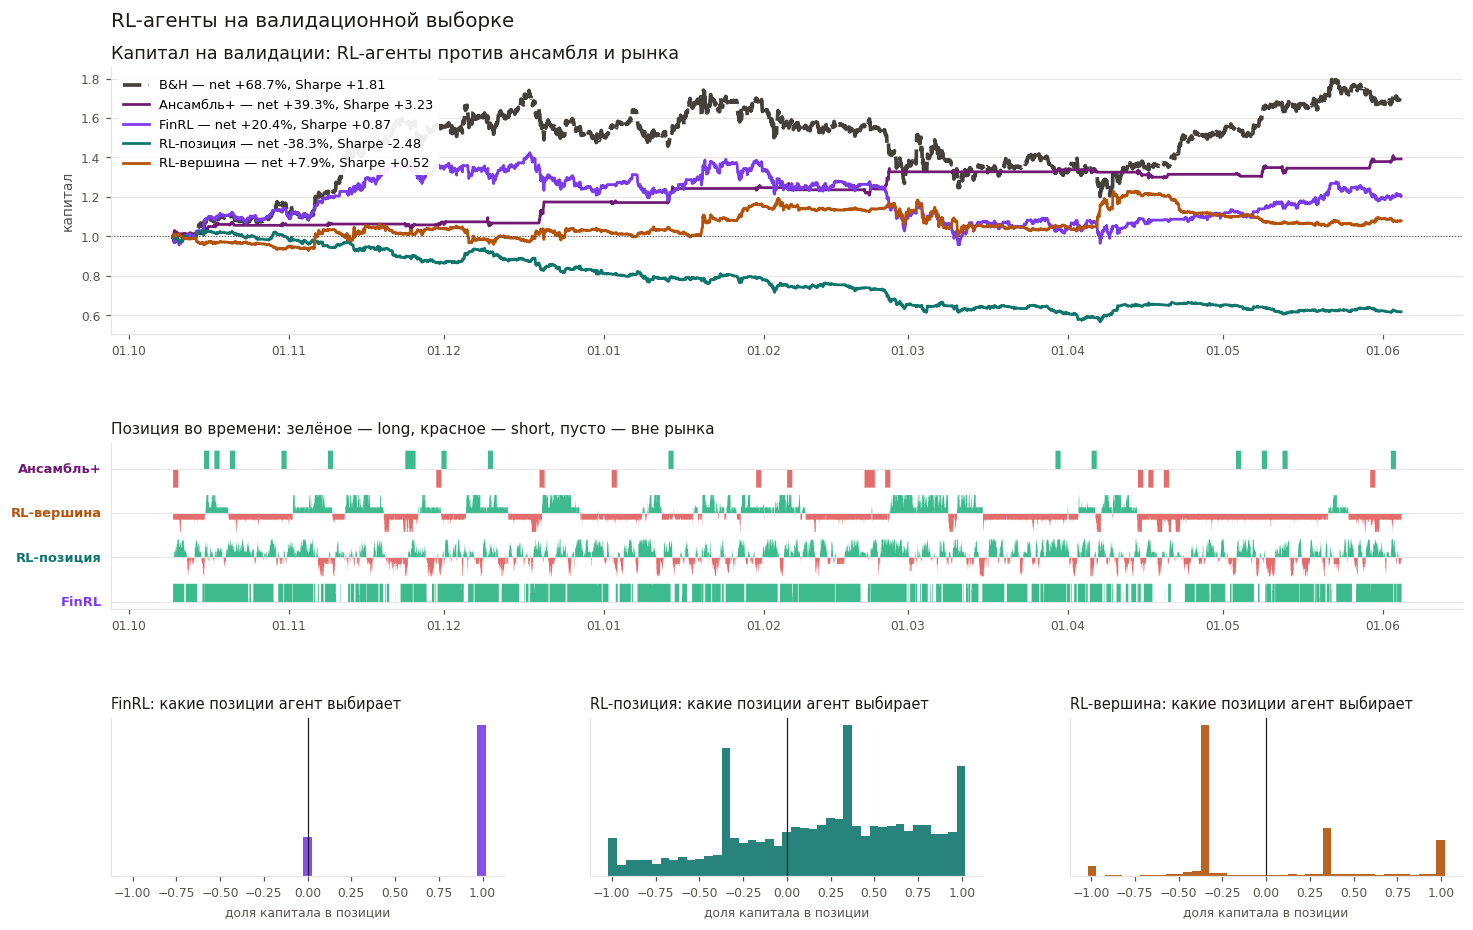

In [71]:
# Как RL-стратегии выглядят рядом с ансамблем: капитал, позиция и распределение действий.
fig = plt.figure(figsize=(13.5, 8.6))
gs = fig.add_gridspec(3, 3, height_ratios=[1.6, 1.0, 0.95], hspace=0.55, wspace=0.22,
                      top=0.925, bottom=0.07, left=0.07, right=0.98)

ax_eq = fig.add_subplot(gs[0, :])
for name in ["BuyAndHold", "EnsembleAll"] + RL_STRATEGIES:
    c = val_curves[name]
    ax_eq.plot(c["date"], c["equity"], color=COLORS[name],
               linewidth=2.4 if name == "BuyAndHold" else 1.8,
               linestyle=STYLES.get(name, "-"),
               label=f"{SHORT[name]} — net {val_comparison.loc[name, 'total_return']:+.1%}, "
                     f"Sharpe {val_comparison.loc[name, 'sharpe']:+.2f}")
ax_eq.axhline(1.0, color=INK_MUTED, linewidth=0.7, linestyle=":")
ax_eq.set_title("Капитал на валидации: RL-агенты против ансамбля и рынка",
                color=INK, fontsize=11.5, loc="left")
ax_eq.set_ylabel("капитал", color=INK_MUTED, fontsize=9)
ax_eq.legend(loc="upper left", fontsize=8.5, frameon=True, framealpha=0.92,
             edgecolor="none", facecolor="white")
ax_eq.xaxis.set_major_formatter(mdates.DateFormatter("%d.%m"))
style_ax(ax_eq)

ax_pos = fig.add_subplot(gs[1, :])
_pos_order = RL_STRATEGIES + ["EnsembleAll"]
for k, name in enumerate(_pos_order):
    pos = val_positions[name]
    ax_pos.fill_between(val_dates, k * 2.4 + np.clip(pos, 0, 1), k * 2.4, color=UP,
                        linewidth=0, alpha=0.85, step="post")
    ax_pos.fill_between(val_dates, k * 2.4 + np.clip(pos, -1, 0), k * 2.4, color=DOWN,
                        linewidth=0, alpha=0.85, step="post")
    ax_pos.axhline(k * 2.4, color=GRID, linewidth=0.7)
    ax_pos.annotate(SHORT[name], xy=(0, k * 2.4), xycoords=("axes fraction", "data"),
                    xytext=(-6, 0), textcoords="offset points", ha="right", va="center",
                    fontsize=8.5, color=COLORS[name], fontweight="bold")
ax_pos.set_yticks([])
ax_pos.set_title("Позиция во времени: зелёное — long, красное — short, пусто — вне рынка",
                 color=INK, fontsize=10, loc="left")
ax_pos.xaxis.set_major_formatter(mdates.DateFormatter("%d.%m"))
style_ax(ax_pos, ygrid=False)

for k, name in enumerate(RL_STRATEGIES):
    ax = fig.add_subplot(gs[2, k])
    ax.hist(val_positions[name], bins=41, range=(-1.02, 1.02), color=COLORS[name], alpha=0.9)
    ax.axvline(0, color=INK, linewidth=0.8)
    ax.set_title(f"{SHORT[name]}: какие позиции агент выбирает",
                 color=INK, fontsize=9.5, loc="left")
    ax.set_xlabel("доля капитала в позиции", color=INK_MUTED, fontsize=8)
    ax.set_yticks([])
    style_ax(ax, ygrid=False)

fig.suptitle("RL-агенты на валидационной выборке", fontsize=13, y=0.985, color=INK,
             x=0.07, ha="left")
plt.show()

Три агента дали один и тот же результат, и он читается со всех трёх таблиц сразу.

**Gross положителен у всех трёх агентов, деньги теряются на обороте.** Gross-доходность на
валидации: FinRL +52.6%, RL-вершина +47.2%, RL-позиция +31.0%. Это тот же порядок, что
у расширенного ансамбля (+47.0%), и заметно выше, чем у отдельных моделей последовательностей
(+8.5…+13.7%).

Но период растущий, и сам по себе положительный gross ещё не значит «агент угадывает направление»:
часть его — это просто длина позиции. Грубая оценка вклада наклона — средняя позиция, умноженная на
доходность рынка (+68.9%), — даёт ≈ +54% у FinRL (экспозиция 0.79, шорта в среде нет), ≈ +14% у
RL-позиции (среднее направление +0.20) и ≈ 0% у RL-вершины (−0.01). То есть весь gross FinRL
объясняется его экспозицией, ничего сверх пассивного удержания он не добавил, а сверх наклона
заработали только RL-позиция (порядка +17 п.п.) и RL-вершина (порядка +47 п.п.) — у них направление
действительно есть, пусть и на одном коротком периоде.

А net-доходность после комиссии — +20.4%, +7.9% и −38.3%: издержки съели
23.7, 31.0 и 75.3 процентных пункта соответственно. У расширенного ансамбля на ту же
gross-доходность приходится 5.4 пункта издержек. Разница здесь не в уровне gross, а в обороте:
237, 310 и 753 единицы капитала против 54 у ансамбля.

**Почему комиссия в награде не спасла.** Награда была честной: `log(1 + pos·r − fee·|Δpos|)`,
каждая сделка сразу стоила агенту денег. Проблема в масштабах. Типичное изменение позиции за бар
у RL-позиции — 0.13 капитала, то есть штраф 0.001 · 0.13 ≈ 1.3·10⁻⁴ за бар. Среднеквадратичная
доходность часового бара — около 6·10⁻³, в сорок с лишним раз больше. Сигнал «торгуй реже» лежит
почти на два порядка ниже шума, в котором оценивается градиент политики, и просто не доходит до
неё за 60 тысяч шагов. Гауссова политика при этом по построению шевелит позицию на каждом баре: ничто в
архитектуре не поощряет удерживать её.

Именно это и делает торговый слой раздела 9, причём явно, а не в надежде, что агент догадается
сам: гистерезис (в зоне неопределённости позиция не меняется), экспоненциальное сглаживание
вероятности, пересмотр позиции раз в k баров и жёсткие ограничения на оборот. Вывод не «RL не
работает», а «в этой постановке ограничение оборота нужно задавать конструкцией среды, а не
ждать, что оно выучится из награды».

**Off-policy алгоритмы переобучаются, и это видно по двум колонкам.** В таблице отбора три
лучших результата на train принадлежат SAC (+2.86), DDPG (+1.43) и TD3 (+0.79) — и все три дают
худшие результаты на test (−3.66, −5.01, −1.51). A2C, единственный с положительным test Sharpe
(+0.50), на train выглядит скромно (+0.67). Разрыв train → test у SAC — 6.5 единицы Sharpe.
Это ровно та причина, по которой выбор алгоритма делался на участке, которого агент не видел.

**RL на вершине ансамбля проиграл простому усреднению.** Честная проверка на test-части dev:
мета-агент даёт Sharpe −2.12 и net −33.0%, а обычный ансамбль с фиксированным торговым слоем на
том же участке — −0.50 и −9.4% (buy & hold там же: +0.84 и +22.1%). Проиграл он при этом не на
направлении: gross у мета-агента +1.4% против −0.8% у ансамбля — обе величины около нуля, и
угадывает он даже чуть лучше. Вся разница в net набегает на обороте: 414 единиц капитала против
90, 2 556 сделок против 86. Причём торговый слой в этом сравнении ещё и в выигрышном положении —
его квантильные пороги посчитаны по самому проверочному участку, — и всё равно выигрывает.
Разброс по сидам у мета-агента (+0.06, −1.86, −1.88) показывает, что дело не в одном
неудачном запуске.

**Агенты не выучили даже обучающую выборку.** Обычно RL-агента подозревают в том, что он
запомнил траекторию; здесь наоборот: на dev, то есть на своих же обучающих данных, FinRL даёт
Sharpe −0.11 и net −52.0%, RL-позиция −2.70 и −94.7%, RL-вершина −0.25 и −35.8%. Ни одна из
трёх постановок не нашла на обучающей выборке даже in-sample прибыльной политики. При отношении
сигнала к шуму порядка 0.01 и 60 тысячах шагов это недообучение, а не переобучение, — и оно
честнее описывает ситуацию, чем привычная жалоба на overfitting.

**Единственное место, где RL смотрится конкурентно, — низкий тариф.** Раздел 20 считает
net-доходность при разных комиссиях, и там картина другая: при maker-тарифе 0.02% FinRL даёт
+45.5% против +45.4% у расширенного ансамбля — ничья, а RL-вершина +38.3%. Точка безубыточности
RL-вершины — 0.1246% за единицу оборота, то есть **выше** заложенных в ноутбуке 0.1%; у FinRL
edge не исчезает на всей сетке до 0.15%. Иначе говоря, оборот агентов не бессмыслен — он просто
дороже, чем приносит, при тарифе 0.1%. На инфраструктуре с maker-комиссией вывод раздела был бы
менее однозначным.

**Метрики классификации у RL низкие, и это ожидаемо.** ROC-AUC по нормированной позиции —
0.5102, 0.5086 и 0.5157 против 0.5482 у расширенного ансамбля. Агент и не оптимизировал
ранжирование: он выбирал размер позиции, а не вероятность роста. Эти колонки в таблице стоят
ради единообразия, а не потому, что по ним стоит судить.

## 20. Чувствительность к издержкам и точка безубыточности

Итоговый вывод целиком зависит от заложенной комиссии. Если у стратегии положительная
gross-доходность, существует **пороговый уровень издержек (break-even fee)**, ниже которого
она прибыльна. Этот порог информативнее net-доходности при одном произвольном тарифе: он
говорит, на какой инфраструктуре стратегия имела бы смысл.

Для справки: taker-комиссия на BTC-перпетуалах крупных бирж — 0.04–0.055% за сторону,
maker — 0.01–0.02%, то есть ниже заложенных нами 0.1%.

In [72]:
FEE_GRID = np.linspace(0.0, 0.0015, 61)
sensitivity = pd.DataFrame(
    {name: [backtest(val_dates, val_fwd, pos, fee_rate=f)[1]["total_return"] for f in FEE_GRID]
     for name, pos in val_positions.items()}, index=FEE_GRID)

break_even = {}
for name, pos in val_positions.items():
    f = lambda fee: backtest(val_dates, val_fwd, pos, fee_rate=fee)[1]["total_return"]
    if f(0.0) <= 0:
        break_even[name] = np.nan                      # edge нет даже при нулевых издержках
    elif f(FEE_GRID[-1]) > 0:
        break_even[name] = np.inf                      # прибыльна на всей сетке
    else:
        break_even[name] = brentq(f, 0.0, FEE_GRID[-1])

be = pd.DataFrame({
    "gross (fee=0)": [sensitivity[n].iloc[0] for n in val_positions],
    "break_even_fee": [break_even[n] for n in val_positions],
    "net при 0.10%": [val_comparison.loc[n, "total_return"] for n in val_positions],
    "оборот": [val_comparison.loc[n, "turnover_units"] for n in val_positions],
}, index=list(val_positions)).rename_axis("strategy")
display(be.round(6))

scenario = pd.DataFrame({
    label: {name: backtest(val_dates, val_fwd, pos, fee_rate=fee)[1]["total_return"]
            for name, pos in val_positions.items()}
    for label, fee in FEE_SCENARIOS.items()})
print("Net-доходность на валидации при разных тарифах:")
display(scenario.map(lambda vv: f"{vv:+.2%}"))

for nm, vv in break_even.items():
    if np.isnan(vv):
        print(f"{nm:20s}: edge отсутствует даже при нулевых издержках")
    elif np.isinf(vv):
        print(f"{nm:20s}: прибыльна на всём диапазоне сетки")
    else:
        print(f"{nm:20s}: безубыточна при комиссии < {vv * 100:.4f}% за единицу оборота "
              f"({'выше' if vv > FEE_RATE else 'ниже'} заложенных {FEE_RATE * 100:.2f}%)")

,gross (fee=0),break_even_fee,net при 0.10%,оборот
strategy,,,,
BuyAndHold,0.688534,inf,0.686840,1.000000
HW2_Baseline,1.928874,0.000263,-0.950712,4081.000000
TA_AlwaysIn,1.779767,0.000267,-0.939553,3825.000000
LogisticRegression,0.026231,0.000262,-0.070504,99.000000
DecisionTree,0.238342,inf,0.108197,111.000000
CatBoost,0.416039,inf,0.340165,55.000000
Ensemble,0.737550,inf,0.735823,1.000000
TimesNet,0.085167,inf,0.042564,40.000000
TSMixer,0.136936,inf,0.090151,42.000000


Net-доходность на валидации при разных тарифах:


,0.10% (ДЗ №2),0.05% (taker),0.02% (maker),0.00% (без издержек)
BuyAndHold,+68.68%,+68.77%,+68.82%,+68.85%
HW2_Baseline,-95.07%,-61.97%,+29.48%,+192.89%
TA_AlwaysIn,-93.96%,-58.97%,+29.34%,+177.98%
LogisticRegression,-7.05%,-2.33%,+0.61%,+2.62%
DecisionTree,+10.82%,+17.15%,+21.12%,+23.83%
CatBoost,+34.02%,+37.76%,+40.05%,+41.60%
Ensemble,+73.58%,+73.67%,+73.72%,+73.76%
TimesNet,+4.26%,+6.37%,+7.65%,+8.52%
TSMixer,+9.02%,+11.33%,+12.74%,+13.69%
TimesFM,+5.76%,+9.37%,+11.59%,+13.10%


BuyAndHold          : прибыльна на всём диапазоне сетки
HW2_Baseline        : безубыточна при комиссии < 0.0263% за единицу оборота (ниже заложенных 0.10%)
TA_AlwaysIn         : безубыточна при комиссии < 0.0267% за единицу оборота (ниже заложенных 0.10%)
LogisticRegression  : безубыточна при комиссии < 0.0262% за единицу оборота (ниже заложенных 0.10%)
DecisionTree        : прибыльна на всём диапазоне сетки
CatBoost            : прибыльна на всём диапазоне сетки
Ensemble            : прибыльна на всём диапазоне сетки
TimesNet            : прибыльна на всём диапазоне сетки
TSMixer             : прибыльна на всём диапазоне сетки
TimesFM             : прибыльна на всём диапазоне сетки
EnsembleAll         : прибыльна на всём диапазоне сетки
FinRL               : прибыльна на всём диапазоне сетки
RL_Position         : безубыточна при комиссии < 0.0359% за единицу оборота (ниже заложенных 0.10%)
RL_Ensemble         : безубыточна при комиссии < 0.1246% за единицу оборота (выше заложенных 0.1

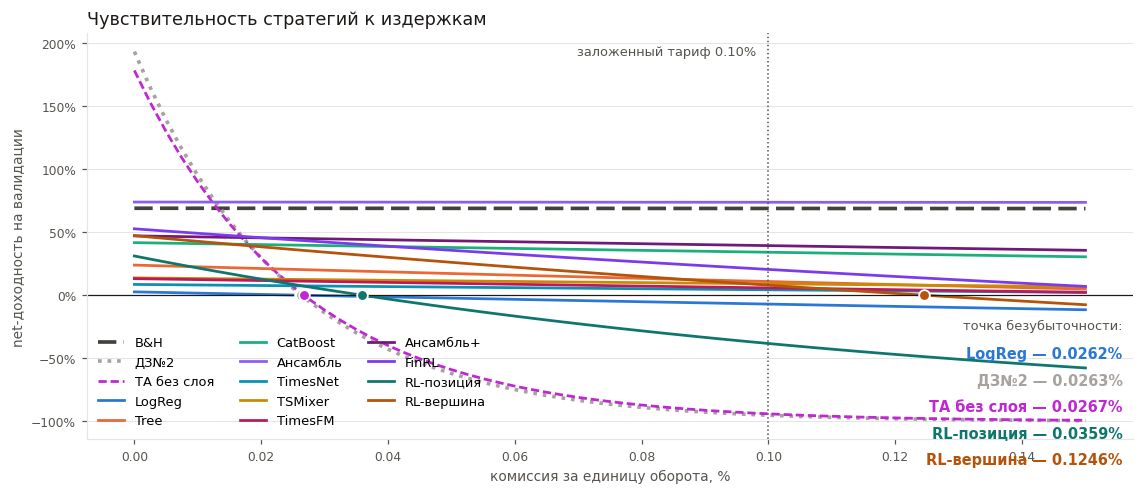

In [73]:
fig, ax = plt.subplots(figsize=(10.5, 4.6))
for name in sensitivity.columns:
    ax.plot(sensitivity.index * 100, sensitivity[name], color=COLORS[name],
            linewidth=2.4 if name in ("BuyAndHold", "HW2_Baseline") else 1.8,
            linestyle=STYLES.get(name, "-"), label=SHORT[name])
ax.axhline(0, color=INK, linewidth=0.8)
ax.axvline(FEE_RATE * 100, color=INK_MUTED, linewidth=1.0, linestyle=":")
ax.annotate(f"заложенный тариф {FEE_RATE * 100:.2f}%", xy=(FEE_RATE * 100, 0.97),
            xycoords=("data", "axes fraction"), xytext=(-8, 0), textcoords="offset points",
            ha="right", va="top", fontsize=8.5, color=INK_MUTED)
finite_be = sorted([(nm, vv) for nm, vv in break_even.items() if np.isfinite(vv) and vv > 0],
                   key=lambda t: t[1])
for nm, vv in finite_be:
    ax.plot([vv * 100], [0], marker="o", markersize=7, color=COLORS[nm],
            markeredgecolor="white", markeredgewidth=1.2, zorder=5)
ax.text(0.99, 0.28, "точка безубыточности:", transform=ax.transAxes, ha="right", va="center",
        fontsize=8.5, color=INK_MUTED)
for k, (nm, vv) in enumerate(finite_be):
    ax.text(0.99, 0.21 - k * 0.065, f"{SHORT[nm]} — {vv * 100:.4f}%", transform=ax.transAxes,
            ha="right", va="center", fontsize=9.5, color=COLORS[nm], fontweight="bold")
ax.set_xlabel("комиссия за единицу оборота, %", color=INK_MUTED, fontsize=9)
ax.set_ylabel("net-доходность на валидации", color=INK_MUTED, fontsize=9)
ax.set_title("Чувствительность стратегий к издержкам", color=INK, fontsize=11.5, loc="left")
ax.yaxis.set_major_formatter(PercentFormatter(xmax=1, decimals=0))
ax.legend(frameon=False, fontsize=8.5, loc="lower left", ncol=3)
style_ax(ax)
fig.tight_layout()
plt.show()

## 21. Важность признаков

CatBoost показывает, на какие признаки он реально опирается. Важности агрегируются и по
отдельным признакам, и по группам — второе устойчивее, потому что близкие индикаторы делят
важность между собой.

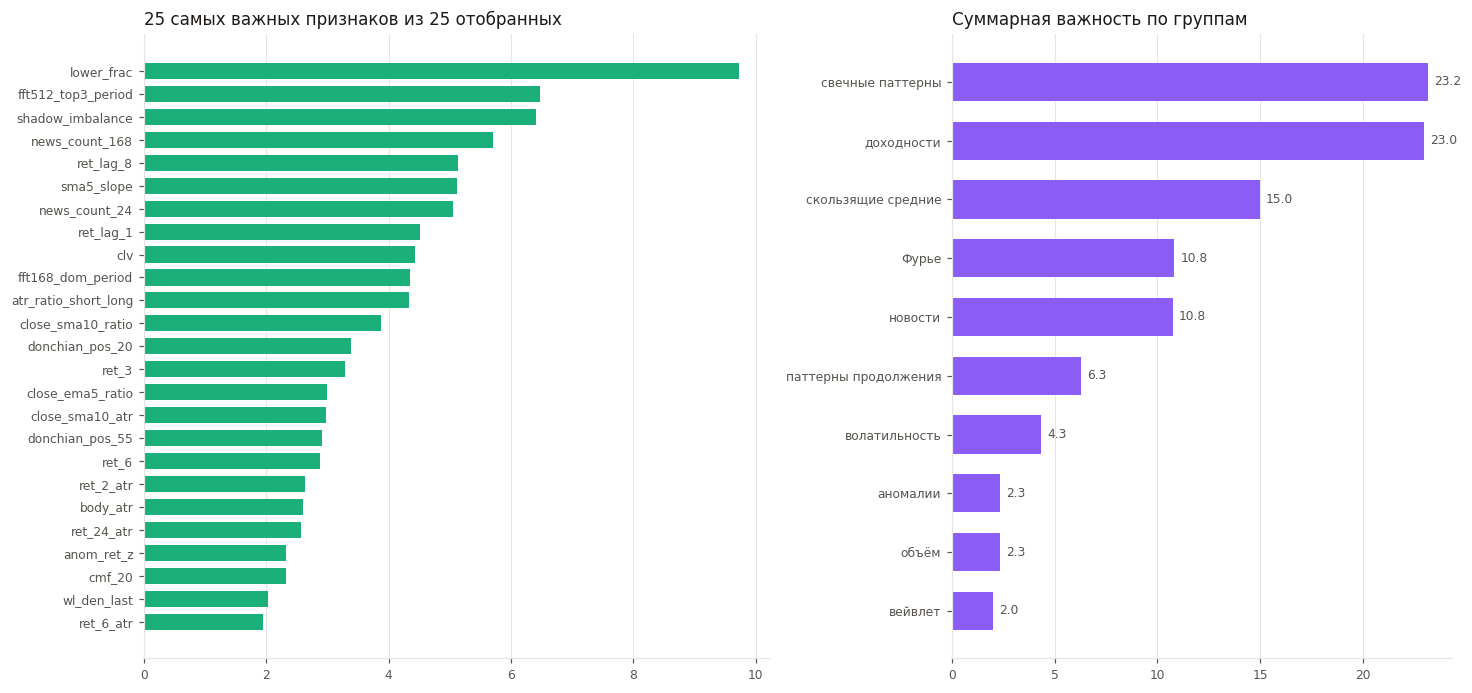

Ни одного признака вида cdl_* или pat_* в отобранном наборе нет: отбор из раздела 12.2 не пропустил ни один флаг распознанной фигуры.
От группы «свечные паттерны» остались только геометрические характеристики бара: lower_frac, clv, body_atr, shadow_imbalance.
Это согласуется с выводом ноутбука дз №5: работает не отдельный паттерн-сигнал, а форма и плотность баров.


In [74]:
imp = pd.Series(final_models["CatBoost"].get_feature_importance(), index=MODEL_COLS)
group_of = {c: g for g, cols in FEATURE_GROUPS.items() for c in cols}
imp_by_group = imp.groupby(imp.index.map(group_of)).sum().sort_values()

fig, axes = plt.subplots(1, 2, figsize=(13.5, 6.4), gridspec_kw={"width_ratios": [1.25, 1]})
top_imp = imp.sort_values().tail(25)
axes[0].barh(np.arange(len(top_imp)), top_imp.to_numpy(), color=COLORS["CatBoost"], height=0.7)
axes[0].set_yticks(np.arange(len(top_imp)))
axes[0].set_yticklabels(top_imp.index, fontsize=8)
axes[0].set_title(f"{len(top_imp)} самых важных признаков из {len(MODEL_COLS)} отобранных",
                  color=INK, loc="left", fontsize=11)
style_ax(axes[0], ygrid=False, xgrid=True)

axes[1].barh(np.arange(len(imp_by_group)), imp_by_group.to_numpy(),
             color=COLORS["Ensemble"], height=0.65)
axes[1].set_yticks(np.arange(len(imp_by_group)))
axes[1].set_yticklabels(imp_by_group.index, fontsize=9)
axes[1].set_title("Суммарная важность по группам", color=INK, loc="left", fontsize=11)
for yi, vv in enumerate(imp_by_group.to_numpy()):
    axes[1].annotate(f"{vv:.1f}", xy=(vv, yi), xytext=(4, 0), textcoords="offset points",
                     va="center", fontsize=8, color=INK_MUTED)
style_ax(axes[1], ygrid=False, xgrid=True)
fig.tight_layout()
plt.show()

pattern_cols = [c for c in MODEL_COLS if c.startswith(("cdl_", "pat_"))]
if pattern_cols:
    top_patterns = imp[pattern_cols].sort_values(ascending=False)
    print("Самые важные паттерны технического анализа:")
    display(pd.DataFrame({
        "паттерн": [CANDLE_RU.get(c, PATTERN_RU.get(c.replace("_24", ""), c))
                    for c in top_patterns.head(12).index],
        "важность": top_patterns.head(12).round(3).to_numpy(),
    }, index=top_patterns.head(12).index))
else:
    cdl_left = [c for c in MODEL_COLS if group_of.get(c) == "свечные паттерны"]
    print("Ни одного признака вида cdl_* или pat_* в отобранном наборе нет: отбор из "
          "раздела 12.2 не пропустил ни один флаг распознанной фигуры.")
    print(f"От группы «свечные паттерны» остались только геометрические характеристики бара: "
          f"{', '.join(cdl_left) if cdl_left else '—'}.")
    print("Это согласуется с выводом ноутбука дз №5: работает не отдельный паттерн-сигнал, "
          "а форма и плотность баров.")

## 22. Дашборд эффективности стратегий во времени

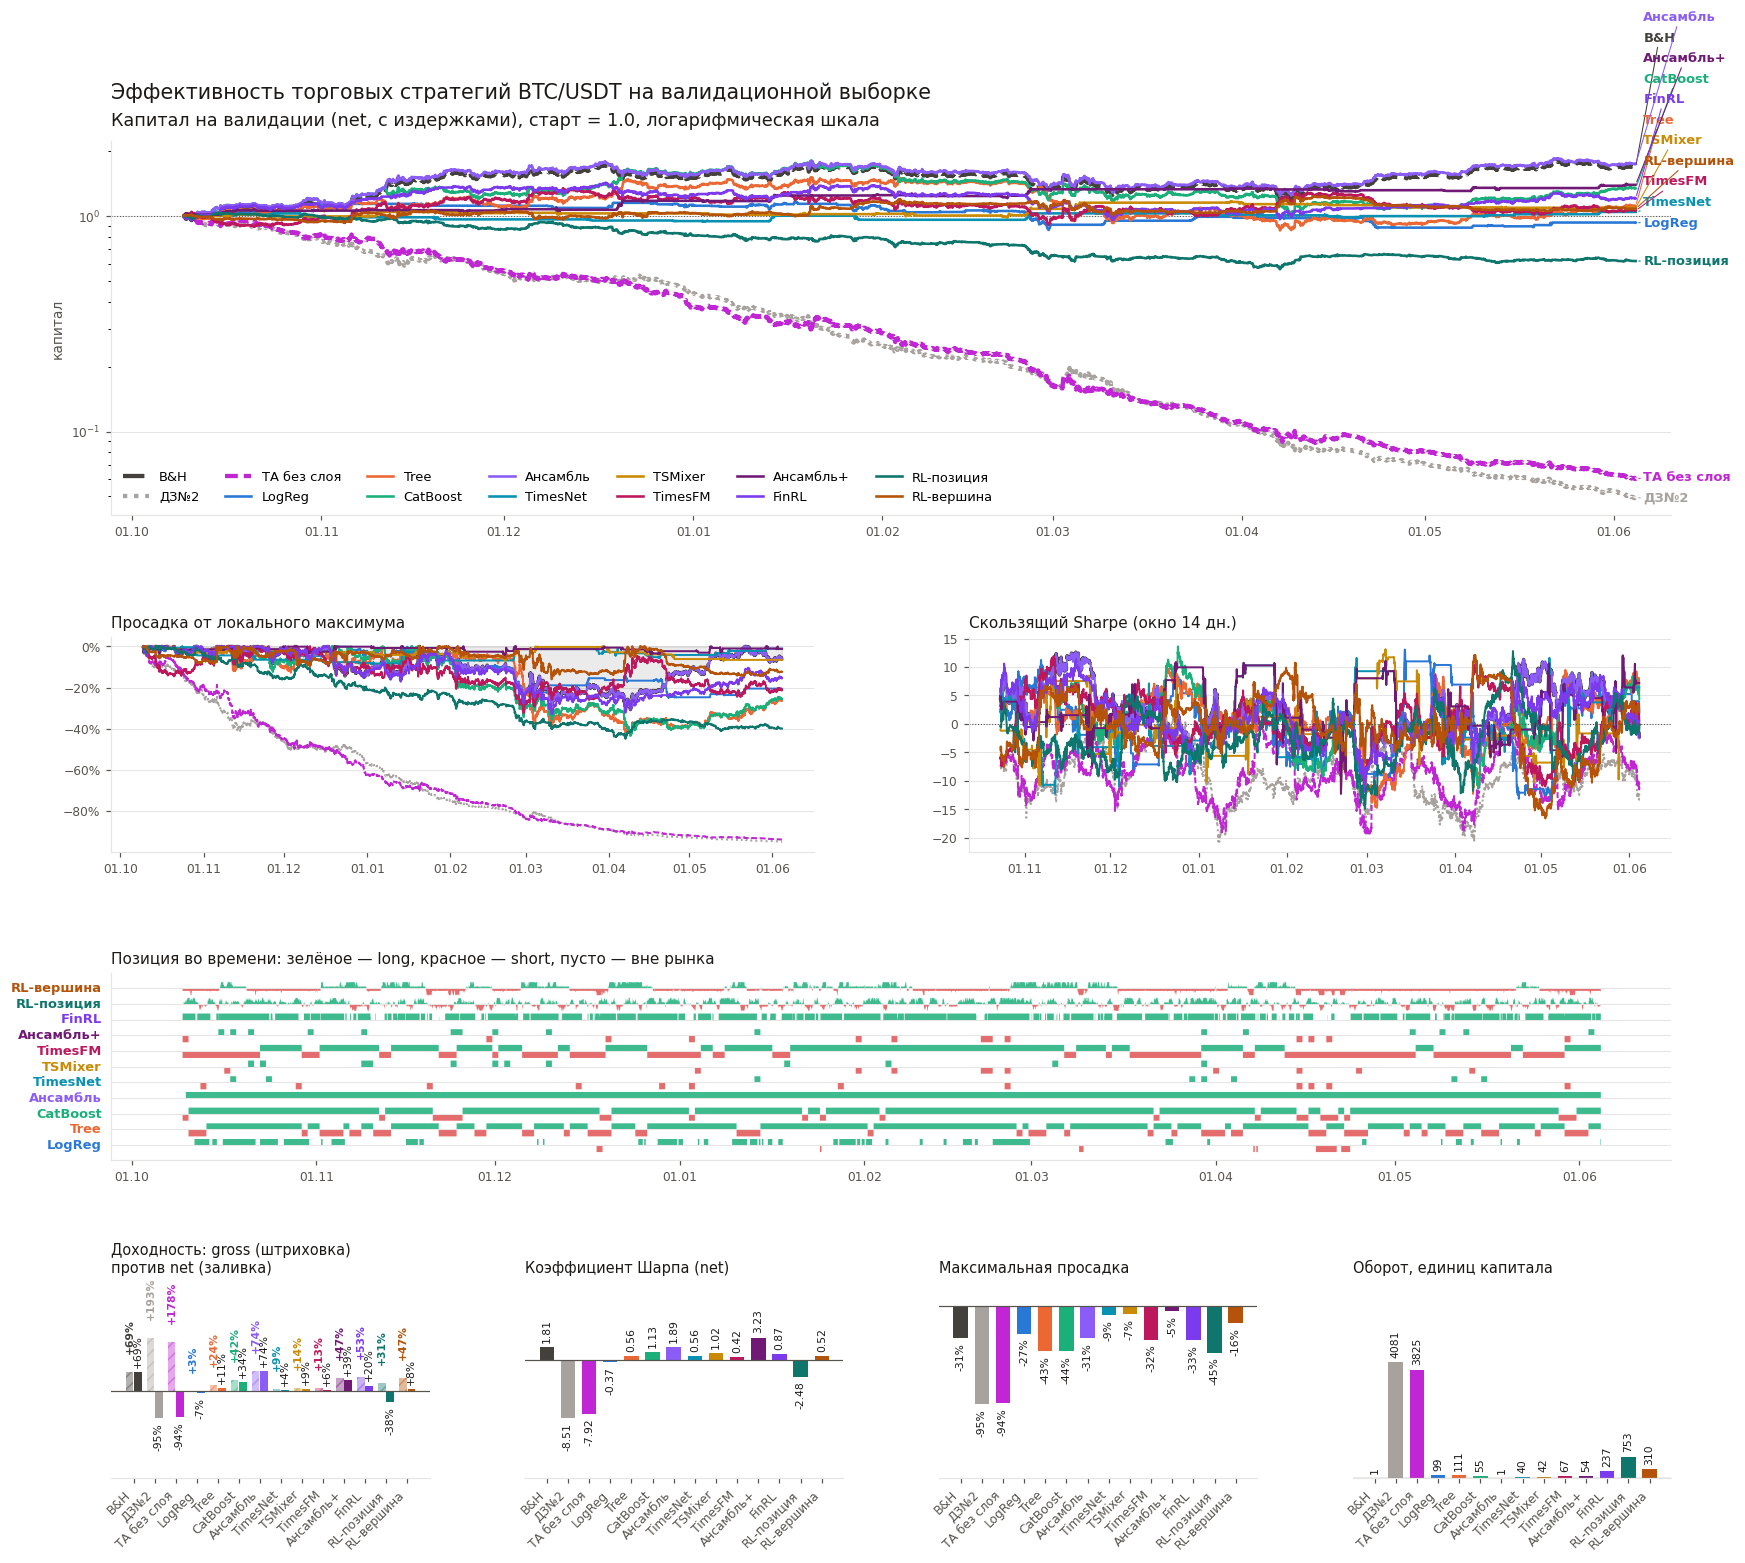

In [75]:
def declutter(pairs, min_gap):
    """Раздвигает подписи по вертикали, чтобы они не накладывались."""
    out, prev = {}, None
    for name, y in sorted(pairs, key=lambda t: t[1]):
        if prev is not None and y - prev < min_gap:
            y = prev + min_gap
        out[name], prev = y, y
    return out


fig = plt.figure(figsize=(15.5, 13.5))
gs = fig.add_gridspec(4, 2, height_ratios=[2.0, 1.15, 1.0, 1.05], hspace=0.5, wspace=0.22,
                      top=0.945, bottom=0.045, left=0.06, right=0.975)

# ── 1. кривые капитала (net) ────────────────────────────────────────────────
ax_eq = fig.add_subplot(gs[0, :])
for name in strategies:
    curve = val_curves[name]
    bench = name in ("BuyAndHold", "HW2_Baseline", "TA_AlwaysIn")
    ax_eq.plot(curve["date"], curve["equity"], color=COLORS[name],
               linewidth=2.8 if bench else 1.7, linestyle=STYLES.get(name, "-"),
               zorder=2 if bench else 3, label=SHORT[name])
ax_eq.axhline(1.0, color=INK_MUTED, linewidth=0.7, linestyle=":", zorder=1)
ax_eq.set_yscale("log")
last_x = val_curves["BuyAndHold"]["date"].iloc[-1]
ax_eq.set_xlim(right=last_x + pd.Timedelta(hours=140))
lo_y, hi_y = ax_eq.get_ylim()
span_log = np.log10(hi_y) - np.log10(lo_y)
ends = declutter([(nm, float(np.log10(max(val_curves[nm]["equity"].iloc[-1], 1e-6))))
                  for nm in strategies], span_log * 0.055)
for name in strategies:
    y_true = float(val_curves[name]["equity"].iloc[-1])
    ax_eq.annotate(SHORT[name], xy=(last_x, max(y_true, 1e-6)),
                   xytext=(last_x + pd.Timedelta(hours=30), 10 ** ends[name]), textcoords="data",
                   va="center", fontsize=8.5, color=COLORS[name], fontweight="bold",
                   annotation_clip=False,
                   arrowprops=dict(arrowstyle="-", color=COLORS[name], linewidth=0.7,
                                   shrinkA=0, shrinkB=2))
ax_eq.set_title("Капитал на валидации (net, с издержками), старт = 1.0, логарифмическая шкала",
                color=INK, fontsize=11.5, loc="left", pad=10)
ax_eq.set_ylabel("капитал", color=INK_MUTED, fontsize=9)
ax_eq.legend(loc="lower left", frameon=False, fontsize=8.5, ncol=7)
ax_eq.xaxis.set_major_formatter(mdates.DateFormatter("%d.%m"))
style_ax(ax_eq)

# ── 2. просадка ─────────────────────────────────────────────────────────────
ax_dd = fig.add_subplot(gs[1, 0])
ax_dd.fill_between(val_curves["BuyAndHold"]["date"], val_curves["BuyAndHold"]["drawdown"], 0,
                   color=COLORS["BuyAndHold"], alpha=0.10, zorder=1)
for name in strategies:
    curve = val_curves[name]
    ax_dd.plot(curve["date"], curve["drawdown"], color=COLORS[name],
               linewidth=2.2 if name == "BuyAndHold" else 1.3,
               linestyle=STYLES.get(name, "-"), zorder=2)
ax_dd.set_title("Просадка от локального максимума", color=INK, fontsize=10, loc="left")
ax_dd.yaxis.set_major_formatter(PercentFormatter(xmax=1, decimals=0))
ax_dd.xaxis.set_major_formatter(mdates.DateFormatter("%d.%m"))
style_ax(ax_dd)

# ── 3. скользящий Sharpe ────────────────────────────────────────────────────
ax_roll = fig.add_subplot(gs[1, 1])
window = 24 * 14
for name in strategies:
    curve = val_curves[name]
    r = curve["strategy_return"]
    roll = (r.rolling(window).mean() / r.rolling(window).std()) * np.sqrt(PERIODS_PER_YEAR)
    ax_roll.plot(curve["date"], roll, color=COLORS[name],
                 linewidth=2.2 if name == "BuyAndHold" else 1.3, linestyle=STYLES.get(name, "-"))
ax_roll.axhline(0.0, color=INK_MUTED, linewidth=0.7, linestyle=":")
ax_roll.set_title(f"Скользящий Sharpe (окно {window // 24} дн.)", color=INK, fontsize=10, loc="left")
ax_roll.xaxis.set_major_formatter(mdates.DateFormatter("%d.%m"))
style_ax(ax_roll)

# ── 4. позиция во времени: видно, как работает торговый слой ────────────────
ax_pos = fig.add_subplot(gs[2, :])
show_pos = [nm for nm in strategies if nm not in ("BuyAndHold", "HW2_Baseline", "TA_AlwaysIn")]
for k, name in enumerate(show_pos):
    pos = val_positions[name]
    ax_pos.fill_between(val_dates, k * 2.4 + np.clip(pos, 0, 1), k * 2.4,
                        color=UP, linewidth=0, alpha=0.85, step="post")
    ax_pos.fill_between(val_dates, k * 2.4 + np.clip(pos, -1, 0), k * 2.4,
                        color=DOWN, linewidth=0, alpha=0.85, step="post")
    ax_pos.axhline(k * 2.4, color=GRID, linewidth=0.7)
    ax_pos.annotate(SHORT[name], xy=(0, k * 2.4), xycoords=("axes fraction", "data"),
                    xytext=(-6, 0), textcoords="offset points", ha="right", va="center",
                    fontsize=8.5, color=COLORS[name], fontweight="bold")
ax_pos.set_yticks([])
ax_pos.set_title("Позиция во времени: зелёное — long, красное — short, пусто — вне рынка",
                 color=INK, fontsize=10, loc="left")
ax_pos.xaxis.set_major_formatter(mdates.DateFormatter("%d.%m"))
style_ax(ax_pos, ygrid=False)

# ── 5. сводные метрики: у каждой своя шкала ─────────────────────────────────
inner = gs[3, :].subgridspec(1, 4, wspace=0.3)
x = np.arange(len(strategies))


def frame(ax, values, title):
    ax.axhline(0, color=INK_MUTED, linewidth=0.8)
    ax.set_xticks(x)
    ax.set_xticklabels([SHORT[nm] for nm in strategies], rotation=45, ha="right", fontsize=7)
    ax.set_title(title, color=INK, fontsize=9.5, loc="left")
    lo, hi = min(list(values) + [0]), max(list(values) + [0])
    rng = (hi - lo) or 1
    # запас сверху и снизу рассчитан на вертикальные подписи значений (см. kpi_panel)
    ax.set_ylim(lo - (rng * 0.75 if lo < 0 else 0), hi + (rng * 0.70 if hi > 0 else rng * 0.25))
    for s in ("top", "right", "left"):
        ax.spines[s].set_visible(False)
    ax.spines["bottom"].set_color(GRID)
    ax.tick_params(colors=INK_MUTED, labelsize=8)
    ax.set_yticks([])


def kpi_panel(ax, values, title, fmt):
    """Подписи значений вертикальные: на четырнадцати столбиках горизонтальные
    подписи соседей слипаются в нечитаемую строку («237753284» вместо «237 753 284»)."""
    for xi, (name, vv) in enumerate(zip(strategies, values)):
        ax.bar(xi, vv, width=0.68, color=COLORS[name])
        ax.annotate(fmt(vv), xy=(xi, vv), xytext=(0, 3 if vv >= 0 else -3),
                    textcoords="offset points", ha="center",
                    va="bottom" if vv >= 0 else "top", fontsize=7, color=INK,
                    rotation=90)
    frame(ax, values, title)


ax_ret = fig.add_subplot(inner[0, 0])
gross = [val_comparison.loc[nm, "gross_return"] for nm in strategies]
net = [val_comparison.loc[nm, "total_return"] for nm in strategies]
for xi, name in enumerate(strategies):
    ax_ret.bar(xi - 0.20, gross[xi], width=0.36, color=COLORS[name], alpha=0.40,
               hatch="///", edgecolor=COLORS[name], linewidth=0)
    ax_ret.bar(xi + 0.20, net[xi], width=0.36, color=COLORS[name])
    # gross подписывается выше net, иначе у близких значений подписи сливаются
    ax_ret.annotate(f"{gross[xi]:+.0%}", xy=(xi - 0.20, gross[xi]),
                    xytext=(0, 12 if gross[xi] >= 0 else -12), textcoords="offset points",
                    ha="center", va="bottom" if gross[xi] >= 0 else "top",
                    fontsize=7, color=COLORS[name], fontweight="bold", rotation=90)
    ax_ret.annotate(f"{net[xi]:+.0%}", xy=(xi + 0.20, net[xi]),
                    xytext=(0, 3 if net[xi] >= 0 else -3), textcoords="offset points",
                    ha="center", va="bottom" if net[xi] >= 0 else "top",
                    fontsize=7, color=INK, rotation=90)
frame(ax_ret, gross + net, "Доходность: gross (штриховка)\nпротив net (заливка)")

kpi_panel(fig.add_subplot(inner[0, 1]), [val_comparison.loc[nm, "sharpe"] for nm in strategies],
          "Коэффициент Шарпа (net)", lambda vv: f"{vv:.2f}")
kpi_panel(fig.add_subplot(inner[0, 2]), [val_comparison.loc[nm, "max_drawdown"] for nm in strategies],
          "Максимальная просадка", lambda vv: f"{vv:.0%}")
kpi_panel(fig.add_subplot(inner[0, 3]), [val_comparison.loc[nm, "turnover_units"] for nm in strategies],
          "Оборот, единиц капитала", lambda vv: f"{vv:.0f}")

fig.suptitle("Эффективность торговых стратегий BTC/USDT на валидационной выборке",
             fontsize=13.5, y=0.985, color=INK, x=0.06, ha="left")
plt.show()

In [76]:
# Итоговая сводка: ДЗ №2 против нынешнего конвейера.
tabular_names = list(final_models) + ["Ensemble"]
best_new = val_comparison.loc[tabular_names, "sharpe"].idxmax()
best_seq = val_comparison.loc[SEQ_MODELS, "sharpe"].idxmax()
best_rl = val_comparison.loc[RL_STRATEGIES, "sharpe"].idxmax()
summary_cols = {
    "Buy & Hold": "BuyAndHold",
    "ДЗ №2: лаги + всегда в рынке": "HW2_Baseline",
    "ТА, но всегда в рынке": "TA_AlwaysIn",
    f"ТА + торговый слой ({SHORT[best_new]})": best_new,
    f"Лучшая стратегия раздела 17 ({SHORT[best_seq]})": best_seq,
    f"Лучший RL-агент ({SHORT[best_rl]})": best_rl,
    "RL на вершине ансамбля": "RL_Ensemble",
}
summary_final = pd.DataFrame(
    {label: val_comparison.loc[nm] for label, nm in summary_cols.items()}
).loc[["roc_auc", "pr_auc", "gross_return", "fee_drag", "total_return", "sharpe",
       "max_drawdown", "n_trades", "turnover_units", "time_in_market"]]
summary_final.loc["break_even_fee"] = [break_even[nm] for nm in summary_cols.values()]
display(summary_final.round(4))

,Buy & Hold,ДЗ №2: лаги + всегда в рынке,"ТА, но всегда в рынке",ТА + торговый слой (Ансамбль),Лучшая стратегия раздела 17 (Ансамбль+),Лучший RL-агент (FinRL),RL на вершине ансамбля
roc_auc,0.5000,0.5459,0.5505,0.5133,0.5482,0.5102,0.5157
pr_auc,0.5095,0.5546,0.5530,0.5269,0.5570,0.5160,0.5211
gross_return,0.6885,1.9289,1.7798,0.7376,0.4698,0.5258,0.4715
fee_drag,0.0010,4.0810,3.8250,0.0010,0.0540,0.2369,0.3100
total_return,0.6868,-0.9507,-0.9396,0.7358,0.3925,0.2040,0.0792
sharpe,1.8073,-8.5063,-7.9226,1.8938,3.2263,0.8677,0.5220
max_drawdown,-0.3098,-0.9513,-0.9401,-0.3098,-0.0476,-0.3286,-0.1603
n_trades,1.0000,2041.0000,1913.0000,1.0000,53.0000,291.0000,2040.0000
turnover_units,1.0000,4081.0000,3825.0000,1.0000,54.0000,236.9059,309.9670
time_in_market,1.0000,1.0000,1.0000,0.9977,0.1218,0.7976,0.9986


## 23. Выводы

Ноутбук доводит конвейер ДЗ №3–№6 до финального вида и добавляет к нему обучение с
подкреплением: три постановки RL на FinRL и Stable-Baselines3, включая агента, поставленного
**на вершину ансамбля** из шести моделей. Всё остальное — признаки, разбиение, кросс-валидация,
бэктест, комиссия 0.1% и метрики — осталось прежним, поэтому RL сравнивается с предыдущими
стратегиями напрямую, без пересчётов.

### Короткий ответ

**RL сопоставим с supervised-конвейером по gross и проигрывает ему на издержках.**
Gross-доходность на валидации положительна у всех трёх агентов — +52.6% (FinRL), +47.2%
(RL на вершине ансамбля), +31.0% (RL-позиция), — что сопоставимо с +47.0% у расширенного
ансамбля. Net после комиссии — +20.4%, +7.9% и −38.3%: комиссии съели 23.7, 31.0 и 75.3
процентных пункта против 5.4 пункта у ансамбля. Разница целиком в обороте: 237, 310 и 753
единицы капитала против 54.

Оговорка к слову «находит»: период растущий, и положительный gross сам по себе ещё не признак
прогноза. Пассивная оценка наклона (средняя позиция × +68.9% рынка) даёт ≈ +54% для FinRL,
≈ +14% для RL-позиции и ≈ 0% для RL-вершины — то есть у FinRL gross ровно пассивный, а сверх
наклона зарабатывают только два других агента.

**Комиссия внутри награды оборот не удержала — и понятно, почему.** Штраф за типичную сделку
агента (0.001 · 0.13 ≈ 1.3·10⁻⁴ за бар) почти на два порядка меньше шума доходности часового
бара (≈ 6·10⁻³). Сигнал «торгуй реже» тонет в шуме, в котором оценивается градиент политики. То, что
торговый слой раздела 9 задаёт конструкцией — гистерезис, сглаживание, ограничения на оборот, —
агент из награды за 60 тысяч шагов не выучивает.

**RL на вершине ансамбля не превзошёл простое усреднение вероятностей.** На честной проверке
(обучение на train-части dev, оценка на test-части) мета-агент даёт Sharpe −2.12 и net −33.0%
против −0.50 и −9.4% у обычного ансамбля с фиксированным торговым слоем — при том, что пороги
слоя в этом сравнении считались по самому проверочному участку, то есть в его пользу.

**Всё меняет тариф.** При maker-комиссии 0.02% FinRL даёт +45.5% против +45.4% у расширенного
ансамбля — ничья; точка безубыточности RL на вершине ансамбля — 0.1246% за единицу оборота,
выше заложенных в ноутбуке 0.1%. Оборот агентов не бессмыслен, он просто дороже, чем приносит,
на розничном тарифе.

**Ни один агент не стал прибыльным даже на обучающей выборке** (dev Sharpe −0.11, −2.70, −0.25).
Это недообучение, а не переобучение: при отношении сигнала к шуму порядка 0.01 десятки тысяч
шагов — слишком мало.

**По новостям (вторая часть работы) выводы не изменились:** из 24 новостных признаков отбор
пережили два счётчика потока, качество прогноза не выросло, а выигрыш в деньгах на валидации
объясняется более длинной средней позицией на растущем периоде, а не предсказательным
преимуществом. Подробности — в части II.

## Часть I. Обучение с подкреплением

### 1. Три постановки и что из них вышло

| постановка | среда | действие | алгоритм | gross | net | Sharpe | оборот |
|---|---|---|---|---|---|---|---|
| 19.1 FinRL «как есть» | `StockTradingEnv` | целые лоты, только long | A2C (выбран по test) | +52.6% | **+20.4%** | 0.87 | 237 |
| 19.2 позиционная среда | своя `gymnasium`-среда | доля капитала в [−1, +1] | PPO, 3 сида | +31.0% | −38.3% | −2.48 | 753 |
| 19.3 RL на вершине ансамбля | та же среда, наблюдение — прогнозы 6 моделей | доля капитала | PPO, 3 сида | +47.2% | +7.9% | 0.52 | 310 |
| для сравнения: ансамбль всех шести | — | торговый слой | — | +47.0% | **+39.3%** | **3.23** | **54** |
| для сравнения: buy & hold | — | — | — | +68.9% | +68.7% | 1.81 | 1 |

Отбор алгоритма в 19.1 сам по себе поучителен. Три лучших результата на обучающем участке
принадлежат off-policy методам — SAC (+2.86), DDPG (+1.43), TD3 (+0.79) — и все три дают худшие
результаты на участке, которого агент не видел: −3.66, −5.01, −1.51. Разрыв train → test у SAC —
6.5 единицы Sharpe. Победил A2C с самым скромным train-результатом (+0.67) и единственным
положительным test-результатом (+0.50). Если бы алгоритм выбирался по обучающей выборке —
как это часто делают в примерах к фреймворкам, — в финал ушёл бы SAC, и раздел закончился бы
net −55%.

Разброс по сидам сопоставим с разбросом по алгоритмам: у PPO в позиционной среде отдельные
запуски дают test Sharpe −0.01, −0.32 и −2.87, у мета-агента — +0.06, −1.86, −1.88. Одиночный
запуск RL в этой задаче не является результатом; все цифры выше — средние по трём сидам
(усреднение позиций, то есть ансамбль агентов).

### 2. Почему RL проиграл: оборот, а не направление

Таблица выше распадается на две колонки, и они говорят разное. **Gross** у всех трёх агентов
положительный и сопоставим с ансамблем — правда, засчитывать его в предсказательный сигнал можно
не везде: у FinRL он равен пассивной оценке собственной экспозиции (0.79 × +68.9% ≈ +54%), то есть
это удержание длинной позиции, а не прогноз; у RL-позиции (+31.0% против ≈ +14% наклона) и
RL-вершины (+47.2% против ≈ 0%) сверх наклона что-то есть. **Net** у всех трёх ниже, чем у
ансамбля, а у RL-позиции ещё и отрицательный: весь gross ушёл в комиссии.

Арифметика простая. За 5 715 баров валидации RL-позиция наторговала 753 единицы капитала, то
есть в среднем меняла позицию на 0.13 капитала **каждый час**. При тарифе 0.1% это 75.3 пункта
издержек при gross +31.0%. Расширенный ансамбль за тот же период наторговал 54 единицы и заплатил
5.4 пункта.

Причина структурная. Гауссова политика выдаёт новое число на каждом баре, а наблюдение меняется
каждый бар — значит, меняется и позиция. Ничто в архитектуре не поощряет её удерживать, а штраф
за оборот в награде в десятки раз меньше шума. Торговый слой раздела 9 решает ровно эту задачу
явными средствами: гистерезис (в зоне неопределённости позиция не меняется вовсе),
экспоненциальное сглаживание вероятности, пересмотр раз в k баров и жёсткие ограничения при
подборе. Правильный вывод не «RL не работает для трейдинга», а «ограничение оборота в этой
задаче нужно вносить конструкцией среды, а не надеяться на награду».

Проверяется это и напрямую — разделом 20. У FinRL edge не исчезает на всей сетке тарифов до
0.15%, у RL на вершине ансамбля точка безубыточности 0.1246% — выше рабочих 0.1%, у RL-позиции
0.0359% — ниже. При maker-тарифе 0.02% порядок стратегий меняется: FinRL +45.5%, расширенный
ансамбль +45.4%, RL-вершина +38.3%. То есть при переходе с розничного тарифа на биржевой RL
догоняет ансамбль.

### 3. RL на вершине ансамбля против усреднения вероятностей

Это главный «опциональный» пункт задания, и ответ на него отрицательный, но содержательный.

Мета-агент видел прогнозы всех шести моделей (в виде квантилей — чтобы не зависеть от разницы
калибровки между OOF и финальными моделями), их согласие между собой, волатильность и
собственную позицию. Он должен был заменить собой сразу два фиксированных решения: усреднение
вероятностей и правило торгового слоя.

| на test-части dev (5 714 баров) | Sharpe | net | gross | оборот | сделок | экспозиция |
|---|---|---|---|---|---|---|
| RL на вершине ансамбля | −2.12 | −33.0% | +1.4% | 414 | 2 556 | 0.43 |
| ансамбль + торговый слой | −0.50 | −9.4% | −0.8% | 90 | 86 | 0.20 |
| buy & hold | +0.84 | +22.1% | +22.2% | 1 | 1 | 1.00 |

Направление он угадывает не хуже: gross у мета-агента +1.4% против −0.8% у базового ансамбля —
обе величины около нуля и одного порядка (от прогона к прогону gross мета-агента гуляет в
пределах нескольких процентных пунктов, см. оговорку в разделе 12 «Чего нельзя утверждать»). Вся устойчивая разница —
в обороте: 414 единиц капитала против 90, 2 556 сделок против 86. Мета-агент не научился ни
доверять моделям заметно лучше среднего, ни удерживать позицию — и второе стоило ему 24
процентных пункта net. На валидации он выглядит лучше (net +7.9% при Sharpe 0.52), но
валидационный период растущий, и на нём почти всё в плюсе; честная оценка — та, что на
test-части.

Отдельно стоит отметить, что сравнение было не в пользу RL нарочно: квантильные пороги
торгового слоя у базового ансамбля считались по самому проверочному участку. Даже с этой форой
для конкурента мета-агент не выиграл.

### 4. Итоговое сравнение всех четырнадцати стратегий

| стратегия | ROC-AUC | gross | net | Sharpe | просадка | оборот | экспозиция |
|---|---|---|---|---|---|---|---|
| Buy & hold | 0.500 | +68.9% | **+68.7%** | 1.81 | −31.0% | 1 | 1.00 |
| Ансамбль трёх табличных | 0.513 | +73.8% | **+73.6%** | 1.89 | −31.0% | **1** | 1.00 |
| Ансамбль всех шести | 0.548 | +47.0% | +39.3% | **3.23** | **−4.8%** | 54 | 0.12 |
| CatBoost | 0.520 | +41.6% | +34.0% | 1.13 | −43.7% | 55 | 1.00 |
| **FinRL (A2C)** | 0.510 | +52.6% | +20.4% | 0.87 | −32.9% | 237 | 0.79 |
| DecisionTree | 0.503 | +23.8% | +10.8% | 0.56 | −43.2% | 111 | 1.00 |
| TSMixer | 0.535 | +13.7% | +9.0% | 1.02 | −7.2% | 42 | 0.10 |
| **RL на вершине ансамбля** | 0.516 | +47.2% | +7.9% | 0.52 | −16.0% | 310 | 0.46 |
| TimesFM | 0.547 | +13.1% | +5.8% | 0.42 | −32.5% | 67 | 1.00 |
| TimesNet | 0.538 | +8.5% | +4.3% | 0.56 | −8.8% | 40 | 0.08 |
| LogisticRegression | 0.512 | +2.6% | −7.1% | −0.37 | −26.6% | 99 | 0.26 |
| **RL-позиция (PPO)** | 0.509 | +31.0% | −38.3% | −2.48 | −45.0% | 753 | 0.48 |
| ТА, но всегда в рынке | 0.551 | +178.0% | −94.0% | −7.92 | −94.0% | 3 825 | 1.00 |
| ДЗ №2: лаги + всегда в рынке | 0.546 | +192.9% | −95.1% | −8.51 | −95.1% | 4 081 | 1.00 |

Прибыльными на валидации оказались 10 стратегий из 14 — на растущем рынке (buy & hold +68.7%)
выглядит хорошо почти всё, и именно поэтому абсолютные числа здесь стоит читать осторожно.
Формально лучший net — у ансамбля трёх табличных моделей, +73.6%, но он сделал **одну** смену
позиции и простоял в рынке весь период: это buy & hold, переодетый в стратегию.

Содержательно интересны две строки. Расширенный ансамбль: +39.3% при Sharpe 3.23 и просадке
4.8%, находясь в рынке 12% времени — вне рынка большую часть периода сидят и TimesNet с TSMixer,
но только у ансамбля из этого выходят заметные деньги, а не +4…+9%. И FinRL: +20.4% при
экспозиции 0.79 — это лучший из RL-агентов, но по сути «умеренный buy & hold с комиссиями»: его
gross (+52.6%) не отличается от пассивной оценки той же экспозиции (0.79 × +68.9% ≈ +54%) и ниже
gross самого рынка (+68.9%).

Колонка gross объясняет всю таблицу: **расходятся стратегии не по знаку gross, а по тому, сколько
из него доживает до net.** У ДЗ №2 gross +192.9% превращается в −95.1% net; у RL-позиции +31.0% —
в −38.3%. Оборот, а не качество прогноза, определяет исход. Читать сам gross при этом надо с
поправкой на период: он положителен почти у всех, но на растущем рынке точкой отсчёта служит не
ноль, а постоянная позиция того же среднего размера — по этой мерке у ДЗ №2 и ТА-без-слоя сигнал
действительно есть (+178…+193% против +68.9% у рынка при полной экспозиции), а у FinRL (+52.6%
при средней позиции 0.79) и CatBoost (+41.6% при 0.80) gross пассивную планку не превышает.

## Часть II. Новостные признаки

К 307 признакам цены добавлены **24 новостных признака**, посчитанных по 139 570 заголовкам
крипто-повестки: тональность FinBERT, темы через эмбеддинги MiniLM и PCA, ключевые слова и
метрики интенсивности потока. Конвейер, модели, кросс-валидация, торговый слой и метрики не менялись.

**Короткий ответ этой части.**

**Из 24 новостных признаков отбор пережили два — `news_count_24` и `news_count_168`, счётчики
числа заголовков за сутки и за неделю.** Ни один признак тональности FinBERT, ни одна из шести
компонент эмбеддингов MiniLM, ни один тематический признак по ключевым словам порог теней не
прошли — как не прошли его и всплеск потока `news_burst`, и время с последней новости
`news_bars_since`.

**По качеству прогноза новости не дают ничего.** Пять независимых измерений — четыре на
кросс-валидации (включая обратную абляцию) и парное сравнение на отложенной выборке — дают
|Δ ROC-AUC| не больше 0.004, причём на валидации 95% доверительный интервал накрывает ноль у
всех четырёх моделей при средней ширине интервала 0.0169.

**По деньгам на валидации новости выглядят выгодно — и это ловушка.** Net-доходность у моделей
с новостями выше на 6.3, 27.4, 39.3 и 81.4 процентных пункта. Раздел 18.2 показывает, откуда
берётся разница: модель с новостями держит более длинную среднюю позицию (средний Δpos от +0.16
до +0.62) и реже переворачивается, а валидационный период оказался растущим. Доля верно
угаданных направлений на барах, где позиции расходятся, — 50.0–51.6% при базовой доле роста
51.0%. Это разница в экспозиции, а не предсказательное преимущество: на падающем периоде та же
разница дала бы такой же по величине минус.

### 5. Четыре измерения на кросс-валидации

| измерение | без новостей | с новостями | Δ ROC-AUC | Δ gross Sharpe |
|---|---|---|---|---|
| абляция K: 246 признаков ТА → +24 новостных | 0.5613 | 0.5611 | −0.0002 | +0.06 |
| абляция L: 12 лагов доходности → +24 новостных | 0.5472 | 0.5434 | −0.0038 | −0.10 |
| обратная абляция: убрать группу из 331 признака | 0.5613 | 0.5585 | −0.0028 | +0.01 |
| **мягкий отбор: 23 признака → 25** | 0.5612 | **0.5648** | **+0.0036** | **+0.57** |

Первые три строки — отрицательный результат, причём последовательный: новости не помогают ни
поверх полного технического анализа, ни в паре с одними лагами доходности, а обратная абляция
показывает, что **без новостной группы модель на 331 признаке даже чуть точнее**. В этой
таблице новости — вторая по «вредности» группа после паттернов разворота.

Четвёртая строка — единственная в пользу новостей, и она же самая слабая как доказательство:
и отбор признаков, и это сравнение сделаны на одном и том же dev-наборе. Честная формулировка: **внутри
отобранных 25 признаков два новостных счётчика своё место окупают, но вывод «новости
полезны» на этом строить нельзя.**

### 6. Прямое сравнение на отложенной выборке: та же модель с новостями и без

Все четыре измерения выше сделаны внутри dev-набора. Раздел 18.1 повторяет вопрос на
отложенной выборке в самой прямой постановке: та же модель, те же гиперпараметры, та же
винзоризация и те же параметры торгового слоя — отличается только наличие двух новостных
счётчиков в матрице признаков.

| модель | ROC-AUC без | ROC-AUC с | Δ ROC-AUC (95% ДИ) | Δ net | Δ net Sharpe (95% ДИ) | Δ оборота |
|---|---|---|---|---|---|---|
| LogReg | 0.5106 | 0.5119 | +0.0013 (−0.0019; +0.0045) | +6.3 п.п. | +0.53 (−1.87; +2.88) | −36 ед. |
| Tree | 0.5050 | 0.5026 | −0.0023 (−0.0174; +0.0130) | +27.4 п.п. | +0.84 (−2.60; +4.61) | +8 ед. |
| CatBoost | 0.5171 | 0.5200 | +0.0029 (−0.0016; +0.0078) | +39.3 п.п. | +1.03 (−1.37; +3.52) | −68 ед. |
| Ансамбль | 0.5140 | 0.5133 | −0.0007 (−0.0114; +0.0101) | +81.4 п.п. | +1.88 (−0.39; +4.24) | −20 ед. |

Ранжирование не изменилось: |Δ ROC-AUC| ≤ 0.0029 при средней ширине доверительного интервала
0.0169 — в шесть раз больше самой разницы. Тот же вывод, что и у абляции, но полученный на
другой выборке и по другому протоколу.

Деньги изменились сильно, и **все четыре различия в пользу новостей**. Прежде чем радоваться,
стоит заметить три вещи:

- доверительный интервал Δ net Sharpe накрывает ноль у всех четырёх моделей и тянется от −2.60
  до +4.61: на 5 715 барах, где стратегии совершают от одной сделки (ансамбль) до 135 (близнец
  LogReg), такая разница неотличима от удачи;
- ROC-AUC и PR-AUC почти не двигаются — значит источник дохода не в качестве ранжирования;
- средняя позиция у моделей с новостями систематически длиннее: 0.195 против 0.032 у LogReg,
  0.450 против 0.051 у дерева, 0.798 против 0.521 у CatBoost, 0.998 против 0.374 у ансамбля. А
  оборот у трёх из четырёх ниже (55 против 123 единиц у CatBoost, 1 против 21 у ансамбля),
  поэтому и комиссий новостные модели платят меньше.

Отдельно показателен вариант «близнец со своим торговым слоем»: слой, подобранный по его
собственным OOF-прогнозам, на валидации даёт −46.7% у дерева и −41.4% у CatBoost — хуже, чем
слой, взятый у модели с новостями. Разброс результатов от настройки торгового слоя здесь
больше, чем от наличия новостных признаков.

### 7. Как новости меняют позиции портфеля

Задание требует показать влияние новостей на позиции, и это оказалось самым информативным
измерением. Разность двух портфелей `Δpos(t) = pos_с(t) − pos_без(t)` — самостоятельная
торговая серия, и её вклад в доходность раскладывается на две части:
`Σ Δpos·r = mean(Δpos)·Σr + n·cov(Δpos, r)` — «наклон» (просто более длинная средняя позиция)
и «тайминг» (умение менять позицию вовремя).

| модель | позиции совпали | из различий — смена знака | вклад Σ Δpos·r | из него наклон | из него тайминг | Δ комиссий |
|---|---|---|---|---|---|---|
| LogReg | 80.6% | 0 из 1 110 | +3.6% | **+9.9%** | −6.3% | −3.6% |
| Tree | 53.4% | 2 640 из 2 664 | +29.3% | **+24.4%** | +4.9% | +0.8% |
| CatBoost | 86.1% | 792 из 792 | +27.9% | **+16.9%** | +11.0% | −6.8% |
| Ансамбль | 67.0% | 1 674 из 1 889 | +61.5% | **+38.1%** | +23.4% | −2.0% |

Что из этого следует:

1. **Новости меняют позицию редко и по-разному.** У CatBoost расходится 13.9% баров, у дерева —
   46.6%. Характер расхождений тоже разный: у CatBoost все 792 расхождения — это переворот
   знака (модель всегда в рынке), у LogReg все 1 110 — вход или выход из рынка.
2. **Наклон объясняет больше, чем тайминг.** У трёх моделей наклон даёт от 61% до 83% итога, а
   у LogReg — весь итог и сверху: там тайминг отрицательный (−6.3% против +9.9% наклона).
   Проще говоря: новостные счётчики убедили модель дольше сидеть в лонге, а период оказался
   растущим.
3. **Попаданий новости не добавляют.** Доля баров, где знак Δpos совпал со знаком доходности, —
   50.0–51.6% при базовой доле роста 51.0%. Тайминговая часть дохода набралась на нескольких
   крупных барах, а не на систематической правоте.
4. **Общего правила «шумно — значит расходимся» нет.** По квинтилям `news_burst` доля
   расхождений не монотонна, и направление зависит от модели: у CatBoost расхождений больше
   всего в квинтиле «всплеск» (22.8% против 10–13% в тихих), а у LogReg и ансамбля там же —
   наоборот, меньше всего (12.1% и 12.4%). У отдельной модели связь бывает, но как группа
   уцелевшие счётчики ведут себя как медленный фон, а не как реакция на событие.
5. **Единственный устойчивый механизм — снижение оборота.** У трёх моделей из четырёх новостные
   счётчики уменьшили оборот и, соответственно, комиссии (до −6.8% капитала у CatBoost). Это
   согласуется с последним пунктом раздела «что дальше»: счётчики полезнее как переключатель
   режима, а не как предиктор направления.

### 8. Работает интенсивность потока, а не его тональность

Это главный содержательный результат раздела, и он согласуется с тем, что пишут про новостной
трейдинг: важнее не *что* написали, а *что вообще заговорили*.

Оба уцелевших признака — счётчики. Ни `news_sent_24`, ни `news_sent_168`, ни импульс
тональности `news_sent_mom`, ни доля негатива, ни разброс тональности `news_disagree_24` отбор
не прошли.

**Дело не в качестве скорера — и это проверено правильно.** Прогон по Financial PhraseBank
(accuracy 0.889) независимой проверкой быть не может: FinBERT дообучен именно на этом корпусе,
так что там измеряется качество на обучающих данных. Поэтому в разделе 7.3.1 скорер проверяется
на целевом домене и на метках, которых он не видел:

- **направленные якоря**: на 21 415 заголовках потока с однозначным словом направления
  (13 114 «рост», 8 301 «падение»; 55% из них прямо упоминают BTC) тональность даёт
  ROC-AUC **0.898** против якоря;
- **минимальные пары**: в 1 494 заголовках слово направления заменено антонимом при неизменной
  теме — знак разности тональности верен в **92.1%** пар, средняя разность +0.73;
- **внешняя метка — цена**: часовая тональность значимо связана с доходностью баров
  t−6 … t−2 (Spearman ρ от +0.027 до +0.041 при границе значимости ±0.0128, p < 0.001) и **не
  связана ни с одним будущим баром** — ρ у k = +1…+6 целиком внутри полосы значимости.

Третья проверка и есть ответ раздела: скорер улавливает реальную полярность крипто-повестки —
но улавливает её *после* движения. Тональность отражает то, что случилось два-шесть часов назад,
а информации о следующем часе в ней нет. Любопытная деталь: ближайший к новости час (k = −1) и
текущий бар тоже внутри полосы значимости, то есть тональность отстаёт от движения на несколько
часов, а не следует за ним мгновенно, — похоже на редакционный цикл, а не на реакцию тик в тик.

**Почему её нет.** Тональность крипто-повестки почти не меняется: средняя по заголовку +0.019
при 30.2% позитивных и 25.7% негативных, а недельное среднее весь период колеблется в узкой
полосе около нуля. Уровень тональности — это характеристика редакционного стиля, а не рынка. И
даже когда тональность меняется, она меняется *после* цены: заголовок «биткоин рухнул» выходит,
когда падение уже произошло и уже в цене.

Косвенно это подтверждает и доля прошедших отбор по группам: у новостей 8.3% (2 из 24) —
седьмое место из четырнадцати групп. Выше идут доходности (20.6%), аномалии (12.5%), паттерны
продолжения (11.8%), свечная геометрия (9.3%), объём (9.1%) и скользящие средние (8.5%); ниже —
волатильность и Фурье (6.7%), вейвлет (4.8%) и осцилляторы, паттерны разворота, CWT и календарь
(по 0%). Новости — не мусор, но и не открытие: ровно середина таблицы.

### 9. Что стоило усилий, а что нет

| приём | стоимость | результат |
|---|---|---|
| FinBERT на 139 570 заголовков | 1.1 мин на GPU + три проверки скорера на целевом домене | 0 признаков прошли отбор |
| MiniLM + PCA(6), обучена только на train-периоде | 0.3 мин, 18.2% дисперсии в 6 компонентах | 0 признаков прошли отбор |
| 5 тематических групп по ключевым словам | минуты на регулярные выражения | 0 признаков прошли отбор |
| счётчики потока (`news_count_24`, `news_count_168`) | `resample("h").size()` и скользящие суммы | **2 признака прошли отбор** |

Практический вывод, который стоит проговорить прямо: **весь NLP-контур — трансформер для
тональности, эмбеддинги, снижение размерности — не дал ни одного признака, а дали его две
строки кода, считающие, сколько заголовков вышло за сутки и за неделю.** Это не аргумент против
NLP вообще, но это аргумент за то, чтобы начинать с интенсивности и добавлять тональность
только если интенсивность уже что-то даёт.

Отдельно про правильные приёмы, которые сработали как страховка, а не как улучшение:
проверка скорера **не на его собственном обучающем корпусе**, а на целевом домене — якоря,
минимальные пары и кросс-корреляция с ценой (иначе пришлось бы верить бренду модели либо,
что хуже, принять in-sample accuracy за доказательство);
обучение PCA только на новостях обучающего периода; приписывание заголовка к бару
`ceil(τ, 1 час)`, а не к текущему; проверка на утечку из раздела 7.4, которая покрывает
новостные признаки наравне с остальными. Ни один из них не улучшил метрику — все они лишь
гарантируют, что метрика не завышена.

### 10. Цена доступности новостей оказалась выше их пользы

Новости кончаются 04.06.2025, цены идут до 20.07.2026. Чтобы модель не проверялась на периоде,
где новостных признаков нет вовсе, ряд цен обрезан по последнему часу с новостями: **38 775
баров вместо 48 625 — потеряно 20% истории**, а валидационное окно сместилось на
09.10.2024 — 04.06.2025.

Это окно **растущее**: buy & hold даёт +68.7% против −43.0% в дз №5. И оно
показывает, почему на растущем периоде валидация плохо различает стратегии:

Полная таблица всех четырнадцати стратегий приведена в разделе 4 части I — здесь достаточно её
сути. Прибыльными на этом окне оказались **10 стратегий из 14**: на растущем рынке выглядит
хорошо почти всё. Формально лучший net — +73.6% у ансамбля трёх табличных моделей, но он сделал
**одну** смену позиции и простоял в рынке весь период: это buy & hold, переодетый в стратегию.
Единственный результат, который выглядит содержательно, — расширенный ансамбль: +39.3% при
Sharpe 3.23 и просадке 4.8%, находясь в рынке 12% времени; и он на этом периоде всё равно
проигрывает по доходности простой покупке и удержанию.

Отсюда же следует, что **сравнивать абсолютные числа этого ноутбука с дз №5 нельзя**: осмысленно
только внутреннее сравнение «те же данные, тот же период, с новостями и без».

### 11. Модели последовательностей на этом периоде

Раздел 17 прогонялся заново на укороченном ряде, и его выводы **качественно повторились, а
количественно разошлись** — что само по себе полезное наблюдение.

Повторилось: лестница TimesFM даёт ту же картину — zero-shot 0.4625 (ниже монетки, точечный
прогноз положителен на 14.0% баров при фактической доле роста 50.5%), линейный зонд 0.5204,
голова на замороженном бэкбоне 0.5344, а разморозка верхних слоёв против согласованного по
бюджету контроля (0.5197) даёт −0.0003 и +0.0003. **Бюджет обучения головы снова стоит больше
(+0.0147), чем разморозка 59 млн параметров (≈0).** Повторилась и низкая корреляция сетей с
табличными моделями: −0.036…0.045 против 0.314–0.718 между самими табличными.

Разошлось главное: здесь сети **ранжируют лучше всех табличных** — CV ROC-AUC 0.519–0.534
против 0.503–0.521, тогда как в дз №5 они уступали дереву решений (0.524–0.538
против 0.551). Ни архитектуры, ни гиперпараметры не менялись — изменились только период и
набор признаков. Это ровно та ситуация, о которой предупреждает оговорка про шум: **порядок
моделей по ROC-AUC не переживает смены выборки**, и выбирать архитектуру по разнице в третьем
знаке бессмысленно.

По деньгам сети на этом периоде прибыльны (TimesNet +4.3%, TSMixer +9.0%, TimesFM +5.8%), но
все три проигрывают buy & hold в разы — правда, по разным причинам: TimesNet и TSMixer торговый
слой держит в рынке всего 8% и 10% времени, а TimesFM стоит в рынке все 100%, только зарабатывать
ей нечем — gross всего +13.1% против +68.9% у самого рынка.

## Общие оговорки

### 12. Чего нельзя утверждать

- **Проверены заголовки, а не новости.** У модели есть заголовок и метка времени — ни тела
  статьи, ни объёма публикации, ни реакции читателей. FinBERT видит 10–20 слов.
- **Один тип источника.** Ленты финансовых СМИ; ни соцсетей (Twitter/Reddit), ни он-чейн-данных,
  ни поисковых запросов. Про них этот ноутбук не говорит ничего.
- **Один горизонт.** Всё считалось для направления следующего часа. Реакция на новость может
  укладываться в первые минуты — тогда часовой бар её просто размазывает; либо проявляться на
  дневном масштабе — тогда часовой горизонт слишком короткий.
- **Событийного анализа не было.** Отдельная реакция на всплески потока (`news_burst` > 3) и на
  отдельные категории новостей не измерялась — а это именно та постановка, в которой новости
  обычно и работают.
- **Дубликаты не убирались.** 290 изданий переписывают одни и те же события; «первое сообщение
  о событии» и «десятый пересказ» для модели неразличимы, хотя информационная ценность у них
  разная.
- **Тональность взята в одном виде** — `p(pos) − p(neg)`, простое усреднение по бару. Ни
  взвешивания по авторитетности издания, ни учёта новизны формулировки не проверялось.
- **Валидация одна и короткая:** 5 715 баров растущего рынка; у большинства supervised-стратегий
  28–56 сделок (у ансамбля — одна, у логистической регрессии — 99; у RL-агентов, наоборот, от 291
  до 4 969). Доверительные интервалы у Sharpe при таком числе сделок очень широкие.
- **Выигрыш в деньгах на валидации не доказывает пользу новостей.** Он объясняется наклоном —
  более длинной средней позицией на растущем периоде — и меньшим оборотом, а не точностью
  прогноза: ROC-AUC не сдвинулся, доля верных знаков Δpos равна базовой доле роста, а
  доверительные интервалы Δ Sharpe накрывают ноль. На падающей выборке тот же наклон дал бы
  такой же по величине минус.
- **Проверки скорера не измеряют его точность на крипто-заголовках.** Якоря и минимальные пары
  проверяют необходимое условие (модель реагирует на полярность), а не долю правильных ответов:
  размеченного вручную корпуса крипто-заголовков в работе нет, и accuracy на целевом домене
  остаётся неизвестной.

Отдельно — про RL:

- **Бюджет обучения мал.** 60 тысяч шагов для on-policy и 15 тысяч для off-policy — это минуты
  на CPU, тогда как в литературе по RL в трейдинге счёт идёт на миллионы шагов. Отрицательный
  результат этого раздела — про RL при таком бюджете, а не про RL вообще.
- **Гиперпараметры не подбирались.** Взяты дефолты `finrl.config` с поправкой на часовой ряд.
  Ни learning rate, ни архитектура политики, ни `gamma`, ни длина эпизода не оптимизировались —
  а RL к ним чувствителен сильнее, чем градиентный бустинг к своим.
- **Одна функция награды.** Логарифм чистой доходности бара. Ни дифференциального Sharpe, ни
  штрафа за просадку, ни явного штрафа за оборот сверх комиссии не пробовалось.
- **Три сида — мало.** Разброс test Sharpe по сидам у PPO составил 1.28 единицы при среднем
  −1.06; чтобы отличить алгоритмы друг от друга, нужны десятки запусков, а не три.
- **Штатная среда FinRL не умеет шортить.** Результат 19.1 получен политикой, которая может
  быть только в лонге или вне рынка, и сравнивать его с двусторонними стратегиями нужно с
  этой поправкой.
- **Мета-агент видел прогнозы, но не видел рынок.** По замыслу — он решает, кому верить, а не
  куда пойдёт цена. Постановка, где агент видит и то и другое, здесь не проверялась.
- **Результат мета-агента не воспроизводится побитово.** Его наблюдение — ранги прогнозов, а
  ранг переворачивается от различий в младших разрядах; модели последовательностей обучаются на
  GPU и дают эти различия от прогона к прогону. Три полных прогона ноутбука при одинаковых сидах
  дали мета-агенту на test-части Sharpe −2.51, −2.06 и −2.12, а gross −5.1%, −0.8% и +1.4%.
  Остальные стратегии, включая двух других агентов, воспроизвелись до четвёртого знака. Вывод
  раздела от этого не меняется — net мета-агента во всех трёх прогонах в три-четыре раза хуже,
  чем у базового ансамбля, и разница каждый раз объясняется оборотом, — но конкретные цифры
  мета-агента стоит читать с точностью до десятых.

### 13. Что стоит делать дальше

1. **Событийный анализ вместо непрерывных признаков.** Взять всплески потока (`news_burst` выше
   3 медиан) и посмотреть на среднюю доходность в следующие 1, 3, 6 часов по категориям
   (регулирование, ETF, взломы). Это прямая проверка гипотезы «работает интенсивность», и
   отрицательный результат этого ноутбука о ней почти ничего не говорит: раздел 18.2 показал
   только, что расхождения позиций не сгущаются в шумных часах, а прямую реакцию доходности на
   всплеск здесь никто не измерял.
2. **Дедупликация и новизна.** Кластеризовать заголовки по эмбеддингам внутри окна и считать
   признаком не количество заголовков, а количество **различных событий** плюс время с первой
   публикации о событии.
3. **Более короткий горизонт.** Проверить реакцию на 5–15-минутных барах: если новостной эффект
   существует, он должен быть виден там, а не через час. Кросс-корреляция из раздела 7.3.1 это
   и подсказывает: тональность связана с доходностью баров t−6…t−2, то есть эффект живёт на
   масштабе часов, но в прошлом — значит проверять надо реакцию внутри первых минут после
   выхода заголовка.
4. **Другие источники.** Соцсети и он-чейн-метрики измеряют не редакционную повестку, а
   поведение участников; у них принципиально другой шанс опережать цену.
5. **Интенсивность как режимный признак, а не как предиктор.** Оба уцелевших признака —
   счётчики; логично проверить их не в качестве сигнала направления, а в качестве переключателя
   режима для торгового слоя: торговать активнее в периоды высокого новостного фона и
   осторожнее в тишине.

Про RL:

6. **Ограничить оборот конструкцией, а не наградой.** Самое очевидное продолжение: сделать
   действие агента дискретным (например, {−1, 0, +1} с удержанием) или добавить в среду
   явное правило «позиция не меняется, пока изменение меньше порога». Раздел 2 части I показывает,
   что штраф в награде на два порядка слабее шума и до политики не доходит; жёсткое
   ограничение до неё дойдёт.
7. **Награда в терминах риска.** Дифференциальный коэффициент Шарпа вместо логарифма
   доходности — стандартный приём в RL для трейдинга; он штрафует не только убыток, но и
   дисперсию, а значит косвенно и лишние сделки.
8. **Ансамблевая стратегия FinRL целиком.** В оригинальной работе AI4Finance агенты
   переобучаются скользящим окном, и на каждом окне для торговли выбирается тот, кто лучше
   показал себя на предыдущем валидационном отрезке. Здесь отбор сделан один раз; скользящая
   схема ближе к тому, как фреймворк задуман, и устойчивее к смене режима.
9. **Больше шагов и больше сидов.** Прежде чем делать вывод о методе, стоит хотя бы на порядок
   увеличить бюджет обучения и довести число запусков до десятков — иначе разброс по сидам
   перекрывает разницу между постановками.
10. **Мета-агенту дать не только прогнозы, но и состояние рынка.** Сейчас он видит ранги шести
    моделей, их согласие и две характеристики рынка. Естественное расширение — дать ему полный
    набор признаков и проверить, научится ли он переключаться между моделями по режиму.